In [2]:
using ImageFiltering

function gaussian_smooth(Z; σ=1.0)
    kernel = Kernel.gaussian((σ, σ))
    return imfilter(Z, kernel, Pad(:replicate))
end


gaussian_smooth (generic function with 1 method)

[ Info: Precompiling Newtrinos [5b289081-bab5-45e8-97fc-86872f1653a0] (cache misses: wrong dep version loaded (2), include_dependency fhash change (2))
[ Info: Setting new default BAT context BATContext{Float64}(Random123.Philox4x{UInt64, 10}(0xeba848766c1db1c6, 0xb3e4b31734afed07, 0x2cb0a2dc8391c68f, 0xef6a0e750f3ccb62, 0xf15201052925df83, 0x2c1f8ae00041fb93, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0), HeterogeneousComputing.CPUnit(), BAT._NoADSelected())


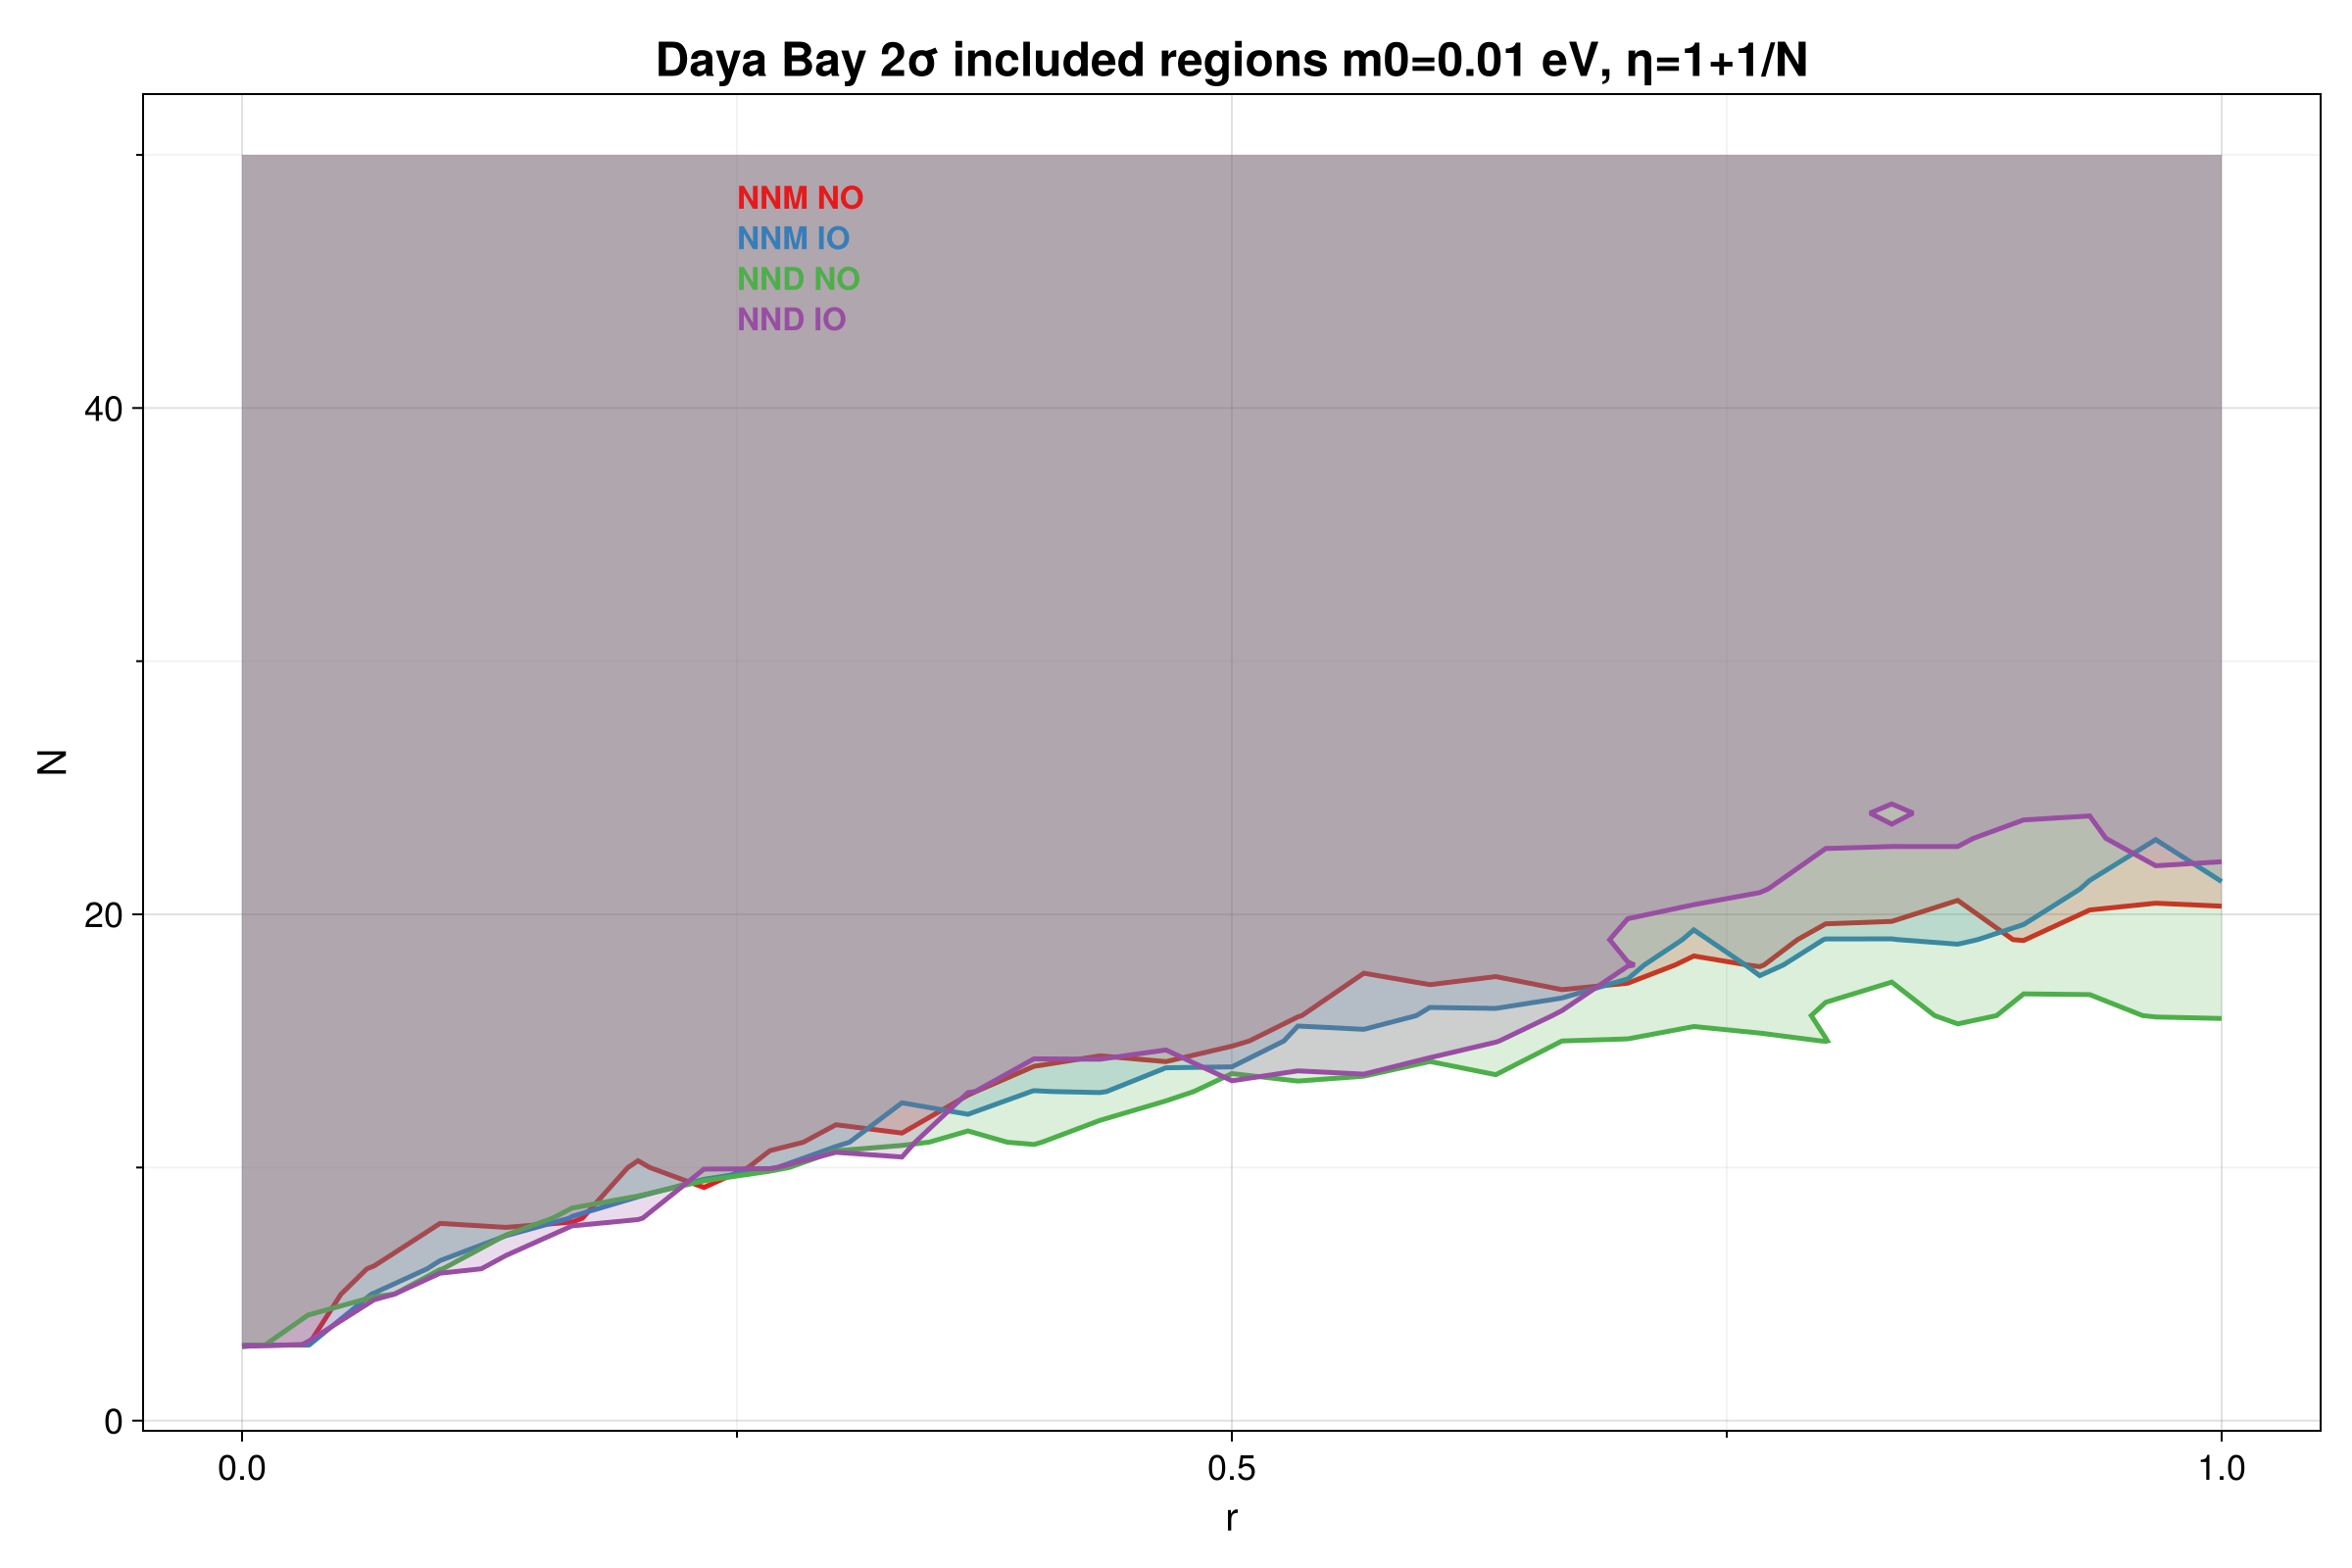

CairoMakie.Screen{IMAGE}


In [10]:
using JLD2, CairoMakie, Distributions, Colors, ColorSchemes
using Newtrinos

function superpose_contours(file_paths::Vector{String}; 
                           title="Superposed Contours",
                           xlabel="Parameter 1", 
                           ylabel="Parameter 2",
                           experiments=nothing,
                           colorscheme=nothing,
                           color_step=1,
                           linestyles=nothing,
                           xscale=identity,
                           yscale=identity,)
 
    
    # Default colorscheme and linestyles
    if colorscheme === nothing
        colorscheme = :Dark2_8
    end
    if linestyles === nothing
        linestyles = fill(:solid, length(file_paths))
    end
    
    # Get colors from the colorscheme with step
    cs = getproperty(ColorSchemes, colorscheme)
    all_colors = cs.colors
    colors = all_colors[1:color_step:end]
    n_colors = length(file_paths)
    if n_colors > length(colors)
        # If we need more colors than available, interpolate
        colors = [colors[i] for i in range(1, length(colors), length=n_colors)]
    else
        colors = colors[1:n_colors]
    end
    
    # Calculate 2σ level
    sigma_2_level = quantile(Chisq(2), 1 - 2*ccdf(Normal(), 2))
    
    # Load all results and find axis ranges
    results = []
    all_axes_1 = []
    all_axes_2 = []
    
    for file_path in file_paths
        result = load(file_path)["result"]  # Adjust key if needed
        push!(results, result)
        push!(all_axes_1, result.axes[1])
        push!(all_axes_2, result.axes[2])
    end
    
    # Find combined axis ranges
    x_min = minimum([minimum(ax) for ax in all_axes_1])
    x_max = maximum([maximum(ax) for ax in all_axes_1])
    y_min = minimum([minimum(ax) for ax in all_axes_2])
    y_max = maximum([maximum(ax) for ax in all_axes_2])
        
    # Get axis labels from first result
    first_result = results[1]
    axis_labels = collect(keys(first_result.axes))

    # Create figure
    f = Figure(size=(1200, 800))
    ax = Axis(f[1,1];
        xlabel = String(axis_labels[1]) , #*"(eV)"
        ylabel = String(axis_labels[2]),
        title = title,
        xminorticksvisible = true, 
        xminorgridvisible = true, 
        yminorticksvisible = true, 
        yminorgridvisible = true,
        titlesize = 24,
        xlabelsize = 20,
        ylabelsize = 20,
        xticklabelsize = 18,
        yticklabelsize = 18,
        xscale = xscale,
        yscale = yscale
    )
    
    # Plot contours
    for (idx, result) in enumerate(results)
        dLLH = 2 * (maximum(result.values.log_posterior) .- result.values.log_posterior)
        
        color = colors[idx]
        linestyle = linestyles[mod(idx-1, length(linestyles)) + 1]
        
        # Create transparent version of the color
        color_transparent = RGBA(color, 1)
        color_transparent_full = RGBA(color, 0.2)
        
        contourf!(ax, result.axes[1], result.axes[2], dLLH,
            levels = [0, sigma_2_level],
            colormap = cgrad([color_transparent_full, color_transparent])) 
        
        # Overlay the contour line on top
        contour!(ax, result.axes[1], result.axes[2], dLLH,
            levels = [sigma_2_level],
            color = color,
            linewidth = 2.5,
            linestyle = linestyle)
    end
    
    if experiments !== nothing
        # Helper function to position in data space (works for log and linear)
        function position_in_range(min_val, max_val, fraction)
            if yscale == log10
                # Log scale: work in log space
                min_log = log10(min_val)
                max_log = log10(max_val)
                return 10 ^ (min_log + fraction * (max_log - min_log))
            else
                # Linear scale: work in linear space
                return min_val + fraction * (max_val - min_val)
            end
        end
        
        fractions_y = range(0.95, 0.85, length=length(experiments))
        y_positions = [position_in_range(y_min, y_max, f) for f in fractions_y]
        x_position = position_in_range(x_min, x_max, 0.25)
        
        for (idx, label) in enumerate(experiments)
            color = colors[idx]
            text!(ax, x_position, y_positions[idx], 
                  text = label,
                  fontsize = 16,
                  color = color,
                  font = :bold)
        end
    end
    
    f
end

file_paths = ["/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_dayabay_Nr_m0=0.01_η=1+1N_NNM_NO.jld2",
                "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_dayabay_Nr_m0=0.01_η=1+1N_NNM_IO.jld2",
                "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_dayabay_Nr_m0=0.01_η=1+1N_NND_NO.jld2",
                "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_dayabay_Nr_m0=0.01_η=1+1N_NND_IO.jld2"]
                
fig = superpose_contours(file_paths;  
    title="Daya Bay 2σ included regions m0=0.01 eV, η=1+1/N",
    experiments = ["NNM NO", "NNM IO", "NND NO", "NND IO"], 
    colorscheme = :Set1_9,
    color_step = 1,
    #xscale=log10,
    #yscale=log10
    )

display(fig)
#save("/home/sofialon/Newtrinos.jl/plots_fix/plots_new/superposed_contours_dayabaylog_rN.png", fig)

In [11]:
using ImageFiltering
using JLD2, CairoMakie, Distributions, Colors, ColorSchemes
using Newtrinos


function gaussian_smooth(Z; σ=1.0)
    kernel = Kernel.gaussian((σ, σ))
    return imfilter(Z, kernel, Pad(:replicate))
end



function superpose_contours_outside(file_paths::Vector{String}; 
                           title="Superposed Contours",
                           xlabel="Parameter 1", 
                           ylabel="Parameter 2",
                           experiments=nothing,
                           colorscheme=nothing,
                           color_step=1,
                           linestyles=nothing,
                           xscale=identity,
                           yscale=identity,
                           smooth_sigma::Union{Nothing,Float64}=nothing)
 
    
    # Default colorscheme and linestyles
    if colorscheme === nothing
        colorscheme = :Dark2_8
    end
    if linestyles === nothing
        linestyles = fill(:solid, length(file_paths))
    end
    
    # Get colors from the colorscheme with step
    cs = getproperty(ColorSchemes, colorscheme)
    all_colors = cs.colors
    colors = all_colors[1:color_step:end]
    n_colors = length(file_paths)
    if n_colors > length(colors)
        # If we need more colors than available, interpolate
        colors = [colors[i] for i in range(1, length(colors), length=n_colors)]
    else
        colors = colors[1:n_colors]
    end
    

    
  
    sigma_90_excluded_level = quantile(Chisq(2), 0.90)
    
    # Load all results and find axis ranges
    results = []
    all_axes_1 = []
    all_axes_2 = []
    
    for file_path in file_paths
        result = load(file_path)["result"]  # Adjust key if needed
        push!(results, result)
        push!(all_axes_1, result.axes[1])
        push!(all_axes_2, result.axes[2])
    end
    
    # Find combined axis ranges
    x_min = minimum([minimum(ax) for ax in all_axes_1])
    x_max = maximum([maximum(ax) for ax in all_axes_1])
    y_min = minimum([minimum(ax) for ax in all_axes_2])
    y_max = maximum([maximum(ax) for ax in all_axes_2])
        
    # Get axis labels from first result
    first_result = results[1]
    axis_labels = collect(keys(first_result.axes))

    # Create figure
    f = Figure(size=(1200, 800))
    ax = Axis(f[1,1];
        xlabel = String(axis_labels[1]) , #*"(eV)"
        ylabel = String(axis_labels[2]),
        title = title,
        xminorticksvisible = true, 
        xminorgridvisible = true, 
        yminorticksvisible = true, 
        yminorgridvisible = true,
        titlesize = 24,
        xlabelsize = 20,
        ylabelsize = 20,
        xticklabelsize = 18,
        yticklabelsize = 18,
        xscale = xscale,
        yscale = yscale
    )
   # Plot contours
    for (idx, result) in enumerate(results)

        dLLH_raw = 2 .* (maximum(result.values.log_posterior) .- result.values.log_posterior)

        dLLH = smooth_sigma === nothing ? dLLH_raw :
            gaussian_smooth(dLLH_raw; σ=smooth_sigma)

        # --- CLEAN FIELD (critical) ---
        dLLH_plot = copy(dLLH)
        dLLH_plot[.!isfinite.(dLLH_plot)] .= NaN

        maxlevel = maximum(skipmissing(vec(dLLH_plot)))
        ϵ = 1e-6  # numerical safety margin

        color = colors[idx]
        linestyle = linestyles[mod(idx-1, length(linestyles)) + 1]

        color_transparent = RGBA(color, 1.0)
        color_transparent_full = RGBA(color, 0.2)

        # --- SHADE ONLY IF EXCLUSION EXISTS ---
        if isfinite(maxlevel) && maxlevel > sigma_90_excluded_level + ϵ
            contourf!(ax,
                result.axes[1],
                result.axes[2],
                dLLH_plot;
                levels = [sigma_90_excluded_level, maxlevel],
                colormap = cgrad([color_transparent_full, color_transparent])
            )
        end

        # --- ALWAYS DRAW CONTOUR LINE ---
        contour!(ax,
            result.axes[1],
            result.axes[2],
            dLLH_plot;
            levels = [sigma_90_excluded_level],
            color = color,
            linewidth = 2.5,
            linestyle = linestyle
        )
        

    end
    if experiments !== nothing
        # Helper function to position in data space (works for log and linear)
        function position_in_range(min_val, max_val, fraction)
            if yscale == log10
                # Log scale: work in log space
                min_log = log10(min_val)
                max_log = log10(max_val)
                return 10 ^ (min_log + fraction * (max_log - min_log))
            else
                # Linear scale: work in linear space
                return min_val + fraction * (max_val - min_val)
            end
        end
        
        fractions_y = range(0.95, 0.85, length=length(experiments))
        y_positions = [position_in_range(y_min, y_max, f) for f in fractions_y]
        x_position = position_in_range(x_min, x_max, 0.9)
        
        for (idx, label) in enumerate(experiments)
            color = colors[idx]
            text!(ax, x_position, y_positions[idx], 
                  text = label,
                  fontsize = 16,
                  color = color,
                  font = :bold)
        end
    end
    
    f
end


file_paths = ["/home/sofialon/Newtrinos.jl/plot_auto/katrin/scan_katrin_m0N_r=1.0_NNM_NO.jld2",
               "/home/sofialon/Newtrinos.jl/plot_auto/katrin/scan_katrin_m0N_r=1.0_NNM_IO.jld2",
                "/home/sofialon/Newtrinos.jl/plot_auto/katrin/scan_katrin_m0N_r=1.0_NND_NO.jld2",
                "/home/sofialon/Newtrinos.jl/plot_auto/katrin/scan_katrin_m0N_r=1.0_NND_IO.jld2"]
                
fig = superpose_contours_outside(file_paths;  
    title="KATRIN 90% C.L. excluded regions m0=0.01 eV, η=1+1/N",
    experiments = ["NNM NO", "NNM IO", "NND NO", "NND IO"], 
    colorscheme = :Set1_9,
    color_step = 1,
    #xscale=log10,
    #yscale=log10
    smooth_sigma=nothing)

display(fig)
#save("/home/sofialon/Newtrinos.jl/plots_fix/plots_newex/superposed_contours_katrin_rN.png", fig)



LoadError: KeyError: key "result" not found

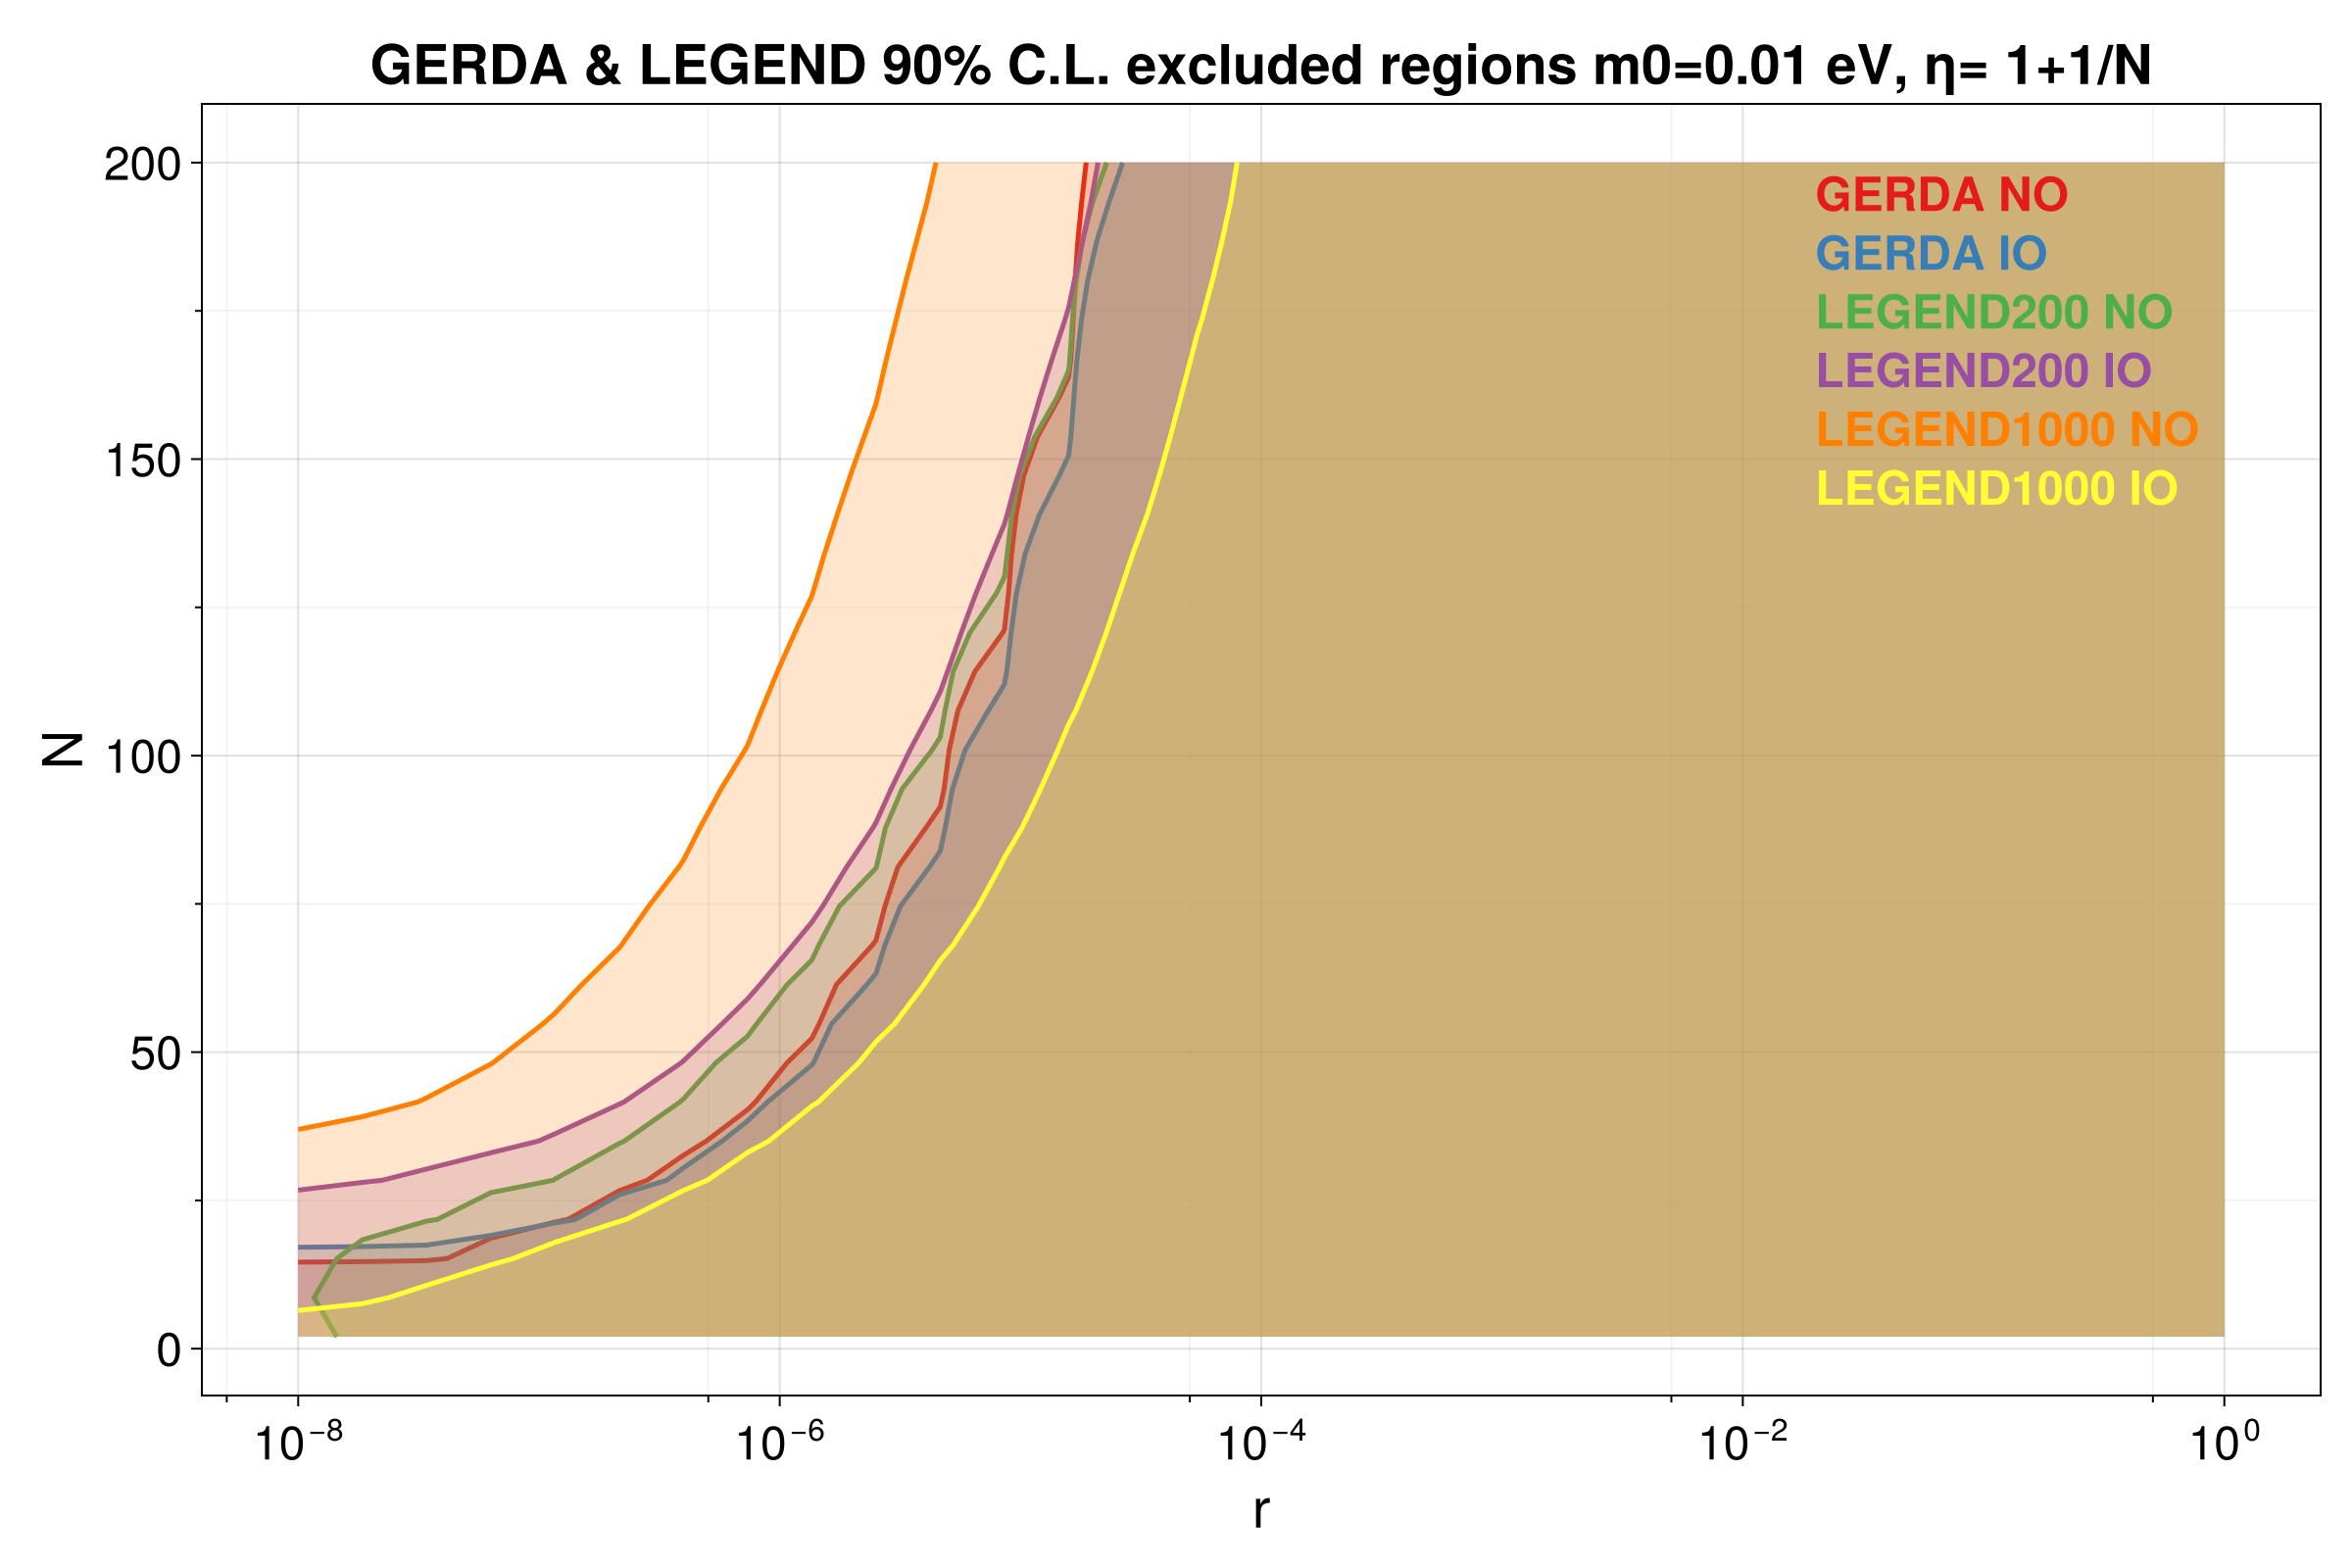

In [14]:
using ImageFiltering
using JLD2, CairoMakie, Distributions, Colors, ColorSchemes
using Newtrinos


function gaussian_smooth(Z; σ=1.0)
    kernel = Kernel.gaussian((σ, σ))
    return imfilter(Z, kernel, Pad(:replicate))
end



function superpose_contours_outside(file_paths::Vector{String}; 
                           title="Superposed Contours",
                           xlabel="Parameter 1", 
                           ylabel="Parameter 2",
                           experiments=nothing,
                           colorscheme=nothing,
                           color_step=1,
                           linestyles=nothing,
                           xscale=identity,
                           yscale=identity,
                           smooth_sigma::Union{Nothing,Float64}=nothing)
 
    
    # Default colorscheme and linestyles
    if colorscheme === nothing
        colorscheme = :Dark2_8
    end
    if linestyles === nothing
        linestyles = fill(:solid, length(file_paths))
    end
    
    # Get colors from the colorscheme with step
    cs = getproperty(ColorSchemes, colorscheme)
    all_colors = cs.colors
    colors = all_colors[1:color_step:end]
    n_colors = length(file_paths)
    if n_colors > length(colors)
        # If we need more colors than available, interpolate
        colors = [colors[i] for i in range(1, length(colors), length=n_colors)]
    else
        colors = colors[1:n_colors]
    end
    

    
  
    sigma_90_excluded_level = quantile(Chisq(2), 0.90)
    
    # Load all results and find axis ranges
    results = []
    all_axes_1 = []
    all_axes_2 = []
    
    
    for file_path in file_paths
        data = load(file_path)
        result = only(values(data)) # Adjust key if needed
        push!(results, result)
        push!(all_axes_1, result.axes[1])
        push!(all_axes_2, result.axes[2])
    end
    
    # Find combined axis ranges
    x_min = minimum([minimum(ax) for ax in all_axes_1])
    x_max = maximum([maximum(ax) for ax in all_axes_1])
    y_min = minimum([minimum(ax) for ax in all_axes_2])
    y_max = maximum([maximum(ax) for ax in all_axes_2])
        
    # Get axis labels from first result
    first_result = results[1]
    axis_labels = collect(keys(first_result.axes))

    # Create figure
    f = Figure(size=(1200, 800))
    ax = Axis(f[1,1];
        xlabel = String(axis_labels[1]) , #*"(eV)"
        ylabel = String(axis_labels[2]),
        title = title,
        xminorticksvisible = true, 
        xminorgridvisible = true, 
        yminorticksvisible = true, 
        yminorgridvisible = true,
        titlesize = 28,
        xlabelsize = 28,
        ylabelsize = 28,
        xticklabelsize = 24,
        yticklabelsize = 24,
        xscale = xscale,
        yscale = yscale
        )

   # Plot contours
    for (idx, result) in enumerate(results)

        dLLH_raw = 2 .* (maximum(result.values.log_posterior) .- result.values.log_posterior)

        dLLH = smooth_sigma === nothing ? dLLH_raw :
            gaussian_smooth(dLLH_raw; σ=smooth_sigma)

        # --- CLEAN FIELD (critical) ---
        dLLH_plot = copy(dLLH)
        dLLH_plot[.!isfinite.(dLLH_plot)] .= NaN

        maxlevel = maximum(skipmissing(vec(dLLH_plot)))
        ϵ = 1e-6  # numerical safety margin

        color = colors[idx]
        linestyle = linestyles[mod(idx-1, length(linestyles)) + 1]

        color_transparent = RGBA(color, 1.0)
        color_transparent_full = RGBA(color, 0.2)

        # --- SHADE ONLY IF EXCLUSION EXISTS ---
        if isfinite(maxlevel) && maxlevel > sigma_90_excluded_level + ϵ
            contourf!(ax,
                result.axes[1],
                result.axes[2],
                dLLH_plot;
                levels = [sigma_90_excluded_level, maxlevel],
                colormap = cgrad([color_transparent_full, color_transparent])
            )
        end

        # --- ALWAYS DRAW CONTOUR LINE ---
        contour!(ax,
            result.axes[1],
            result.axes[2],
            dLLH_plot;
            levels = [sigma_90_excluded_level],
            color = color,
            linewidth = 2.5,
            linestyle = linestyle
        )
        

    end
    if experiments !== nothing
        # Helper function to position in data space (works for log and linear)
        function position_in_range(min_val, max_val, fraction)
            if yscale == log10
                # Log scale: work in log space
                min_log = log10(min_val)
                max_log = log10(max_val)
                return 10 ^ (min_log + fraction * (max_log - min_log))
            else
                # Linear scale: work in linear space
                return min_val + fraction * (max_val - min_val)
            end
        end
        
        fractions_y = range(0.95, 0.7, length=length(experiments))
        y_positions = [position_in_range(y_min, y_max, f) for f in fractions_y]
        x_position = position_in_range(x_min, x_max, 0.02)
        
        for (idx, label) in enumerate(experiments)
            color = colors[idx]
            text!(ax, x_position, y_positions[idx], 
                  text = label,
                  fontsize = 24,
                  color = color,
                  font = :bold)
        end
    end
    
    f
end


file_paths = ["/home/sofialon/Newtrinos.jl/plot_auto/gerda/scan_gerda_rN_m0=0.01_NNM_NO.jld2",
                "/home/sofialon/Newtrinos.jl/plot_auto/gerda/scan_gerda_rN_m0=0.01_NNM_IO.jld2",
                "/home/sofialon/Newtrinos.jl/plot_auto/gerda/scan_gerda_rN_m0=0.01_NNM_NO_200.jld2",
                "/home/sofialon/Newtrinos.jl/plot_auto/gerda/scan_gerda_rN_m0=0.01_NNM_IO_200.jld2",
                "/home/sofialon/Newtrinos.jl/plot_auto/gerda/scan_gerda_rN_m0=0.01_NNM_NO_1000.jld2",
                "/home/sofialon/Newtrinos.jl/plot_auto/gerda/scan_gerda_rN_m0=0.01_NNM_IO_1000.jld2",]
                
fig = superpose_contours_outside(file_paths;  
    title="GERDA & LEGEND 90% C.L. excluded regions m0=0.01 eV, η= 1+1/N",
    experiments = ["GERDA NO", "GERDA IO", "LEGEND200 NO", "LEGEND200 IO", "LEGEND1000 NO", "LEGEND1000 IO"], 
    colorscheme = :Set1_9,
    color_step = 1,
    xscale=log10,
    #yscale=log10
    smooth_sigma=0.8)

display("image/png", fig)
#save("/home/sofialon/Newtrinos.jl/plots_svg/gerda/superposed_contours_gerda_rN.png", fig)
#save("/home/sofialon/Newtrinos.jl/plots_svg/gerda/superposed_contours_gerda_rN.svg", fig)


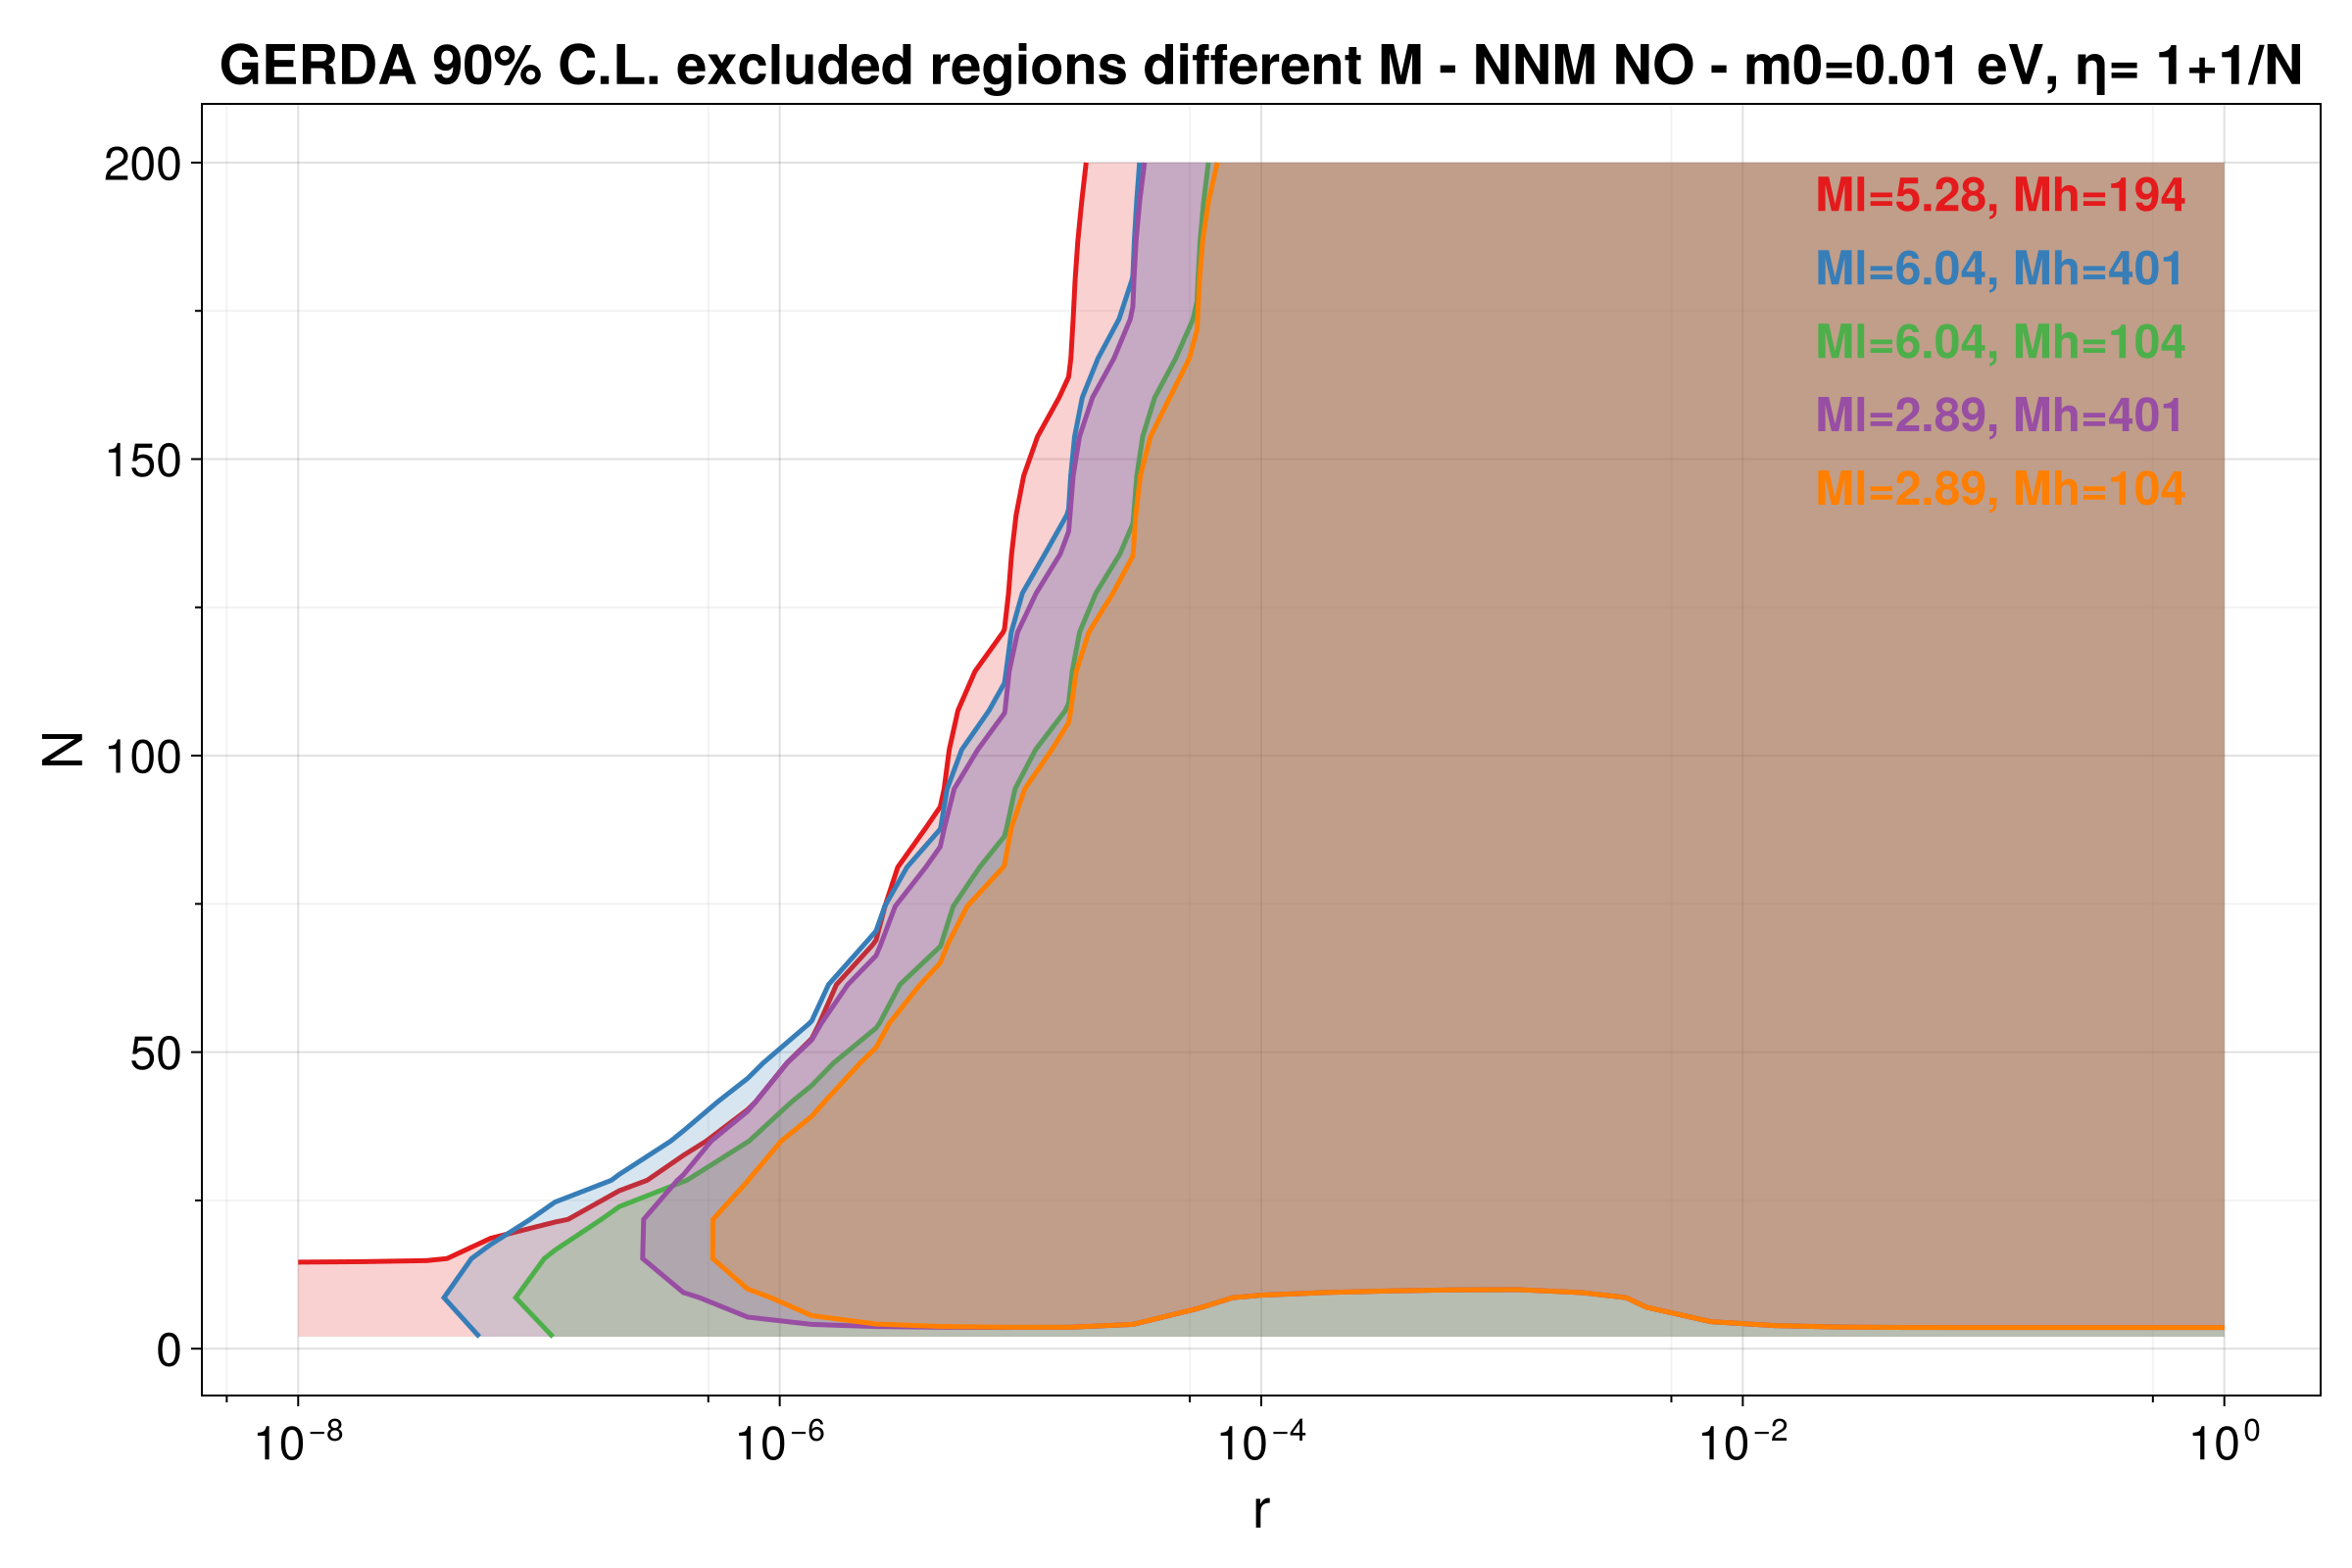

CairoMakie.Screen{SVG}


In [35]:
    

file_paths = ["/home/sofialon/Newtrinos.jl/plot_auto/gerda/scan_gerda_rN_m0=0.01_NNM_NO.jld2",
    "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_gerda_M_uu_Nr_m0=0.01_η=1+1N_NNM_NO.jld2",
    "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_gerda_M_ud_Nr_m0=0.01_η=1+1N_NNM_NO.jld2",
    "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_gerda_M_du_Nr_m0=0.01_η=1+1N_NNM_NO.jld2",
    "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_gerda_M_dd_Nr_m0=0.01_η=1+1N_NNM_NO.jld2"]     
                
fig = superpose_contours_outside(file_paths;  
    title="GERDA 90% C.L. excluded regions different M - NNM NO - m0=0.01 eV, η= 1+1/N",
    experiments = ["Ml=5.28, Mh=194","Ml=6.04, Mh=401" ,"Ml=6.04, Mh=104", "Ml=2.89, Mh=401", "Ml=2.89, Mh=104"], 
    colorscheme = :Set1_9,
    color_step = 1,
    xscale=log10,
    #yscale=log10
    smooth_sigma=0.8)

display("image/png", fig)
save("/home/sofialon/Newtrinos.jl/plots_svg/gerda/superposed_contours_gerda_rN_M.png", fig)
save("/home/sofialon/Newtrinos.jl/plots_svg/gerda/superposed_contours_gerda_rN_M.svg", fig)

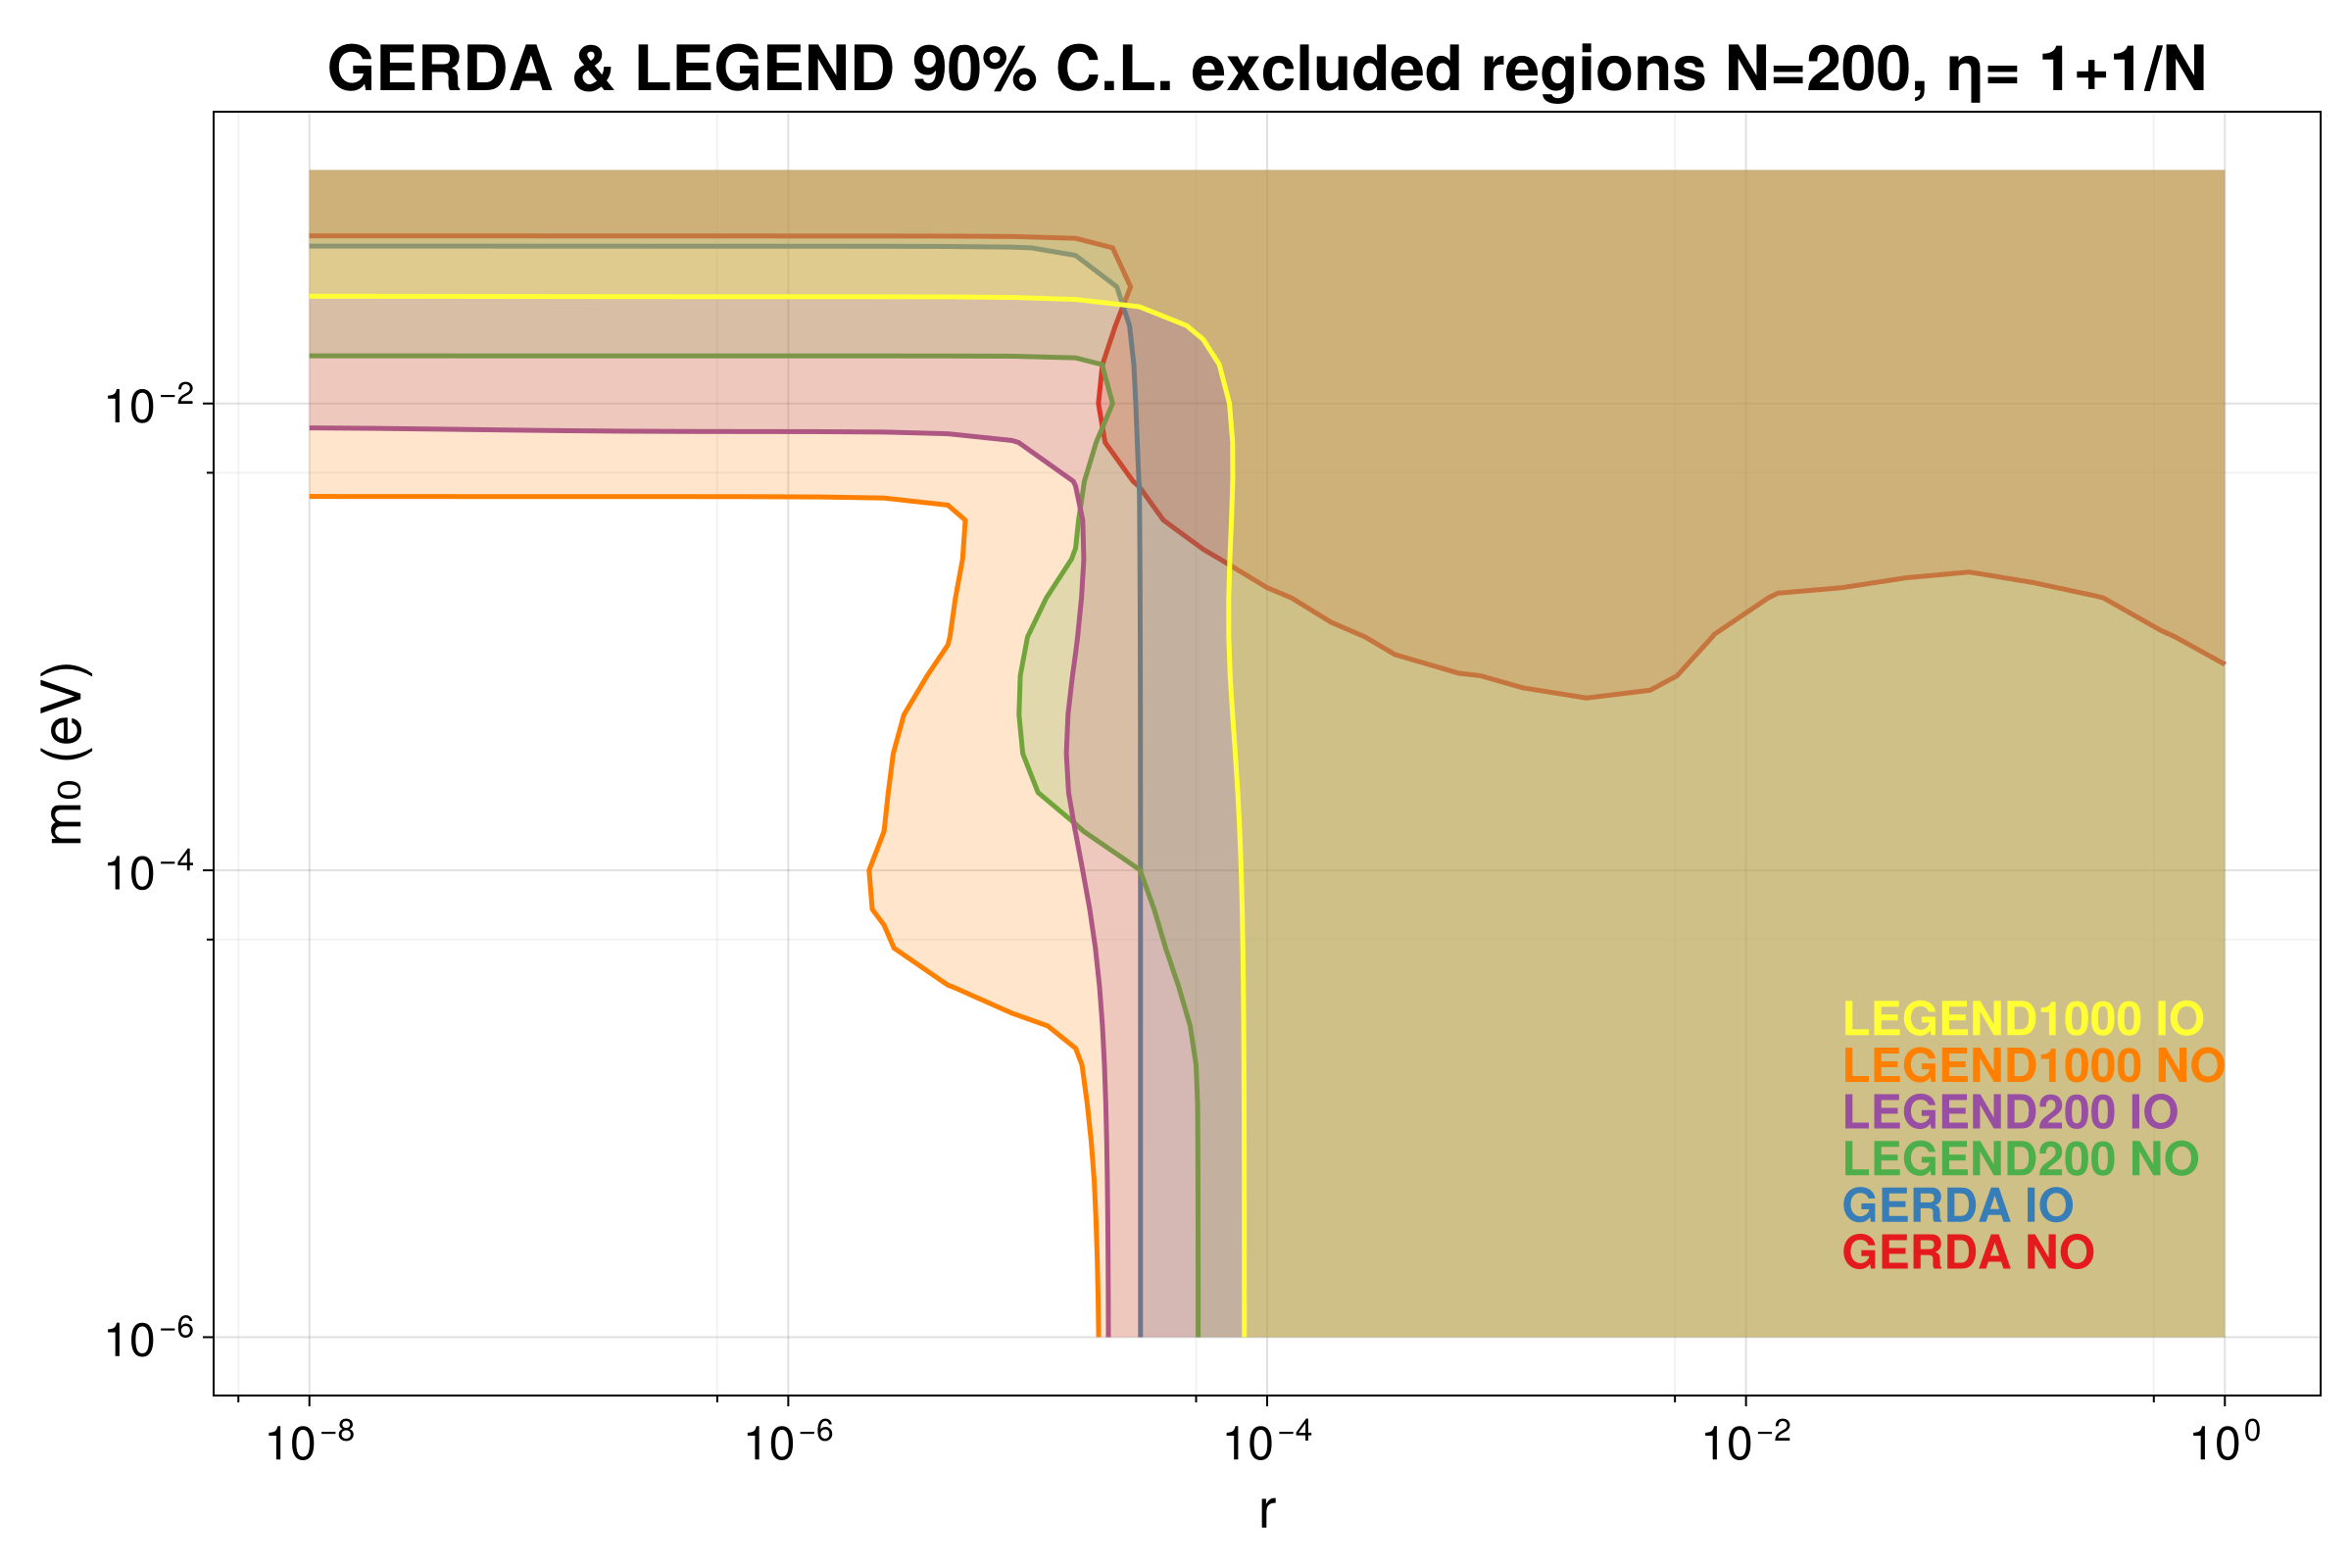

CairoMakie.Screen{SVG}


In [24]:
using ImageFiltering
using JLD2, CairoMakie, Distributions, Colors, ColorSchemes
using Newtrinos


function gaussian_smooth(Z; σ=1.0)
    kernel = Kernel.gaussian((σ, σ))
    return imfilter(Z, kernel, Pad(:replicate))
end



function superpose_contours_outside(file_paths::Vector{String}; 
                           title="Superposed Contours",
                           xlabel="Parameter 1", 
                           ylabel="Parameter 2",
                           experiments=nothing,
                           colorscheme=nothing,
                           color_step=1,
                           linestyles=nothing,
                           xscale=identity,
                           yscale=identity,
                           smooth_sigma::Union{Nothing,Float64}=nothing)
 
    
    # Default colorscheme and linestyles
    if colorscheme === nothing
        colorscheme = :Dark2_8
    end
    if linestyles === nothing
        linestyles = fill(:solid, length(file_paths))
    end
    
    # Get colors from the colorscheme with step
    cs = getproperty(ColorSchemes, colorscheme)
    all_colors = cs.colors
    colors = all_colors[1:color_step:end]
    n_colors = length(file_paths)
    if n_colors > length(colors)
        # If we need more colors than available, interpolate
        colors = [colors[i] for i in range(1, length(colors), length=n_colors)]
    else
        colors = colors[1:n_colors]
    end
    

    
  
    sigma_90_excluded_level = quantile(Chisq(2), 0.90)
    
    # Load all results and find axis ranges
    results = []
    all_axes_1 = []
    all_axes_2 = []
    
    
    for file_path in file_paths
        data = load(file_path)
        result = only(values(data)) # Adjust key if needed
        push!(results, result)
        push!(all_axes_1, result.axes[1])
        push!(all_axes_2, result.axes[2])
    end
    
    # Find combined axis ranges
    x_min = minimum([minimum(ax) for ax in all_axes_1])
    x_max = maximum([maximum(ax) for ax in all_axes_1])
    y_min = minimum([minimum(ax) for ax in all_axes_2])
    y_max = maximum([maximum(ax) for ax in all_axes_2])
        
    # Get axis labels from first result
    first_result = results[1]
    axis_labels = collect(keys(first_result.axes))

    # Create figure
    f = Figure(size=(1200, 800))
    ax = Axis(f[1,1];
        xlabel = String(axis_labels[1]) , #*"(eV)"
        ylabel = String(axis_labels[2]) *" (eV)",
        title = title,
        xminorticksvisible = true, 
        xminorgridvisible = true, 
        yminorticksvisible = true, 
        yminorgridvisible = true,
        titlesize = 32,
        xlabelsize = 28,
        ylabelsize = 28,
        xticklabelsize = 24,
        yticklabelsize = 24,
        xscale = xscale,
        yscale = yscale
        )

   # Plot contours
    for (idx, result) in enumerate(results)

        dLLH_raw = 2 .* (maximum(result.values.log_posterior) .- result.values.log_posterior)

        dLLH = smooth_sigma === nothing ? dLLH_raw :
            gaussian_smooth(dLLH_raw; σ=smooth_sigma)

        # --- CLEAN FIELD (critical) ---
        dLLH_plot = copy(dLLH)
        dLLH_plot[.!isfinite.(dLLH_plot)] .= NaN

        maxlevel = maximum(skipmissing(vec(dLLH_plot)))
        ϵ = 1e-6  # numerical safety margin

        color = colors[idx]
        linestyle = linestyles[mod(idx-1, length(linestyles)) + 1]

        color_transparent = RGBA(color, 1.0)
        color_transparent_full = RGBA(color, 0.2)

        # --- SHADE ONLY IF EXCLUSION EXISTS ---
        if isfinite(maxlevel) && maxlevel > sigma_90_excluded_level + ϵ
            contourf!(ax,
                result.axes[1],
                result.axes[2],
                dLLH_plot;
                levels = [sigma_90_excluded_level, maxlevel],
                colormap = cgrad([color_transparent_full, color_transparent])
            )
        end

        # --- ALWAYS DRAW CONTOUR LINE ---
        contour!(ax,
            result.axes[1],
            result.axes[2],
            dLLH_plot;
            levels = [sigma_90_excluded_level],
            color = color,
            linewidth = 2.5,
            linestyle = linestyle
        )
        

    end
    if experiments !== nothing
        # Helper function to position in data space (works for log and linear)
        function position_in_range(min_val, max_val, fraction)
            if yscale == log10
                # Log scale: work in log space
                min_log = log10(min_val)
                max_log = log10(max_val)
                return 10 ^ (min_log + fraction * (max_log - min_log))
            else
                # Linear scale: work in linear space
                return min_val + fraction * (max_val - min_val)
            end
        end
        
        fractions_y = range(0.05, 0.25, length=length(experiments))
        y_positions = [position_in_range(y_min, y_max, f) for f in fractions_y]
        x_position = position_in_range(x_min, x_max, 0.8)
        
        for (idx, label) in enumerate(experiments)
            color = colors[idx]
            text!(ax, x_position, y_positions[idx], 
                  text = label,
                  fontsize = 24,
                  color = color,
                  font = :bold)
        end
    end
    
    f
end


file_paths = ["/home/sofialon/Newtrinos.jl/plot_auto/gerda/scan_gerda_rm0_N=200_NNM_NO.jld2",
                "/home/sofialon/Newtrinos.jl/plot_auto/gerda/scan_gerda_rm0_N=200_NNM_IO.jld2",
                "/home/sofialon/Newtrinos.jl/plot_auto/gerda/scan_gerda_rm0_N=200_NNM_NO_200.jld2",
                "/home/sofialon/Newtrinos.jl/plot_auto/gerda/scan_gerda_rm0_N=200_NNM_IO_200.jld2",
                "/home/sofialon/Newtrinos.jl/plot_auto/gerda/scan_gerda_rm0_N=200_NNM_NO_1000.jld2",
                "/home/sofialon/Newtrinos.jl/plot_auto/gerda/scan_gerda_rm0_N=200_NNM_IO_1000.jld2",]
                
fig = superpose_contours_outside(file_paths;  
    title="GERDA & LEGEND 90% C.L. excluded regions N=200, η= 1+1/N",
    experiments = ["GERDA NO", "GERDA IO", "LEGEND200 NO", "LEGEND200 IO", "LEGEND1000 NO", "LEGEND1000 IO"], 
    colorscheme = :Set1_9,
    color_step = 1,
    xscale=log10,
    yscale=log10,
    smooth_sigma=0.8)

display("image/png", fig)
save("/home/sofialon/Newtrinos.jl/plots_svg/gerda/superposed_contours_gerda_m0r.png", fig)
save("/home/sofialon/Newtrinos.jl/plots_svg/gerda/superposed_contours_gerda_m0r.svg", fig)


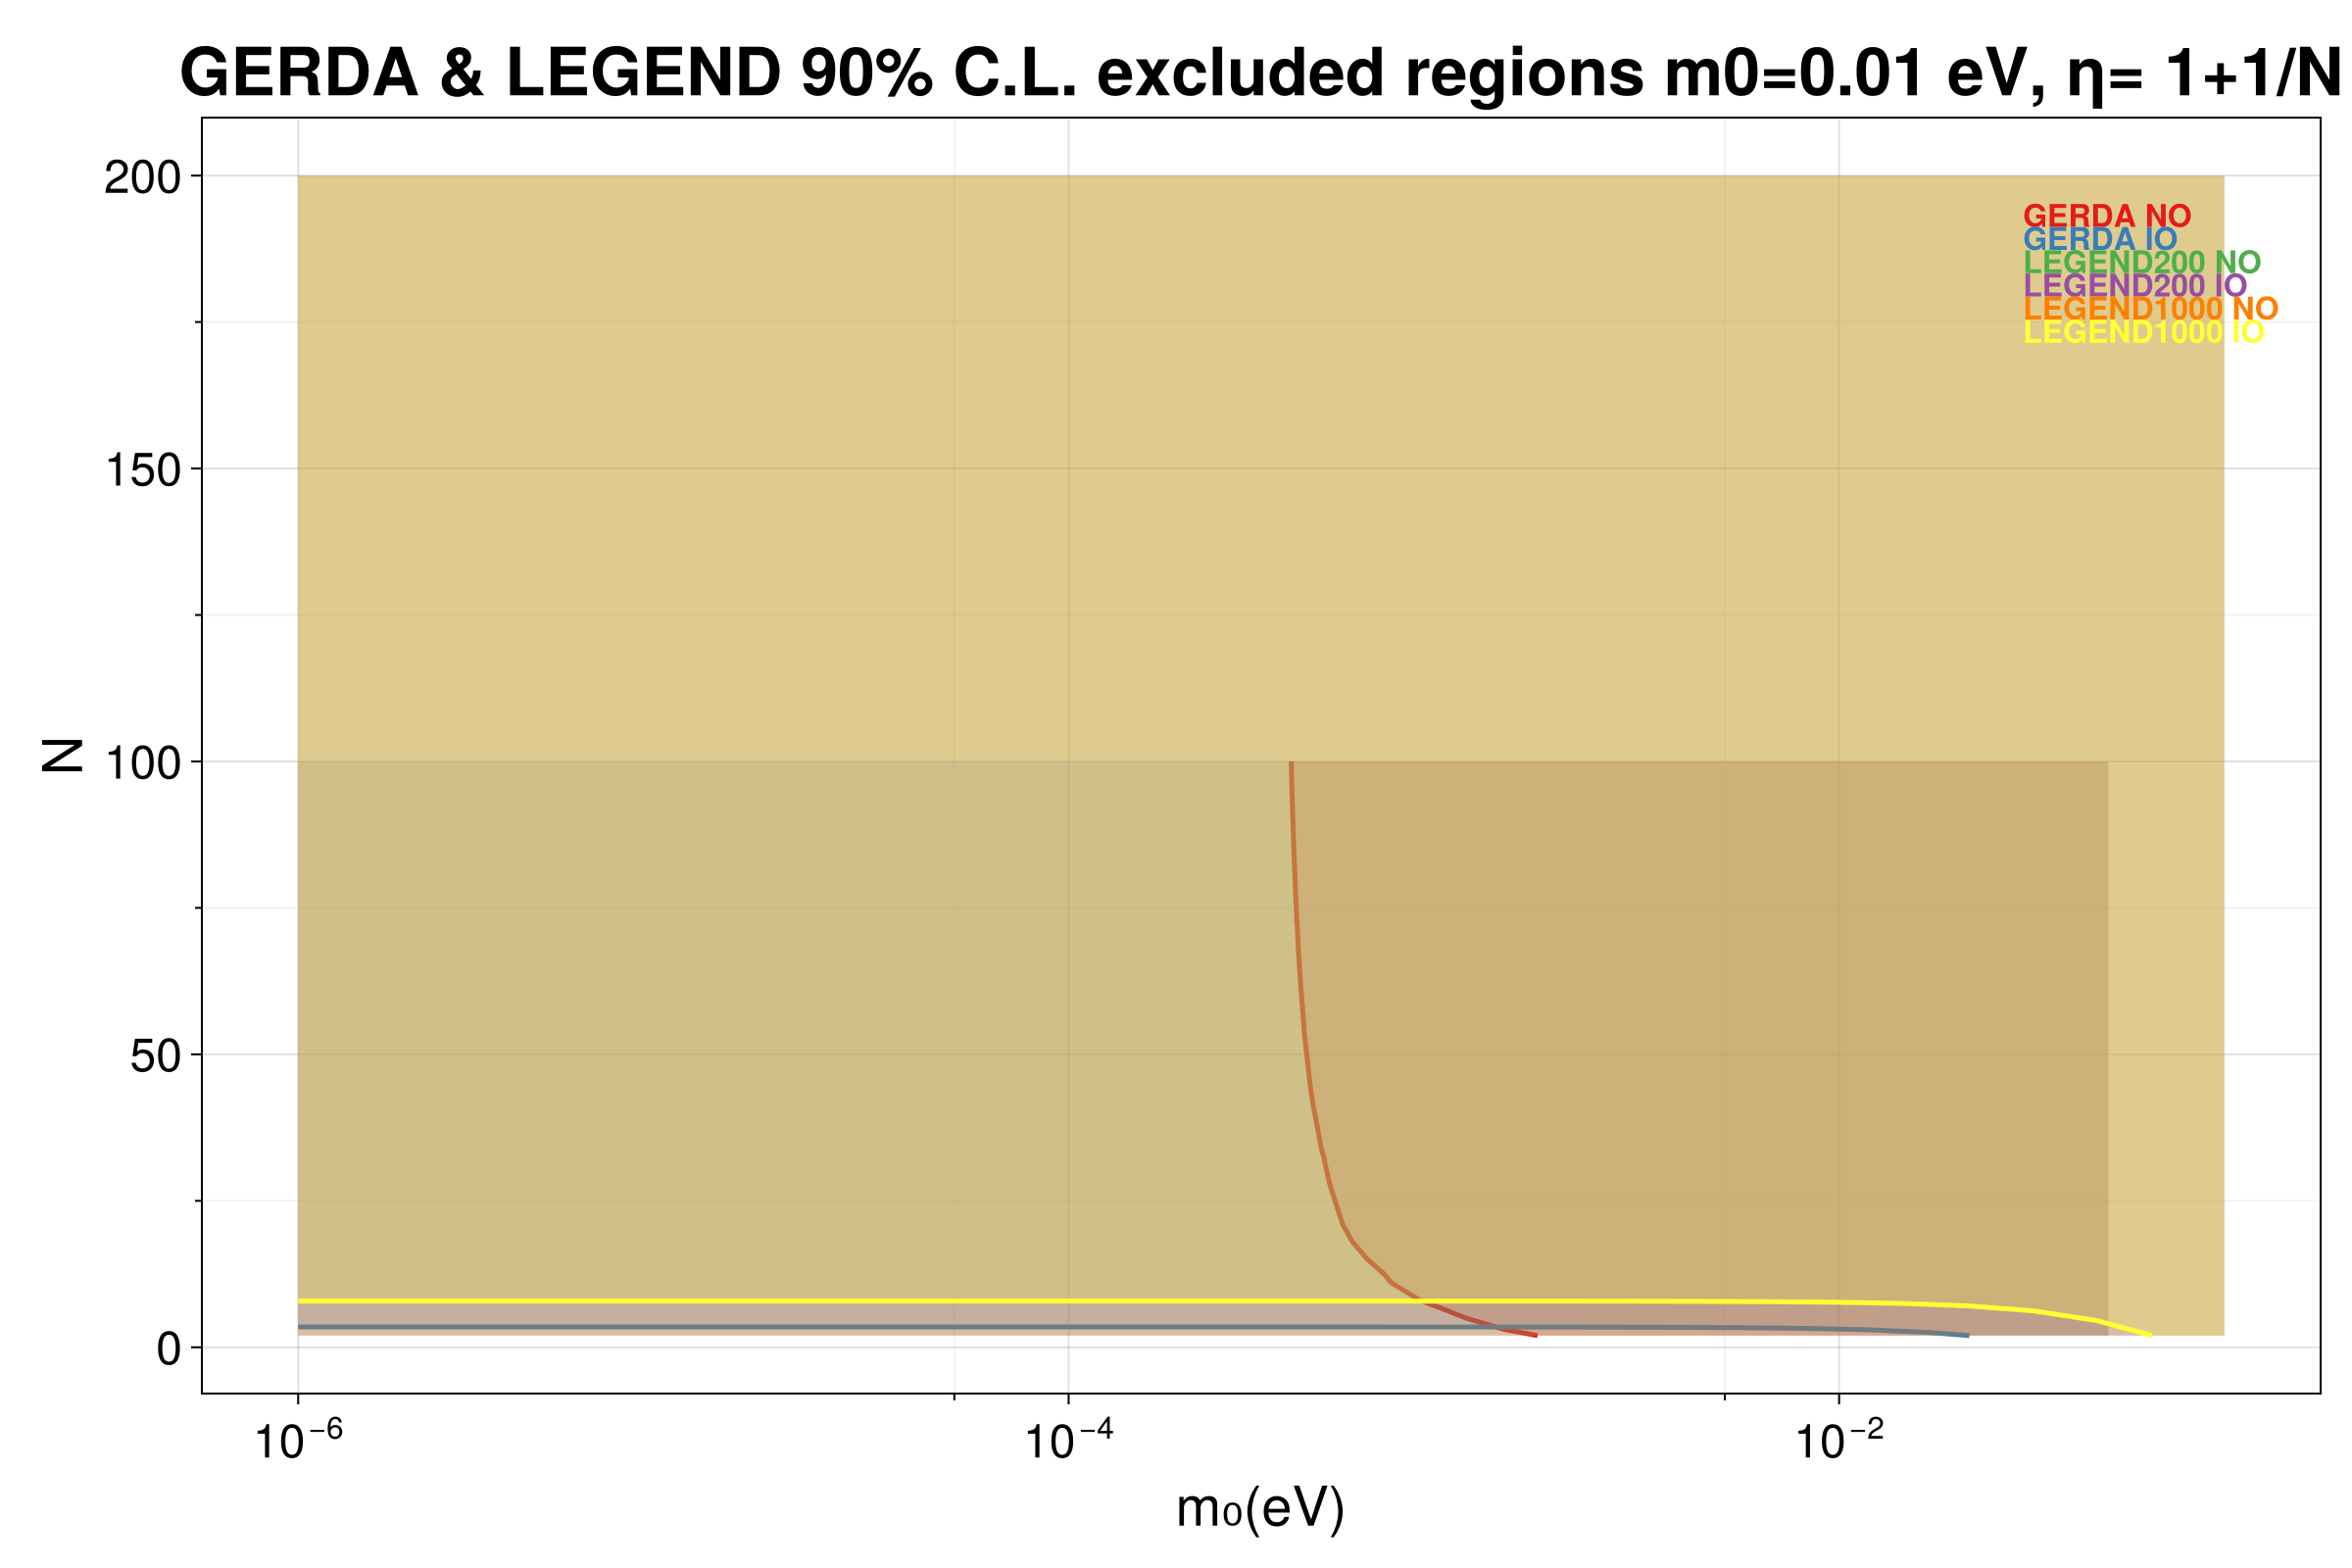

CairoMakie.Screen{SVG}


In [6]:
using ImageFiltering
using JLD2, CairoMakie, Distributions, Colors, ColorSchemes
using Newtrinos


function gaussian_smooth(Z; σ=1.0)
    kernel = Kernel.gaussian((σ, σ))
    return imfilter(Z, kernel, Pad(:replicate))
end



function superpose_contours_outside(file_paths::Vector{String}; 
                           title="Superposed Contours",
                           xlabel="Parameter 1", 
                           ylabel="Parameter 2",
                           experiments=nothing,
                           colorscheme=nothing,
                           color_step=1,
                           linestyles=nothing,
                           xscale=identity,
                           yscale=identity,
                           smooth_sigma::Union{Nothing,Float64}=nothing)
 
    
    # Default colorscheme and linestyles
    if colorscheme === nothing
        colorscheme = :Dark2_8
    end
    if linestyles === nothing
        linestyles = fill(:solid, length(file_paths))
    end
    
    # Get colors from the colorscheme with step
    cs = getproperty(ColorSchemes, colorscheme)
    all_colors = cs.colors
    colors = all_colors[1:color_step:end]
    n_colors = length(file_paths)
    if n_colors > length(colors)
        # If we need more colors than available, interpolate
        colors = [colors[i] for i in range(1, length(colors), length=n_colors)]
    else
        colors = colors[1:n_colors]
    end
    

    
  
    sigma_90_excluded_level = quantile(Chisq(2), 0.90)
    
    # Load all results and find axis ranges
    results = []
    all_axes_1 = []
    all_axes_2 = []
    
   
    for file_path in file_paths
        data = load(file_path)
        result = only(values(data)) # Adjust key if needed
        push!(results, result)
        push!(all_axes_1, result.axes[1])
        push!(all_axes_2, result.axes[2])
    end
    
    # Find combined axis ranges
    x_min = minimum([minimum(ax) for ax in all_axes_1])
    x_max = maximum([maximum(ax) for ax in all_axes_1])
    y_min = minimum([minimum(ax) for ax in all_axes_2])
    y_max = maximum([maximum(ax) for ax in all_axes_2])
        
    # Get axis labels from first result
    first_result = results[1]
    axis_labels = collect(keys(first_result.axes))

    # Create figure
    f = Figure(size=(1200, 800))
    ax = Axis(f[1,1];
        xlabel = String(axis_labels[1]) *"(eV)",
        ylabel = String(axis_labels[2]),
        title = title,
        xminorticksvisible = true, 
        xminorgridvisible = true, 
        yminorticksvisible = true, 
        yminorgridvisible = true,
        titlesize = 34,
        xlabelsize = 28,
        ylabelsize = 28,
        xticklabelsize = 24,
        yticklabelsize = 24,
        xscale = xscale,
        yscale = yscale
        )

   # Plot contours
    for (idx, result) in enumerate(results)

        dLLH_raw = 2 .* (maximum(result.values.log_posterior) .- result.values.log_posterior)

        dLLH = smooth_sigma === nothing ? dLLH_raw :
            gaussian_smooth(dLLH_raw; σ=smooth_sigma)

        # --- CLEAN FIELD (critical) ---
        dLLH_plot = copy(dLLH)
        dLLH_plot[.!isfinite.(dLLH_plot)] .= NaN

        maxlevel = maximum(skipmissing(vec(dLLH_plot)))
        ϵ = 1e-6  # numerical safety margin

        color = colors[idx]
        linestyle = linestyles[mod(idx-1, length(linestyles)) + 1]

        color_transparent = RGBA(color, 1.0)
        color_transparent_full = RGBA(color, 0.2)

        # --- SHADE ONLY IF EXCLUSION EXISTS ---
        if isfinite(maxlevel) && maxlevel > sigma_90_excluded_level + ϵ
            contourf!(ax,
                result.axes[1],
                result.axes[2],
                dLLH_plot;
                levels = [sigma_90_excluded_level, maxlevel],
                colormap = cgrad([color_transparent_full, color_transparent])
            )
        end

        # --- ALWAYS DRAW CONTOUR LINE ---
        contour!(ax,
            result.axes[1],
            result.axes[2],
            dLLH_plot;
            levels = [sigma_90_excluded_level],
            color = color,
            linewidth = 2.5,
            linestyle = linestyle
        )
        

    end
    if experiments !== nothing
        # Helper function to position in data space (works for log and linear)
        function position_in_range(min_val, max_val, fraction)
            if yscale == log10
                # Log scale: work in log space
                min_log = log10(min_val)
                max_log = log10(max_val)
                return 10 ^ (min_log + fraction * (max_log - min_log))
            else
                # Linear scale: work in linear space
                return min_val + fraction * (max_val - min_val)
            end
        end
        
        fractions_y = range(0.95, 0.85, length=length(experiments))
        y_positions = [position_in_range(y_min, y_max, f) for f in fractions_y]
        x_position = position_in_range(x_min, x_max, 0.3)
        
        for (idx, label) in enumerate(experiments)
            color = colors[idx]
            text!(ax, x_position, y_positions[idx], 
                  text = label,
                  fontsize = 16,
                  color = color,
                  font = :bold)
        end
    end
    
    f
end


file_paths = ["/home/sofialon/Newtrinos.jl/plot_auto/gerda/scan_gerda_m0N_r=1.0_NNM_NO.jld2",
                "/home/sofialon/Newtrinos.jl/plot_auto/gerda/scan_gerda_m0N_r=1.0_NNM_IO.jld2",
                "/home/sofialon/Newtrinos.jl/plot_auto/gerda/scan_gerda_m0N_r=1.0_NNM_NO_200.jld2",
                "/home/sofialon/Newtrinos.jl/plot_auto/gerda/scan_gerda_m0N_r=1.0_NNM_IO_200.jld2",
                "/home/sofialon/Newtrinos.jl/plot_auto/gerda/scan_gerda_m0N_r=1.0_NNM_NO_1000.jld2",
                "/home/sofialon/Newtrinos.jl/plot_auto/gerda/scan_gerda_m0N_r=1.0_NNM_IO_1000.jld2",]
                
fig = superpose_contours_outside(file_paths;  
    title="GERDA & LEGEND 90% C.L. excluded regions m0=0.01 eV, η= 1+1/N",
    experiments = ["GERDA NO", "GERDA IO", "LEGEND200 NO", "LEGEND200 IO", "LEGEND1000 NO", "LEGEND1000 IO"], 
    colorscheme = :Set1_9,
    color_step = 1,
    xscale=log10,
    #yscale=log10
    smooth_sigma=0.8)

display("image/png", fig)
save("/home/sofialon/Newtrinos.jl/plots_svg/gerda/superposed_contours_gerda_m0N.png", fig)
save("/home/sofialon/Newtrinos.jl/plots_svg/gerda/superposed_contours_gerda_m0N.svg", fig)


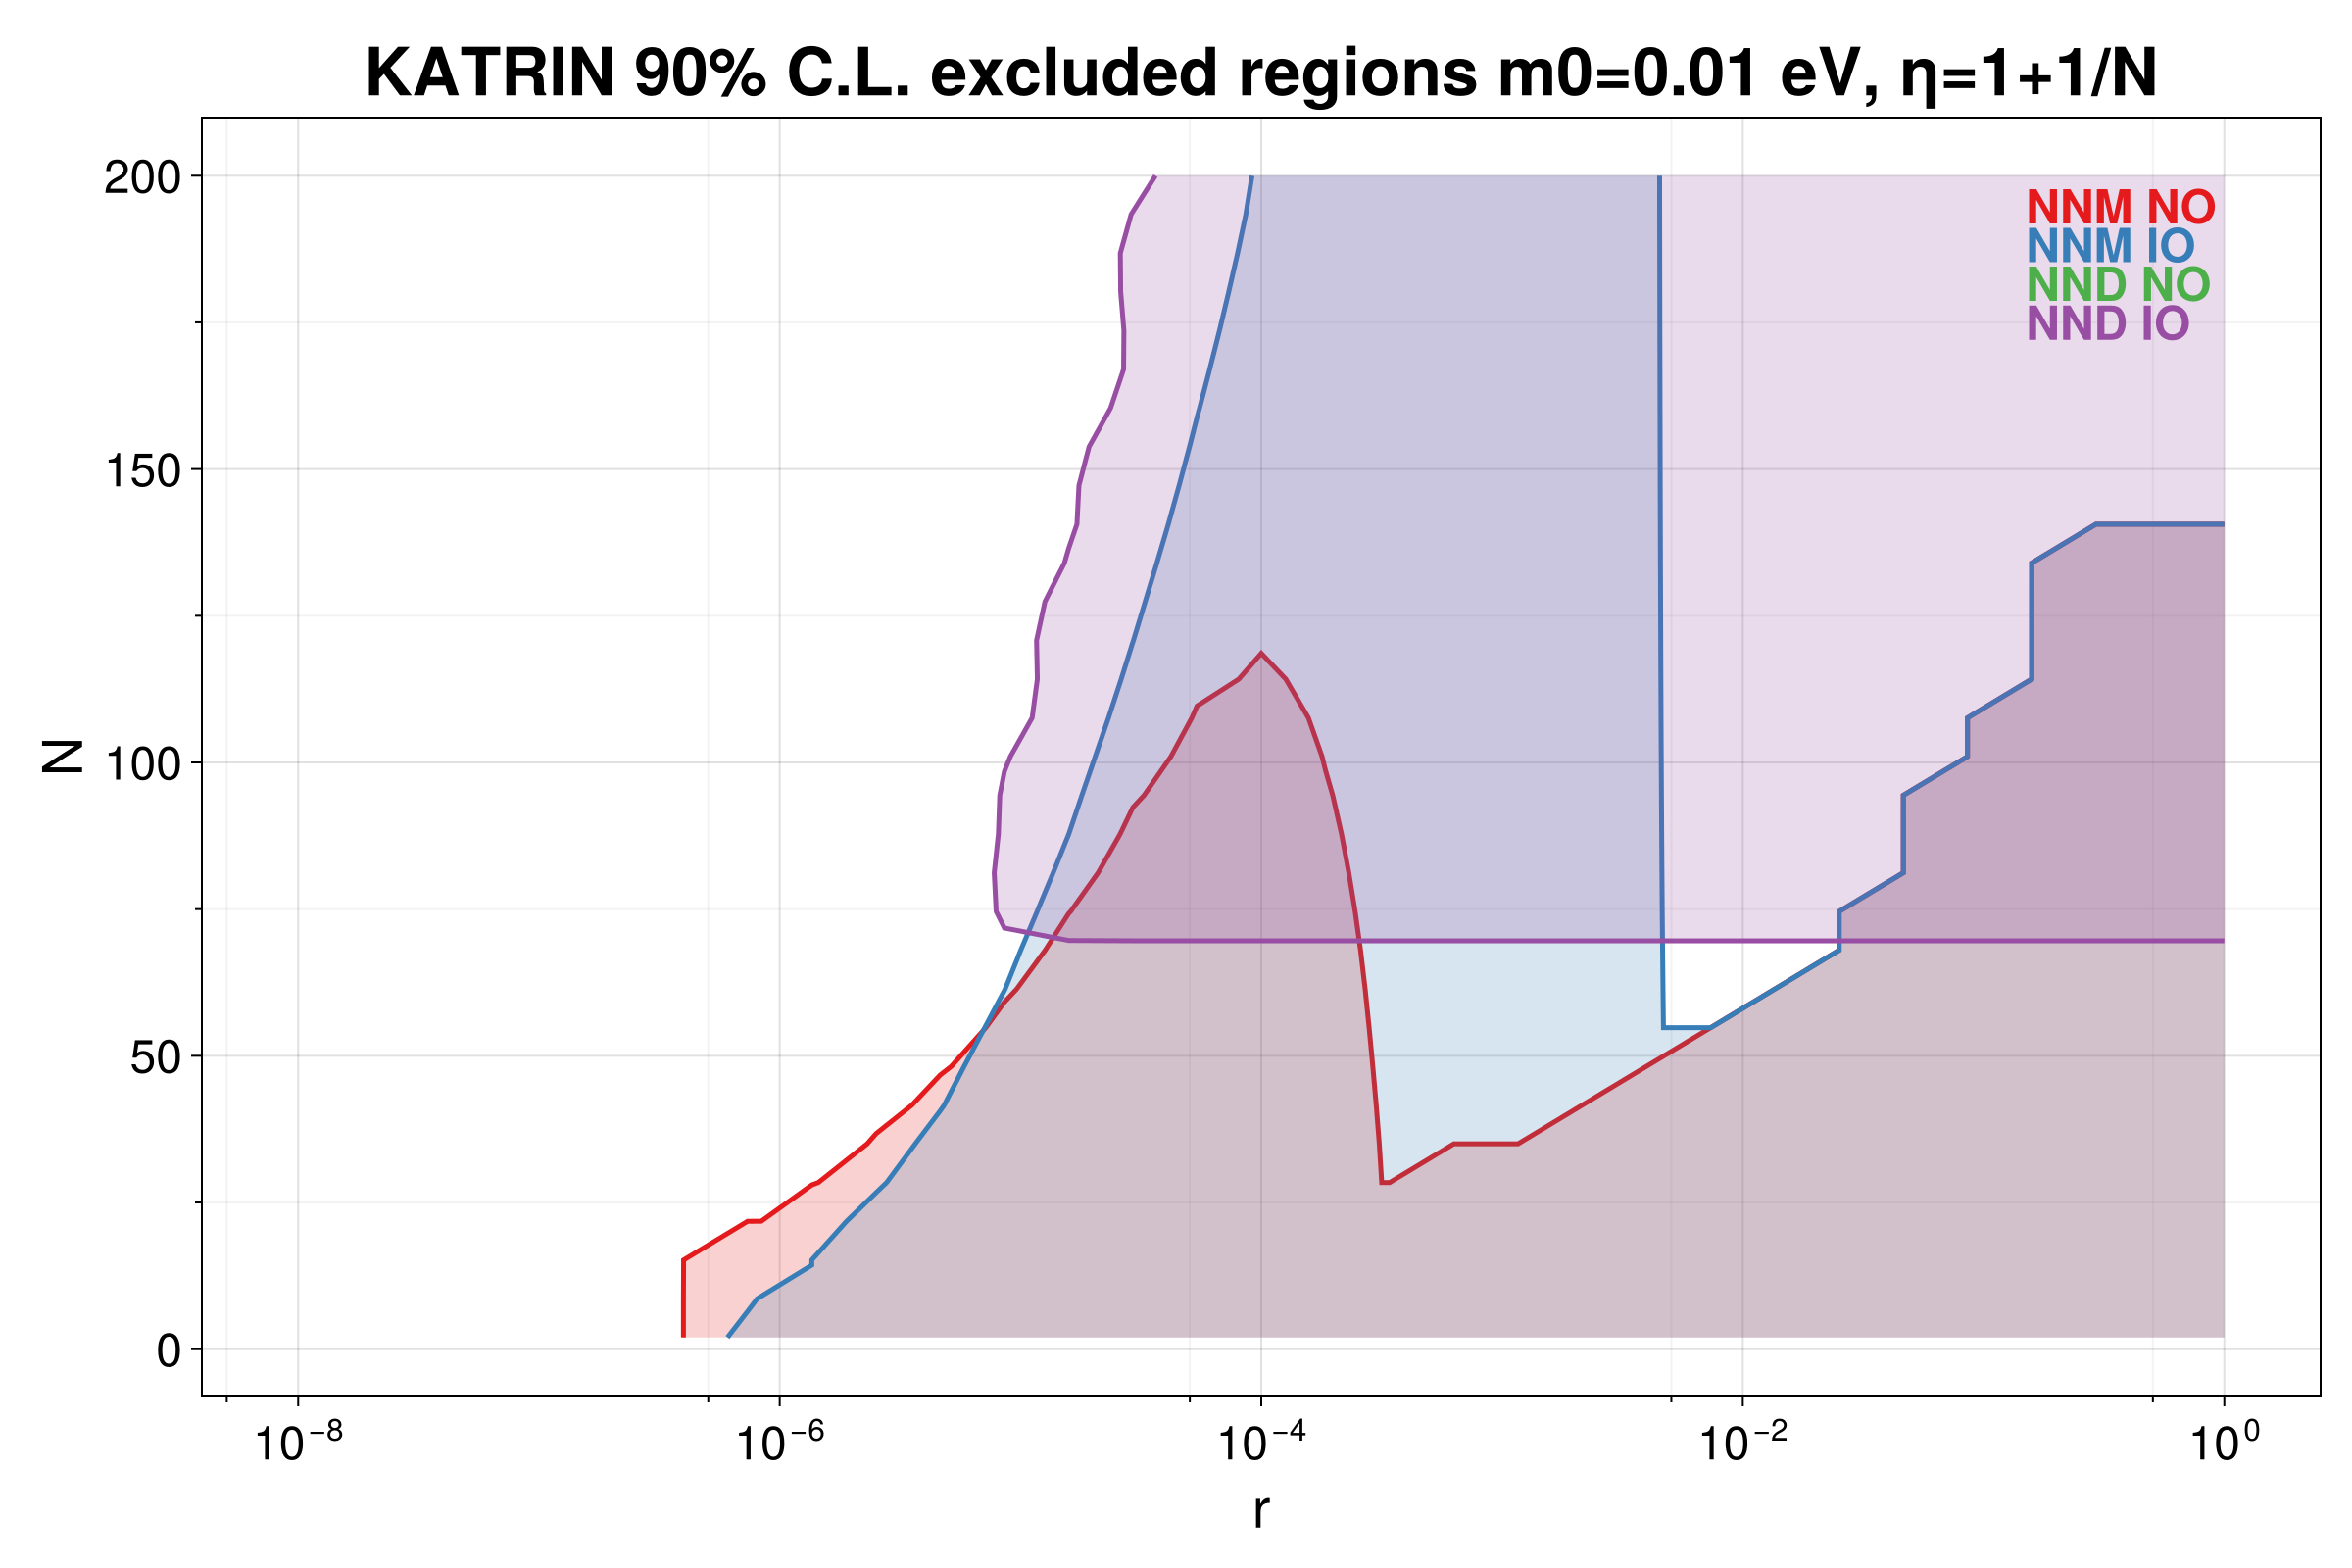

CairoMakie.Screen{SVG}


In [17]:
using ImageFiltering
using JLD2, CairoMakie, Distributions, Colors, ColorSchemes
using Newtrinos


function gaussian_smooth(Z; σ=1.0)
    kernel = Kernel.gaussian((σ, σ))
    return imfilter(Z, kernel, Pad(:replicate))
end



function superpose_contours_outside(file_paths::Vector{String}; 
                           title="Superposed Contours",
                           xlabel="Parameter 1", 
                           ylabel="Parameter 2",
                           experiments=nothing,
                           colorscheme=nothing,
                           color_step=1,
                           linestyles=nothing,
                           xscale=identity,
                           yscale=identity,
                           smooth_sigma::Union{Nothing,Float64}=nothing)
 
    
    # Default colorscheme and linestyles
    if colorscheme === nothing
        colorscheme = :Dark2_8
    end
    if linestyles === nothing
        linestyles = fill(:solid, length(file_paths))
    end
    
    # Get colors from the colorscheme with step
    cs = getproperty(ColorSchemes, colorscheme)
    all_colors = cs.colors
    colors = all_colors[1:color_step:end]
    n_colors = length(file_paths)
    if n_colors > length(colors)
        # If we need more colors than available, interpolate
        colors = [colors[i] for i in range(1, length(colors), length=n_colors)]
    else
        colors = colors[1:n_colors]
    end
    

    
  
    sigma_90_excluded_level = quantile(Chisq(2), 0.90)
    
    # Load all results and find axis ranges
    results = []
    all_axes_1 = []
    all_axes_2 = []
    
    for file_path in file_paths
        data = load(file_path)
        result = only(values(data)) # Adjust key if needed
        push!(results, result)
        push!(all_axes_1, result.axes[1])
        push!(all_axes_2, result.axes[2])
    end
    
    # Find combined axis ranges
    x_min = minimum([minimum(ax) for ax in all_axes_1])
    x_max = maximum([maximum(ax) for ax in all_axes_1])
    y_min = minimum([minimum(ax) for ax in all_axes_2])
    y_max = maximum([maximum(ax) for ax in all_axes_2])
        
    # Get axis labels from first result
    first_result = results[1]
    axis_labels = collect(keys(first_result.axes))

    # Create figure
    f = Figure(size=(1200, 800))
    ax = Axis(f[1,1];
        xlabel = String(axis_labels[1]) , #*"(eV)"
        ylabel = String(axis_labels[2]),
       title = title,
        xminorticksvisible = true, 
        xminorgridvisible = true, 
        yminorticksvisible = true, 
        yminorgridvisible = true,
        titlesize = 34,
        xlabelsize = 28,
        ylabelsize = 28,
        xticklabelsize = 24,
        yticklabelsize = 24,
        xscale = xscale,
        yscale = yscale
    )
   # Plot contours
    for (idx, result) in enumerate(results)

        dLLH_raw = 2 .* (maximum(result.values.log_posterior) .- result.values.log_posterior)

        dLLH = smooth_sigma === nothing ? dLLH_raw :
            gaussian_smooth(dLLH_raw; σ=smooth_sigma)

        # --- CLEAN FIELD (critical) ---
        dLLH_plot = copy(dLLH)
        dLLH_plot[.!isfinite.(dLLH_plot)] .= NaN

        maxlevel = maximum(skipmissing(vec(dLLH_plot)))
        ϵ = 1e-6  # numerical safety margin

        color = colors[idx]
        linestyle = linestyles[mod(idx-1, length(linestyles)) + 1]

        color_transparent = RGBA(color, 1.0)
        color_transparent_full = RGBA(color, 0.2)

        # --- SHADE ONLY IF EXCLUSION EXISTS ---
        if isfinite(maxlevel) && maxlevel > sigma_90_excluded_level + ϵ
            contourf!(ax,
                result.axes[1],
                result.axes[2],
                dLLH_plot;
                levels = [sigma_90_excluded_level, maxlevel],
                colormap = cgrad([color_transparent_full, color_transparent])
            )
        end

        # --- ALWAYS DRAW CONTOUR LINE ---
        contour!(ax,
            result.axes[1],
            result.axes[2],
            dLLH_plot;
            levels = [sigma_90_excluded_level],
            color = color,
            linewidth = 2.5,
            linestyle = linestyle
        )
        

    end
    if experiments !== nothing
        # Helper function to position in data space (works for log and linear)
        function position_in_range(min_val, max_val, fraction)
            if yscale == log10
                # Log scale: work in log space
                min_log = log10(min_val)
                max_log = log10(max_val)
                return 10 ^ (min_log + fraction * (max_log - min_log))
            else
                # Linear scale: work in linear space
                return min_val + fraction * (max_val - min_val)
            end
        end
        
        fractions_y = range(0.95, 0.85, length=length(experiments))
        y_positions = [position_in_range(y_min, y_max, f) for f in fractions_y]
        x_position = position_in_range(x_min, x_max, 0.15)
        
        for (idx, label) in enumerate(experiments)
            color = colors[idx]
            text!(ax, x_position, y_positions[idx], 
                  text = label,
                  fontsize = 24,
                  color = color,
                  font = :bold)
        end
    end
    
    f
end

file_paths = ["/home/sofialon/Newtrinos.jl/plot_auto/katrin/scan_katrin_rN_m0=0.01_NNM_NO.jld2",
               "/home/sofialon/Newtrinos.jl/plot_auto/katrin/scan_katrin_rN_m0=0.01_NNM_IO.jld2",
               "/home/sofialon/Newtrinos.jl/plot_auto/katrin/scan_katrin_rN_m0=0.01_NND_NO.jld2",
              "/home/sofialon/Newtrinos.jl/plot_auto/katrin/scan_katrin_rN_m0=0.01_NND_IO.jld2"]
                
fig = superpose_contours_outside(file_paths;  
    title="KATRIN 90% C.L. excluded regions m0=0.01 eV, η=1+1/N",
    experiments = ["NNM NO", "NNM IO", "NND NO", "NND IO"], 
    colorscheme = :Set1_9,
    color_step = 1,
    xscale=log10,
    #yscale=log10
    smooth_sigma=1.0)

display(fig)

save("/home/sofialon/Newtrinos.jl/plots_svg/katrin/superposed_contours_katrin_rN_m0.png", fig)
save("/home/sofialon/Newtrinos.jl/plots_svg/katrin/superposed_contours_katrin_rN_m0.svg", fig)


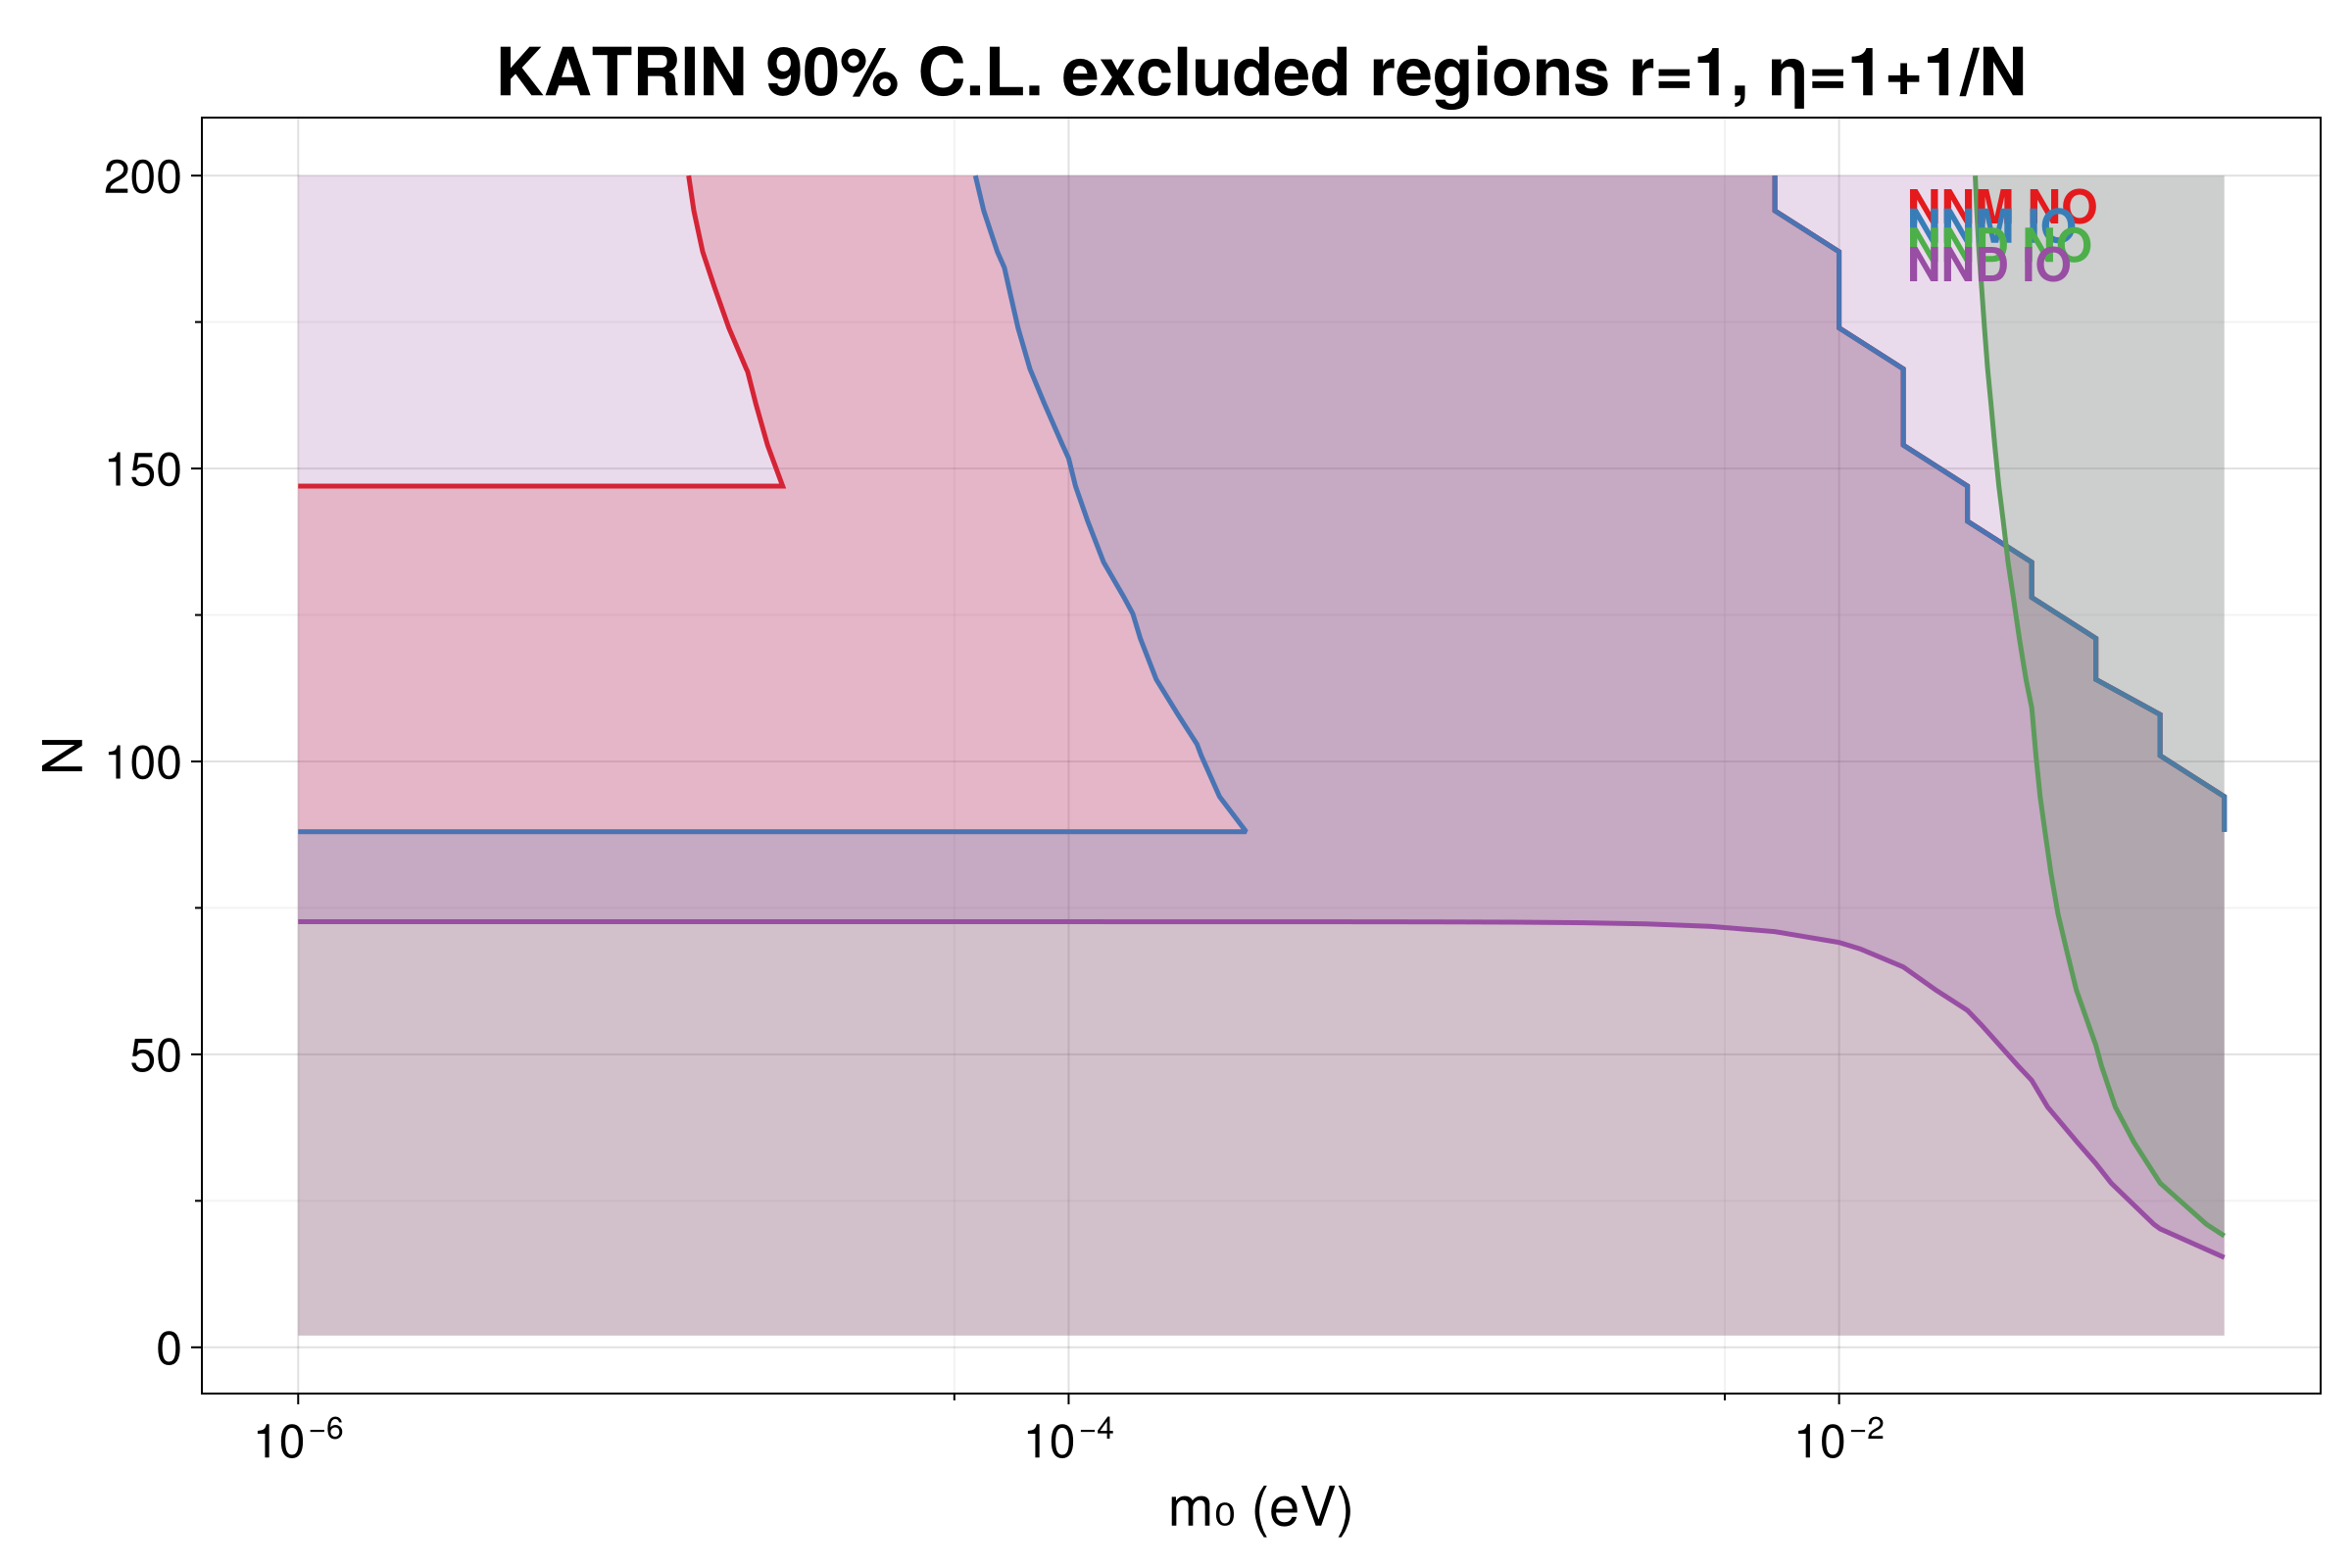

CairoMakie.Screen{SVG}


In [31]:

function superpose_contours_outside(file_paths::Vector{String}; 
                           title="Superposed Contours",
                           xlabel="Parameter 1", 
                           ylabel="Parameter 2",
                           experiments=nothing,
                           colorscheme=nothing,
                           color_step=1,
                           linestyles=nothing,
                           xscale=identity,
                           yscale=identity,
                           smooth_sigma::Union{Nothing,Float64}=nothing)
 
    
    # Default colorscheme and linestyles
    if colorscheme === nothing
        colorscheme = :Dark2_8
    end
    if linestyles === nothing
        linestyles = fill(:solid, length(file_paths))
    end
    
    # Get colors from the colorscheme with step
    cs = getproperty(ColorSchemes, colorscheme)
    all_colors = cs.colors
    colors = all_colors[1:color_step:end]
    n_colors = length(file_paths)
    if n_colors > length(colors)
        # If we need more colors than available, interpolate
        colors = [colors[i] for i in range(1, length(colors), length=n_colors)]
    else
        colors = colors[1:n_colors]
    end
    

    
  
    sigma_90_excluded_level = quantile(Chisq(2), 0.90)
    
    # Load all results and find axis ranges
    results = []
    all_axes_1 = []
    all_axes_2 = []
    
    for file_path in file_paths
        data = load(file_path)
        result = only(values(data)) # Adjust key if needed
        push!(results, result)
        push!(all_axes_1, result.axes[1])
        push!(all_axes_2, result.axes[2])
    end
    
    # Find combined axis ranges
    x_min = minimum([minimum(ax) for ax in all_axes_1])
    x_max = maximum([maximum(ax) for ax in all_axes_1])
    y_min = minimum([minimum(ax) for ax in all_axes_2])
    y_max = maximum([maximum(ax) for ax in all_axes_2])
        
    # Get axis labels from first result
    first_result = results[1]
    axis_labels = collect(keys(first_result.axes))

    # Create figure
    f = Figure(size=(1200, 800))
    ax = Axis(f[1,1];
        xlabel = String(axis_labels[1]) *" (eV)",
        ylabel = String(axis_labels[2]),
       title = title,
        xminorticksvisible = true, 
        xminorgridvisible = true, 
        yminorticksvisible = true, 
        yminorgridvisible = true,
        titlesize = 34,
        xlabelsize = 28,
        ylabelsize = 28,
        xticklabelsize = 24,
        yticklabelsize = 24,
        xscale = xscale,
        yscale = yscale
    )
   # Plot contours
    for (idx, result) in enumerate(results)

        dLLH_raw = 2 .* (maximum(result.values.log_posterior) .- result.values.log_posterior)

        dLLH = smooth_sigma === nothing ? dLLH_raw :
            gaussian_smooth(dLLH_raw; σ=smooth_sigma)

        # --- CLEAN FIELD (critical) ---
        dLLH_plot = copy(dLLH)
        dLLH_plot[.!isfinite.(dLLH_plot)] .= NaN

        maxlevel = maximum(skipmissing(vec(dLLH_plot)))
        ϵ = 1e-6  # numerical safety margin

        color = colors[idx]
        linestyle = linestyles[mod(idx-1, length(linestyles)) + 1]

        color_transparent = RGBA(color, 1.0)
        color_transparent_full = RGBA(color, 0.2)

        # --- SHADE ONLY IF EXCLUSION EXISTS ---
        if isfinite(maxlevel) && maxlevel > sigma_90_excluded_level + ϵ
            contourf!(ax,
                result.axes[1],
                result.axes[2],
                dLLH_plot;
                levels = [sigma_90_excluded_level, maxlevel],
                colormap = cgrad([color_transparent_full, color_transparent])
            )
        end

        # --- ALWAYS DRAW CONTOUR LINE ---
        contour!(ax,
            result.axes[1],
            result.axes[2],
            dLLH_plot;
            levels = [sigma_90_excluded_level],
            color = color,
            linewidth = 2.5,
            linestyle = linestyle
        )
        

    end
    if experiments !== nothing
        # Helper function to position in data space (works for log and linear)
        function position_in_range(min_val, max_val, fraction)
            if yscale == log10
                # Log scale: work in log space
                min_log = log10(min_val)
                max_log = log10(max_val)
                return 10 ^ (min_log + fraction * (max_log - min_log))
            else
                # Linear scale: work in linear space
                return min_val + fraction * (max_val - min_val)
            end
        end
        
        fractions_y = range(0.95, 0.90, length=length(experiments))
        y_positions = [position_in_range(y_min, y_max, f) for f in fractions_y]
        x_position = position_in_range(x_min, x_max, 0.15)
        
        for (idx, label) in enumerate(experiments)
            color = colors[idx]
            text!(ax, x_position, y_positions[idx], 
                  text = label,
                  fontsize = 24,
                  color = color,
                  font = :bold)
        end
    end
    
    f
end

file_paths = ["/home/sofialon/Newtrinos.jl/plot_auto/katrin/scan_katrin_m0N_r=1.0_NNM_NO.jld2",
               "/home/sofialon/Newtrinos.jl/plot_auto/katrin/scan_katrin_m0N_r=1.0_NNM_IO.jld2",
               "/home/sofialon/Newtrinos.jl/plot_auto/katrin/scan_katrin_m0N_r=1.0_NND_NO.jld2",
               "/home/sofialon/Newtrinos.jl/plot_auto/katrin/scan_katrin_m0N_r=1.0_NND_IO.jld2",
               ]
                
fig = superpose_contours_outside(file_paths;  
    title="KATRIN 90% C.L. excluded regions r=1, η=1+1/N",
    experiments = ["NNM NO", "NNM IO", "NND NO", "NND IO"], 
    colorscheme = :Set1_9,
    color_step = 1,
    xscale=log10,
    #yscale=log10
    smooth_sigma=1.0)

display(fig)

save("/home/sofialon/Newtrinos.jl/plots_svg/katrin/superposed_contours_katrin_m0N.png", fig)
save("/home/sofialon/Newtrinos.jl/plots_svg/katrin/superposed_contours_katrin_m0N.svg", fig)


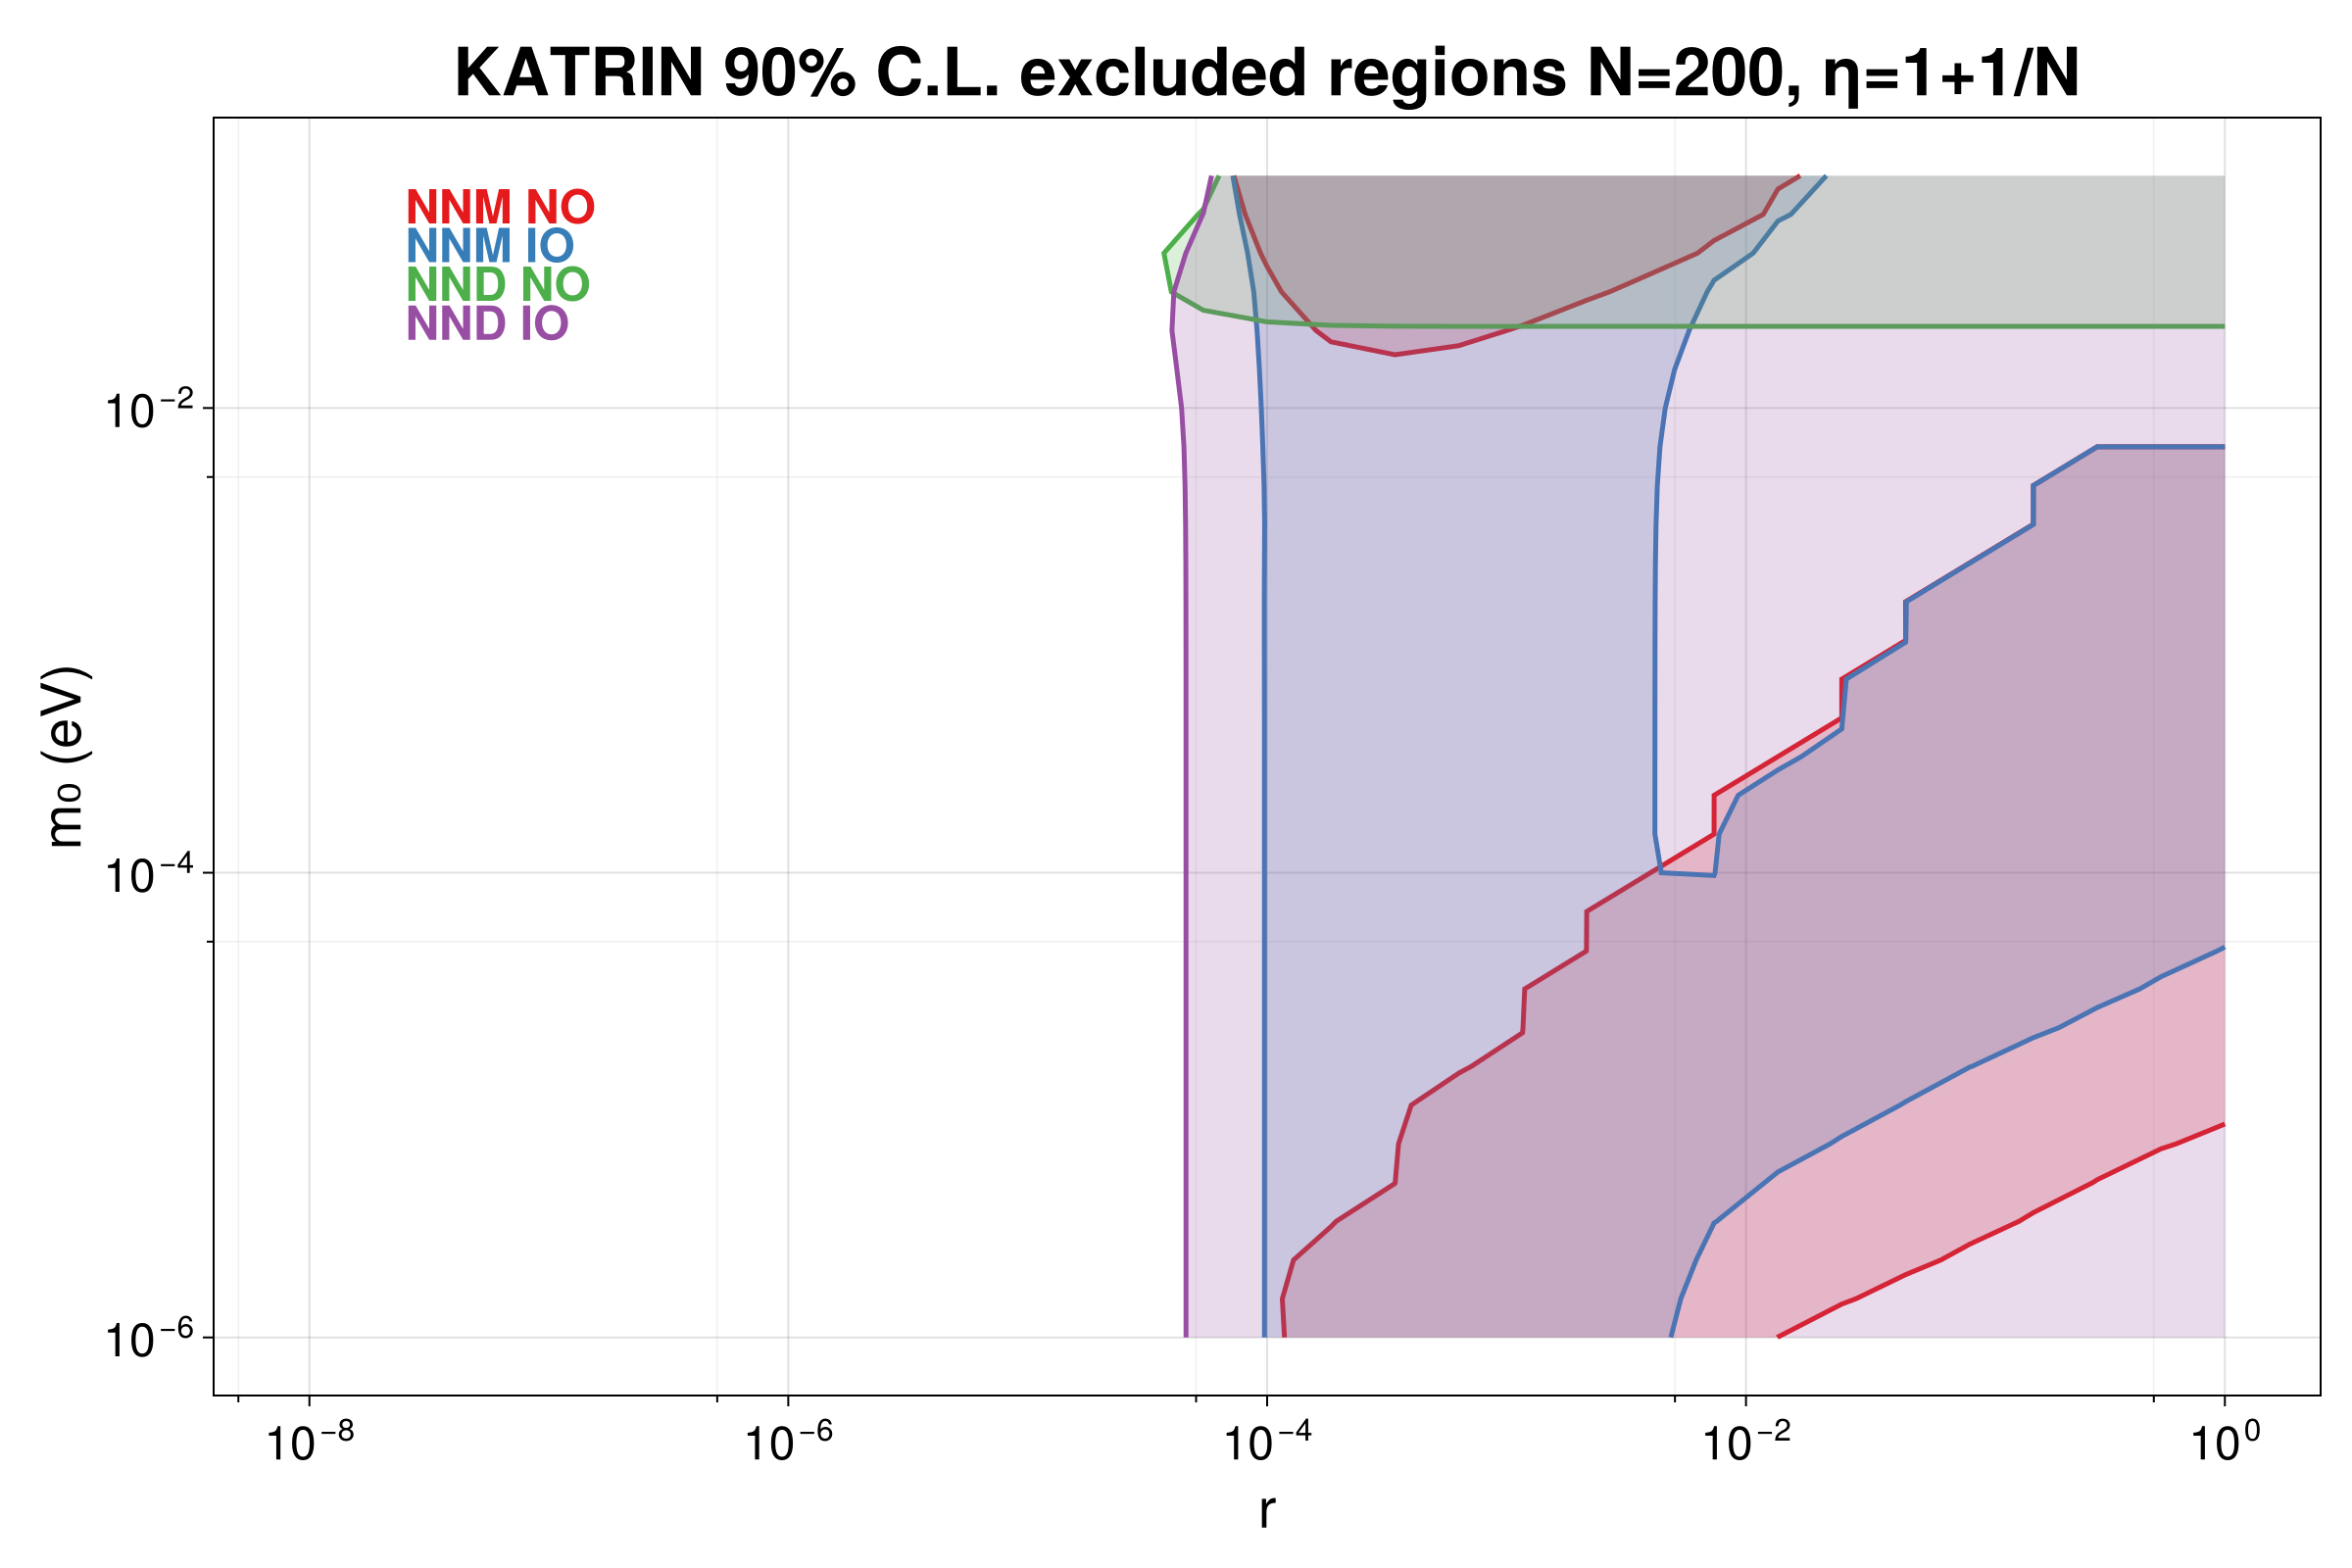

CairoMakie.Screen{SVG}


In [28]:

function superpose_contours_outside(file_paths::Vector{String}; 
                           title="Superposed Contours",
                           xlabel="Parameter 1", 
                           ylabel="Parameter 2",
                           experiments=nothing,
                           colorscheme=nothing,
                           color_step=1,
                           linestyles=nothing,
                           xscale=identity,
                           yscale=identity,
                           smooth_sigma::Union{Nothing,Float64}=nothing)
 
    
    # Default colorscheme and linestyles
    if colorscheme === nothing
        colorscheme = :Dark2_8
    end
    if linestyles === nothing
        linestyles = fill(:solid, length(file_paths))
    end
    
    # Get colors from the colorscheme with step
    cs = getproperty(ColorSchemes, colorscheme)
    all_colors = cs.colors
    colors = all_colors[1:color_step:end]
    n_colors = length(file_paths)
    if n_colors > length(colors)
        # If we need more colors than available, interpolate
        colors = [colors[i] for i in range(1, length(colors), length=n_colors)]
    else
        colors = colors[1:n_colors]
    end
    

    
  
    sigma_90_excluded_level = quantile(Chisq(2), 0.90)
    
    # Load all results and find axis ranges
    results = []
    all_axes_1 = []
    all_axes_2 = []
    
    for file_path in file_paths
        data = load(file_path)
        result = only(values(data)) # Adjust key if needed
        push!(results, result)
        push!(all_axes_1, result.axes[1])
        push!(all_axes_2, result.axes[2])
    end
    
    # Find combined axis ranges
    x_min = minimum([minimum(ax) for ax in all_axes_1])
    x_max = maximum([maximum(ax) for ax in all_axes_1])
    y_min = minimum([minimum(ax) for ax in all_axes_2])
    y_max = maximum([maximum(ax) for ax in all_axes_2])
        
    # Get axis labels from first result
    first_result = results[1]
    axis_labels = collect(keys(first_result.axes))

    # Create figure
    f = Figure(size=(1200, 800))
    ax = Axis(f[1,1];
        xlabel = String(axis_labels[1]) ,
        ylabel = String(axis_labels[2])*" (eV)",
       title = title,
        xminorticksvisible = true, 
        xminorgridvisible = true, 
        yminorticksvisible = true, 
        yminorgridvisible = true,
        titlesize = 34,
        xlabelsize = 28,
        ylabelsize = 28,
        xticklabelsize = 24,
        yticklabelsize = 24,
        xscale = xscale,
        yscale = yscale
    )
   # Plot contours
    for (idx, result) in enumerate(results)

        dLLH_raw = 2 .* (maximum(result.values.log_posterior) .- result.values.log_posterior)

        dLLH = smooth_sigma === nothing ? dLLH_raw :
            gaussian_smooth(dLLH_raw; σ=smooth_sigma)

        # --- CLEAN FIELD (critical) ---
        dLLH_plot = copy(dLLH)
        dLLH_plot[.!isfinite.(dLLH_plot)] .= NaN

        maxlevel = maximum(skipmissing(vec(dLLH_plot)))
        ϵ = 1e-6  # numerical safety margin

        color = colors[idx]
        linestyle = linestyles[mod(idx-1, length(linestyles)) + 1]

        color_transparent = RGBA(color, 1.0)
        color_transparent_full = RGBA(color, 0.2)

        # --- SHADE ONLY IF EXCLUSION EXISTS ---
        if isfinite(maxlevel) && maxlevel > sigma_90_excluded_level + ϵ
            contourf!(ax,
                result.axes[1],
                result.axes[2],
                dLLH_plot;
                levels = [sigma_90_excluded_level, maxlevel],
                colormap = cgrad([color_transparent_full, color_transparent])
            )
        end

        # --- ALWAYS DRAW CONTOUR LINE ---
        contour!(ax,
            result.axes[1],
            result.axes[2],
            dLLH_plot;
            levels = [sigma_90_excluded_level],
            color = color,
            linewidth = 2.5,
            linestyle = linestyle
        )
        

    end
    if experiments !== nothing
        # Helper function to position in data space (works for log and linear)
        function position_in_range(min_val, max_val, fraction)
            if yscale == log10
                # Log scale: work in log space
                min_log = log10(min_val)
                max_log = log10(max_val)
                return 10 ^ (min_log + fraction * (max_log - min_log))
            else
                # Linear scale: work in linear space
                return min_val + fraction * (max_val - min_val)
            end
        end
        
        fractions_y = range(0.95, 0.85, length=length(experiments))
        y_positions = [position_in_range(y_min, y_max, f) for f in fractions_y]
        x_position = position_in_range(x_min, x_max, 0.05)
        
        for (idx, label) in enumerate(experiments)
            color = colors[idx]
            text!(ax, x_position, y_positions[idx], 
                  text = label,
                  fontsize = 24,
                  color = color,
                  font = :bold)
        end
    end
    
    f
end

file_paths = ["/home/sofialon/Newtrinos.jl/plot_auto/katrin/scan_katrin_rm0_N=200_NNM_NO.jld2",
               "/home/sofialon/Newtrinos.jl/plot_auto/katrin/scan_katrin_rm0_N=200_NNM_IO.jld2",
               "/home/sofialon/Newtrinos.jl/plot_auto/katrin/scan_katrin_rm0_N=200_NND_NO.jld2",
               "/home/sofialon/Newtrinos.jl/plot_auto/katrin/scan_katrin_rm0_N=200_NND_IO.jld2"]
                
fig = superpose_contours_outside(file_paths;  
    title="KATRIN 90% C.L. excluded regions N=200, η=1+1/N",
    experiments = ["NNM NO", "NNM IO", "NND NO", "NND IO"], 
    colorscheme = :Set1_9,
    color_step = 1,
    xscale=log10,
    yscale=log10,
    smooth_sigma=1.0)

display(fig)

save("/home/sofialon/Newtrinos.jl/plots_svg/katrin/superposed_contours_katrin_rm0_N=200.png", fig)
save("/home/sofialon/Newtrinos.jl/plots_svg/katrin/superposed_contours_katrin_rm0_N=200.svg", fig)


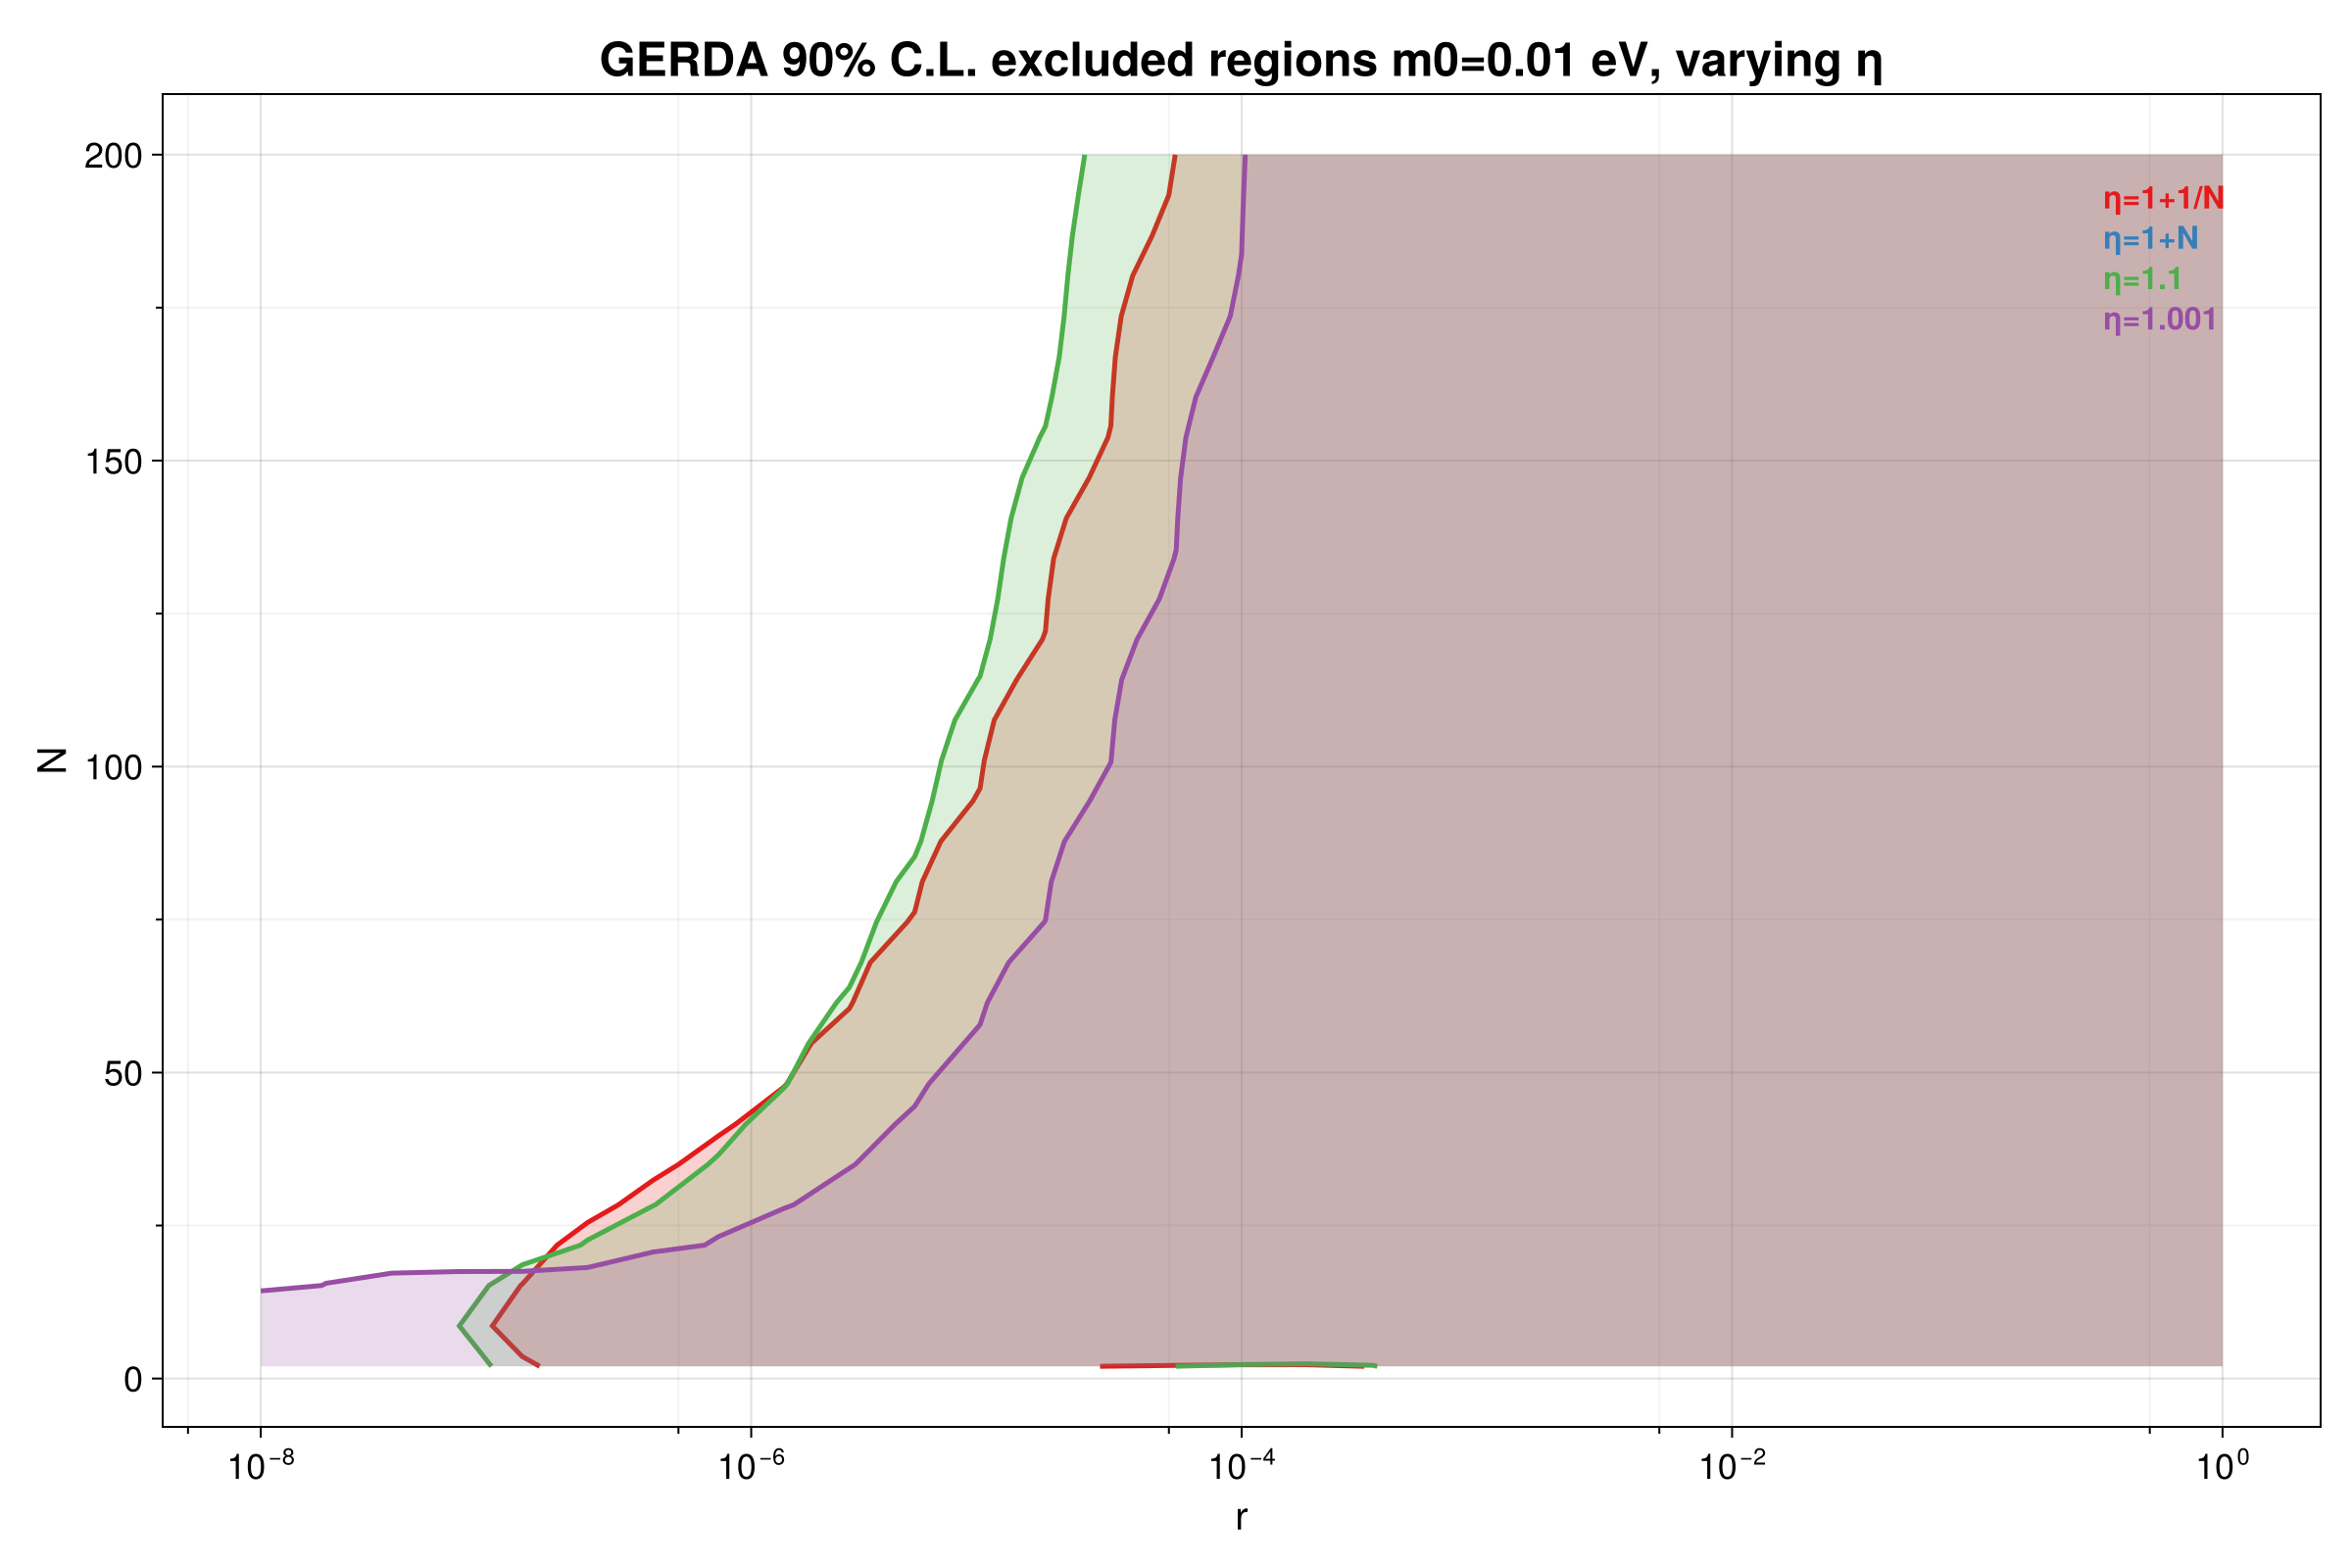

In [14]:
using ImageFiltering
using JLD2, CairoMakie, Distributions, Colors, ColorSchemes
using Newtrinos


function gaussian_smooth(Z; σ=1.0)
    kernel = Kernel.gaussian((σ, σ))
    return imfilter(Z, kernel, Pad(:replicate))
end



function superpose_contours_outside(file_paths::Vector{String}; 
                           title="Superposed Contours",
                           xlabel="Parameter 1", 
                           ylabel="Parameter 2",
                           experiments=nothing,
                           colorscheme=nothing,
                           color_step=1,
                           linestyles=nothing,
                           xscale=identity,
                           yscale=identity,
                           smooth_sigma::Union{Nothing,Float64}=nothing)
 
    
    # Default colorscheme and linestyles
    if colorscheme === nothing
        colorscheme = :Dark2_8
    end
    if linestyles === nothing
        linestyles = fill(:solid, length(file_paths))
    end
    
    # Get colors from the colorscheme with step
    cs = getproperty(ColorSchemes, colorscheme)
    all_colors = cs.colors
    colors = all_colors[1:color_step:end]
    n_colors = length(file_paths)
    if n_colors > length(colors)
        # If we need more colors than available, interpolate
        colors = [colors[i] for i in range(1, length(colors), length=n_colors)]
    else
        colors = colors[1:n_colors]
    end
    

    
  
    sigma_90_excluded_level = quantile(Chisq(2), 0.90)
    
    # Load all results and find axis ranges
    results = []
    all_axes_1 = []
    all_axes_2 = []
    
    for file_path in file_paths
        result = load(file_path)["result"]  # Adjust key if needed
        push!(results, result)
        push!(all_axes_1, result.axes[1])
        push!(all_axes_2, result.axes[2])
    end
    
    # Find combined axis ranges
    x_min = minimum([minimum(ax) for ax in all_axes_1])
    x_max = maximum([maximum(ax) for ax in all_axes_1])
    y_min = minimum([minimum(ax) for ax in all_axes_2])
    y_max = maximum([maximum(ax) for ax in all_axes_2])
        
    # Get axis labels from first result
    first_result = results[1]
    axis_labels = collect(keys(first_result.axes))

    # Create figure
    f = Figure(size=(1200, 800))
    ax = Axis(f[1,1];
        xlabel = String(axis_labels[1]) , #*"(eV)"
        ylabel = String(axis_labels[2]),
        title = title,
        xminorticksvisible = true, 
        xminorgridvisible = true, 
        yminorticksvisible = true, 
        yminorgridvisible = true,
        titlesize = 24,
        xlabelsize = 20,
        ylabelsize = 20,
        xticklabelsize = 18,
        yticklabelsize = 18,
        xscale = xscale,
        yscale = yscale
    )
   # Plot contours
    for (idx, result) in enumerate(results)

        dLLH_raw = 2 .* (maximum(result.values.log_posterior) .- result.values.log_posterior)

        dLLH = smooth_sigma === nothing ? dLLH_raw :
            gaussian_smooth(dLLH_raw; σ=smooth_sigma)

        # --- CLEAN FIELD (critical) ---
        dLLH_plot = copy(dLLH)
        dLLH_plot[.!isfinite.(dLLH_plot)] .= NaN

        maxlevel = maximum(skipmissing(vec(dLLH_plot)))
        ϵ = 1e-6  # numerical safety margin

        color = colors[idx]
        linestyle = linestyles[mod(idx-1, length(linestyles)) + 1]

        color_transparent = RGBA(color, 1.0)
        color_transparent_full = RGBA(color, 0.2)

        # --- SHADE ONLY IF EXCLUSION EXISTS ---
        if isfinite(maxlevel) && maxlevel > sigma_90_excluded_level + ϵ
            contourf!(ax,
                result.axes[1],
                result.axes[2],
                dLLH_plot;
                levels = [sigma_90_excluded_level, maxlevel],
                colormap = cgrad([color_transparent_full, color_transparent])
            )
        end

        # --- ALWAYS DRAW CONTOUR LINE ---
        contour!(ax,
            result.axes[1],
            result.axes[2],
            dLLH_plot;
            levels = [sigma_90_excluded_level],
            color = color,
            linewidth = 2.5,
            linestyle = linestyle
        )
        

    end
    if experiments !== nothing
        # Helper function to position in data space (works for log and linear)
        function position_in_range(min_val, max_val, fraction)
            if yscale == log10
                # Log scale: work in log space
                min_log = log10(min_val)
                max_log = log10(max_val)
                return 10 ^ (min_log + fraction * (max_log - min_log))
            else
                # Linear scale: work in linear space
                return min_val + fraction * (max_val - min_val)
            end
        end
        
        fractions_y = range(0.95, 0.85, length=length(experiments))
        y_positions = [position_in_range(y_min, y_max, f) for f in fractions_y]
        x_position = position_in_range(x_min, x_max, 0.3)
        
        for (idx, label) in enumerate(experiments)
            color = colors[idx]
            text!(ax, x_position, y_positions[idx], 
                  text = label,
                  fontsize = 16,
                  color = color,
                  font = :bold)
        end
    end
    
    f
end


file_paths = ["/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_gerda_Nr_m0=0.01_η=1+1N_NNM_NO.jld2",
                "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_gerda_Nr_m0=0.01_η=1+N_NNM_NO.jld2",
                "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_gerda_Nr_m0=0.01_η=1.1_NNM_NO.jld2",
                "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_gerda_Nr_m0=0.01_η=1.001_NNM_NO.jld2"]
                
fig = superpose_contours_outside(file_paths;  
    title="GERDA 90% C.L. excluded regions m0=0.01 eV, varying η",
    experiments = [" η=1+1/N", " η=1+N", " η=1.1", " η=1.001"], 
    colorscheme = :Set1_9,
    color_step = 1,
    xscale=log10,
    #yscale=log10
    smooth_sigma=0.8)

display("image/png", fig)
#save("/home/sofialon/Newtrinos.jl/plots_fix/plots_newex/superposed_contours_gerda_rN_eta.png", fig)



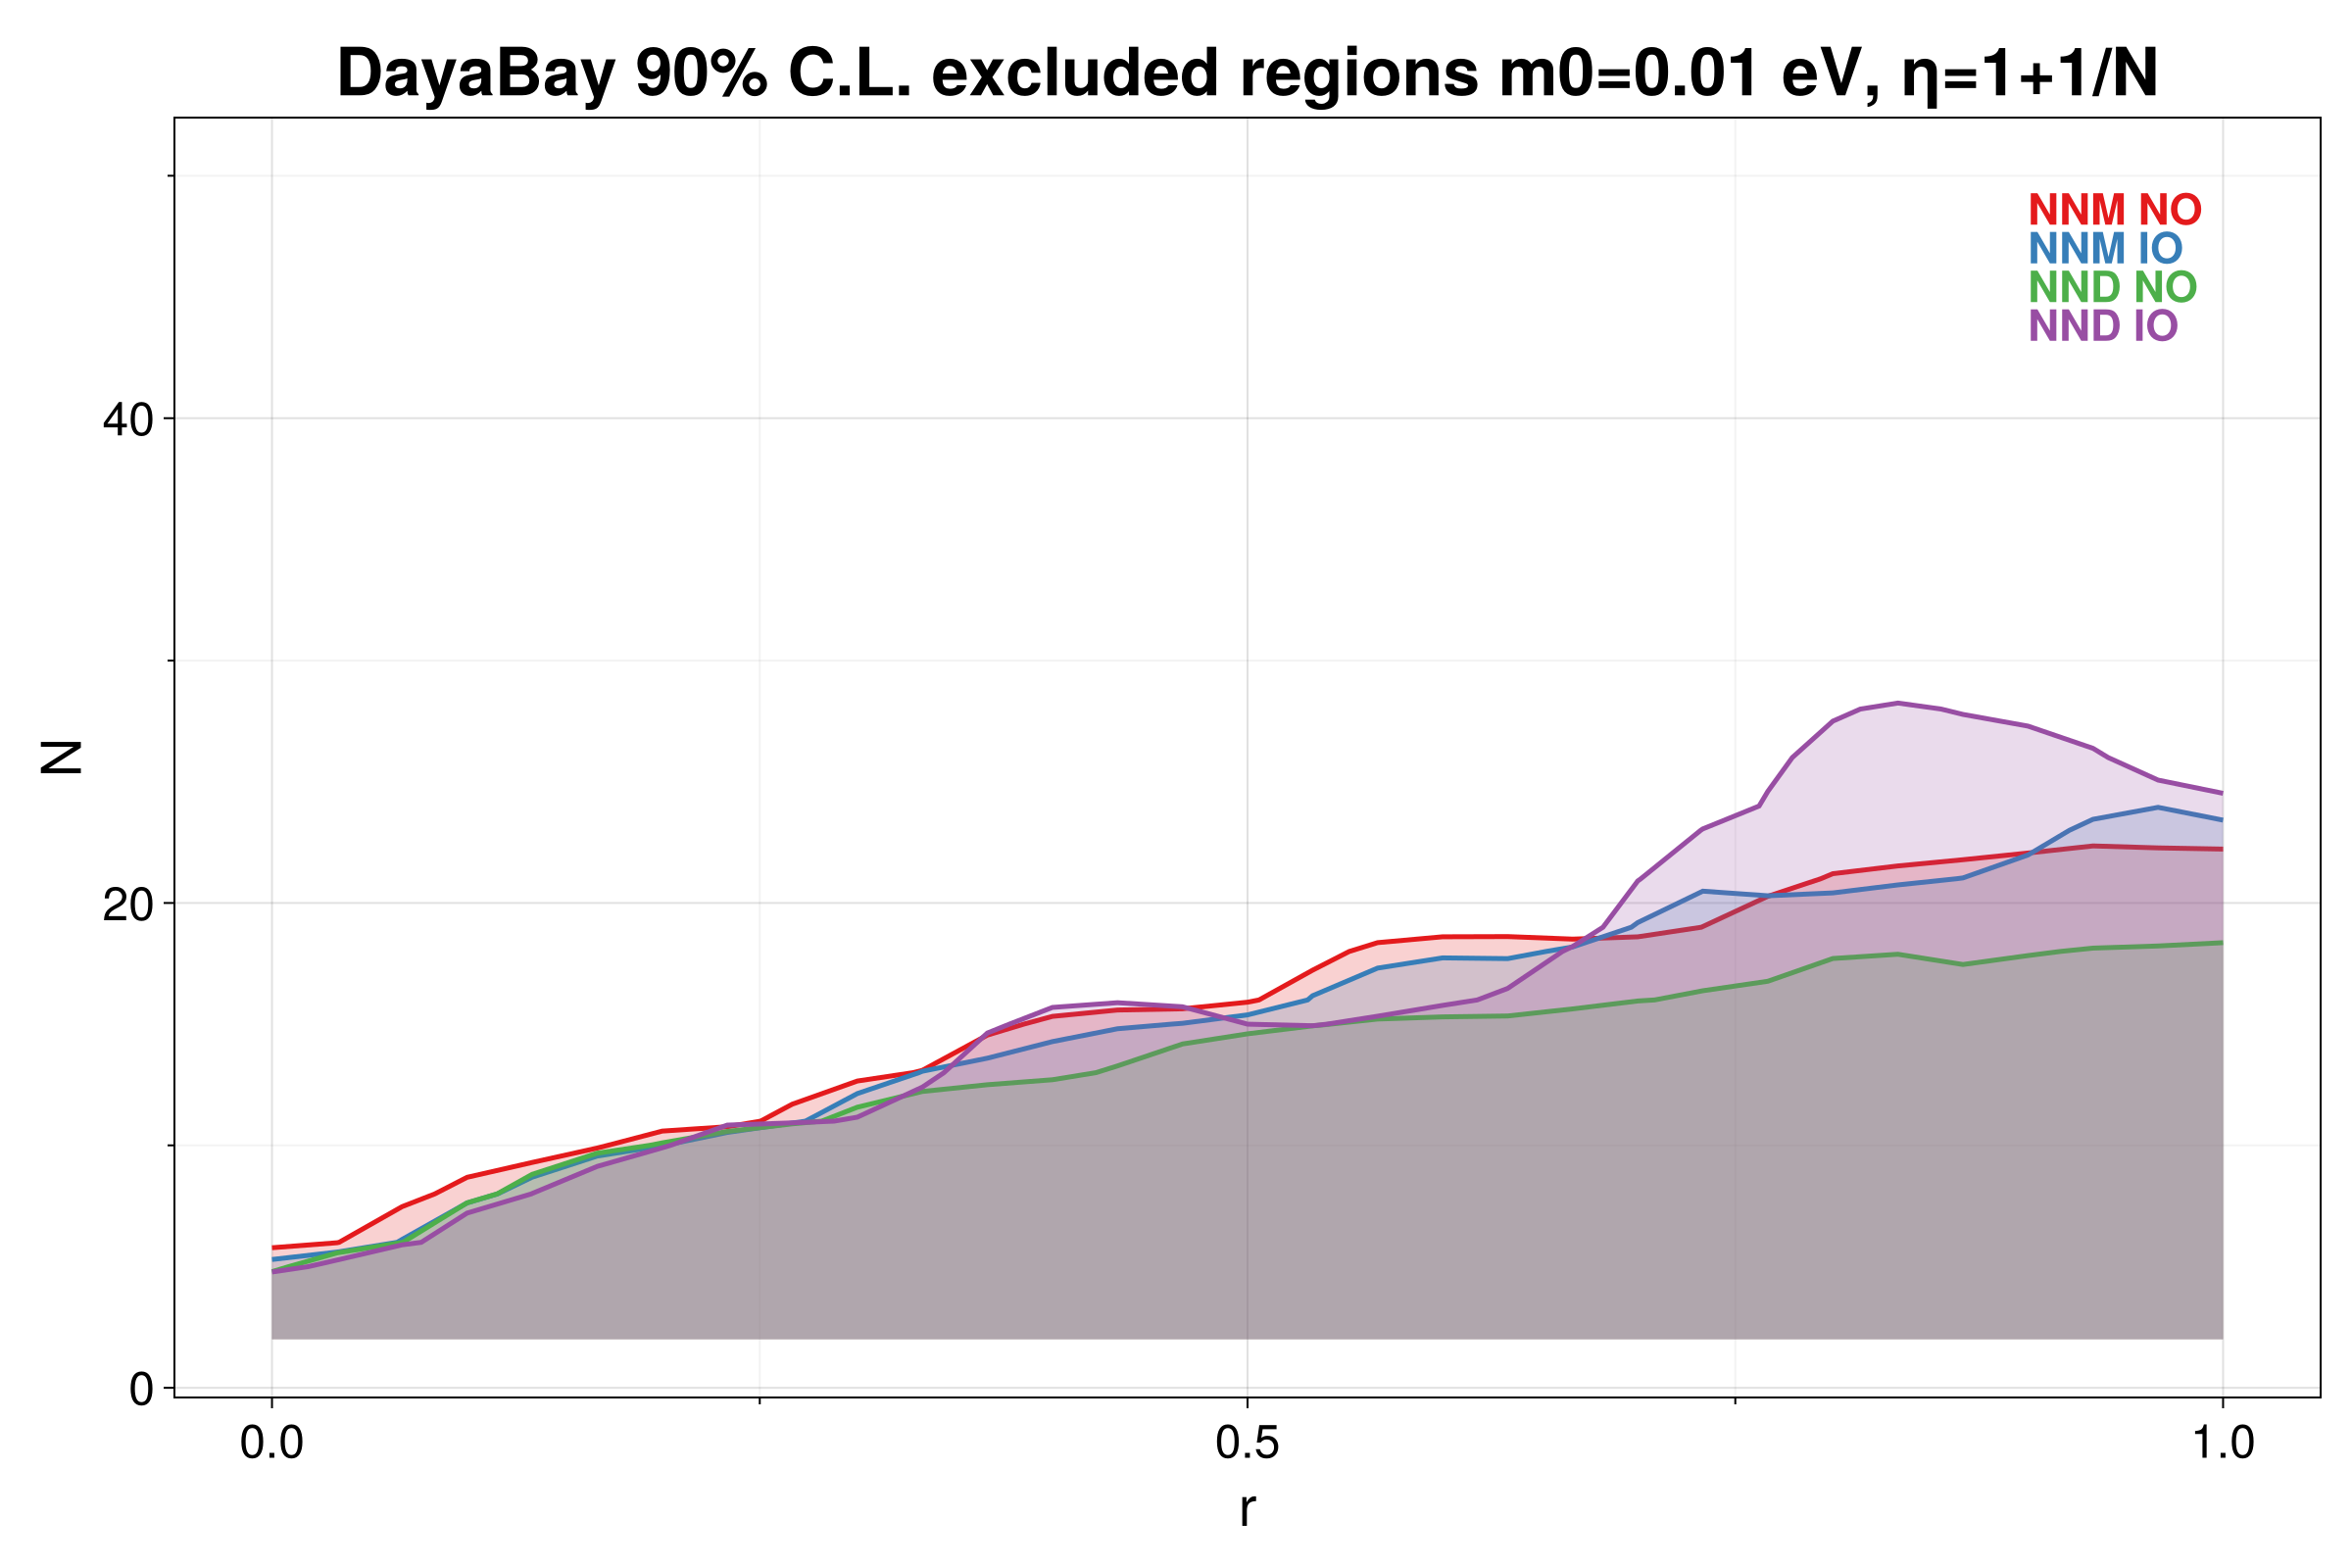

CairoMakie.Screen{SVG}


In [6]:
using ImageFiltering
using JLD2, CairoMakie, Distributions, Colors, ColorSchemes
using Newtrinos


function gaussian_smooth(Z; σ=1.0)
    kernel = Kernel.gaussian((σ, σ))
    return imfilter(Z, kernel, Pad(:replicate))
end



function superpose_contours_outside(file_paths::Vector{String}; 
                           title="Superposed Contours",
                           xlabel="Parameter 1", 
                           ylabel="Parameter 2",
                           experiments=nothing,
                           colorscheme=nothing,
                           color_step=1,
                           linestyles=nothing,
                           xscale=identity,
                           yscale=identity,
                           smooth_sigma::Union{Nothing,Float64}=nothing)
 
    
    # Default colorscheme and linestyles
    if colorscheme === nothing
        colorscheme = :Dark2_8
    end
    if linestyles === nothing
        linestyles = fill(:solid, length(file_paths))
    end
    
    # Get colors from the colorscheme with step
    cs = getproperty(ColorSchemes, colorscheme)
    all_colors = cs.colors
    colors = all_colors[1:color_step:end]
    n_colors = length(file_paths)
    if n_colors > length(colors)
        # If we need more colors than available, interpolate
        colors = [colors[i] for i in range(1, length(colors), length=n_colors)]
    else
        colors = colors[1:n_colors]
    end
    

    
  
    sigma_90_excluded_level = quantile(Chisq(2), 0.90)
    
    # Load all results and find axis ranges
    results = []
    all_axes_1 = []
    all_axes_2 = []
    
    for file_path in file_paths
        result = load(file_path)["result"]  # Adjust key if needed
        push!(results, result)
        push!(all_axes_1, result.axes[1])
        push!(all_axes_2, result.axes[2])
    end
    
    # Find combined axis ranges
    x_min = minimum([minimum(ax) for ax in all_axes_1])
    x_max = maximum([maximum(ax) for ax in all_axes_1])
    y_min = minimum([minimum(ax) for ax in all_axes_2])
    y_max = maximum([maximum(ax) for ax in all_axes_2])
        
    # Get axis labels from first result
    first_result = results[1]
    axis_labels = collect(keys(first_result.axes))

    # Create figure
    f = Figure(size=(1200, 800))
    ax = Axis(f[1,1];
        xlabel = String(axis_labels[1]) , #*"(eV)"
        ylabel = String(axis_labels[2]),
        title = title,
        xminorticksvisible = true, 
        xminorgridvisible = true, 
        yminorticksvisible = true, 
        yminorgridvisible = true,
        titlesize = 34,
        xlabelsize = 28,
        ylabelsize = 28,
        xticklabelsize = 24,
        yticklabelsize = 24,
        xscale = xscale,
        yscale = yscale
    )
   # Plot contours
    for (idx, result) in enumerate(results)

        dLLH_raw = 2 .* (maximum(result.values.log_posterior) .- result.values.log_posterior)

        dLLH = smooth_sigma === nothing ? dLLH_raw :
            gaussian_smooth(dLLH_raw; σ=smooth_sigma)

        # --- CLEAN FIELD (critical) ---
        dLLH_plot = copy(dLLH)
        dLLH_plot[.!isfinite.(dLLH_plot)] .= NaN

        maxlevel = maximum(skipmissing(vec(dLLH_plot)))
        ϵ = 1e-6  # numerical safety margin

        color = colors[idx]
        linestyle = linestyles[mod(idx-1, length(linestyles)) + 1]

        color_transparent = RGBA(color, 1.0)
        color_transparent_full = RGBA(color, 0.2)

        # --- SHADE ONLY IF EXCLUSION EXISTS ---
        if isfinite(maxlevel) && maxlevel > sigma_90_excluded_level + ϵ
            contourf!(ax,
                result.axes[1],
                result.axes[2],
                dLLH_plot;
                levels = [sigma_90_excluded_level, maxlevel],
                colormap = cgrad([color_transparent_full, color_transparent])
            )
        end

        # --- ALWAYS DRAW CONTOUR LINE ---
        contour!(ax,
            result.axes[1],
            result.axes[2],
            dLLH_plot;
            levels = [sigma_90_excluded_level],
            color = color,
            linewidth = 2.5,
            linestyle = linestyle
        )
        

    end
    if experiments !== nothing
        # Helper function to position in data space (works for log and linear)
        function position_in_range(min_val, max_val, fraction)
            if yscale == log10
                # Log scale: work in log space
                min_log = log10(min_val)
                max_log = log10(max_val)
                return 10 ^ (min_log + fraction * (max_log - min_log))
            else
                # Linear scale: work in linear space
                return min_val + fraction * (max_val - min_val)
            end
        end
        
        fractions_y = range(0.95, 0.85, length=length(experiments))
        y_positions = [position_in_range(y_min, y_max, f) for f in fractions_y]
        x_position = position_in_range(x_min, x_max, 0.9)
        
        for (idx, label) in enumerate(experiments)
            color = colors[idx]
            text!(ax, x_position, y_positions[idx], 
                  text = label,
                  fontsize = 22,
                  color = color,
                  font = :bold)
        end
    end
    
    f
end

file_paths = ["/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_dayabay_Nr_m0=0.01_η=1+1N_NNM_NO.jld2",
                "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_dayabay_Nr_m0=0.01_η=1+1N_NNM_IO.jld2",
                "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_dayabay_Nr_m0=0.01_η=1+1N_NND_NO.jld2",
                "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_dayabay_Nr_m0=0.01_η=1+1N_NND_IO.jld2"]
fig = superpose_contours_outside(file_paths;  
    title="DayaBay 90% C.L. excluded regions m0=0.01 eV, η=1+1/N",
    experiments = ["NNM NO", "NNM IO", "NND NO", "NND IO "], 
    colorscheme = :Set1_9,
    color_step = 1,
    #xscale=log10,
    #yscale=log10
    smooth_sigma=0.8)

display("image/png", fig)
save("/home/sofialon/Newtrinos.jl/plots_svg/dayabay/superposed_contours_dayabay_rN.png", fig)
save("/home/sofialon/Newtrinos.jl/plots_svg/dayabay/superposed_contours_dayabay_rN.svg", fig)



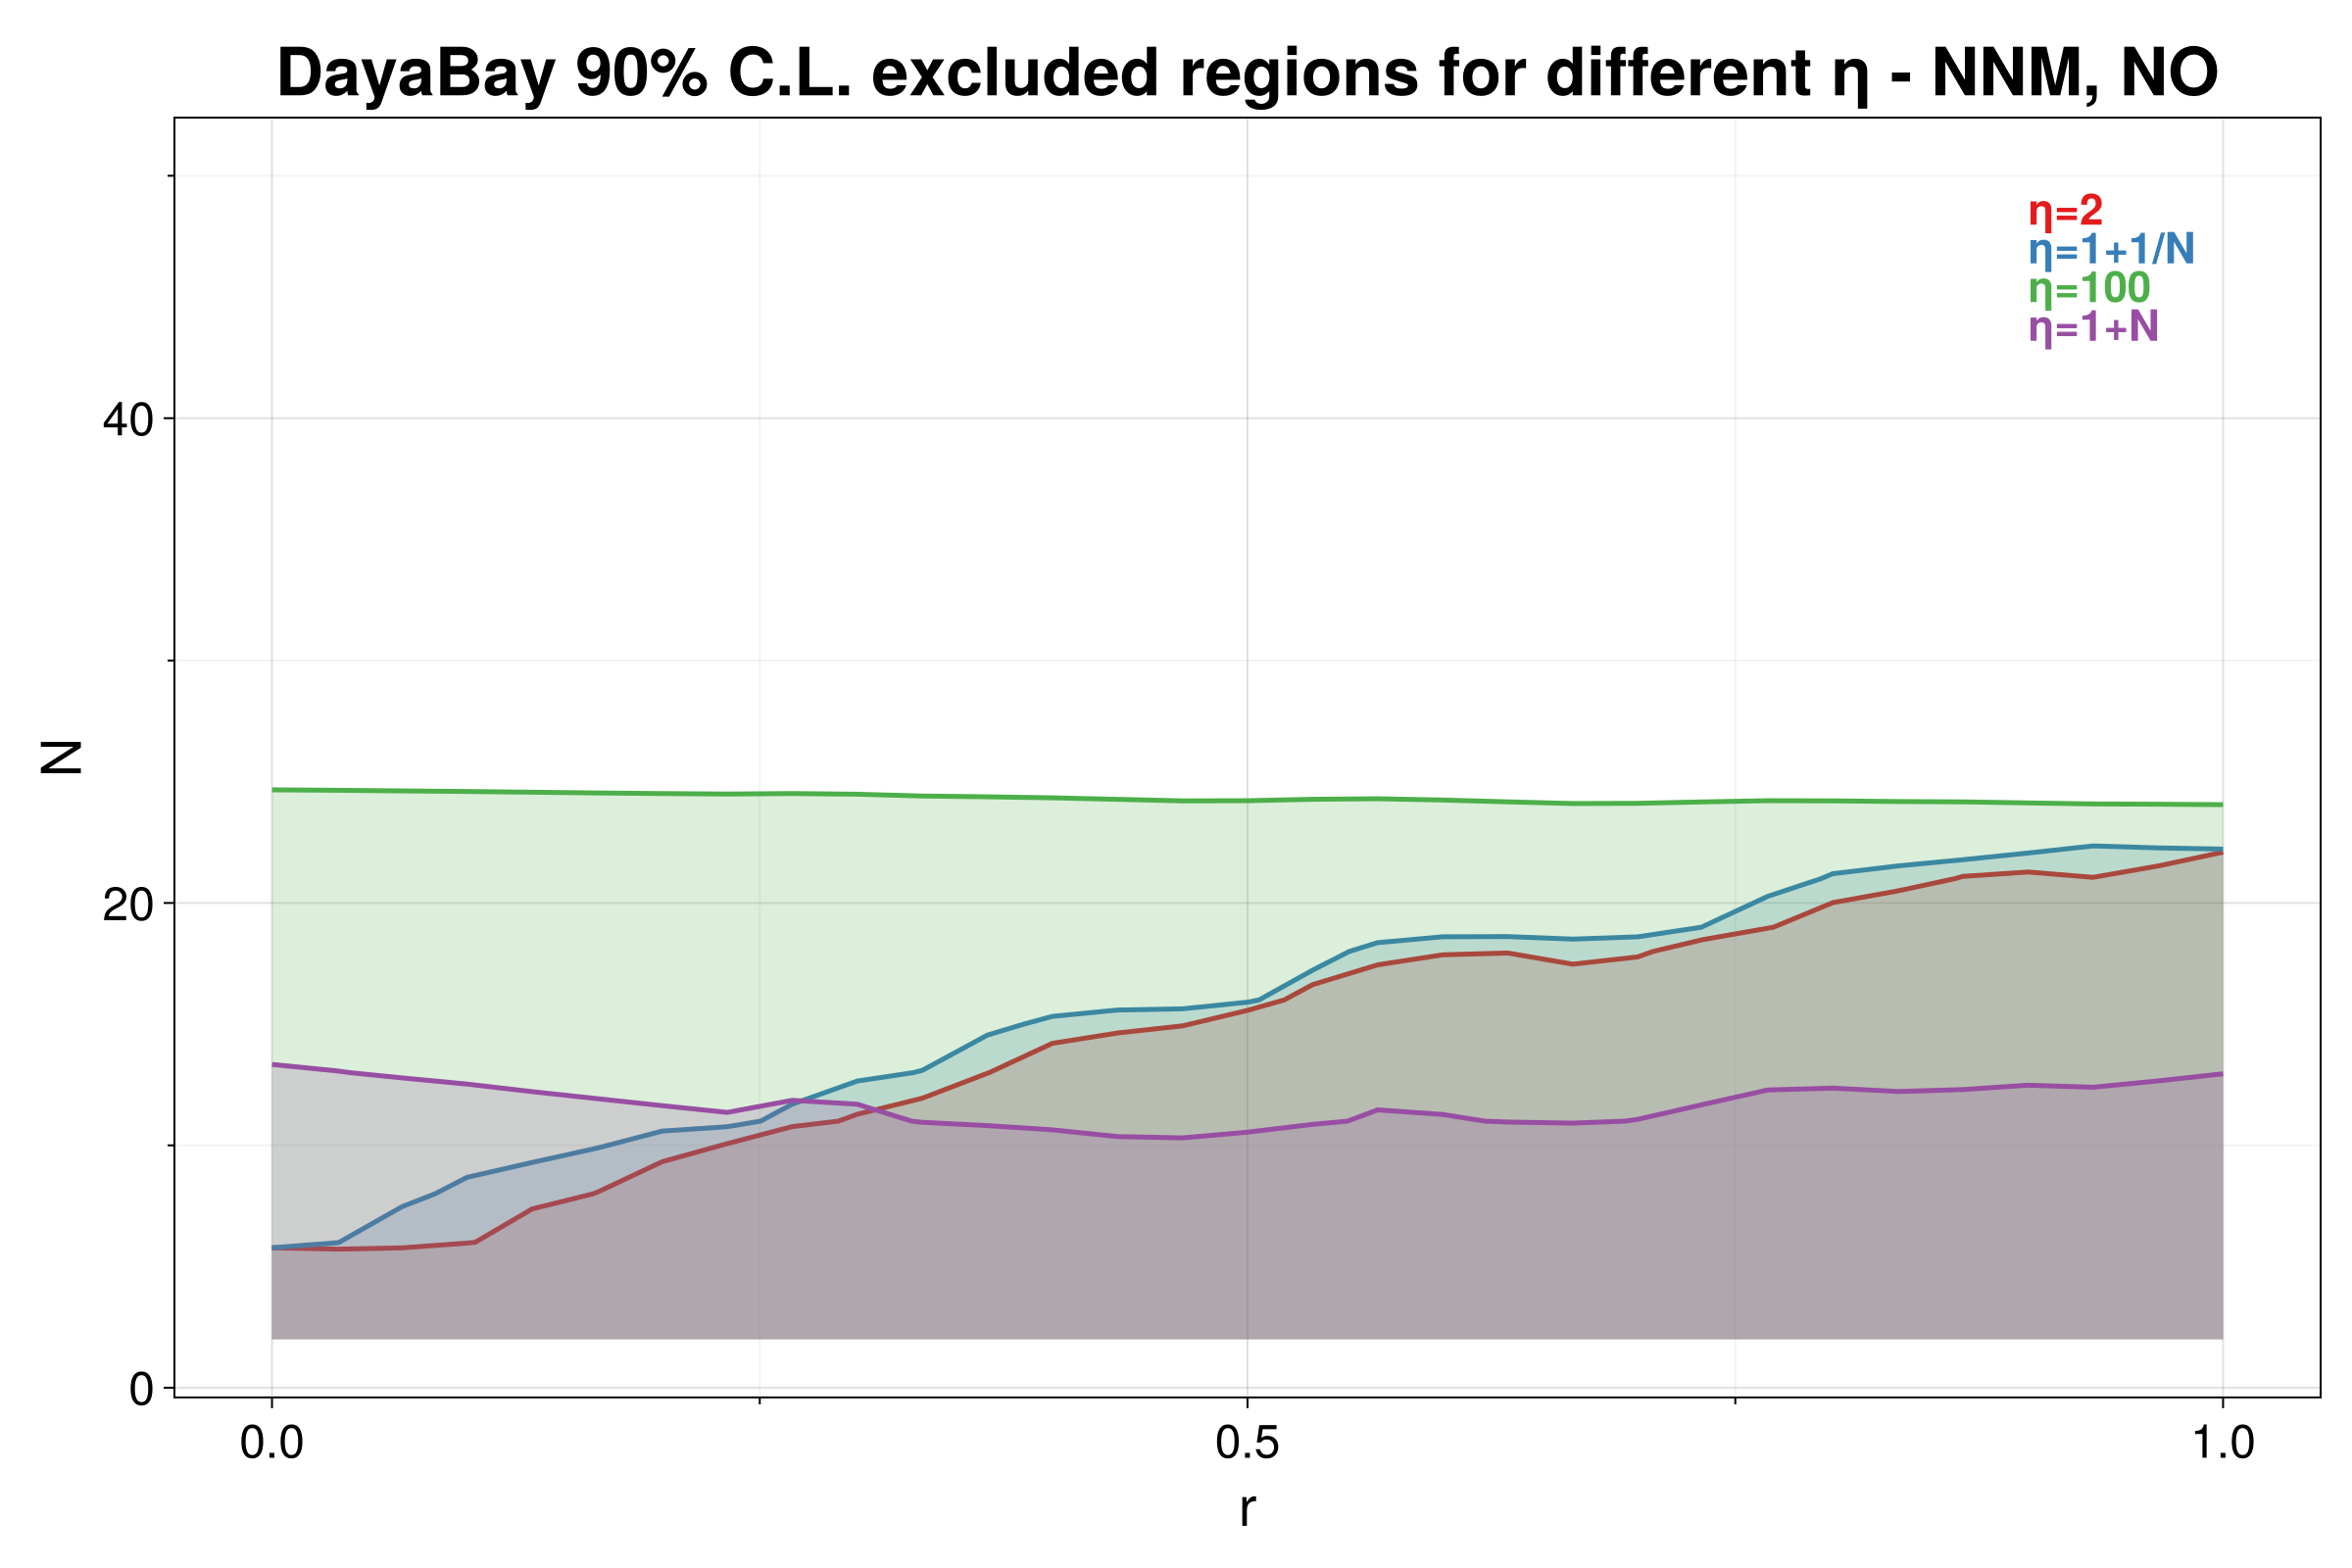

CairoMakie.Screen{SVG}


In [5]:


file_paths = ["/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_dayabay_Nr_m0=0.01_η=2_NNM_NO.jld2",
                "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_dayabay_Nr_m0=0.01_η=1+1N_NNM_NO.jld2",
                "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_dayabay_Nr_m0=0.01_η=100_NNM_NO.jld2",
                "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_dayabay_Nr_m0=0.01_η=1+N_NNM_NO.jld2"]
fig = superpose_contours_outside(file_paths;  
    title="DayaBay 90% C.L. excluded regions for different η - NNM, NO",
    experiments = ["η=2", "η=1+1/N", "η=100", "η=1+N"], 
    colorscheme = :Set1_9,
    color_step = 1,
    #xscale=log10,
    #yscale=log10
    smooth_sigma=0.8)

display("image/png", fig)
save("/home/sofialon/Newtrinos.jl/plots_svg/dayabay/superposed_contours_dayabay_rN-η.png", fig)
save("/home/sofialon/Newtrinos.jl/plots_svg/dayabay/superposed_contours_dayabay_rN-η.svg", fig)



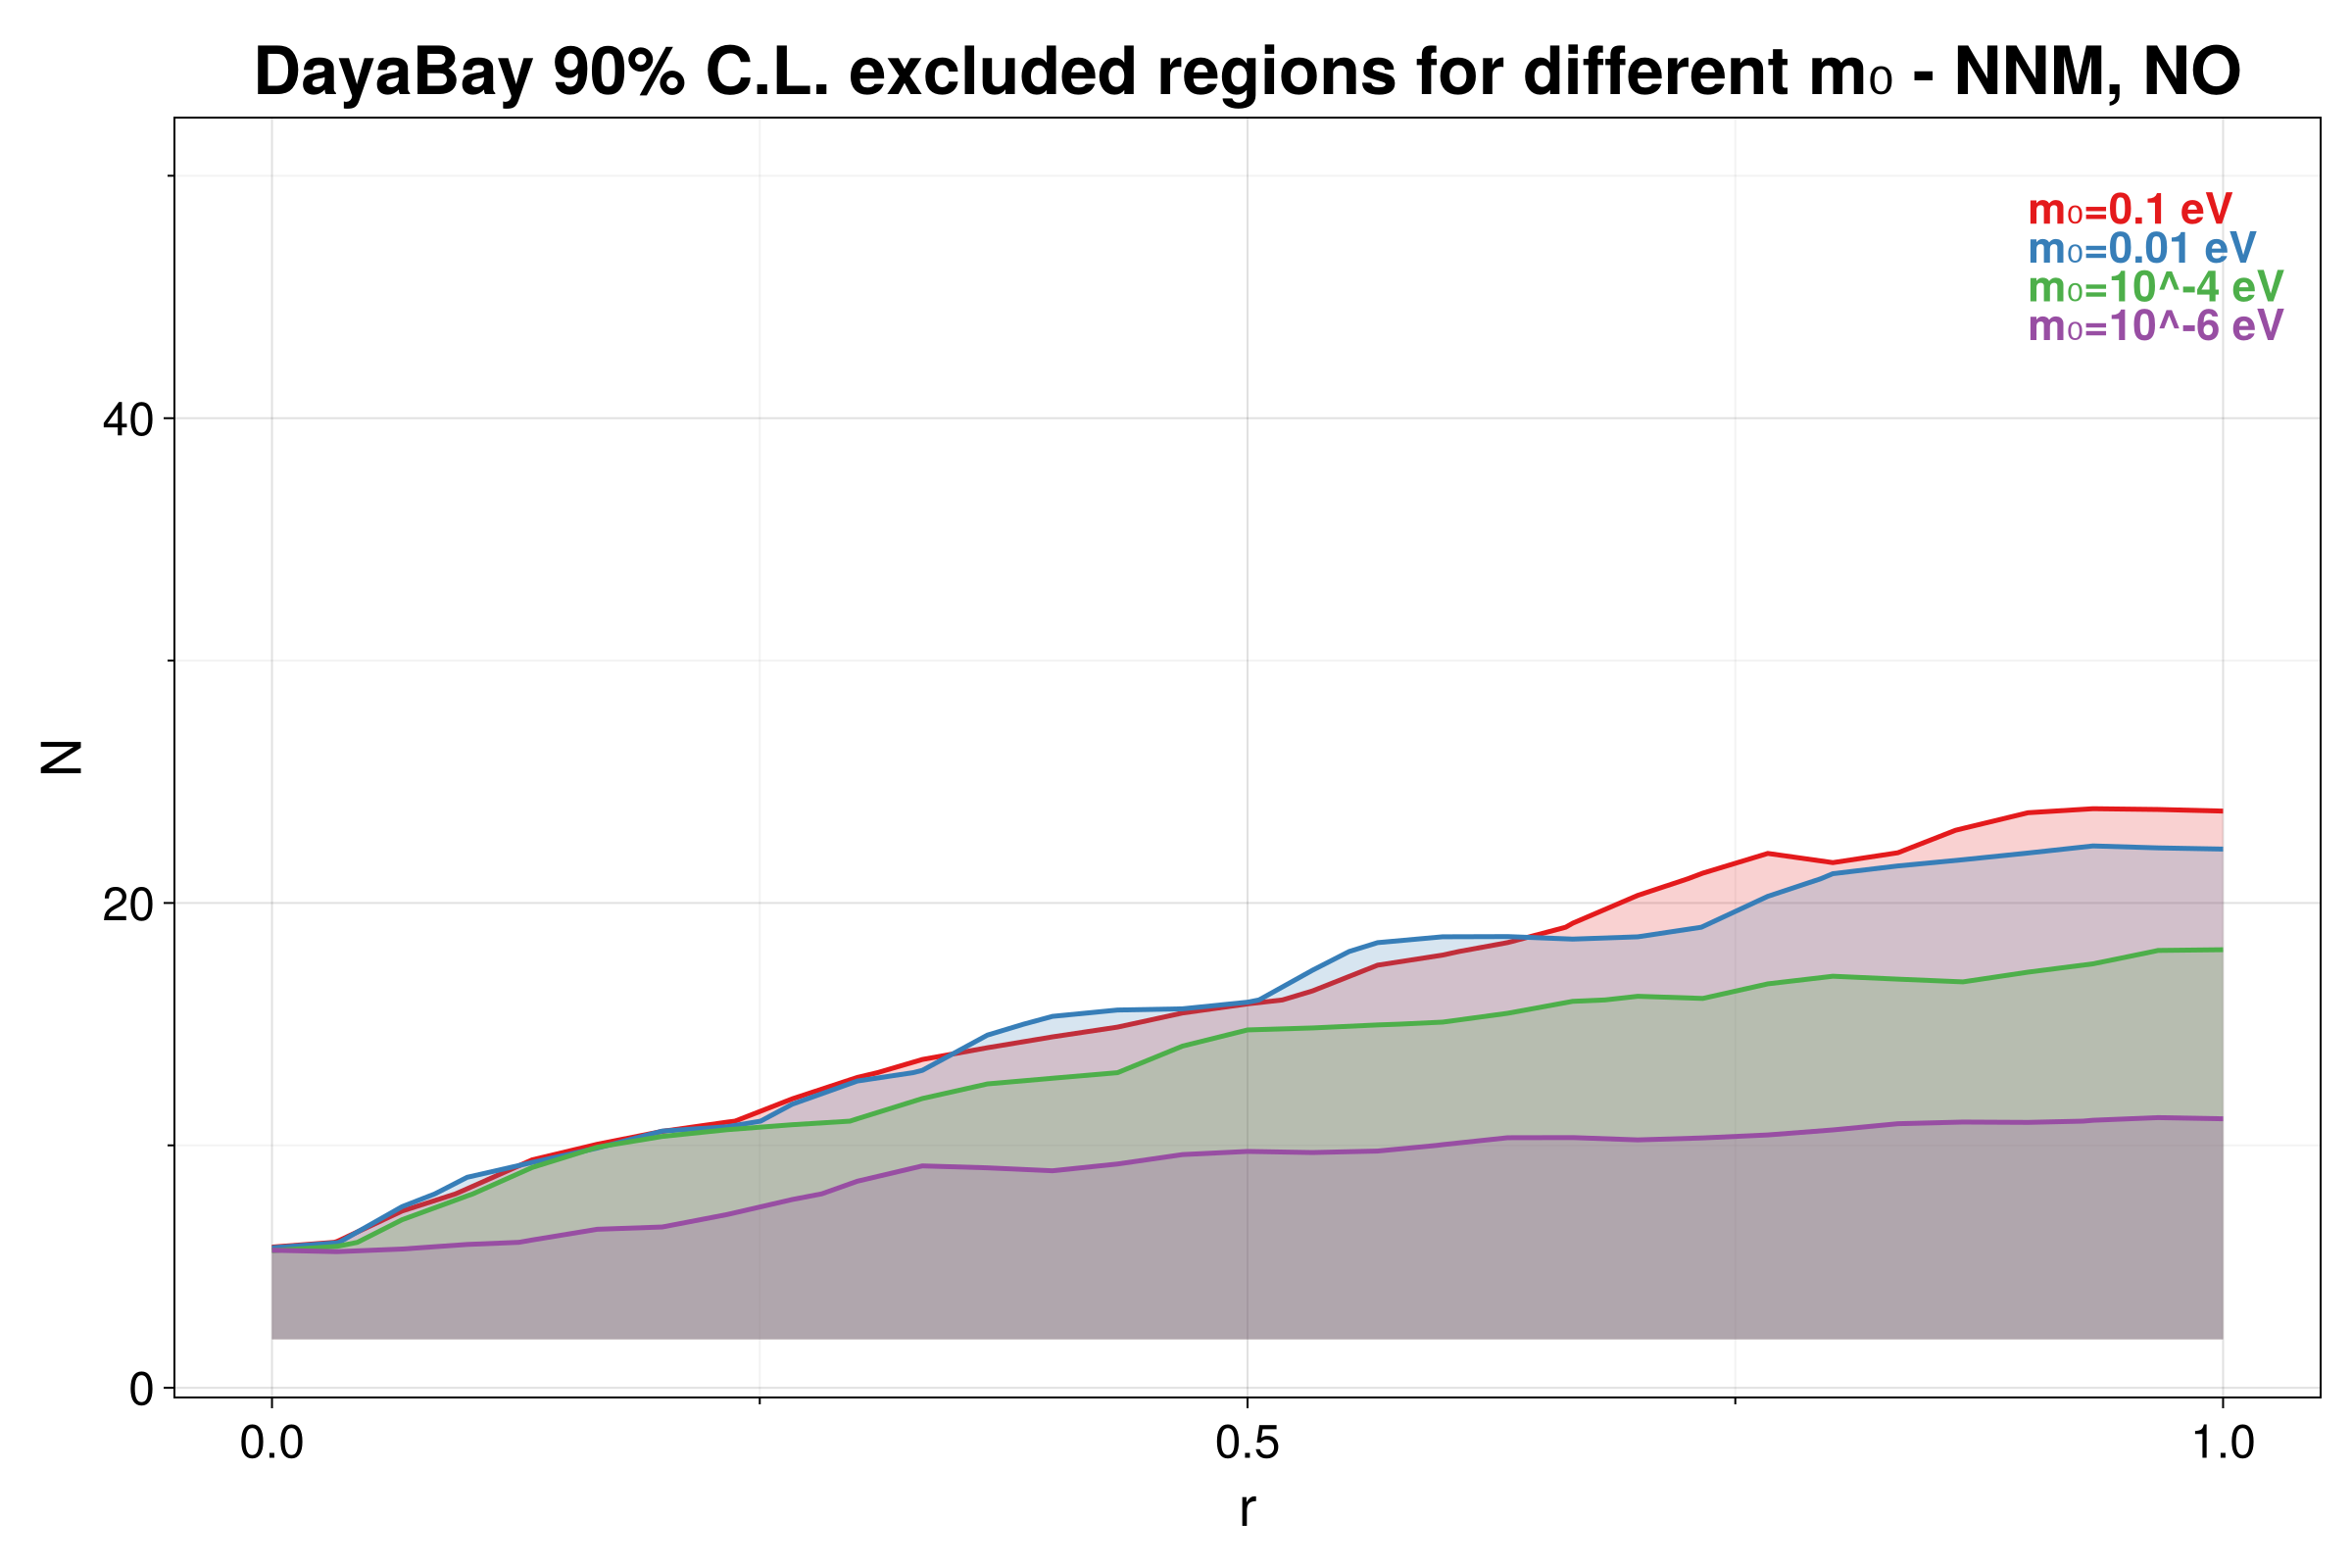

CairoMakie.Screen{SVG}


In [8]:


file_paths = ["/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_dayabay_Nr_m0=0.1_NNM_NO.jld2",
                "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_dayabay_Nr_m0=0.01_η=1+1N_NNM_NO.jld2",
                "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_dayabay_Nr_m0=0.0001_NNM_NO.jld2",
                "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_dayabay_Nr_m0=1.0e-6_NNM_NO.jld2"]
                
fig = superpose_contours_outside(file_paths;  
    title="DayaBay 90% C.L. excluded regions for different m₀ - NNM, NO",
    experiments = ["m₀=0.1 eV", "m₀=0.01 eV", "m₀=10^-4 eV", "m₀=10^-6 eV"], 
    colorscheme = :Set1_9,
    color_step = 1,
    #xscale=log10,
    #yscale=log10
    smooth_sigma=0.8)

display("image/png", fig)
save("/home/sofialon/Newtrinos.jl/plots_svg/dayabay/superposed_contours_dayabay_rN_m0.png", fig)
save("/home/sofialon/Newtrinos.jl/plots_svg/dayabay/superposed_contours_dayabay_rN_m0.svg", fig)

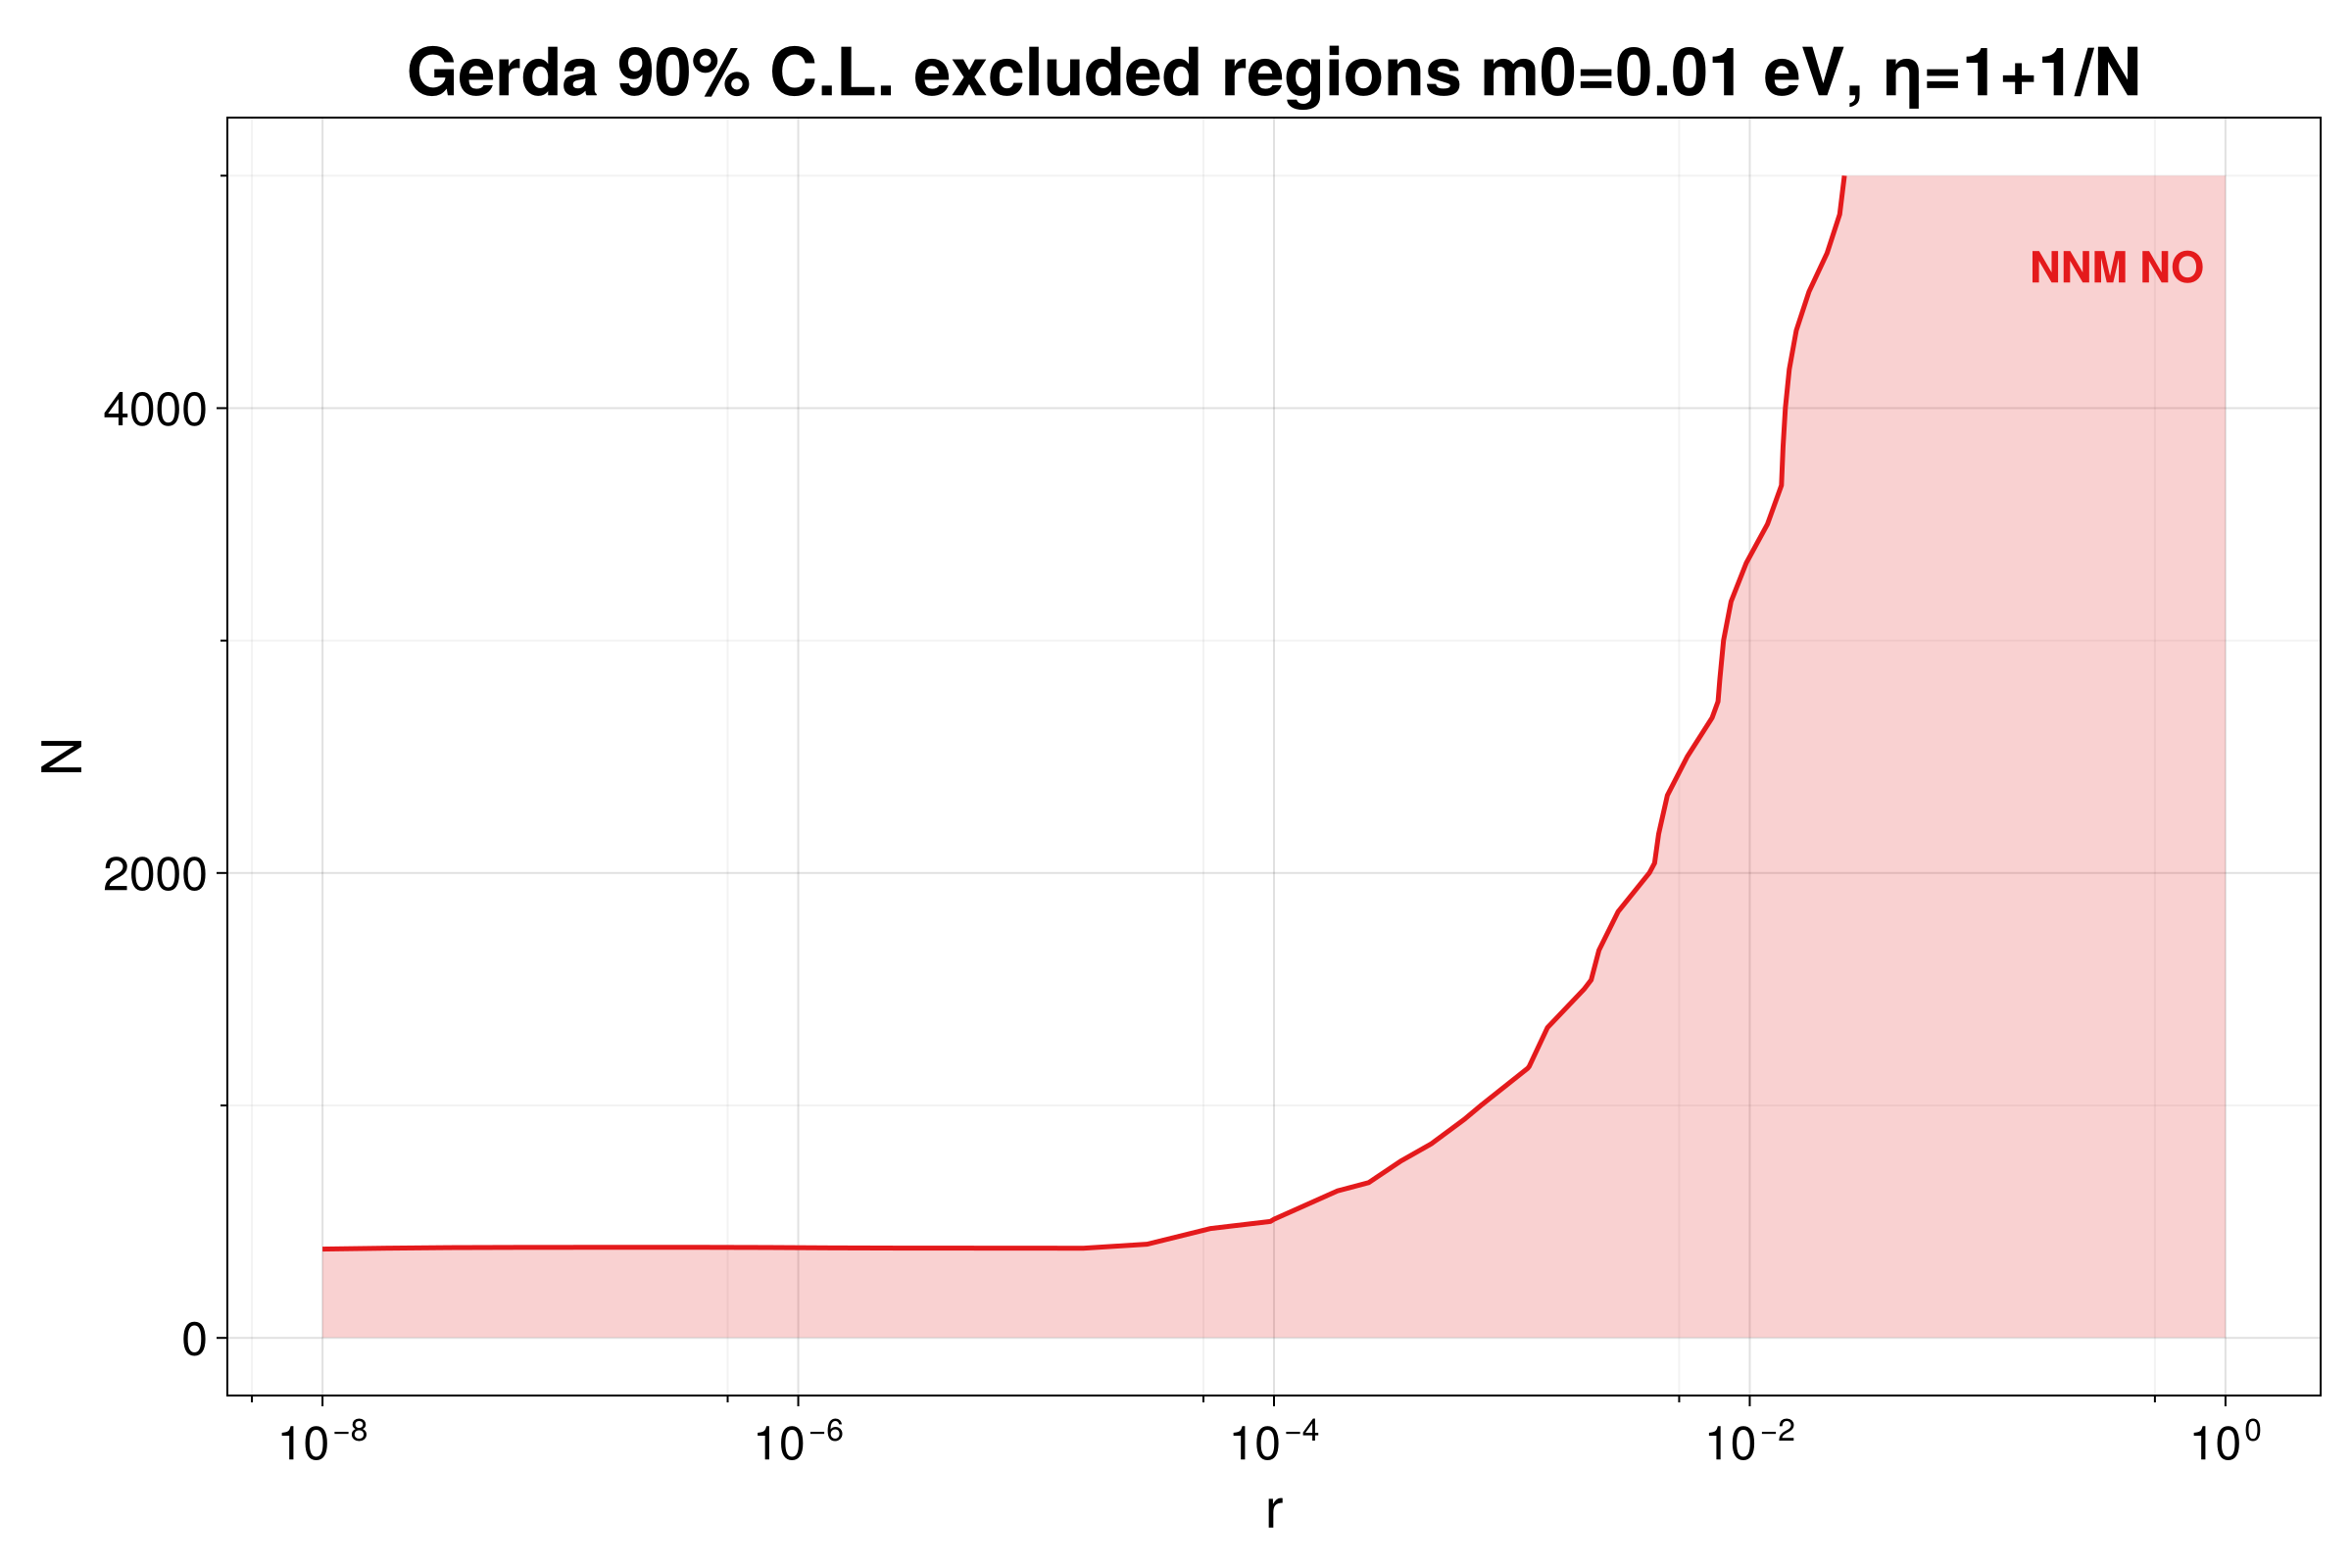

CairoMakie.Screen{SVG}


In [36]:
using ImageFiltering
using JLD2, CairoMakie, Distributions, Colors, ColorSchemes
using Newtrinos


function gaussian_smooth(Z; σ=1.0)
    kernel = Kernel.gaussian((σ, σ))
    return imfilter(Z, kernel, Pad(:replicate))
end



function superpose_contours_outside(file_paths::Vector{String}; 
                           title="Superposed Contours",
                           xlabel="Parameter 1", 
                           ylabel="Parameter 2",
                           experiments=nothing,
                           colorscheme=nothing,
                           color_step=1,
                           linestyles=nothing,
                           xscale=identity,
                           yscale=identity,
                           smooth_sigma::Union{Nothing,Float64}=nothing)
 
    
    # Default colorscheme and linestyles
    if colorscheme === nothing
        colorscheme = :Dark2_8
    end
    if linestyles === nothing
        linestyles = fill(:solid, length(file_paths))
    end
    
    # Get colors from the colorscheme with step
    cs = getproperty(ColorSchemes, colorscheme)
    all_colors = cs.colors
    colors = all_colors[1:color_step:end]
    n_colors = length(file_paths)
    if n_colors > length(colors)
        # If we need more colors than available, interpolate
        colors = [colors[i] for i in range(1, length(colors), length=n_colors)]
    else
        colors = colors[1:n_colors]
    end
    

    
  
    sigma_90_excluded_level = quantile(Chisq(2), 0.90)
    
    # Load all results and find axis ranges
    results = []
    all_axes_1 = []
    all_axes_2 = []
    
    for file_path in file_paths
        result = load(file_path)["result"]  # Adjust key if needed
        push!(results, result)
        push!(all_axes_1, result.axes[1])
        push!(all_axes_2, result.axes[2])
    end
    
    # Find combined axis ranges
    x_min = minimum([minimum(ax) for ax in all_axes_1])
    x_max = maximum([maximum(ax) for ax in all_axes_1])
    y_min = minimum([minimum(ax) for ax in all_axes_2])
    y_max = maximum([maximum(ax) for ax in all_axes_2])
        
    # Get axis labels from first result
    first_result = results[1]
    axis_labels = collect(keys(first_result.axes))

    # Create figure
    f = Figure(size=(1200, 800))
    ax = Axis(f[1,1];
        xlabel = String(axis_labels[1]) , #*"(eV)"
        ylabel = String(axis_labels[2]),
        title = title,
        xminorticksvisible = true, 
        xminorgridvisible = true, 
        yminorticksvisible = true, 
        yminorgridvisible = true,
        titlesize = 34,
        xlabelsize = 28,
        ylabelsize = 28,
        xticklabelsize = 24,
        yticklabelsize = 24,
        xscale = xscale,
        yscale = yscale
    )
   # Plot contours
    for (idx, result) in enumerate(results)

        dLLH_raw = 2 .* (maximum(result.values.log_posterior) .- result.values.log_posterior)

        dLLH = smooth_sigma === nothing ? dLLH_raw :
            gaussian_smooth(dLLH_raw; σ=smooth_sigma)

        # --- CLEAN FIELD (critical) ---
        dLLH_plot = copy(dLLH)
        dLLH_plot[.!isfinite.(dLLH_plot)] .= NaN

        maxlevel = maximum(skipmissing(vec(dLLH_plot)))
        ϵ = 1e-6  # numerical safety margin

        color = colors[idx]
        linestyle = linestyles[mod(idx-1, length(linestyles)) + 1]

        color_transparent = RGBA(color, 1.0)
        color_transparent_full = RGBA(color, 0.2)

        # --- SHADE ONLY IF EXCLUSION EXISTS ---
        if isfinite(maxlevel) && maxlevel > sigma_90_excluded_level + ϵ
            contourf!(ax,
                result.axes[1],
                result.axes[2],
                dLLH_plot;
                levels = [sigma_90_excluded_level, maxlevel],
                colormap = cgrad([color_transparent_full, color_transparent])
            )
        end

        # --- ALWAYS DRAW CONTOUR LINE ---
        contour!(ax,
            result.axes[1],
            result.axes[2],
            dLLH_plot;
            levels = [sigma_90_excluded_level],
            color = color,
            linewidth = 2.5,
            linestyle = linestyle
        )
        

    end
    if experiments !== nothing
        # Helper function to position in data space (works for log and linear)
        function position_in_range(min_val, max_val, fraction)
            if yscale == log10
                # Log scale: work in log space
                min_log = log10(min_val)
                max_log = log10(max_val)
                return 10 ^ (min_log + fraction * (max_log - min_log))
            else
                # Linear scale: work in linear space
                return min_val + fraction * (max_val - min_val)
            end
        end
        
        if length(experiments) == 1
            fractions_y = [0.90]   # single nice position near top
        else
            fractions_y = range(0.95, 0.85, length=length(experiments))
        end
        y_positions = [position_in_range(y_min, y_max, f) for f in fractions_y]
        x_position = position_in_range(x_min, x_max, 0.15)
        
        for (idx, label) in enumerate(experiments)
            color = colors[idx]
            text!(ax, x_position, y_positions[idx], 
                  text = label,
                  fontsize = 22,
                  color = color,
                  font = :bold)
        end
    end
    
    f
end

file_paths = ["/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_gerda_rN_m0=0.01_NNM_NO_log.jld2",]
fig = superpose_contours_outside(file_paths;  
    title="Gerda 90% C.L. excluded regions m0=0.01 eV, η=1+1/N",
    experiments = ["NNM NO",], 
    colorscheme = :Set1_9,
    color_step = 1,
    xscale=log10,
    #yscale=log10
    smooth_sigma=0.8)

display("image/png", fig)
save("/home/sofialon/Newtrinos.jl/plots_svg/gerda/superposed_contours_gerda_5000.png", fig)
save("/home/sofialon/Newtrinos.jl/plots_svg/gerda/superposed_contours_gerda_5000.svg", fig)

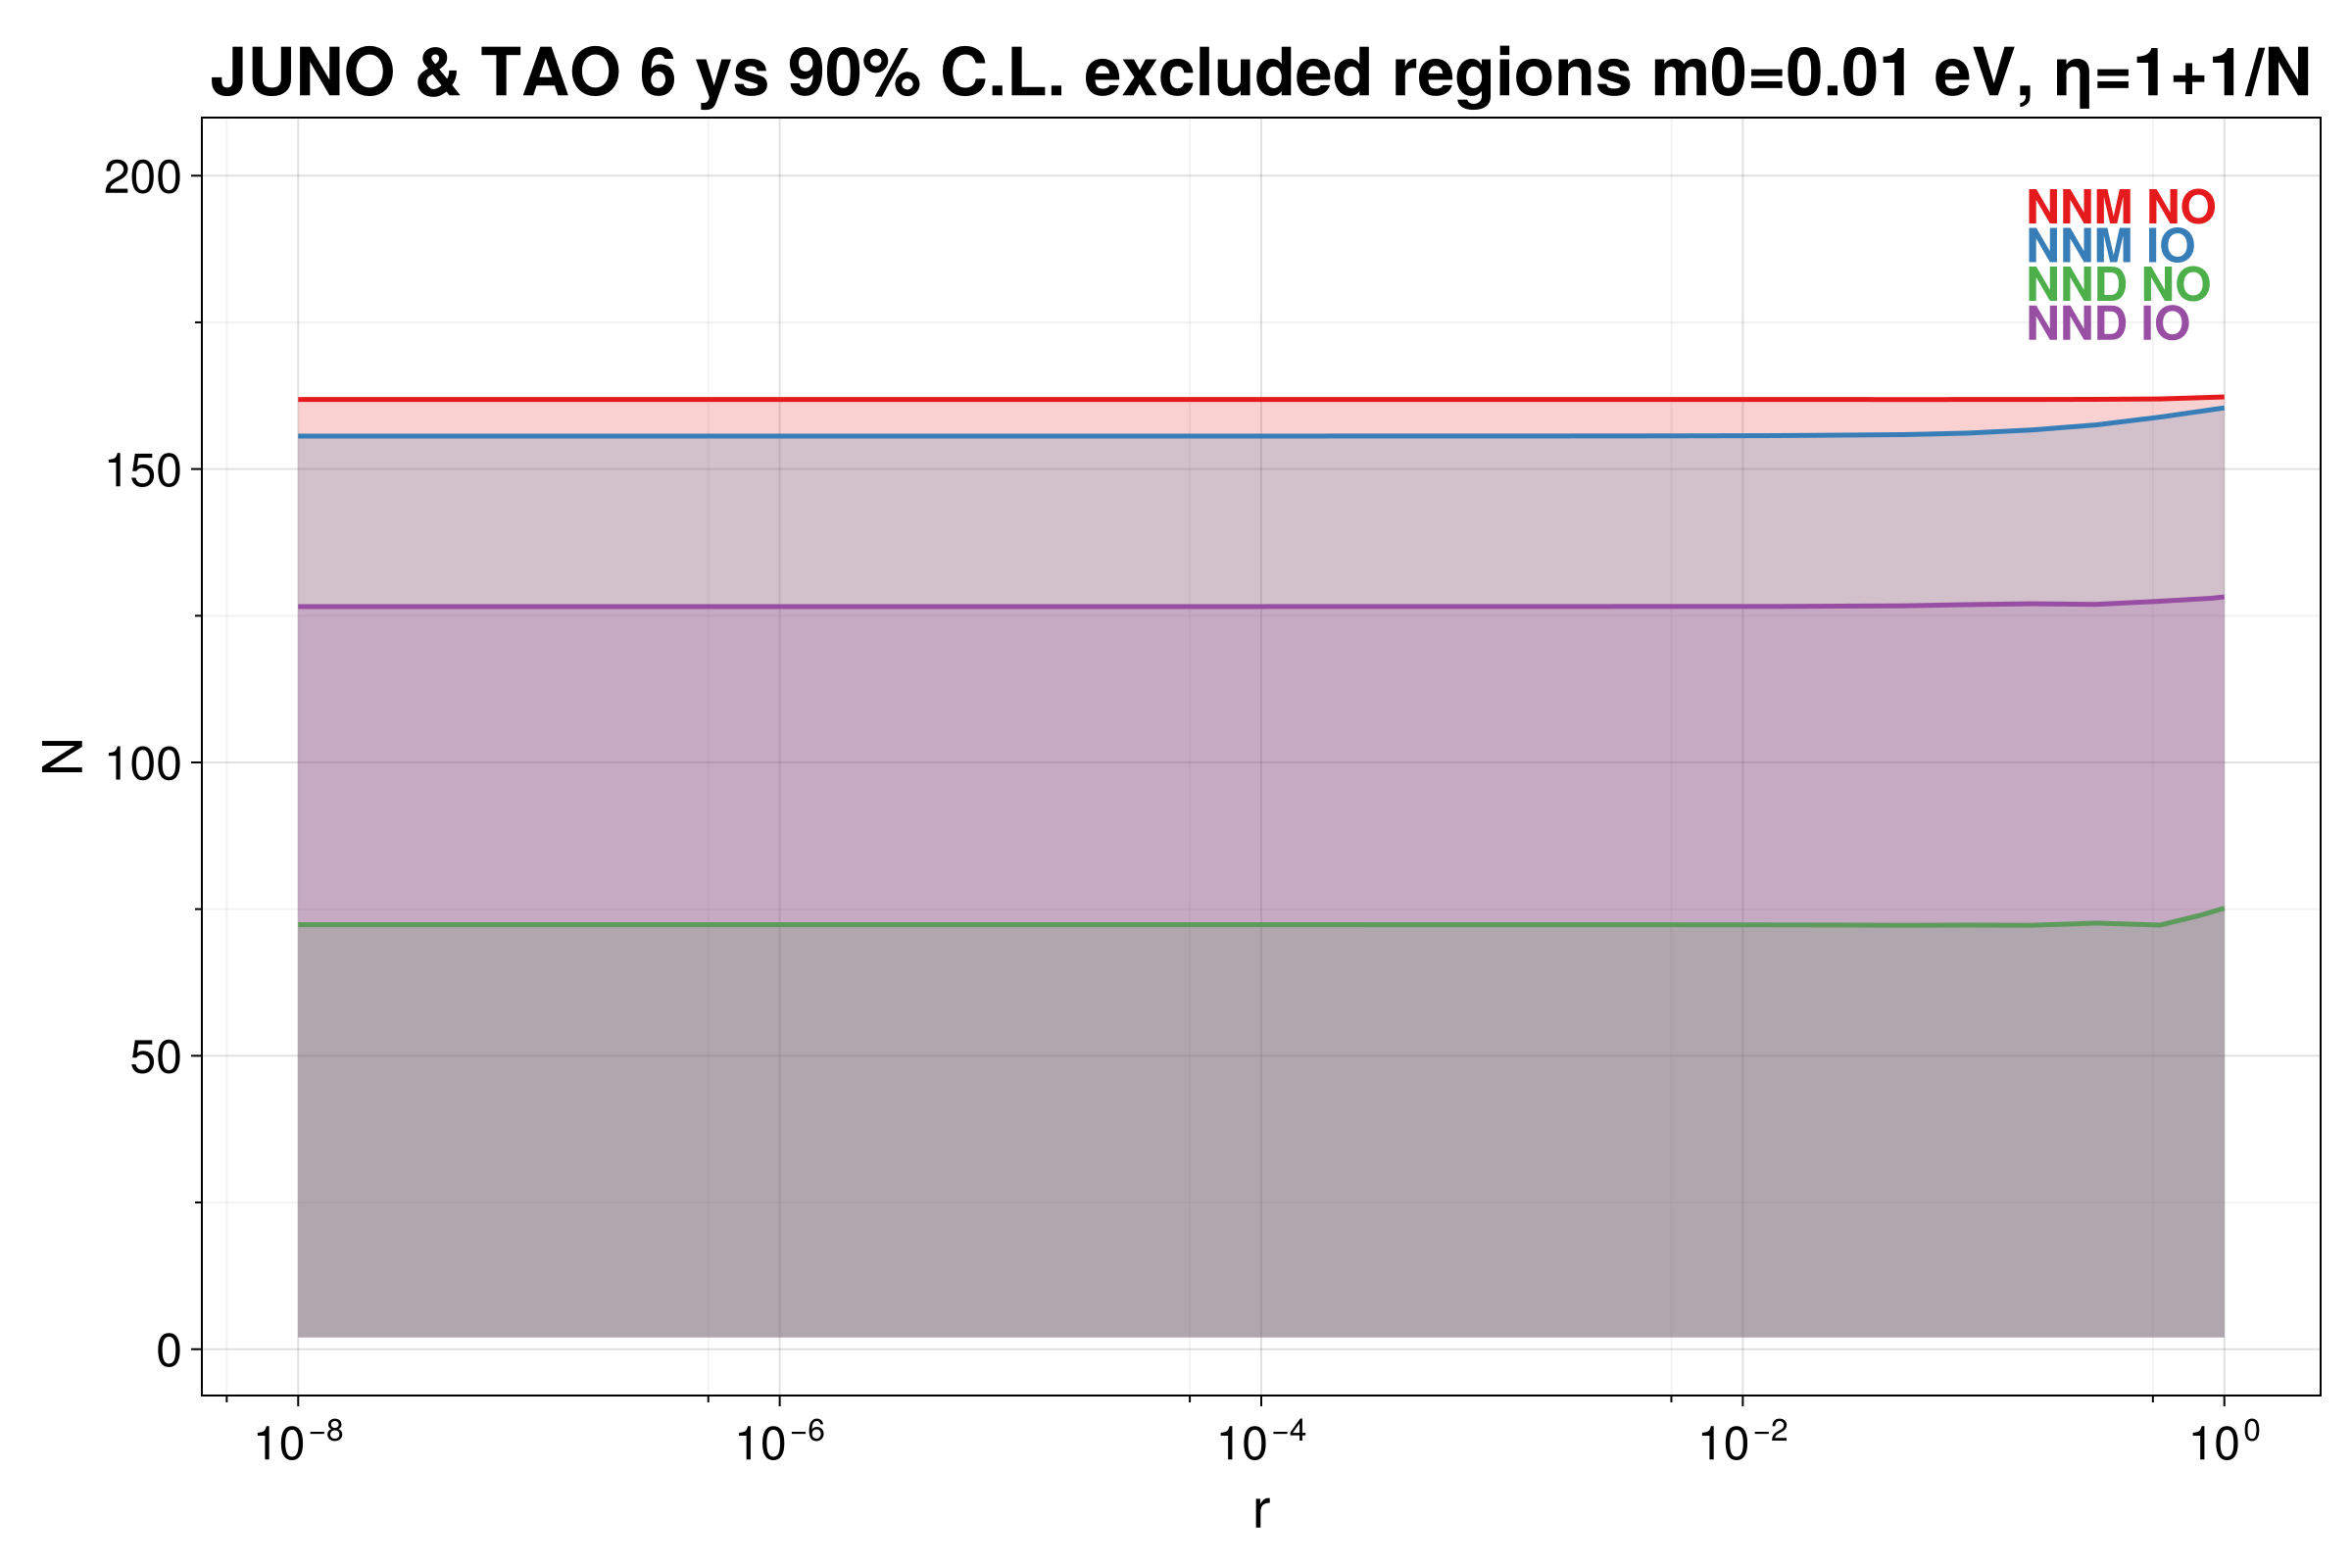

In [15]:



function superpose_contours_outside(file_paths::Vector{String}; 
                           title="Superposed Contours",
                           xlabel="Parameter 1", 
                           ylabel="Parameter 2",
                           experiments=nothing,
                           colorscheme=nothing,
                           color_step=1,
                           linestyles=nothing,
                           xscale=identity,
                           yscale=identity,
                           smooth_sigma::Union{Nothing,Float64}=nothing)
 
    
    # Default colorscheme and linestyles
    if colorscheme === nothing
        colorscheme = :Dark2_8
    end
    if linestyles === nothing
        linestyles = fill(:solid, length(file_paths))
    end
    
    # Get colors from the colorscheme with step
    cs = getproperty(ColorSchemes, colorscheme)
    all_colors = cs.colors
    colors = all_colors[1:color_step:end]
    n_colors = length(file_paths)
    if n_colors > length(colors)
        # If we need more colors than available, interpolate
        colors = [colors[i] for i in range(1, length(colors), length=n_colors)]
    else
        colors = colors[1:n_colors]
    end
    

    
  
    sigma_90_excluded_level = quantile(Chisq(2), 0.90)
    
    # Load all results and find axis ranges
    results = []
    all_axes_1 = []
    all_axes_2 = []
    
    for file_path in file_paths
        result = load(file_path)["result"]  # Adjust key if needed
        push!(results, result)
        push!(all_axes_1, result.axes[1])
        push!(all_axes_2, result.axes[2])
    end
    
    # Find combined axis ranges
    x_min = minimum([minimum(ax) for ax in all_axes_1])
    x_max = maximum([maximum(ax) for ax in all_axes_1])
    y_min = minimum([minimum(ax) for ax in all_axes_2])
    y_max = maximum([maximum(ax) for ax in all_axes_2])
        
    # Get axis labels from first result
    first_result = results[1]
    axis_labels = collect(keys(first_result.axes))

    # Create figure
    f = Figure(size=(1200, 800))
    ax = Axis(f[1,1];
        xlabel = String(axis_labels[1]) , #*" (eV)"
        ylabel = String(axis_labels[2]) ,
       title = title,
        xminorticksvisible = true,
        xminorgridvisible = true,
        yminorticksvisible = true,
        yminorgridvisible = true,
        titlesize = 34,
        xlabelsize = 28,
        ylabelsize = 28,
        xticklabelsize = 24,
        yticklabelsize = 24,
        xscale = xscale,
        yscale = yscale
    )
   # Plot contours
    for (idx, result) in enumerate(results)
        lp = result.values.log_posterior
        finite_mask = isfinite.(lp)

        if !any(finite_mask)
            @warn "Scan contains no finite likelihood values — skipping"
            continue
        end

        lp_max = maximum(lp[finite_mask])

        dLLH_raw = 2 .* (lp_max .- lp)

        dLLH = smooth_sigma === nothing ? dLLH_raw :
            gaussian_smooth(dLLH_raw; σ=smooth_sigma)


        dLLH_plot = copy(dLLH)
        dLLH_plot[.!isfinite.(dLLH_plot)] .= NaN

        maxlevel = maximum(skipmissing(vec(dLLH_plot)))
        ϵ = 1e-6  # numerical safety margin

        color = colors[idx]
        linestyle = linestyles[mod(idx-1, length(linestyles)) + 1]

        color_transparent = RGBA(color, 1.0)
        color_transparent_full = RGBA(color, 0.2)

        # --- SHADE ONLY IF EXCLUSION EXISTS ---
        if isfinite(maxlevel) && maxlevel > sigma_90_excluded_level + ϵ
            contourf!(ax,
                result.axes[1],
                result.axes[2],
                dLLH_plot;
                levels = [sigma_90_excluded_level, maxlevel],
                colormap = cgrad([color_transparent_full, color_transparent])
            )
        end

        # --- ALWAYS DRAW CONTOUR LINE ---
        contour!(ax,
            result.axes[1],
            result.axes[2],
            dLLH_plot;
            levels = [sigma_90_excluded_level],
            color = color,
            linewidth = 2.5,
            linestyle = linestyle
        )
      
        

    end
    if experiments !== nothing
        # Helper function to position in data space (works for log and linear)
        function position_in_range(min_val, max_val, fraction)
            if yscale == log10
                # Log scale: work in log space
                min_log = log10(min_val)
                max_log = log10(max_val)
                return 10 ^ (min_log + fraction * (max_log - min_log))
            else
                # Linear scale: work in linear space
                return min_val + fraction * (max_val - min_val)
            end
        end
        
        fractions_y = range(0.95, 0.85, length=length(experiments))
        y_positions = [position_in_range(y_min, y_max, f) for f in fractions_y]
        x_position = position_in_range(x_min, x_max, 0.15)
        
        for (idx, label) in enumerate(experiments)
            color = colors[idx]
            text!(ax, x_position, y_positions[idx], 
                  text = label,
                  fontsize = 24,
                  color = color,
                  font = :bold)
        end
    end
    
    f
end


file_paths = ["/home/sofialon/Newtrinos.jl/plots_fix/junotao_m/junotao_toyschur_rN_NNM_NO_m0=0.01.jld2",
              "/home/sofialon/Newtrinos.jl/plots_fix/junotao_m/junotao_toyschur_rN_NNM_IO_m0=0.01.jld2",
                 "/home/sofialon/Newtrinos.jl/plots_fix/junotao_m/junotao_toyschur_rN_NND_NO_m0=0.01.jld2",
               "/home/sofialon/Newtrinos.jl/plots_fix/junotao_m/junotao_toyschur_rN_NND_IO_m0=0.01.jld2"]
    
                
fig = superpose_contours_outside(file_paths;  
    title="JUNO & TAO 6 ys 90% C.L. excluded regions m0=0.01 eV, η=1+1/N",
    experiments = ["NNM NO", "NNM IO", "NND NO","NND IO"], 
    colorscheme = :Set1_9,
    color_step = 1,
    xscale=log10,
    #yscale=log10,
    smooth_sigma=nothing)

display("image/png",fig)
#save("/home/sofialon/Newtrinos.jl/plots_svg/juno/superposed_contours_juno6_rN_log.svg", fig)
#save("/home/sofialon/Newtrinos.jl/plots_svg/juno/superposed_contours_juno6_rN_log.png", fig)


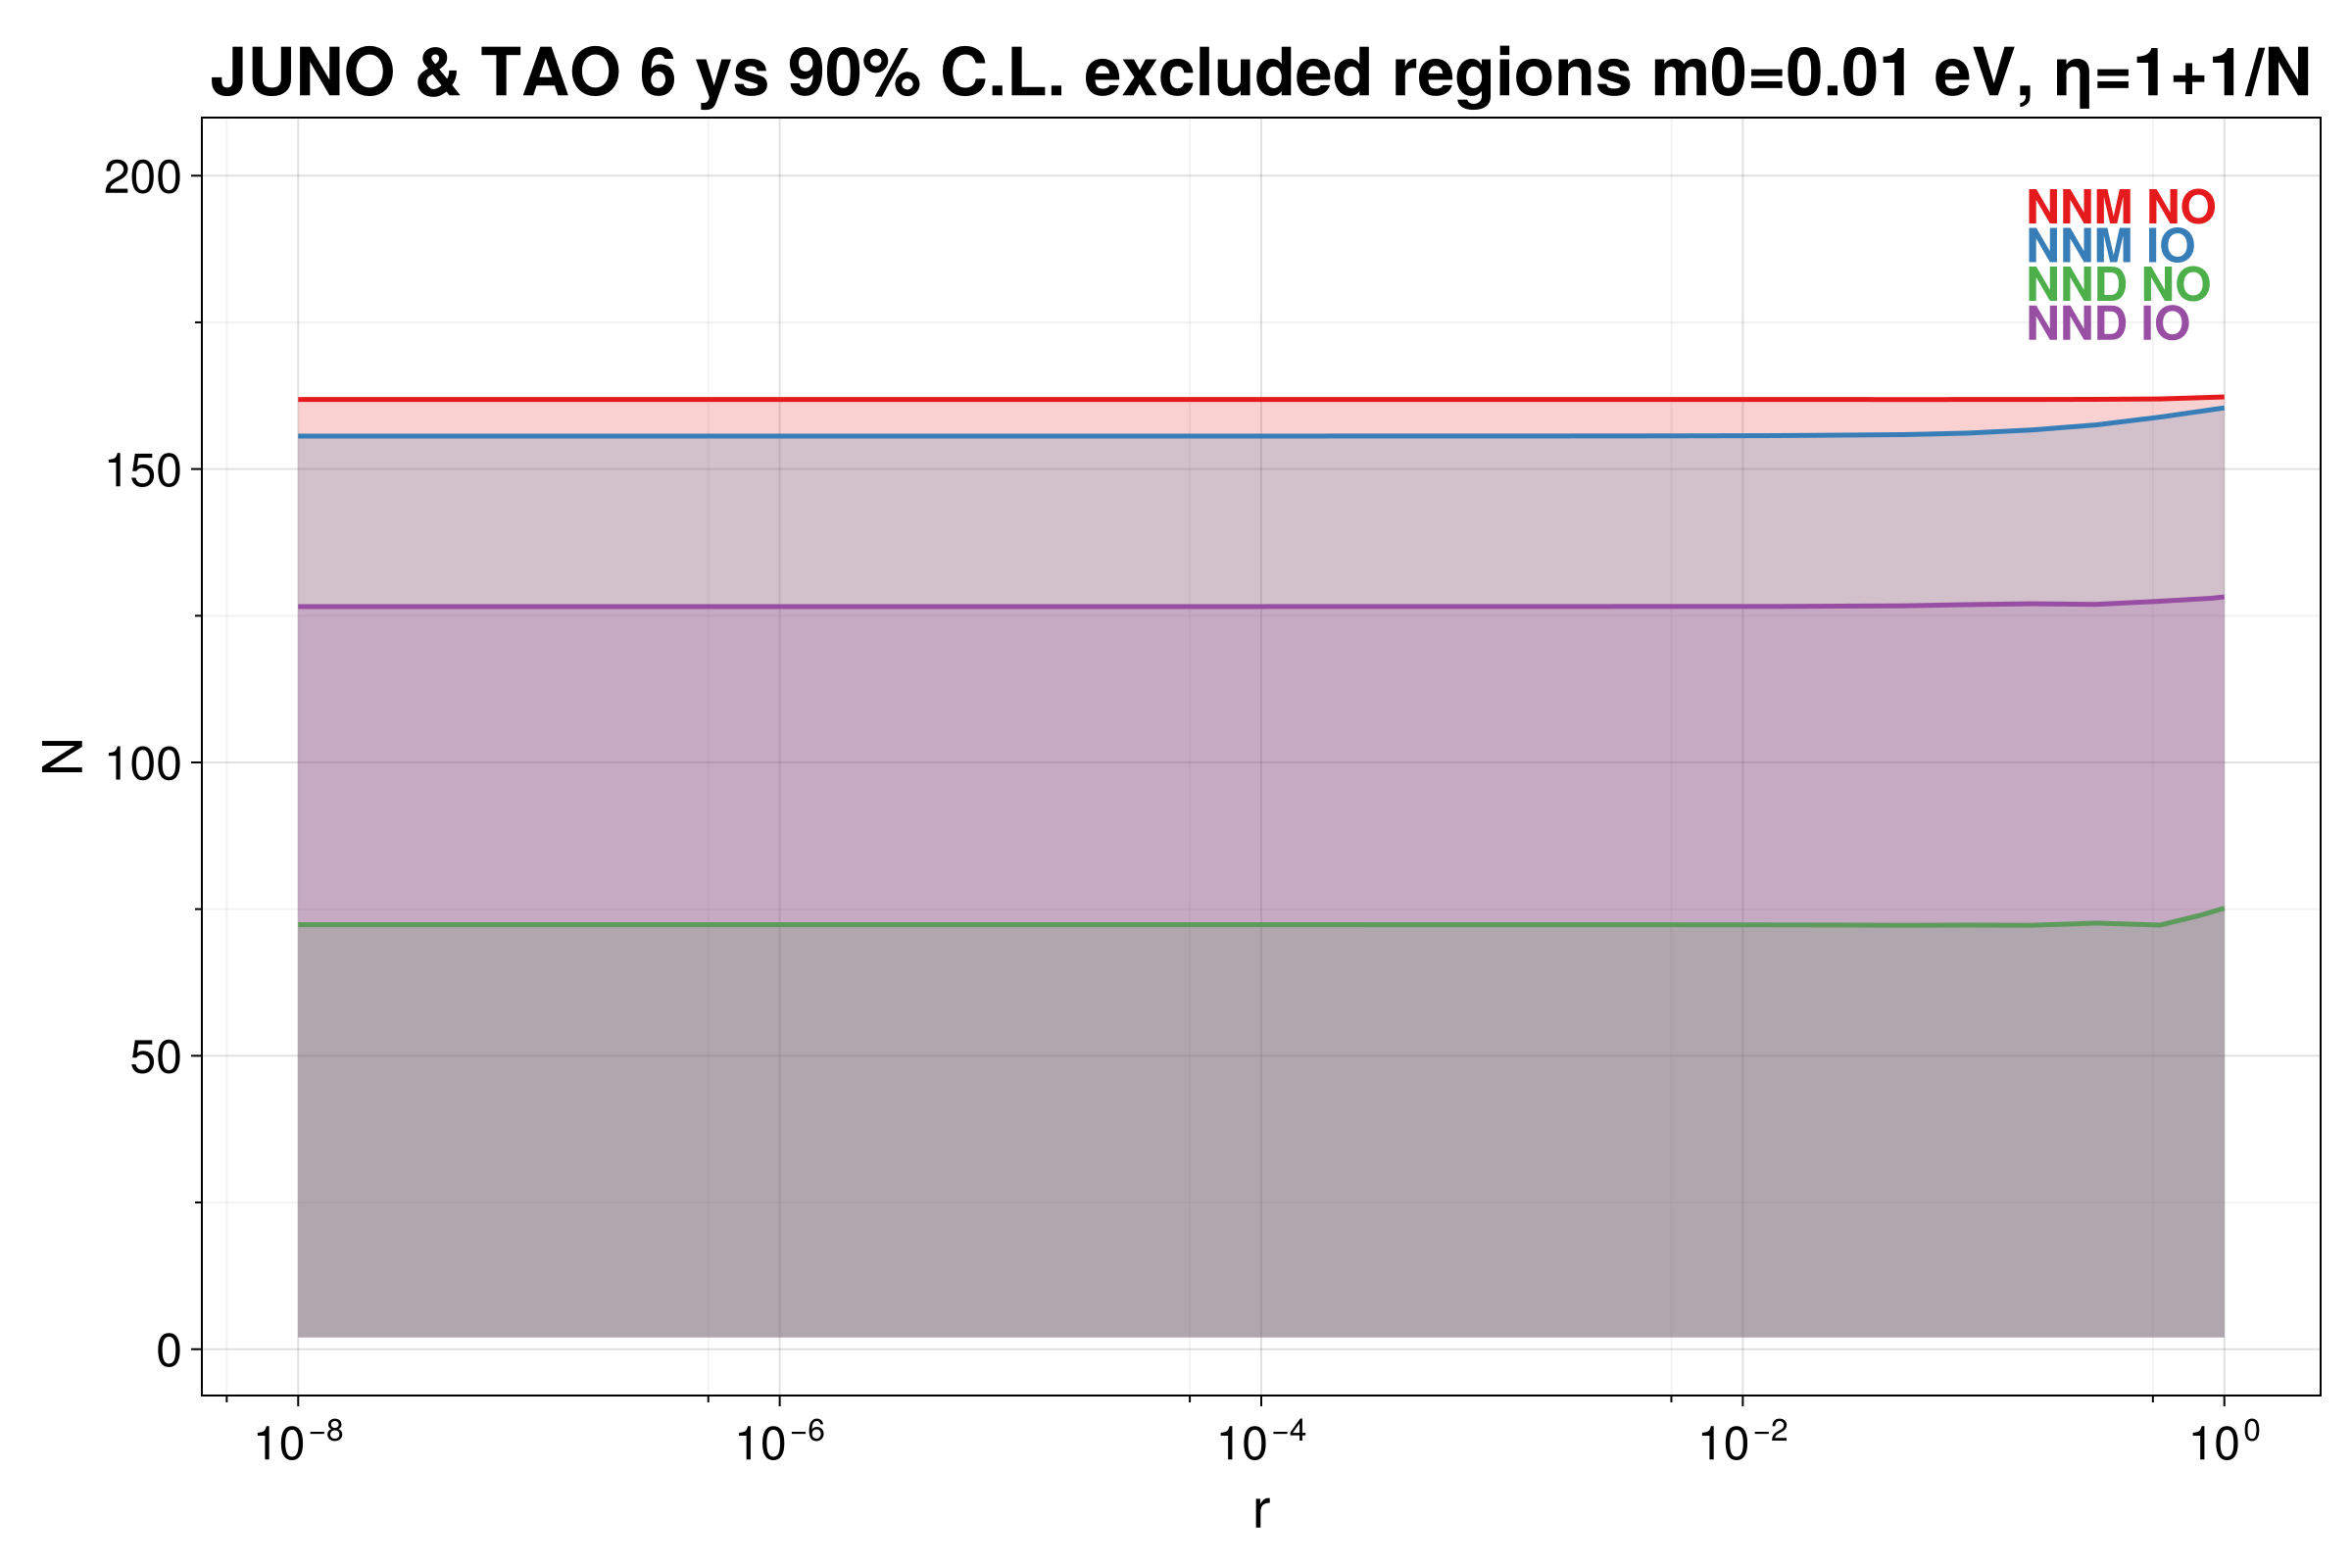

In [16]:


file_paths = ["/home/sofialon/Newtrinos.jl/plots_fix/junotao_m/junotao_toyschur_rN_NNM_NO_m0=0.01.jld2",
              "/home/sofialon/Newtrinos.jl/plots_fix/junotao_m/junotao_toyschur_rN_NNM_IO_m0=0.01.jld2",
                 "/home/sofialon/Newtrinos.jl/plots_fix/junotao_m/junotao_toyschur_rN_NND_NO_m0=0.01.jld2",
               "/home/sofialon/Newtrinos.jl/plots_fix/junotao_m/junotao_toyschur_rN_NND_IO_m0=0.01.jld2"]
    
                
fig = superpose_contours_outside(file_paths;  
    title="JUNO & TAO 6 ys 90% C.L. excluded regions m0=0.01 eV, η=1+1/N",
    experiments = ["NNM NO", "NNM IO", "NND NO","NND IO"], 
    colorscheme = :Set1_9,
    color_step = 1,
    xscale=log10,
    #yscale=log10,
    smooth_sigma=nothing)

display("image/png",fig)
#save("/home/sofialon/Newtrinos.jl/plots_svg/juno/superposed_contours_juno6_rN_log.svg", fig)
#save("/home/sofialon/Newtrinos.jl/plots_svg/juno/superposed_contours_juno6_rN_log.png", fig)


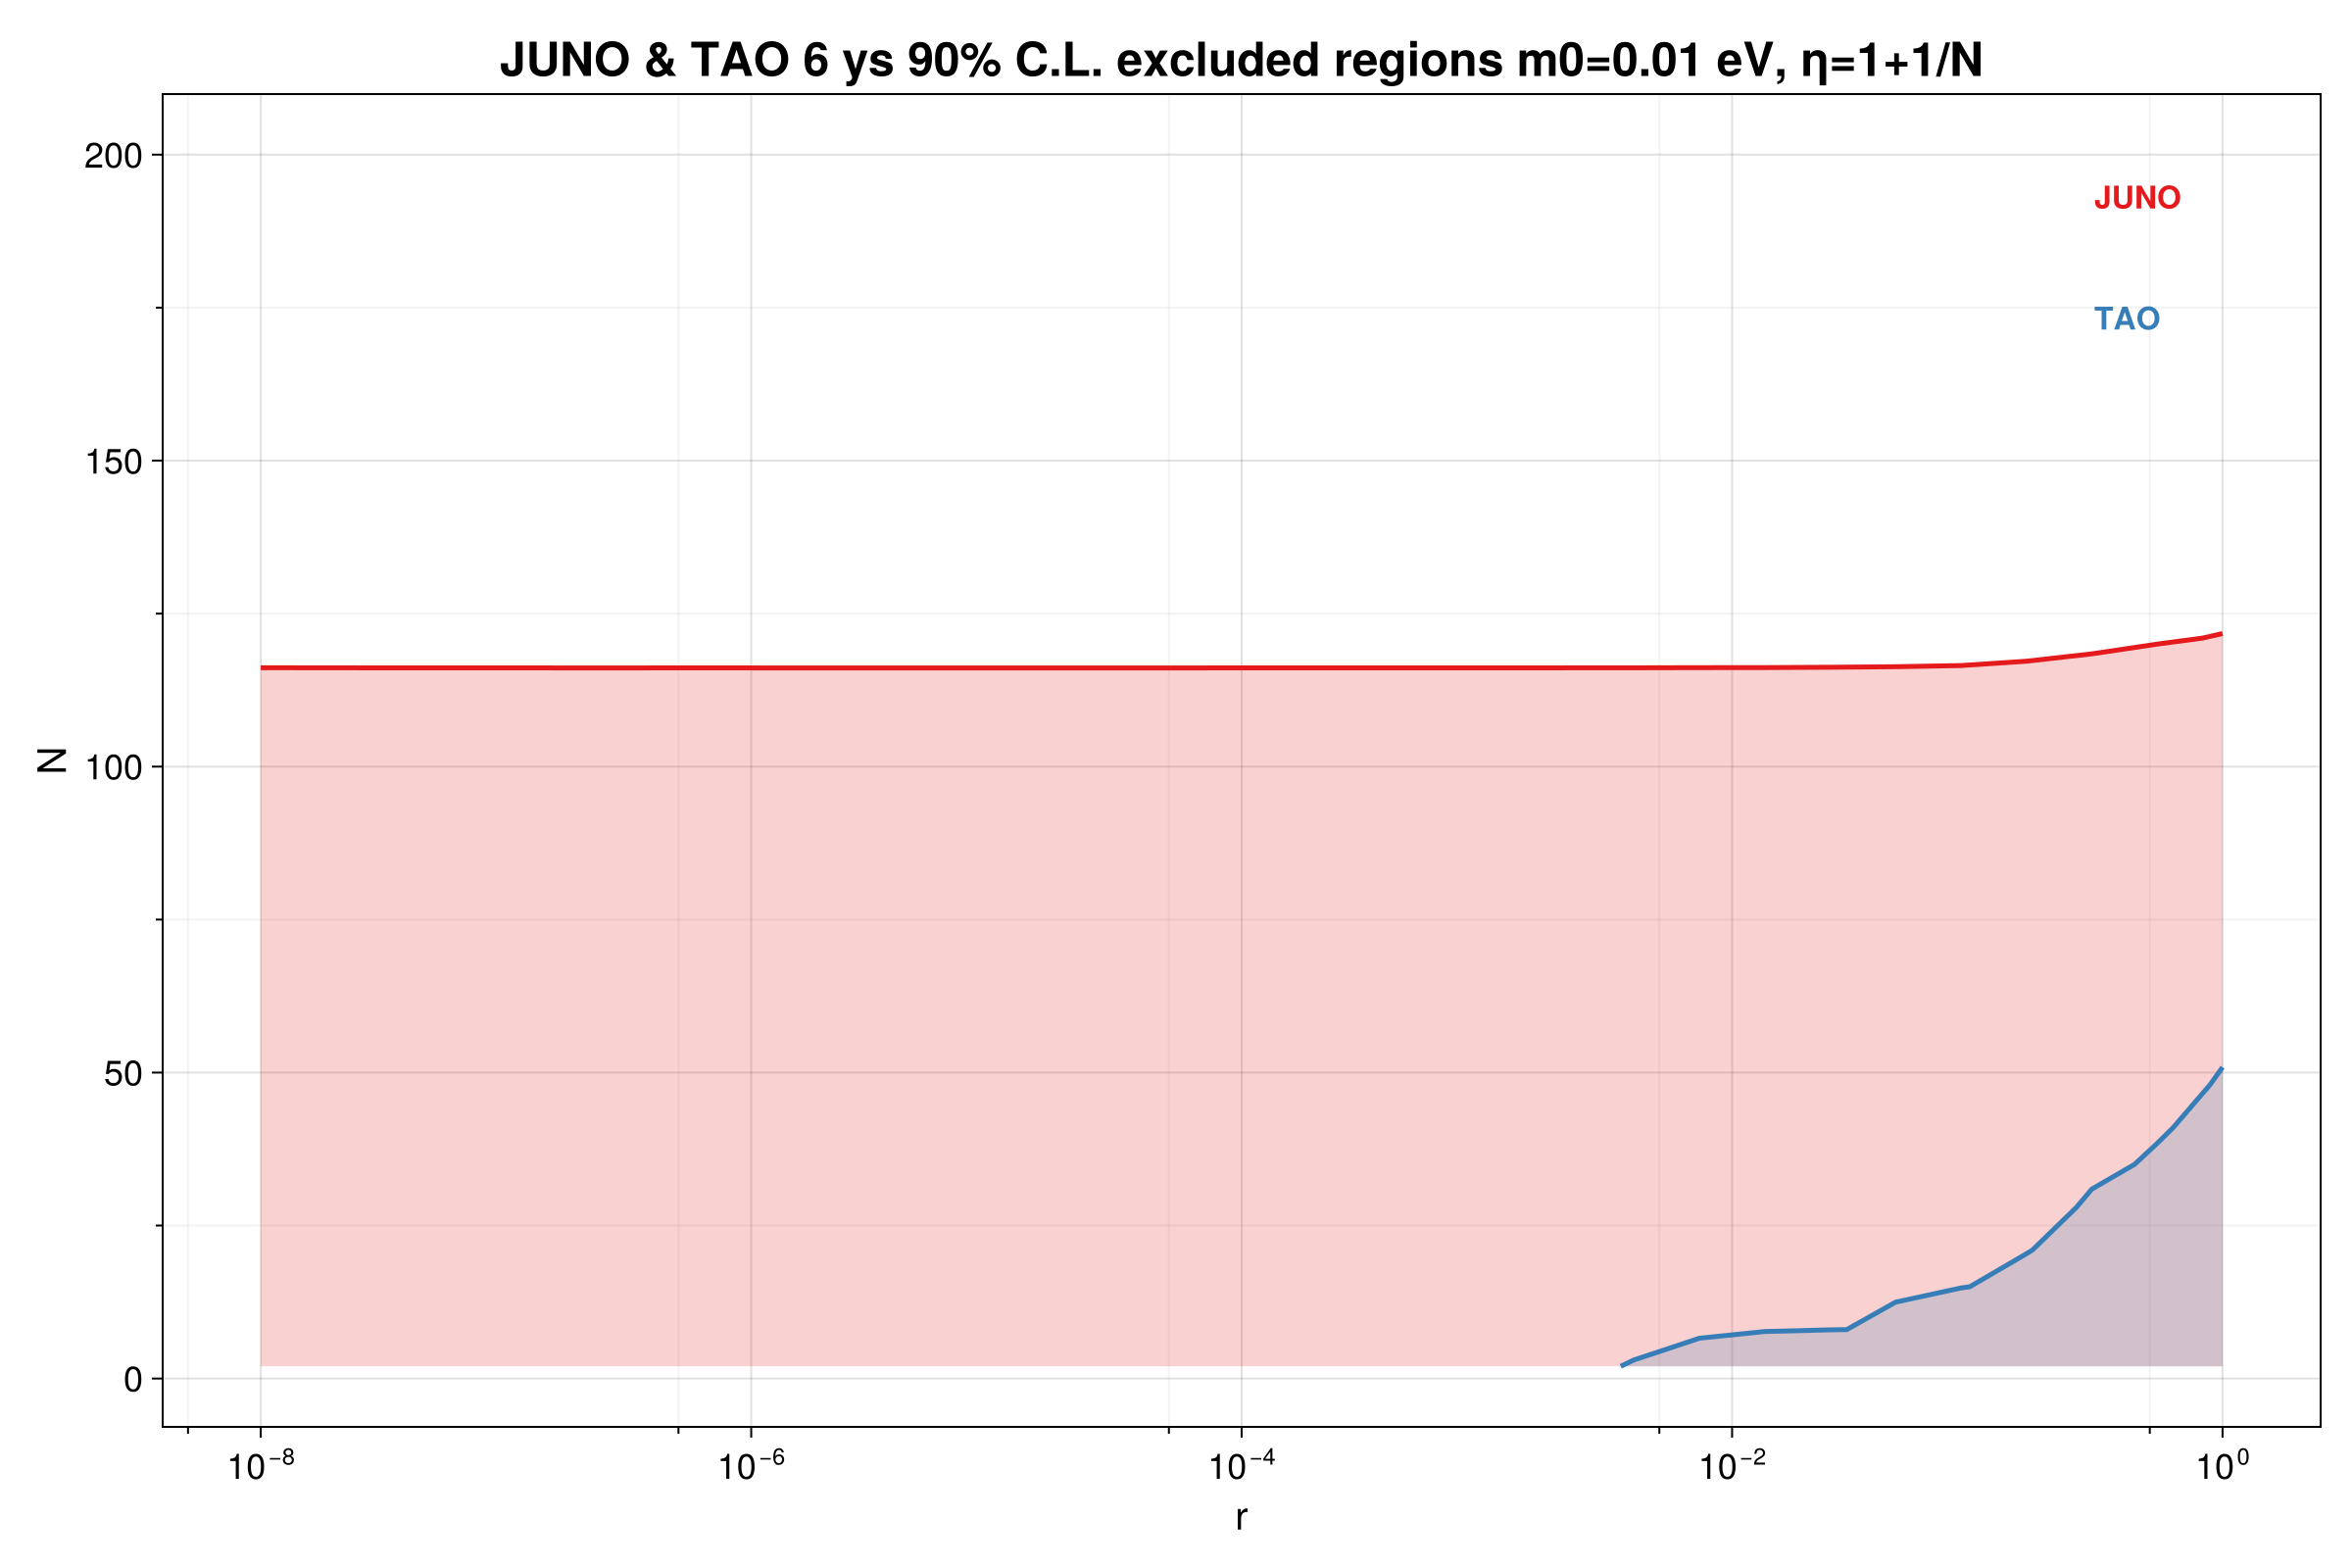

In [6]:



function superpose_contours_outside(file_paths::Vector{String}; 
                           title="Superposed Contours",
                           xlabel="Parameter 1", 
                           ylabel="Parameter 2",
                           experiments=nothing,
                           colorscheme=nothing,
                           color_step=1,
                           linestyles=nothing,
                           xscale=identity,
                           yscale=identity,
                           smooth_sigma::Union{Nothing,Float64}=nothing)
 
    
    # Default colorscheme and linestyles
    if colorscheme === nothing
        colorscheme = :Dark2_8
    end
    if linestyles === nothing
        linestyles = fill(:solid, length(file_paths))
    end
    
    # Get colors from the colorscheme with step
    cs = getproperty(ColorSchemes, colorscheme)
    all_colors = cs.colors
    colors = all_colors[1:color_step:end]
    n_colors = length(file_paths)
    if n_colors > length(colors)
        # If we need more colors than available, interpolate
        colors = [colors[i] for i in range(1, length(colors), length=n_colors)]
    else
        colors = colors[1:n_colors]
    end
    

    
  
    sigma_90_excluded_level = quantile(Chisq(2), 0.90)
    
    # Load all results and find axis ranges
    results = []
    all_axes_1 = []
    all_axes_2 = []
    
    for file_path in file_paths
        result = load(file_path)["result"]  # Adjust key if needed
        push!(results, result)
        push!(all_axes_1, result.axes[1])
        push!(all_axes_2, result.axes[2])
    end
    
    # Find combined axis ranges
    x_min = minimum([minimum(ax) for ax in all_axes_1])
    x_max = maximum([maximum(ax) for ax in all_axes_1])
    y_min = minimum([minimum(ax) for ax in all_axes_2])
    y_max = maximum([maximum(ax) for ax in all_axes_2])
        
    # Get axis labels from first result
    first_result = results[1]
    axis_labels = collect(keys(first_result.axes))

    # Create figure
    f = Figure(size=(1200, 800))
    ax = Axis(f[1,1];
        xlabel = String(axis_labels[1]) , #*" (eV)"
        ylabel = String(axis_labels[2]) ,
        title = title,
        xminorticksvisible = true, 
        xminorgridvisible = true, 
        yminorticksvisible = true, 
        yminorgridvisible = true,
        titlesize = 24,
        xlabelsize = 20,
        ylabelsize = 20,
        xticklabelsize = 18,
        yticklabelsize = 18,
        xscale = xscale,
        yscale = yscale
    )
   # Plot contours
    for (idx, result) in enumerate(results)
        lp = result.values.log_posterior
        finite_mask = isfinite.(lp)

        if !any(finite_mask)
            @warn "Scan contains no finite likelihood values — skipping"
            continue
        end

        lp_max = maximum(lp[finite_mask])

        dLLH_raw = 2 .* (lp_max .- lp)

        dLLH = smooth_sigma === nothing ? dLLH_raw :
            gaussian_smooth(dLLH_raw; σ=smooth_sigma)


        dLLH_plot = copy(dLLH)
        dLLH_plot[.!isfinite.(dLLH_plot)] .= NaN

        maxlevel = maximum(skipmissing(vec(dLLH_plot)))
        ϵ = 1e-6  # numerical safety margin

        color = colors[idx]
        linestyle = linestyles[mod(idx-1, length(linestyles)) + 1]

        color_transparent = RGBA(color, 1.0)
        color_transparent_full = RGBA(color, 0.2)

        # --- SHADE ONLY IF EXCLUSION EXISTS ---
        if isfinite(maxlevel) && maxlevel > sigma_90_excluded_level + ϵ
            contourf!(ax,
                result.axes[1],
                result.axes[2],
                dLLH_plot;
                levels = [sigma_90_excluded_level, maxlevel],
                colormap = cgrad([color_transparent_full, color_transparent])
            )
        end

        # --- ALWAYS DRAW CONTOUR LINE ---
        contour!(ax,
            result.axes[1],
            result.axes[2],
            dLLH_plot;
            levels = [sigma_90_excluded_level],
            color = color,
            linewidth = 2.5,
            linestyle = linestyle
        )
      
        

    end
    if experiments !== nothing
        # Helper function to position in data space (works for log and linear)
        function position_in_range(min_val, max_val, fraction)
            if yscale == log10
                # Log scale: work in log space
                min_log = log10(min_val)
                max_log = log10(max_val)
                return 10 ^ (min_log + fraction * (max_log - min_log))
            else
                # Linear scale: work in linear space
                return min_val + fraction * (max_val - min_val)
            end
        end
        
        fractions_y = range(0.95, 0.85, length=length(experiments))
        y_positions = [position_in_range(y_min, y_max, f) for f in fractions_y]
        x_position = position_in_range(x_min, x_max, 0.3)
        
        for (idx, label) in enumerate(experiments)
            color = colors[idx]
            text!(ax, x_position, y_positions[idx], 
                  text = label,
                  fontsize = 16,
                  color = color,
                  font = :bold)
        end
    end
    
    f
end


file_paths = ["/home/sofialon/Newtrinos.jl/plots_fix/junotao_m/junotao_toynor_rN_NNM_IO_m0=0.01.jld2",
              "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/taoonly_full6_rN_NNM_IO_η=1+1_N_m0=0.01_log.jld2"]
                
fig = superpose_contours_outside(file_paths;  
    title="JUNO & TAO 6 ys 90% C.L. excluded regions m0=0.01 eV, η=1+1/N",
    experiments = ["JUNO", "TAO"], 
    colorscheme = :Set1_9,
    color_step = 1,
    xscale=log10,
    #yscale=log10,
    smooth_sigma=nothing)

display("image/png",fig)
#save("/home/sofialon/Newtrinos.jl/plots_fix/plots_newex/superposed_contours_juno6_rN_log.png", fig)


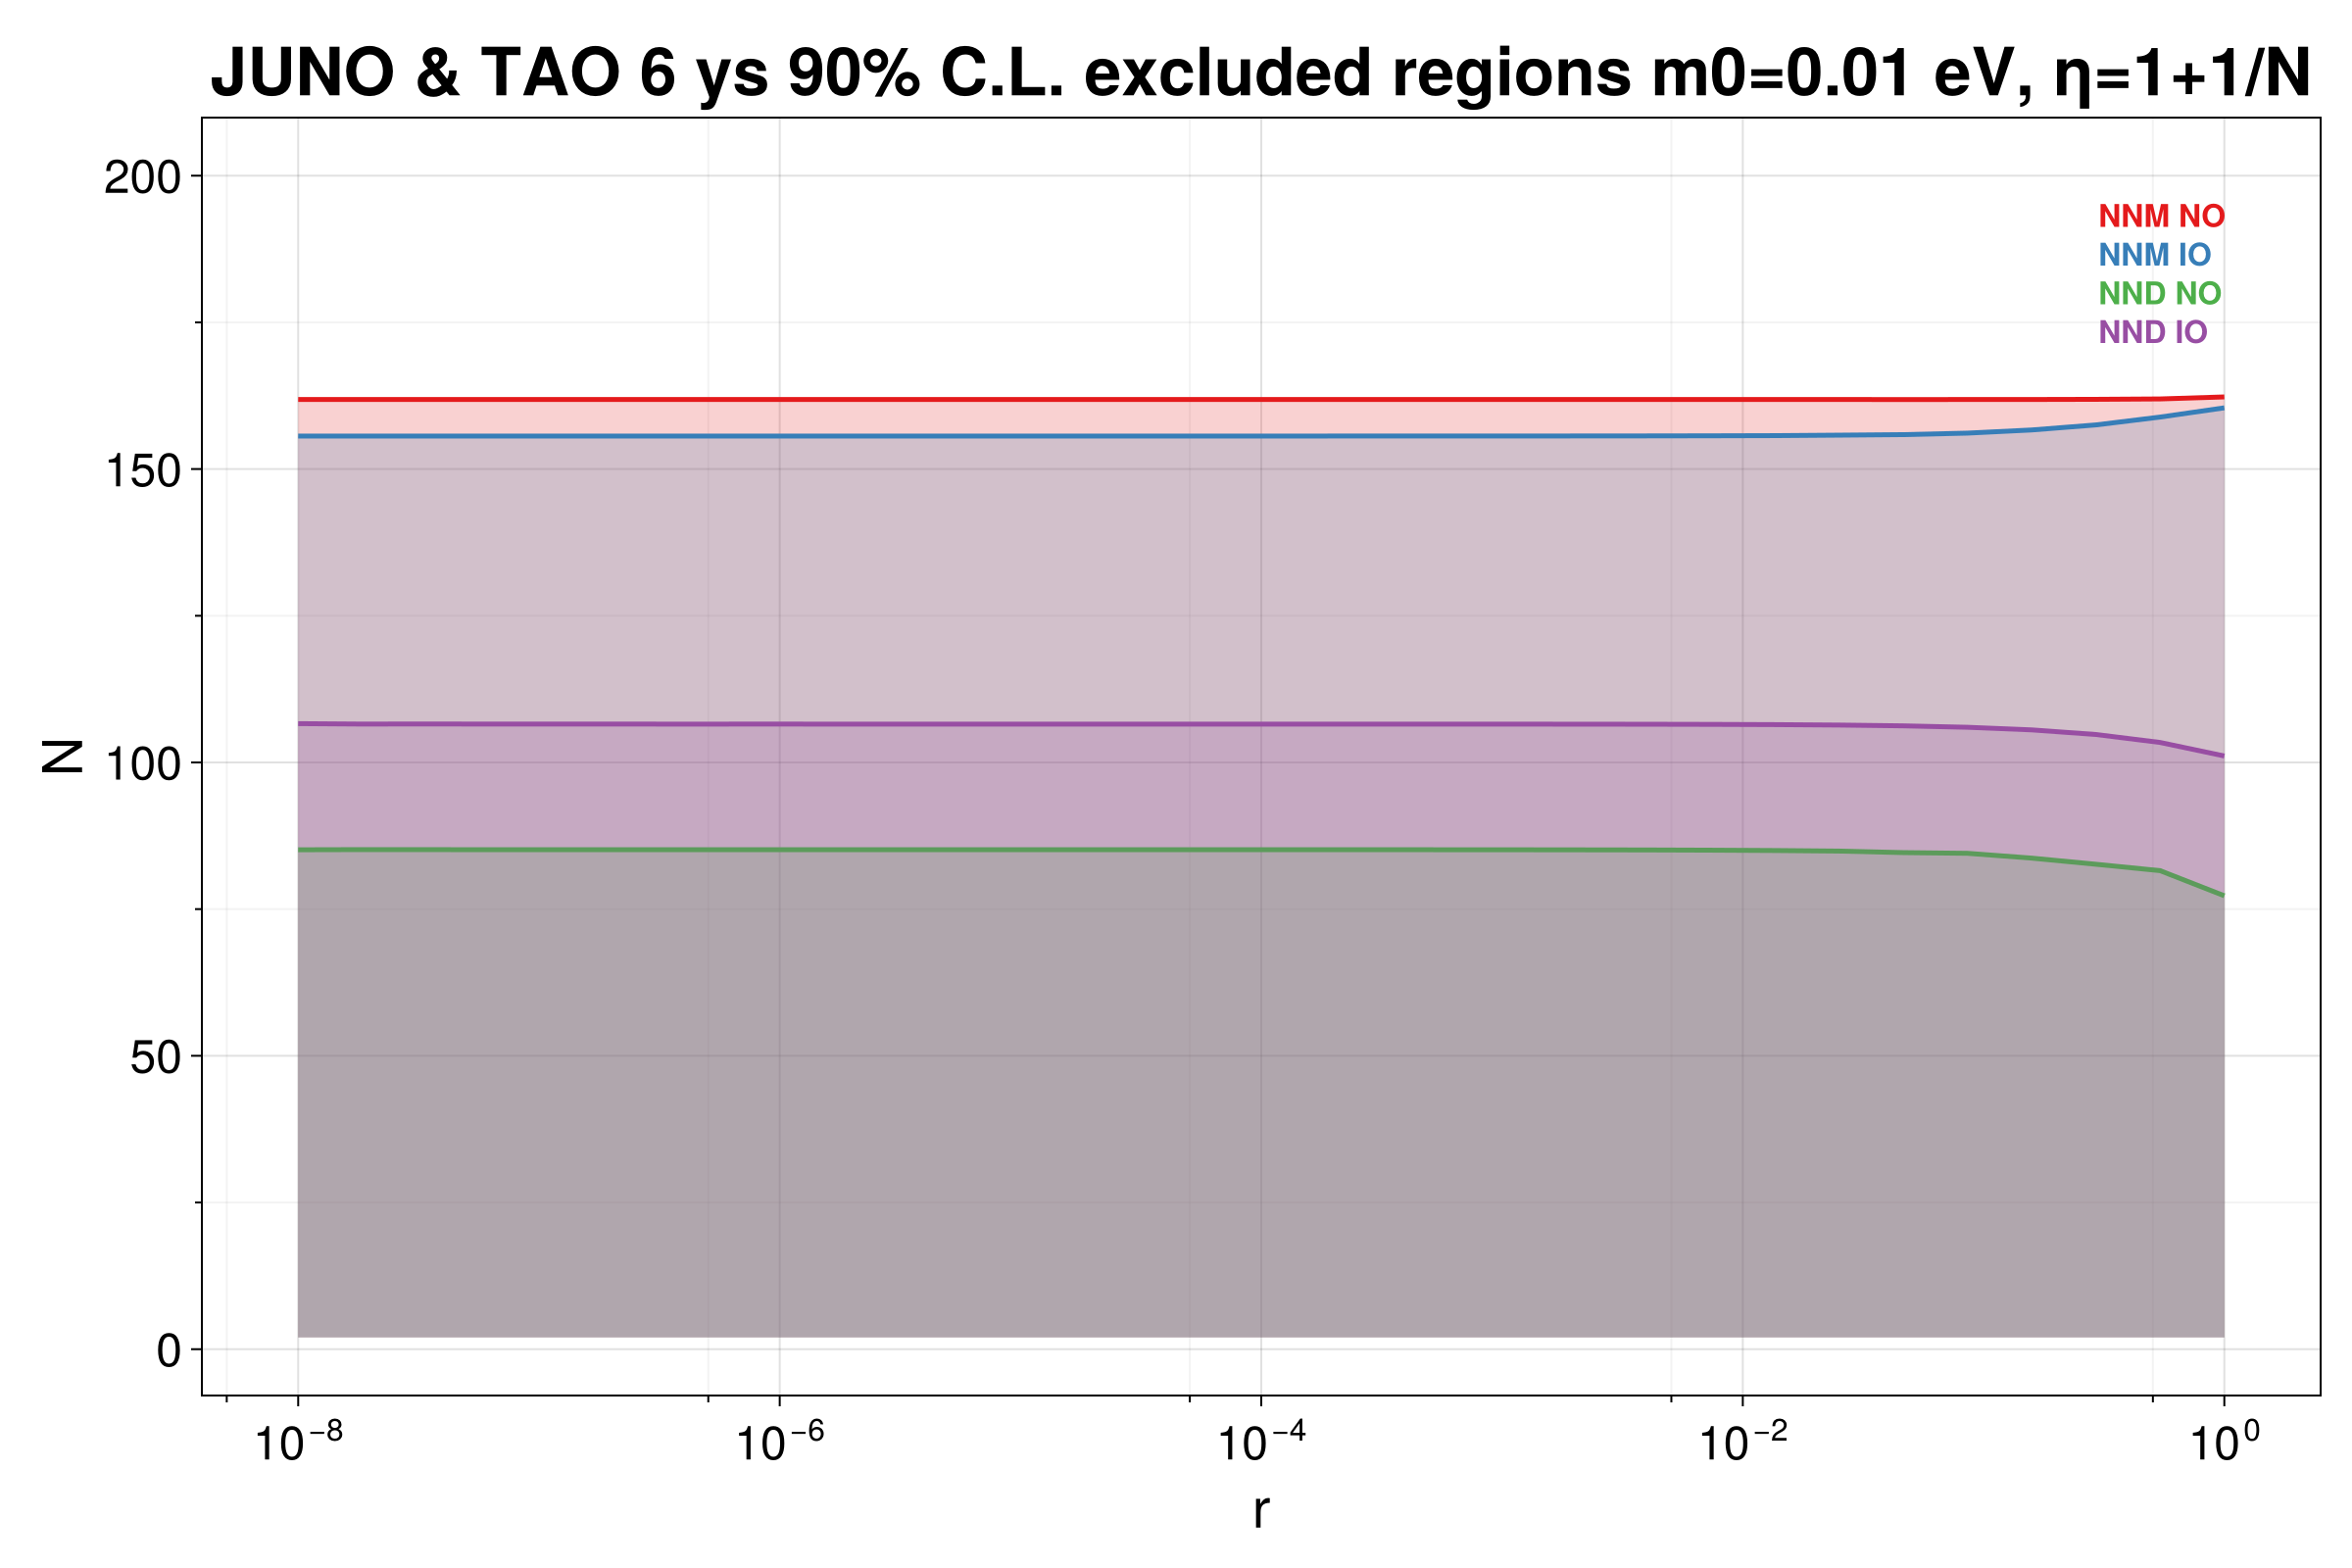

In [18]:
using ImageFiltering
using Colors, ColorSchemes

function superpose_contours_outside(file_paths::Vector{String}; 
                           title="Superposed Contours",
                           xlabel="Parameter 1", 
                           ylabel="Parameter 2",
                           experiments=nothing,
                           colorscheme=nothing,
                           color_step=1,
                           linestyles=nothing,
                           xscale=identity,
                           yscale=identity,
                           smooth_sigma::Union{Nothing,Float64}=nothing)
 
    
    # Default colorscheme and linestyles
    if colorscheme === nothing
        colorscheme = :Dark2_8
    end
    if linestyles === nothing
        linestyles = fill(:solid, length(file_paths))
    end
    
    # Get colors from the colorscheme with step
    cs = getproperty(ColorSchemes, colorscheme)
    all_colors = cs.colors
    colors = all_colors[1:color_step:end]
    n_colors = length(file_paths)
    if n_colors > length(colors)
        # If we need more colors than available, interpolate
       colors = [colors[Int(round(i))] for i in range(1, length(colors), length=n_colors)]
    else
        colors = colors[1:n_colors]
    end
    

    
  
    sigma_90_excluded_level = quantile(Chisq(2), 0.90)
    
    # Load all results and find axis ranges
    results = []
    all_axes_1 = []
    all_axes_2 = []
    
    for file_path in file_paths
        result = load(file_path)["result"]  # Adjust key if needed
        push!(results, result)
        push!(all_axes_1, result.axes[1])
        push!(all_axes_2, result.axes[2])
    end
    
    # Find combined axis ranges
    x_min = minimum([minimum(ax) for ax in all_axes_1])
    x_max = maximum([maximum(ax) for ax in all_axes_1])
    y_min = minimum([minimum(ax) for ax in all_axes_2])
    y_max = maximum([maximum(ax) for ax in all_axes_2])
        
    # Get axis labels from first result
    first_result = results[1]
    axis_labels = collect(keys(first_result.axes))

    # Create figure
    f = Figure(size=(1200, 800))
    ax = Axis(f[1,1];
        xlabel = String(axis_labels[1]) , #*" (eV)"
        ylabel = String(axis_labels[2]) ,
        title = title,
        xminorticksvisible = true,
        xminorgridvisible = true,
        yminorticksvisible = true,
        yminorgridvisible = true,
        titlesize = 34,
        xlabelsize = 28,
        ylabelsize = 28,
        xticklabelsize = 24,
        yticklabelsize = 24,
        xscale = xscale,
        yscale = yscale
    )
   # Plot contours
    for (idx, result) in enumerate(results)
        lp = result.values.log_posterior
        finite_mask = isfinite.(lp)

        if !any(finite_mask)
            @warn "Scan contains no finite likelihood values — skipping"
            continue
        end

        lp_max = maximum(lp[finite_mask])

        dLLH_raw = 2 .* (lp_max .- lp)

        dLLH = smooth_sigma === nothing ? dLLH_raw :
            gaussian_smooth(dLLH_raw; σ=smooth_sigma)


        dLLH_plot = copy(dLLH)
        dLLH_plot[.!isfinite.(dLLH_plot)] .= NaN

        maxlevel = maximum(skipmissing(vec(dLLH_plot)))
        ϵ = 1e-6  # numerical safety margin

        color = colors[idx]
        linestyle = linestyles[mod(idx-1, length(linestyles)) + 1]

        color_transparent = RGBA(color, 1.0)
        color_transparent_full = RGBA(color, 0.2)

        # --- SHADE ONLY IF EXCLUSION EXISTS ---
        if isfinite(maxlevel) && maxlevel > sigma_90_excluded_level + ϵ
            contourf!(ax,
                result.axes[1],
                result.axes[2],
                dLLH_plot;
                levels = [sigma_90_excluded_level, maxlevel],
                colormap = cgrad([color_transparent_full, color_transparent])
            )
        end

        # --- ALWAYS DRAW CONTOUR LINE ---
        contour!(ax,
            result.axes[1],
            result.axes[2],
            dLLH_plot;
            levels = [sigma_90_excluded_level],
            color = color,
            linewidth = 2.5,
            linestyle = linestyle
        )
      
        

    end
    if experiments !== nothing
        # Helper function to position in data space (works for log and linear)
        function position_in_range(min_val, max_val, fraction)
            if yscale == log10
                # Log scale: work in log space
                min_log = log10(min_val)
                max_log = log10(max_val)
                return 10 ^ (min_log + fraction * (max_log - min_log))
            else
                # Linear scale: work in linear space
                return min_val + fraction * (max_val - min_val)
            end
        end
        
        fractions_y = range(0.95, 0.85, length=length(experiments))
        y_positions = [position_in_range(y_min, y_max, f) for f in fractions_y]
        x_position = position_in_range(x_min, x_max, 0.3)
        
        for (idx, label) in enumerate(experiments)
            color = colors[idx]
            text!(ax, x_position, y_positions[idx], 
                  text = label,
                  fontsize = 16,
                  color = color,
                  font = :bold)
        end
    end
    
    f
end


file_paths = ["/home/sofialon/Newtrinos.jl/plots_fix/junotao_m/junotao_toyschur_rN_NNM_NO_m0=0.01.jld2",
              "/home/sofialon/Newtrinos.jl/plots_fix/junotao_m/junotao_toyschur_rN_NNM_IO_m0=0.01.jld2",
                  "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/junotao_full6_rN_NND_NO_η=1+1_N_m0=0.01_log.jld2",
               "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/junotao_full6_rN_NND_IO_η=1+1_N_m0=0.01_log1000.jld2"]
    
                
fig = superpose_contours_outside(file_paths;  
    title="JUNO & TAO 6 ys 90% C.L. excluded regions m0=0.01 eV, η=1+1/N",
    experiments = ["NNM NO", "NNM IO", "NND NO","NND IO"], 
    colorscheme = :Set1_9,
    color_step = 1,
    xscale=log10,
    #yscale=log10,
    smooth_sigma=nothing)

display("image/png",fig)
#save("/home/sofialon/Newtrinos.jl/plots_fix/plots_newex/superposed_contours_juno6_rN_log.png", fig)


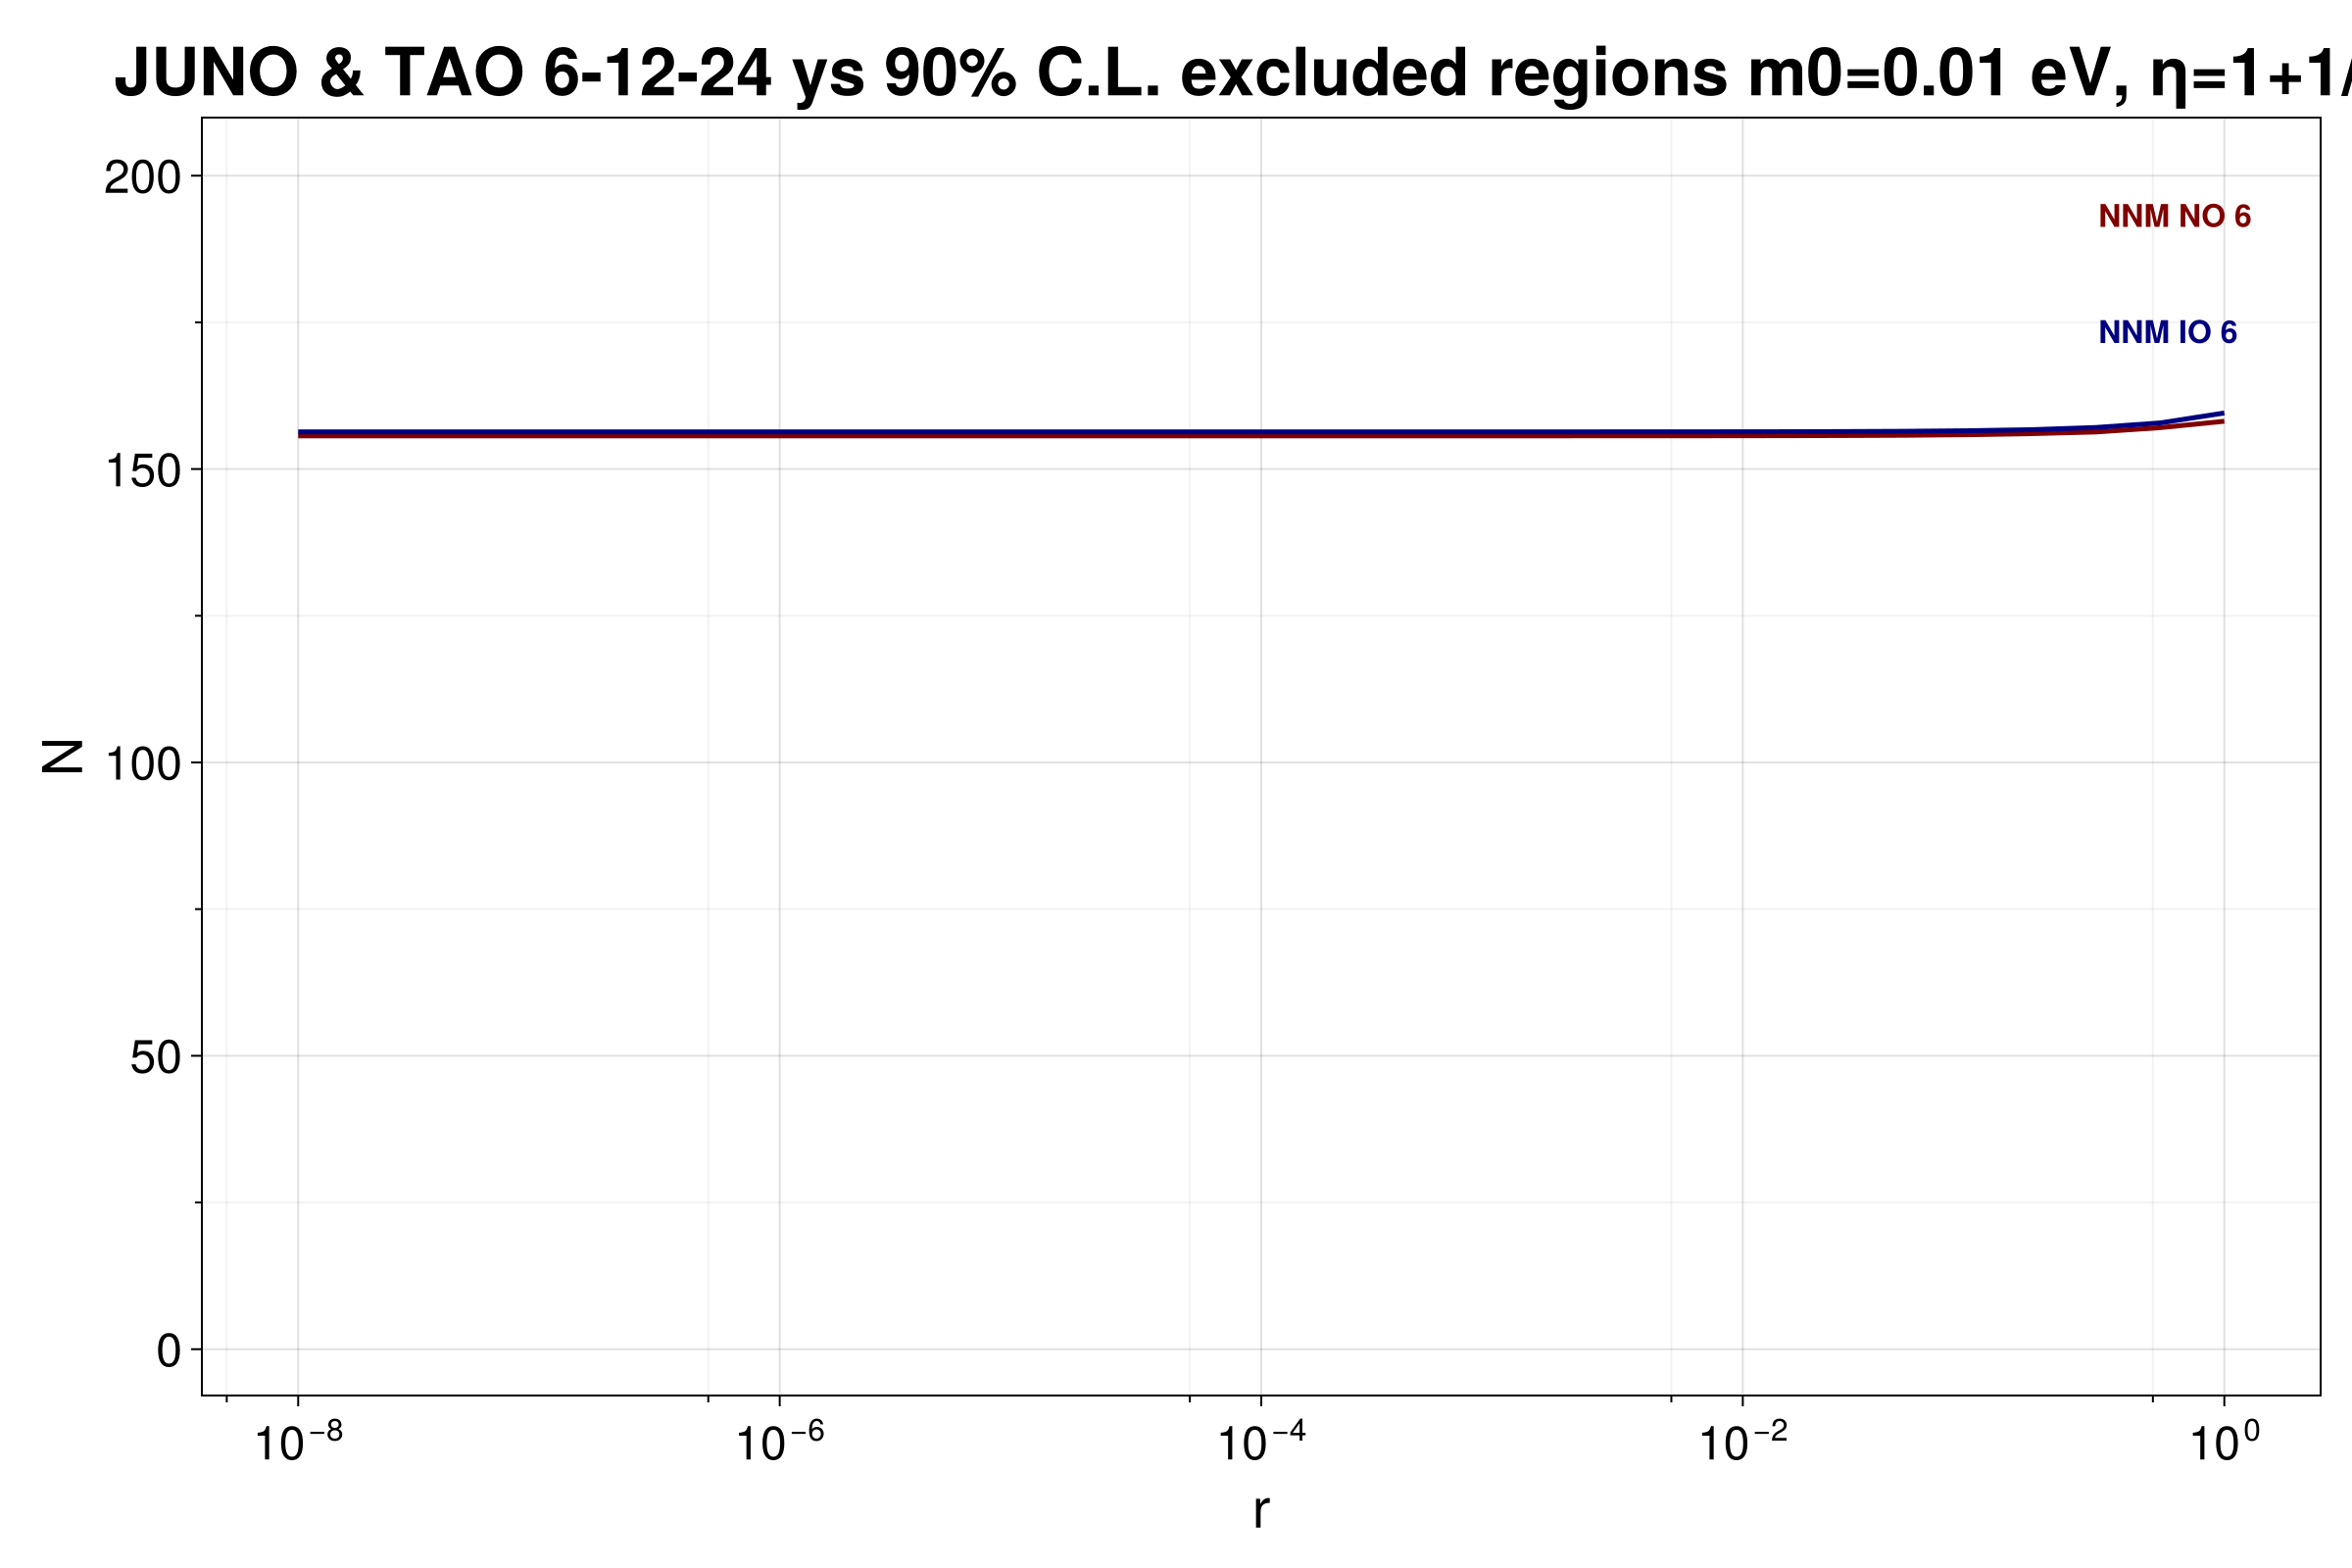

In [33]:
function superpose_contours_outside(file_paths::Vector{String}; 
                           title="Superposed Contours",
                           xlabel="Parameter 1", 
                           ylabel="Parameter 2",
                           experiments=nothing,
                           colorscheme=nothing,
                           color_step=1,
                           linestyles=nothing,
                           xscale=identity,
                           yscale=identity,
                           smooth_sigma::Union{Nothing,Float64}=nothing)

    sigma_90_excluded_level = quantile(Chisq(2), 0.90)
    
    results = []
    all_axes_1 = []
    all_axes_2 = []
    
    for file_path in file_paths
        result = load(file_path)["result"]
        push!(results, result)
        push!(all_axes_1, result.axes[1])
        push!(all_axes_2, result.axes[2])
    end
    
    x_min = minimum([minimum(ax) for ax in all_axes_1])
    x_max = maximum([maximum(ax) for ax in all_axes_1])
    y_min = minimum([minimum(ax) for ax in all_axes_2])
    y_max = maximum([maximum(ax) for ax in all_axes_2])
        
    first_result = results[1]
    axis_labels = collect(keys(first_result.axes))

    f = Figure(size=(1200, 800))

    ax = Axis(f[1,1];
        xlabel = String(axis_labels[1]),
        ylabel = String(axis_labels[2]),
        title = title,
        xminorticksvisible = true,
        xminorgridvisible = true,
        yminorticksvisible = true,
        yminorgridvisible = true,
        titlesize = 34,
        xlabelsize = 28,
        ylabelsize = 28,
        xticklabelsize = 24,
        yticklabelsize = 24,
        xscale = xscale,
        yscale = yscale
    )

    # 4 base colors (model + ordering)
    base_colors = Dict(
       
    ("NNM","NO") => RGB(1.0, 0.0, 0.0),   # red
    ("NNM","IO") => RGB(0.0, 0.0, 1.0),   # blue
    ("NND","NO") => RGB(0.0, 0.6, 0.0),   # green
    ("NND","IO") => RGB(0.6, 0.0, 0.8)    # violet
        )
    

    # year shading
    year_shades = Dict(
        6  => 0.5,
        12 => 0.75,
        24 => 1.0
    )

    # Plot contours
    for (idx, result) in enumerate(results)

        label = experiments[idx]
        parts = split(label)

        model = parts[1]
        ordering = parts[2]
        year = parse(Int, parts[3])

        base = base_colors[(model, ordering)]
        shade = year_shades[year]

        color = RGB(base.r*shade, base.g*shade, base.b*shade)

        lp = result.values.log_posterior
        finite_mask = isfinite.(lp)

        if !any(finite_mask)
            @warn "Scan contains no finite likelihood values — skipping"
            continue
        end

        lp_max = maximum(lp[finite_mask])

        dLLH_raw = 2 .* (lp_max .- lp)

        dLLH = smooth_sigma === nothing ? dLLH_raw :
            gaussian_smooth(dLLH_raw; σ=smooth_sigma)

        dLLH_plot = copy(dLLH)
        dLLH_plot[.!isfinite.(dLLH_plot)] .= NaN

        contour!(ax,
            result.axes[1],
            result.axes[2],
            dLLH_plot;
            levels = [sigma_90_excluded_level],
            color = color,
            linewidth = 2.5
        )
    end

    if experiments !== nothing

        function position_in_range(min_val, max_val, fraction)
            if yscale == log10
                min_log = log10(min_val)
                max_log = log10(max_val)
                return 10 ^ (min_log + fraction * (max_log - min_log))
            else
                return min_val + fraction * (max_val - min_val)
            end
        end
        
        fractions_y = range(0.95, 0.85, length=length(experiments))
        y_positions = [position_in_range(y_min, y_max, f) for f in fractions_y]
        x_position = position_in_range(x_min, x_max, 0.3)
        
        for (idx, label) in enumerate(experiments)

            parts = split(label)
            model = parts[1]
            ordering = parts[2]
            year = parse(Int, parts[3])

            base = base_colors[(model, ordering)]
            shade = year_shades[year]

            color = RGB(base.r*shade, base.g*shade, base.b*shade)

            text!(ax, x_position, y_positions[idx], 
                  text = label,
                  fontsize = 16,
                  color = color,
                  font = :bold)
        end
    end
    
    f
end

file_paths = [#"/home/sofialon/Newtrinos.jl/plots_fix/junotao_m/junotao_toyschur_rN_NNM_NO_m0=0.01.jld2",
              #"/home/sofialon/Newtrinos.jl/plots_fix/junotao_m/junotao_toyschur_rN_NNM_IO_m0=0.01.jld2",
                # "/home/sofialon/Newtrinos.jl/plots_fix/junotao_m/junotao_toyschur_rN_NND_NO_m0=0.01.jld2",
               #"/home/sofialon/Newtrinos.jl/plots_fix/junotao_m/junotao_toyschur_rN_NND_IO_m0=0.01.jld2"
               #"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/junotao_schur12_rN_NNM_NO_m0=0.01.jld2",
               #"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/junotao_schur12_rN_NNM_IO_m0=0.01.jld2",
               #"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/junotao_schur12_rN_NND_NO_m0=0.01.jld2",
               #"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/junotao_schur12_rN_NND_IO_m0=0.01.jld2",
               # "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/junotao_schur24_rN_NNM_NO_m0=0.01.jld2",
              #"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/junotao_schur24_rN_NNM_IO_m0=0.01.jld2",
                 "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/junotao_schur24_rN_NND_NO_m0=0.01.jld2",
              "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/junotao_schur24_rN_NND_IO_m0=0.01.jld2"
               ]
    
                
fig = superpose_contours_outside(file_paths;  
    title="JUNO & TAO 6-12-24 ys 90% C.L. excluded regions m0=0.01 eV, η=1+1/N",
    experiments = ["NNM NO 6", "NNM IO 6"], #"NND NO 6","NND IO 6"],
                   #"NNM NO 12", "NNM IO 12", "NND NO 12","NND IO 12",
                   #"NNM NO 24", "NNM IO 24", "NND NO 24","NND IO 24"], 
    colorscheme = :Set1_9,
    color_step = 1,
    xscale=log10,
    #yscale=log10,
    smooth_sigma=nothing)

display("image/png",fig)
#save("/home/sofialon/Newtrinos.jl/plots_svg/juno/superposed_contours_juno6_rN_log.svg", fig)
#save("/home/sofialon/Newtrinos.jl/plots_svg/juno/superposed_contours_juno6_rN_log.png", fig)


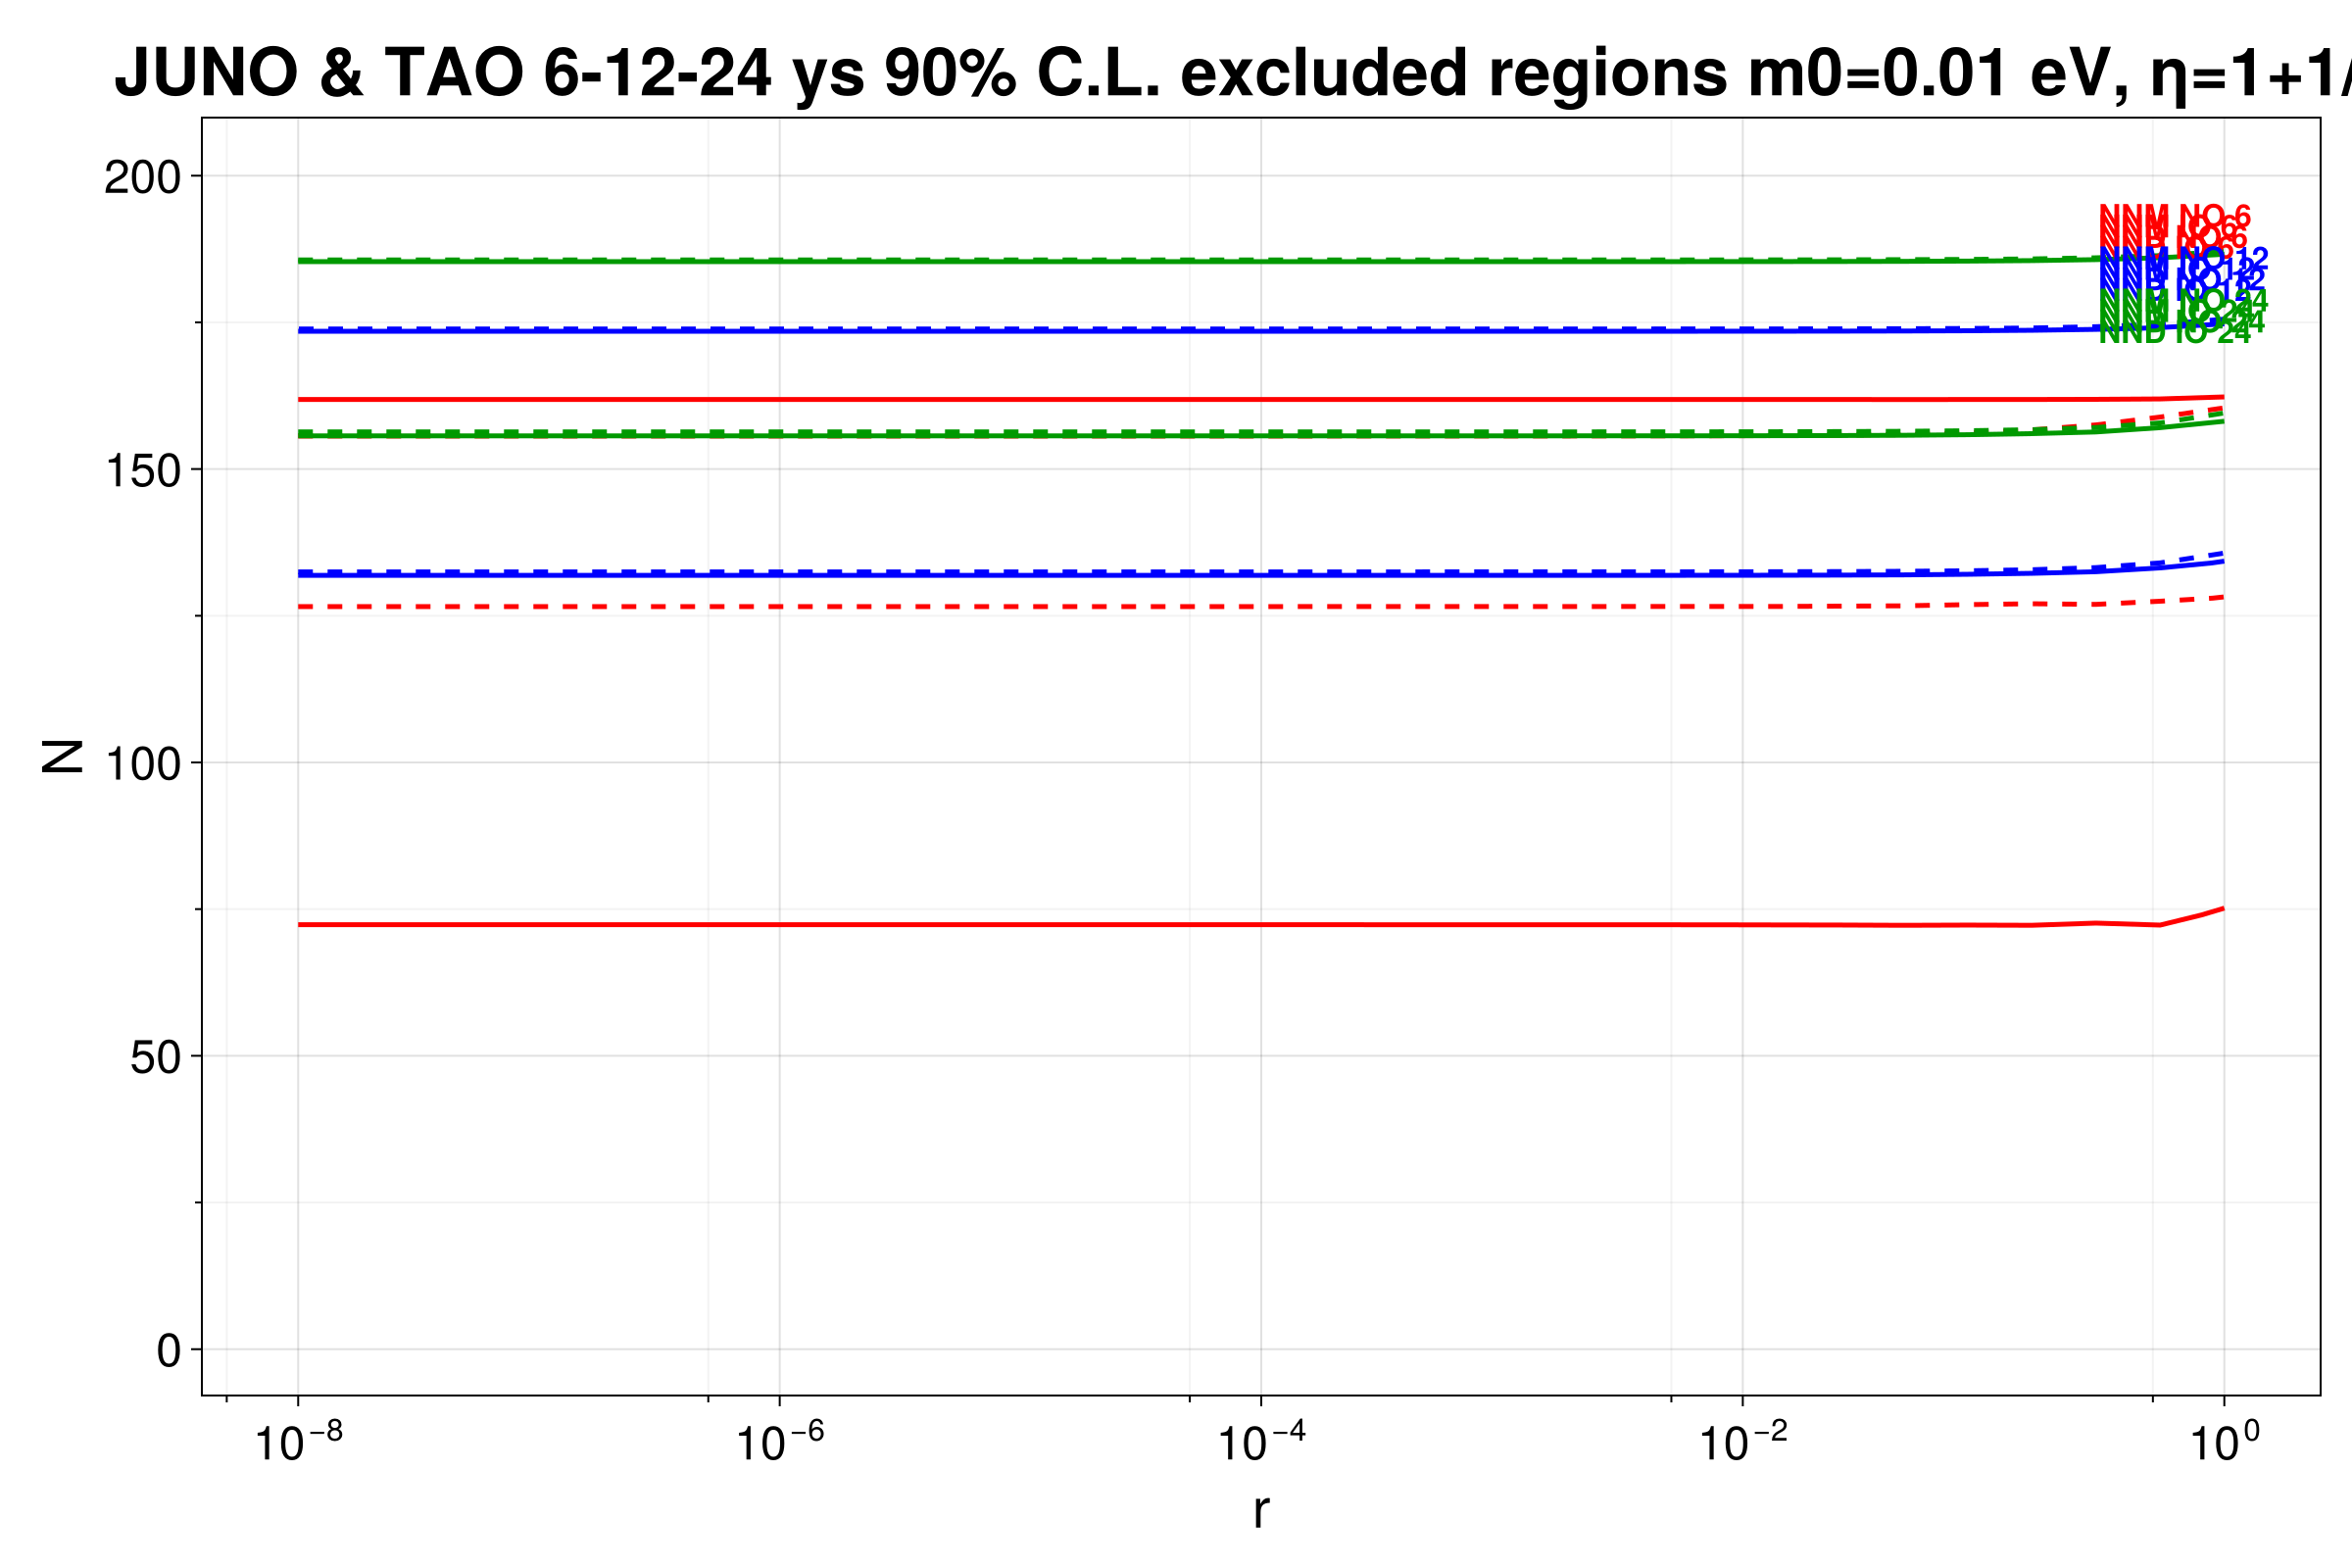

In [ ]:
function superpose_contours_outside(file_paths::Vector{String}; 
                           title="Superposed Contours",
                           xlabel="Parameter 1", 
                           ylabel="Parameter 2",
                           experiments=nothing,
                           colorscheme=nothing,
                           color_step=1,
                           linestyles=nothing,
                           xscale=identity,
                           yscale=identity,
                           smooth_sigma::Union{Nothing,Float64}=nothing)

    sigma_90_excluded_level = quantile(Chisq(2), 0.90)
    
    results = []
    all_axes_1 = []
    all_axes_2 = []
    
    for file_path in file_paths
        result = load(file_path)["result"]
        push!(results, result)
        push!(all_axes_1, result.axes[1])
        push!(all_axes_2, result.axes[2])
    end
    
    x_min = minimum([minimum(ax) for ax in all_axes_1])
    x_max = maximum([maximum(ax) for ax in all_axes_1])
    y_min = minimum([minimum(ax) for ax in all_axes_2])
    y_max = maximum([maximum(ax) for ax in all_axes_2])
        
    first_result = results[1]
    axis_labels = collect(keys(first_result.axes))

    f = Figure(size=(1200, 800))

    ax = Axis(f[1,1];
        xlabel = String(axis_labels[1]),
        ylabel = String(axis_labels[2]),
        title = title,
        xminorticksvisible = true,
        xminorgridvisible = true,
        yminorticksvisible = true,
        yminorgridvisible = true,
        titlesize = 34,
        xlabelsize = 28,
        ylabelsize = 28,
        xticklabelsize = 24,
        yticklabelsize = 24,
        xscale = xscale,
        yscale = yscale
    )

    # Year → color
    year_colors = Dict(
        6  => RGB(1.0,0.0,0.0),   # red
        12 => RGB(0.0,0.0,1.0),   # blue
        24 => RGB(0.0,0.6,0.0)    # green
    )

    # Plot contours
    for (idx, result) in enumerate(results)

        label = experiments[idx]
        parts = split(label)

        ordering = parts[2]
        year = parse(Int, parts[3])

        color = year_colors[year]
        linestyle = ordering == "NO" ? :solid : :dash

        lp = result.values.log_posterior
        finite_mask = isfinite.(lp)

        if !any(finite_mask)
            @warn "Scan contains no finite likelihood values — skipping"
            continue
        end

        lp_max = maximum(lp[finite_mask])

        dLLH_raw = 2 .* (lp_max .- lp)

        dLLH = smooth_sigma === nothing ? dLLH_raw :
            gaussian_smooth(dLLH_raw; σ=smooth_sigma)

        dLLH_plot = copy(dLLH)
        dLLH_plot[.!isfinite.(dLLH_plot)] .= NaN

        contour!(ax,
            result.axes[1],
            result.axes[2],
            dLLH_plot;
            levels = [sigma_90_excluded_level],
            color = color,
            linewidth = 2.5,
            linestyle = linestyle
        )
    end

    if experiments !== nothing

        function position_in_range(min_val, max_val, fraction)
            if yscale == log10
                min_log = log10(min_val)
                max_log = log10(max_val)
                return 10^(min_log + fraction*(max_log-min_log))
            else
                return min_val + fraction*(max_val-min_val)
            end
        end
        
        fractions_y = range(0.95, 0.85, length=length(experiments))
        y_positions = [position_in_range(y_min, y_max, f) for f in fractions_y]
        x_position = position_in_range(x_min, x_max, 0.3)
        
        for (idx, label) in enumerate(experiments)

            parts = split(label)
            year = parse(Int, parts[3])

            color = year_colors[year]

            text!(ax, x_position, y_positions[idx], 
                  text = label,
                  fontsize = 16,
                  color = color,
                  font = :bold)
        end
    end
    
    f
end


file_paths = ["/home/sofialon/Newtrinos.jl/plots_fix/junotao_m/junotao_toyschur_rN_NNM_NO_m0=0.01.jld2",
              "/home/sofialon/Newtrinos.jl/plots_fix/junotao_m/junotao_toyschur_rN_NNM_IO_m0=0.01.jld2",
                 "/home/sofialon/Newtrinos.jl/plots_fix/junotao_m/junotao_toyschur_rN_NND_NO_m0=0.01.jld2",
               "/home/sofialon/Newtrinos.jl/plots_fix/junotao_m/junotao_toyschur_rN_NND_IO_m0=0.01.jld2",
               "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/junotao_schur12_rN_NNM_NO_m0=0.01.jld2",
              "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/junotao_schur12_rN_NNM_IO_m0=0.01.jld2",
                 "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/junotao_schur12_rN_NND_NO_m0=0.01.jld2",
               "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/junotao_schur12_rN_NND_IO_m0=0.01.jld2",
                "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/junotao_schur24_rN_NNM_NO_m0=0.01.jld2",
              "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/junotao_schur24_rN_NNM_IO_m0=0.01.jld2",
                 "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/junotao_schur24_rN_NND_NO_m0=0.01.jld2",
               "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/junotao_schur24_rN_NND_IO_m0=0.01.jld2"
               ]
    
                
fig = superpose_contours_outside(file_paths;  
    title="JUNO & TAO 6-12-24 ys 90% C.L. excluded regions m0=0.01 eV, η=1+1/N",
    experiments = ["NNM NO 6", "NNM IO 6", "NND NO 6","NND IO 6",
                   #"NNM NO 12", "NNM IO 12", "NND NO 12","NND IO 12",
                   #"NNM NO 24", "NNM IO 24", "NND NO 24","NND IO 24"], 
    colorscheme = :Set1_9,
    color_step = 1,
    xscale=log10,
    #yscale=log10,
    smooth_sigma=nothing)

display("image/png",fig)
#save("/home/sofialon/Newtrinos.jl/plots_svg/juno/superposed_contours_juno6_rN_log.svg", fig)
#save("/home/sofialon/Newtrinos.jl/plots_svg/juno/superposed_contours_juno6_rN_log.png", fig)


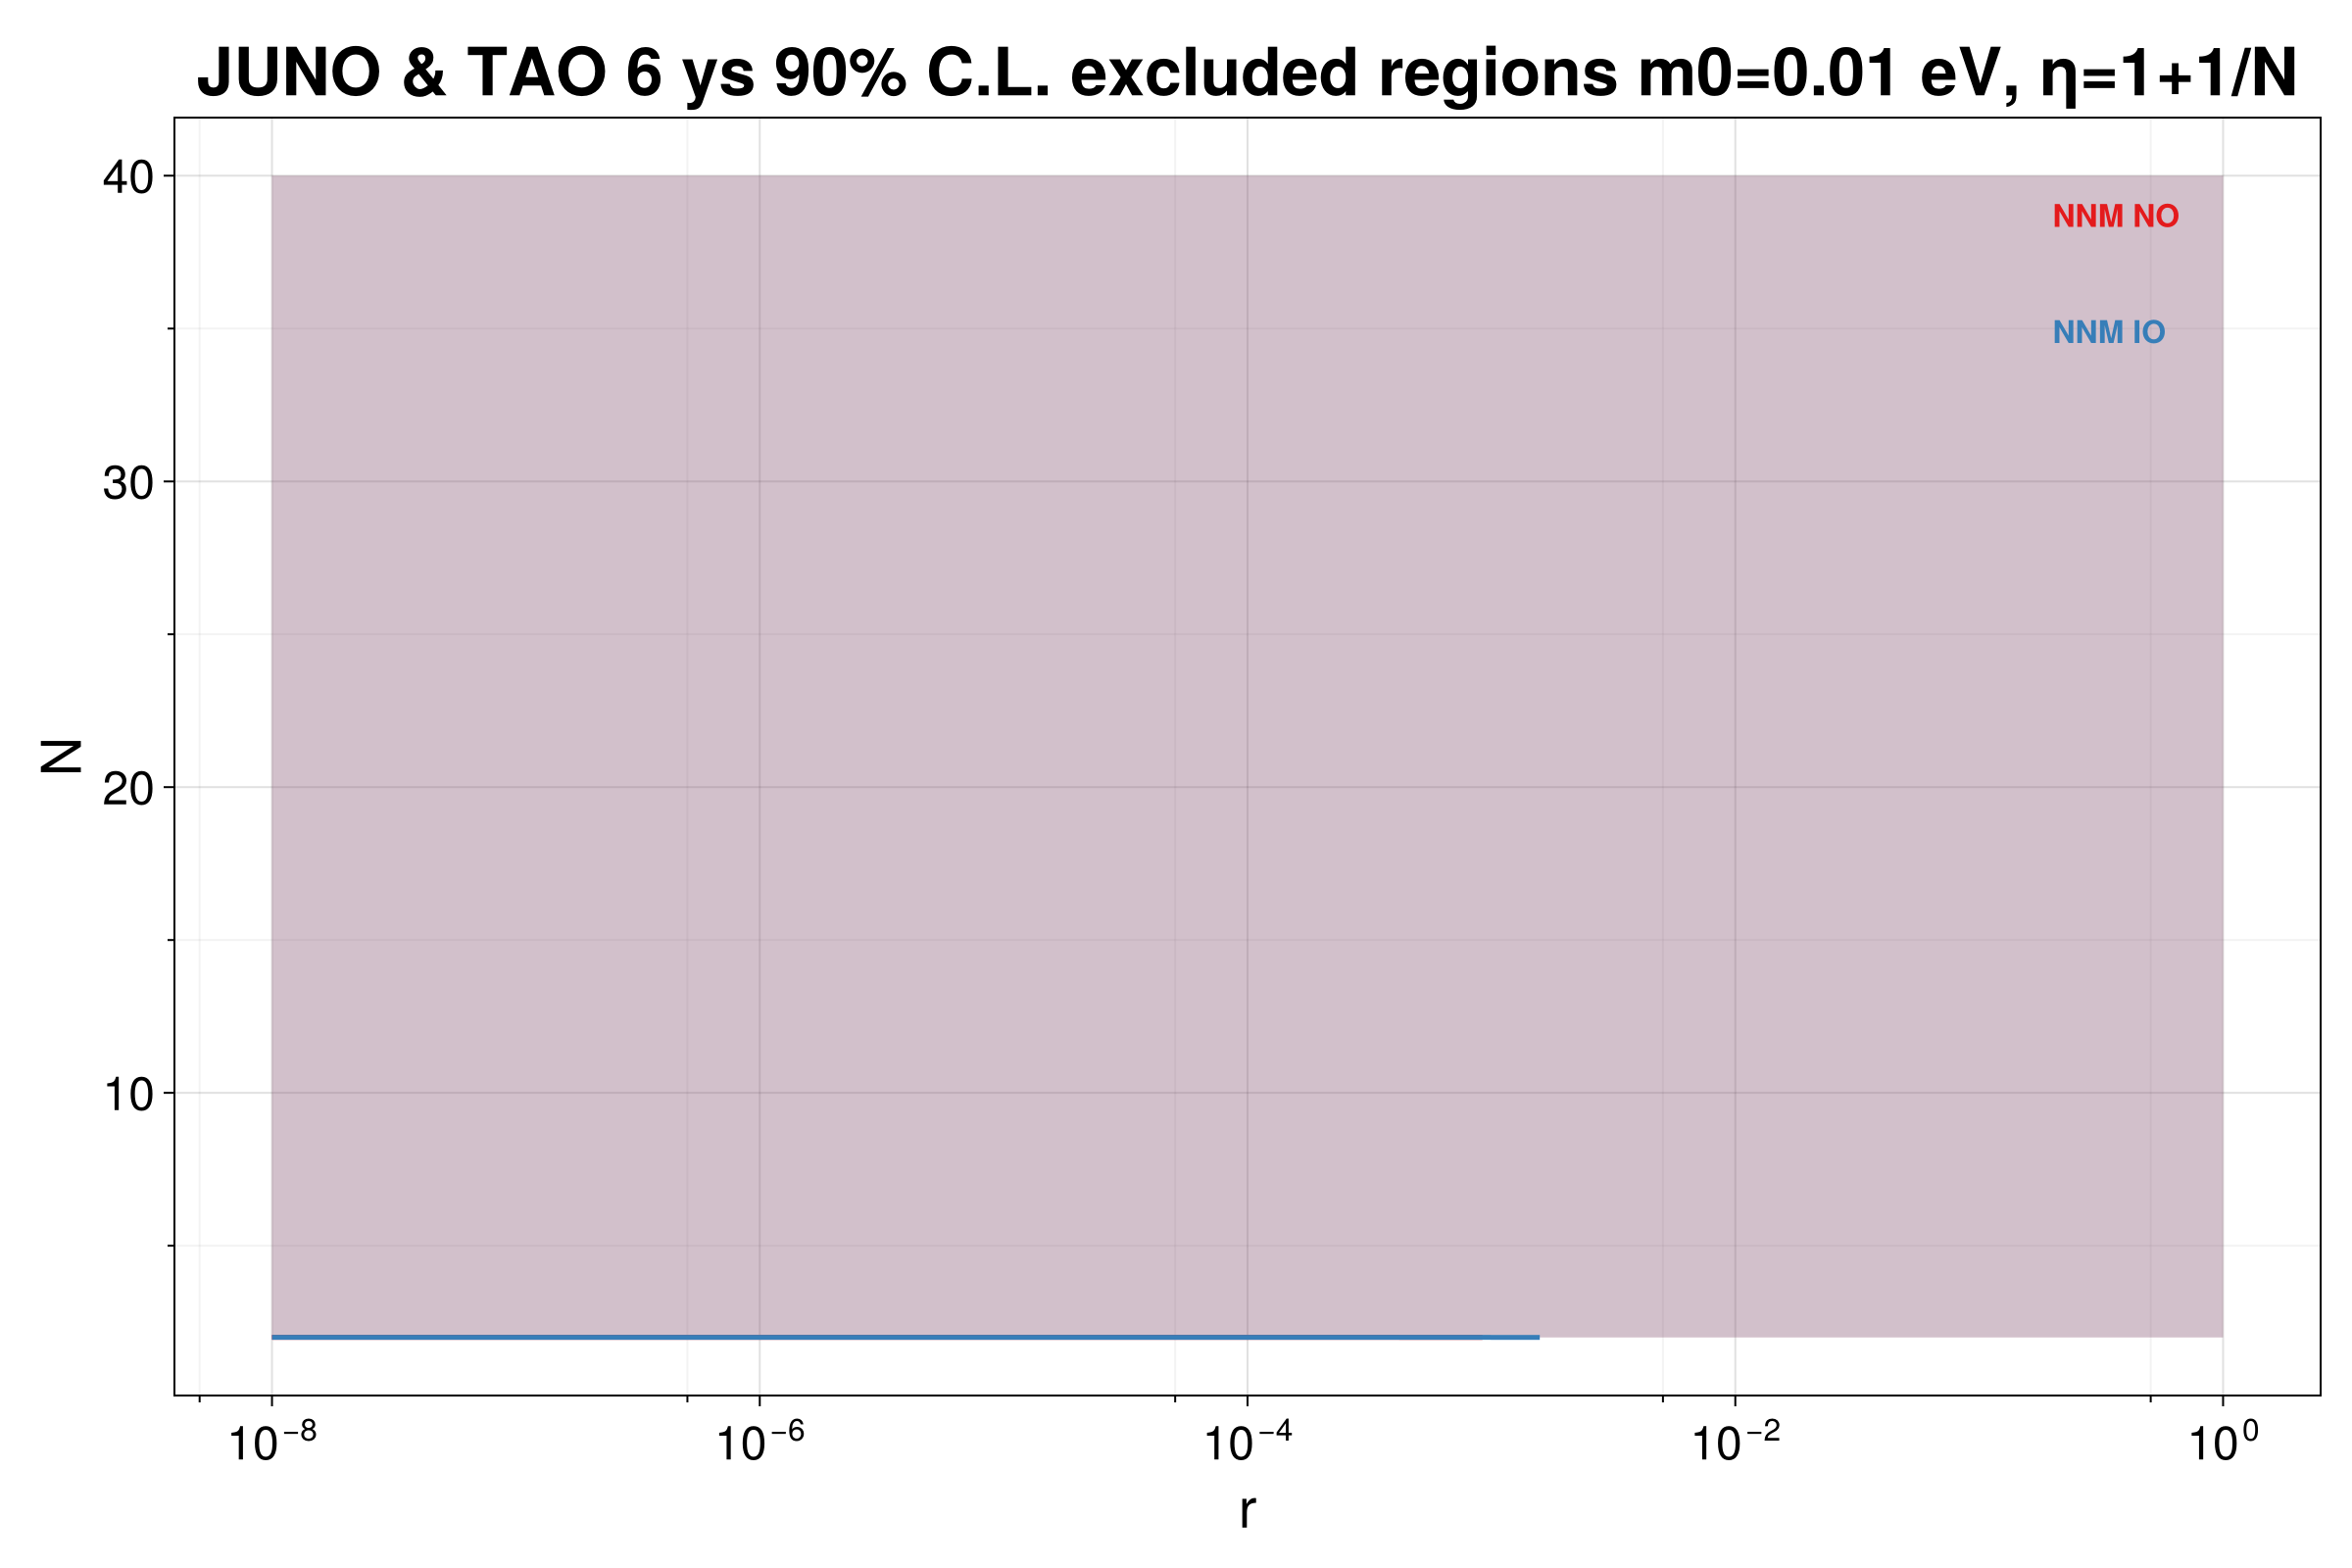

In [24]:

function superpose_contours_outside(file_paths::Vector{String}; 
                           title="Superposed Contours",
                           xlabel="Parameter 1", 
                           ylabel="Parameter 2",
                           experiments=nothing,
                           colorscheme=nothing,
                           color_step=1,
                           linestyles=nothing,
                           xscale=identity,
                           yscale=identity,
                           smooth_sigma::Union{Nothing,Float64}=nothing)
 
    
    # Default colorscheme and linestyles
    if colorscheme === nothing
        colorscheme = :Dark2_8
    end
    if linestyles === nothing
        linestyles = fill(:solid, length(file_paths))
    end
    
    # Get colors from the colorscheme with step
    cs = getproperty(ColorSchemes, colorscheme)
    all_colors = cs.colors
    colors = all_colors[1:color_step:end]
    n_colors = length(file_paths)
    if n_colors > length(colors)
        # If we need more colors than available, interpolate
        colors = [colors[i] for i in range(1, length(colors), length=n_colors)]
    else
        colors = colors[1:n_colors]
    end
    

    
  
    sigma_90_excluded_level = quantile(Chisq(2), 0.90)
    
    # Load all results and find axis ranges
    results = []
    all_axes_1 = []
    all_axes_2 = []
    
    for file_path in file_paths
        result = load(file_path)["result"]  # Adjust key if needed
        push!(results, result)
        push!(all_axes_1, result.axes[1])
        push!(all_axes_2, result.axes[2])
    end
    
    # Find combined axis ranges
    x_min = minimum([minimum(ax) for ax in all_axes_1])
    x_max = maximum([maximum(ax) for ax in all_axes_1])
    y_min = minimum([minimum(ax) for ax in all_axes_2])
    y_max = maximum([maximum(ax) for ax in all_axes_2])
        
    # Get axis labels from first result
    first_result = results[1]
    axis_labels = collect(keys(first_result.axes))

    # Create figure
    f = Figure(size=(1200, 800))
    ax = Axis(f[1,1];
        xlabel = String(axis_labels[1]) , #*" (eV)"
        ylabel = String(axis_labels[2]) ,
     title = title,
        xminorticksvisible = true,
        xminorgridvisible = true,
        yminorticksvisible = true,
        yminorgridvisible = true,
        titlesize = 34,
        xlabelsize = 28,
        ylabelsize = 28,
        xticklabelsize = 24,
        yticklabelsize = 24,
        xscale = xscale,
        yscale = yscale)
   # Plot contours
    for (idx, result) in enumerate(results)
        lp = result.values.log_posterior
        finite_mask = isfinite.(lp)

        if !any(finite_mask)
            @warn "Scan contains no finite likelihood values — skipping"
            continue
        end

        lp_max = maximum(lp[finite_mask])

        dLLH_raw = 2 .* (lp_max .- lp)

        dLLH = smooth_sigma === nothing ? dLLH_raw :
            gaussian_smooth(dLLH_raw; σ=smooth_sigma)


        dLLH_plot = copy(dLLH)
        dLLH_plot[.!isfinite.(dLLH_plot)] .= NaN

        maxlevel = maximum(skipmissing(vec(dLLH_plot)))
        ϵ = 1e-6  # numerical safety margin

        color = colors[idx]
        linestyle = linestyles[mod(idx-1, length(linestyles)) + 1]

        color_transparent = RGBA(color, 1.0)
        color_transparent_full = RGBA(color, 0.2)

        # --- SHADE ONLY IF EXCLUSION EXISTS ---
        if isfinite(maxlevel) && maxlevel > sigma_90_excluded_level + ϵ
            contourf!(ax,
                result.axes[1],
                result.axes[2],
                dLLH_plot;
                levels = [sigma_90_excluded_level, maxlevel],
                colormap = cgrad([color_transparent_full, color_transparent])
            )
        end

        # --- ALWAYS DRAW CONTOUR LINE ---
        contour!(ax,
            result.axes[1],
            result.axes[2],
            dLLH_plot;
            levels = [sigma_90_excluded_level],
            color = color,
            linewidth = 2.5,
            linestyle = linestyle
        )
      
        

    end
    if experiments !== nothing
        # Helper function to position in data space (works for log and linear)
        function position_in_range(min_val, max_val, fraction)
            if yscale == log10
                # Log scale: work in log space
                min_log = log10(min_val)
                max_log = log10(max_val)
                return 10 ^ (min_log + fraction * (max_log - min_log))
            else
                # Linear scale: work in linear space
                return min_val + fraction * (max_val - min_val)
            end
        end
        
        fractions_y = range(0.95, 0.85, length=length(experiments))
        y_positions = [position_in_range(y_min, y_max, f) for f in fractions_y]
        x_position = position_in_range(x_min, x_max, 0.2)
        
        for (idx, label) in enumerate(experiments)
            color = colors[idx]
            text!(ax, x_position, y_positions[idx], 
                  text = label,
                  fontsize = 16,
                  color = color,
                  font = :bold)
        end
    end
    
    f
end


file_paths = [#"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/junotao_rN_NNM_NO_m0=0.01.jld2",
           #"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/junotao_rN_NNM_IO_m0=0.01.jld2",
              "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/junotao_rN_NND_NO_m0=0.01.jld2",
          "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/junotao_rN_NND_IO_m0=0.01.jld2",
        ]
    
                
fig = superpose_contours_outside(file_paths;  
    title="JUNO & TAO 6 ys 90% C.L. excluded regions m0=0.01 eV, η=1+1/N",
    experiments = ["NNM NO" , "NNM IO"],# "NND NO", "NND IO"],
    colorscheme = :Set1_9,
    color_step = 1,
    xscale=log10,
    #yscale=log10,
    smooth_sigma=nothing)

display("image/png",fig)
#save("/home/sofialon/Newtrinos.jl/plots_fix/plots_newex/superposed_contours_junovstao6_rN_log.png", fig)


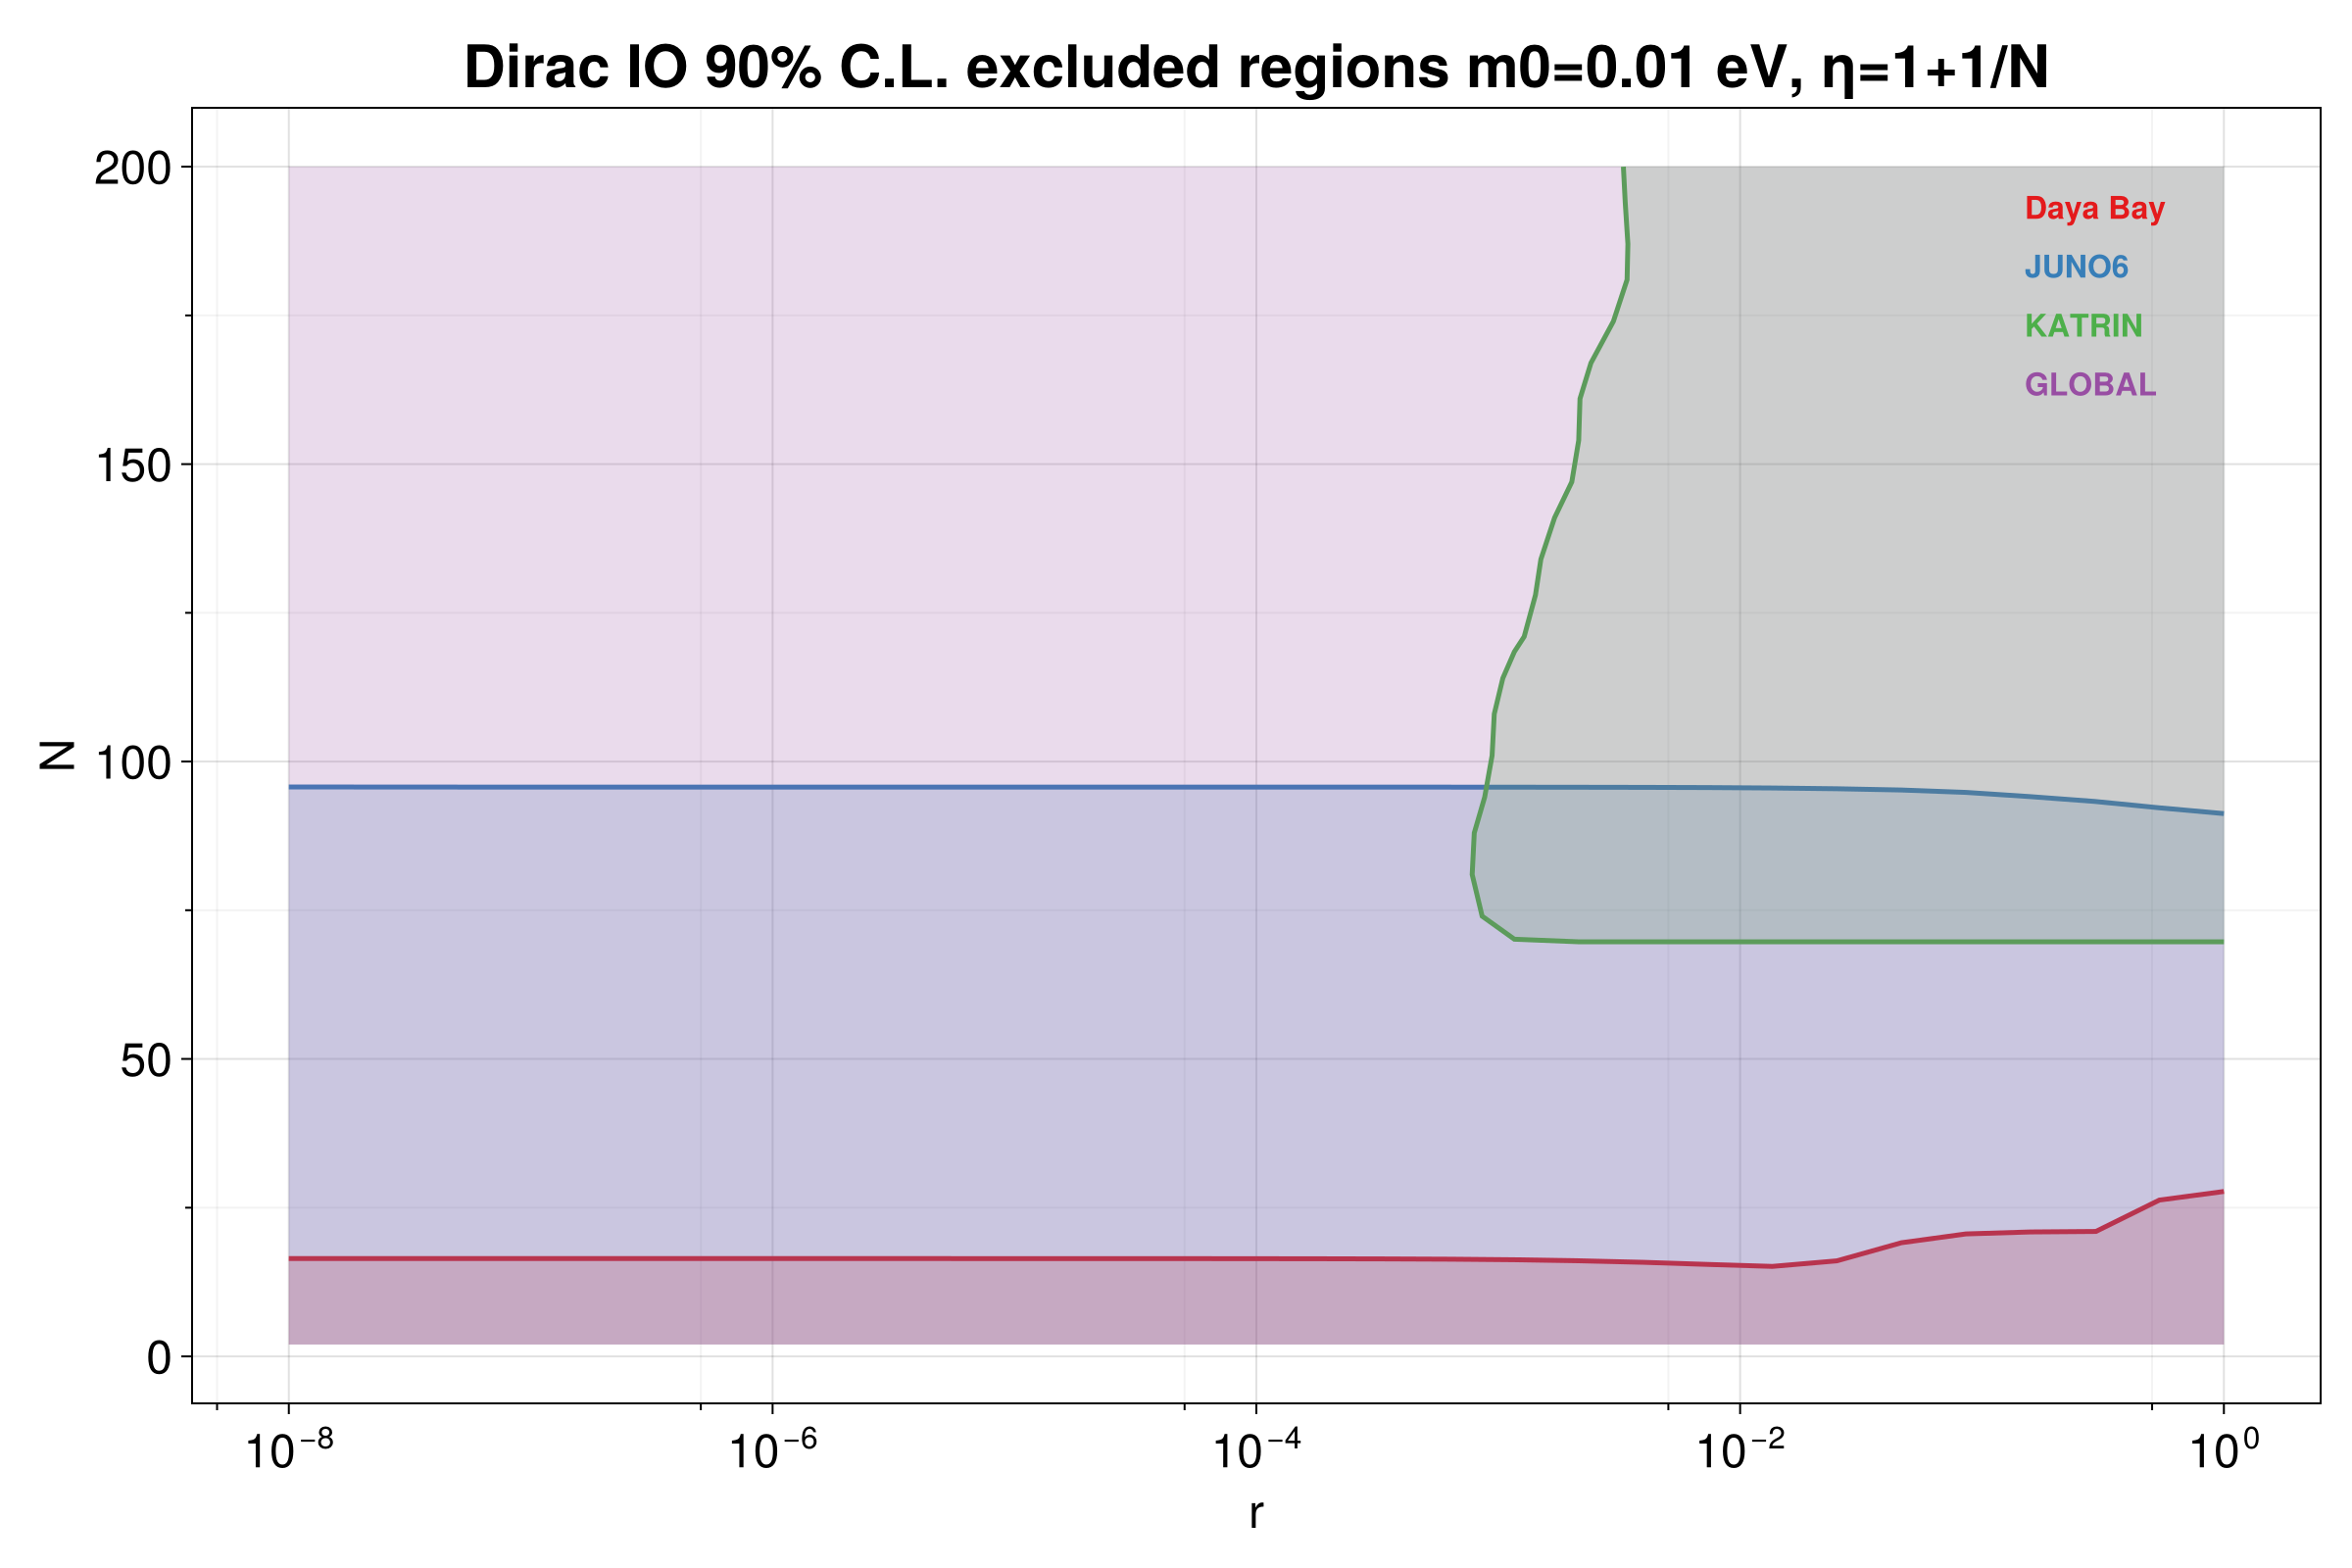

In [5]:
using ImageFiltering
using JLD2, CairoMakie, Distributions, Colors, ColorSchemes
using Newtrinos


function superpose_contours_outside(file_paths::Vector{String}; 
                           title="Superposed Contours",
                           xlabel="Parameter 1", 
                           ylabel="Parameter 2",
                           experiments=nothing,
                           colorscheme=nothing,
                           color_step=1,
                           linestyles=nothing,
                           xscale=identity,
                           yscale=identity,
                           smooth_sigma::Union{Nothing,Float64}=nothing)
 
    
    # Default colorscheme and linestyles
    if colorscheme === nothing
        colorscheme = :Dark2_8
    end
    if linestyles === nothing
        linestyles = fill(:solid, length(file_paths))
    end
    
    # Get colors from the colorscheme with step
    cs = getproperty(ColorSchemes, colorscheme)
    all_colors = cs.colors
    colors = all_colors[1:color_step:end]
    n_colors = length(file_paths)
    if n_colors > length(colors)
        # If we need more colors than available, interpolate
        colors = [colors[i] for i in range(1, length(colors), length=n_colors)]
    else
        colors = colors[1:n_colors]
    end
    

    
  
    sigma_90_excluded_level = quantile(Chisq(2), 0.90)
    
    # Load all results and find axis ranges
    results = []
    all_axes_1 = []
    all_axes_2 = []
    
    for file_path in file_paths
        result = load(file_path)["result"]  # Adjust key if needed
        push!(results, result)
        push!(all_axes_1, result.axes[1])
        push!(all_axes_2, result.axes[2])
    end
    
    # Find combined axis ranges
    x_min = minimum([minimum(ax) for ax in all_axes_1])
    x_max = maximum([maximum(ax) for ax in all_axes_1])
    y_min = minimum([minimum(ax) for ax in all_axes_2])
    y_max = maximum([maximum(ax) for ax in all_axes_2])
        
    # Get axis labels from first result
    first_result = results[1]
    axis_labels = collect(keys(first_result.axes))

    # Create figure
    f = Figure(size=(1200, 800))
    ax = Axis(f[1,1];
        xlabel = String(axis_labels[1]) , #*" (eV)"
        ylabel = String(axis_labels[2]),
        title = title,
        xminorticksvisible = true, 
        xminorgridvisible = true, 
        yminorticksvisible = true, 
        yminorgridvisible = true,
        titlesize = 30,
        xlabelsize = 24,
        ylabelsize = 24,
        xticklabelsize = 24,
        yticklabelsize = 24,
        xscale = xscale,
        yscale = yscale
    )
   # Plot contours
    for (idx, result) in enumerate(results)
        lp = result.values.log_posterior
        finite_mask = isfinite.(lp)

        if !any(finite_mask)
            @warn "Scan contains no finite likelihood values — skipping"
            continue
        end

        lp_max = maximum(lp[finite_mask])

        dLLH_raw = 2 .* (lp_max .- lp)

        dLLH = smooth_sigma === nothing ? dLLH_raw :
            gaussian_smooth(dLLH_raw; σ=smooth_sigma)


        dLLH_plot = copy(dLLH)
        dLLH_plot[.!isfinite.(dLLH_plot)] .= NaN

        maxlevel = maximum(skipmissing(vec(dLLH_plot)))
        ϵ = 1e-6  # numerical safety margin

        color = colors[idx]
        linestyle = linestyles[mod(idx-1, length(linestyles)) + 1]

        color_transparent = RGBA(color, 1.0)
        color_transparent_full = RGBA(color, 0.2)

        # --- SHADE ONLY IF EXCLUSION EXISTS ---
        if isfinite(maxlevel) && maxlevel > sigma_90_excluded_level + ϵ
            contourf!(ax,
                result.axes[1],
                result.axes[2],
                dLLH_plot;
                levels = [sigma_90_excluded_level, maxlevel],
                colormap = cgrad([color_transparent_full, color_transparent])
            )
        end

        # --- ALWAYS DRAW CONTOUR LINE ---
        contour!(ax,
            result.axes[1],
            result.axes[2],
            dLLH_plot;
            levels = [sigma_90_excluded_level],
            color = color,
            linewidth = 2.5,
            linestyle = linestyle
        )
      
        

    end
    if experiments !== nothing
        # Helper function to position in data space (works for log and linear)
        function position_in_range(min_val, max_val, fraction)
            if yscale == log10
                # Log scale: work in log space
                min_log = log10(min_val)
                max_log = log10(max_val)
                return 10 ^ (min_log + fraction * (max_log - min_log))
            else
                # Linear scale: work in linear space
                return min_val + fraction * (max_val - min_val)
            end
        end
        
        fractions_y = range(0.95, 0.80, length=length(experiments))
        y_positions = [position_in_range(y_min, y_max, f) for f in fractions_y]
        x_position = position_in_range(x_min, x_max, 0.15)
        
        for (idx, label) in enumerate(experiments)
            color = colors[idx]
            text!(ax, x_position, y_positions[idx], 
                  text = label,
                  fontsize = 16,
                  color = color,
                  font = :bold)
        end
    end
    
    f
end


file_paths = ["/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_dayabay_rN_m0=0.01_NND_IO_log.jld2",
              "/home/sofialon/Newtrinos.jl/plots_fix/junotao_m/junotao_toynor_rN_NND_IO_m0=0.01.jld2",
              "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_katrin_Nr_m0=0.01_η=1+1N_NND_IO.jld2",
              #"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_gerda_Nr_m0=0.01_η=1+1N_NND_IO.jld2",
              #"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_legend200_Nr_m0=0.01_η=1+1N_NND_IO.jld2",
             # "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_legend1000_Nr_m0=0.01_η=1+1N_NND_IO.jld2",
             "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_global_rN_m0=0.01_NND_IO.jld2"
             ]
    
                
fig = superpose_contours_outside(file_paths;  
    title="Dirac IO 90% C.L. excluded regions m0=0.01 eV, η=1+1/N",
    experiments = ["Daya Bay","JUNO6", "KATRIN","GLOBAL"], 
    colorscheme = :Set1_9,
    color_step = 1,
    xscale=log10,
    #yscale=log10,
    smooth_sigma=1.0)

display("image/png",fig)
#save("/home/sofialon/Newtrinos.jl/plots_fix/plots_newex/superposed_contours_allglobal_NND_NO_rn_wK.png", fig)


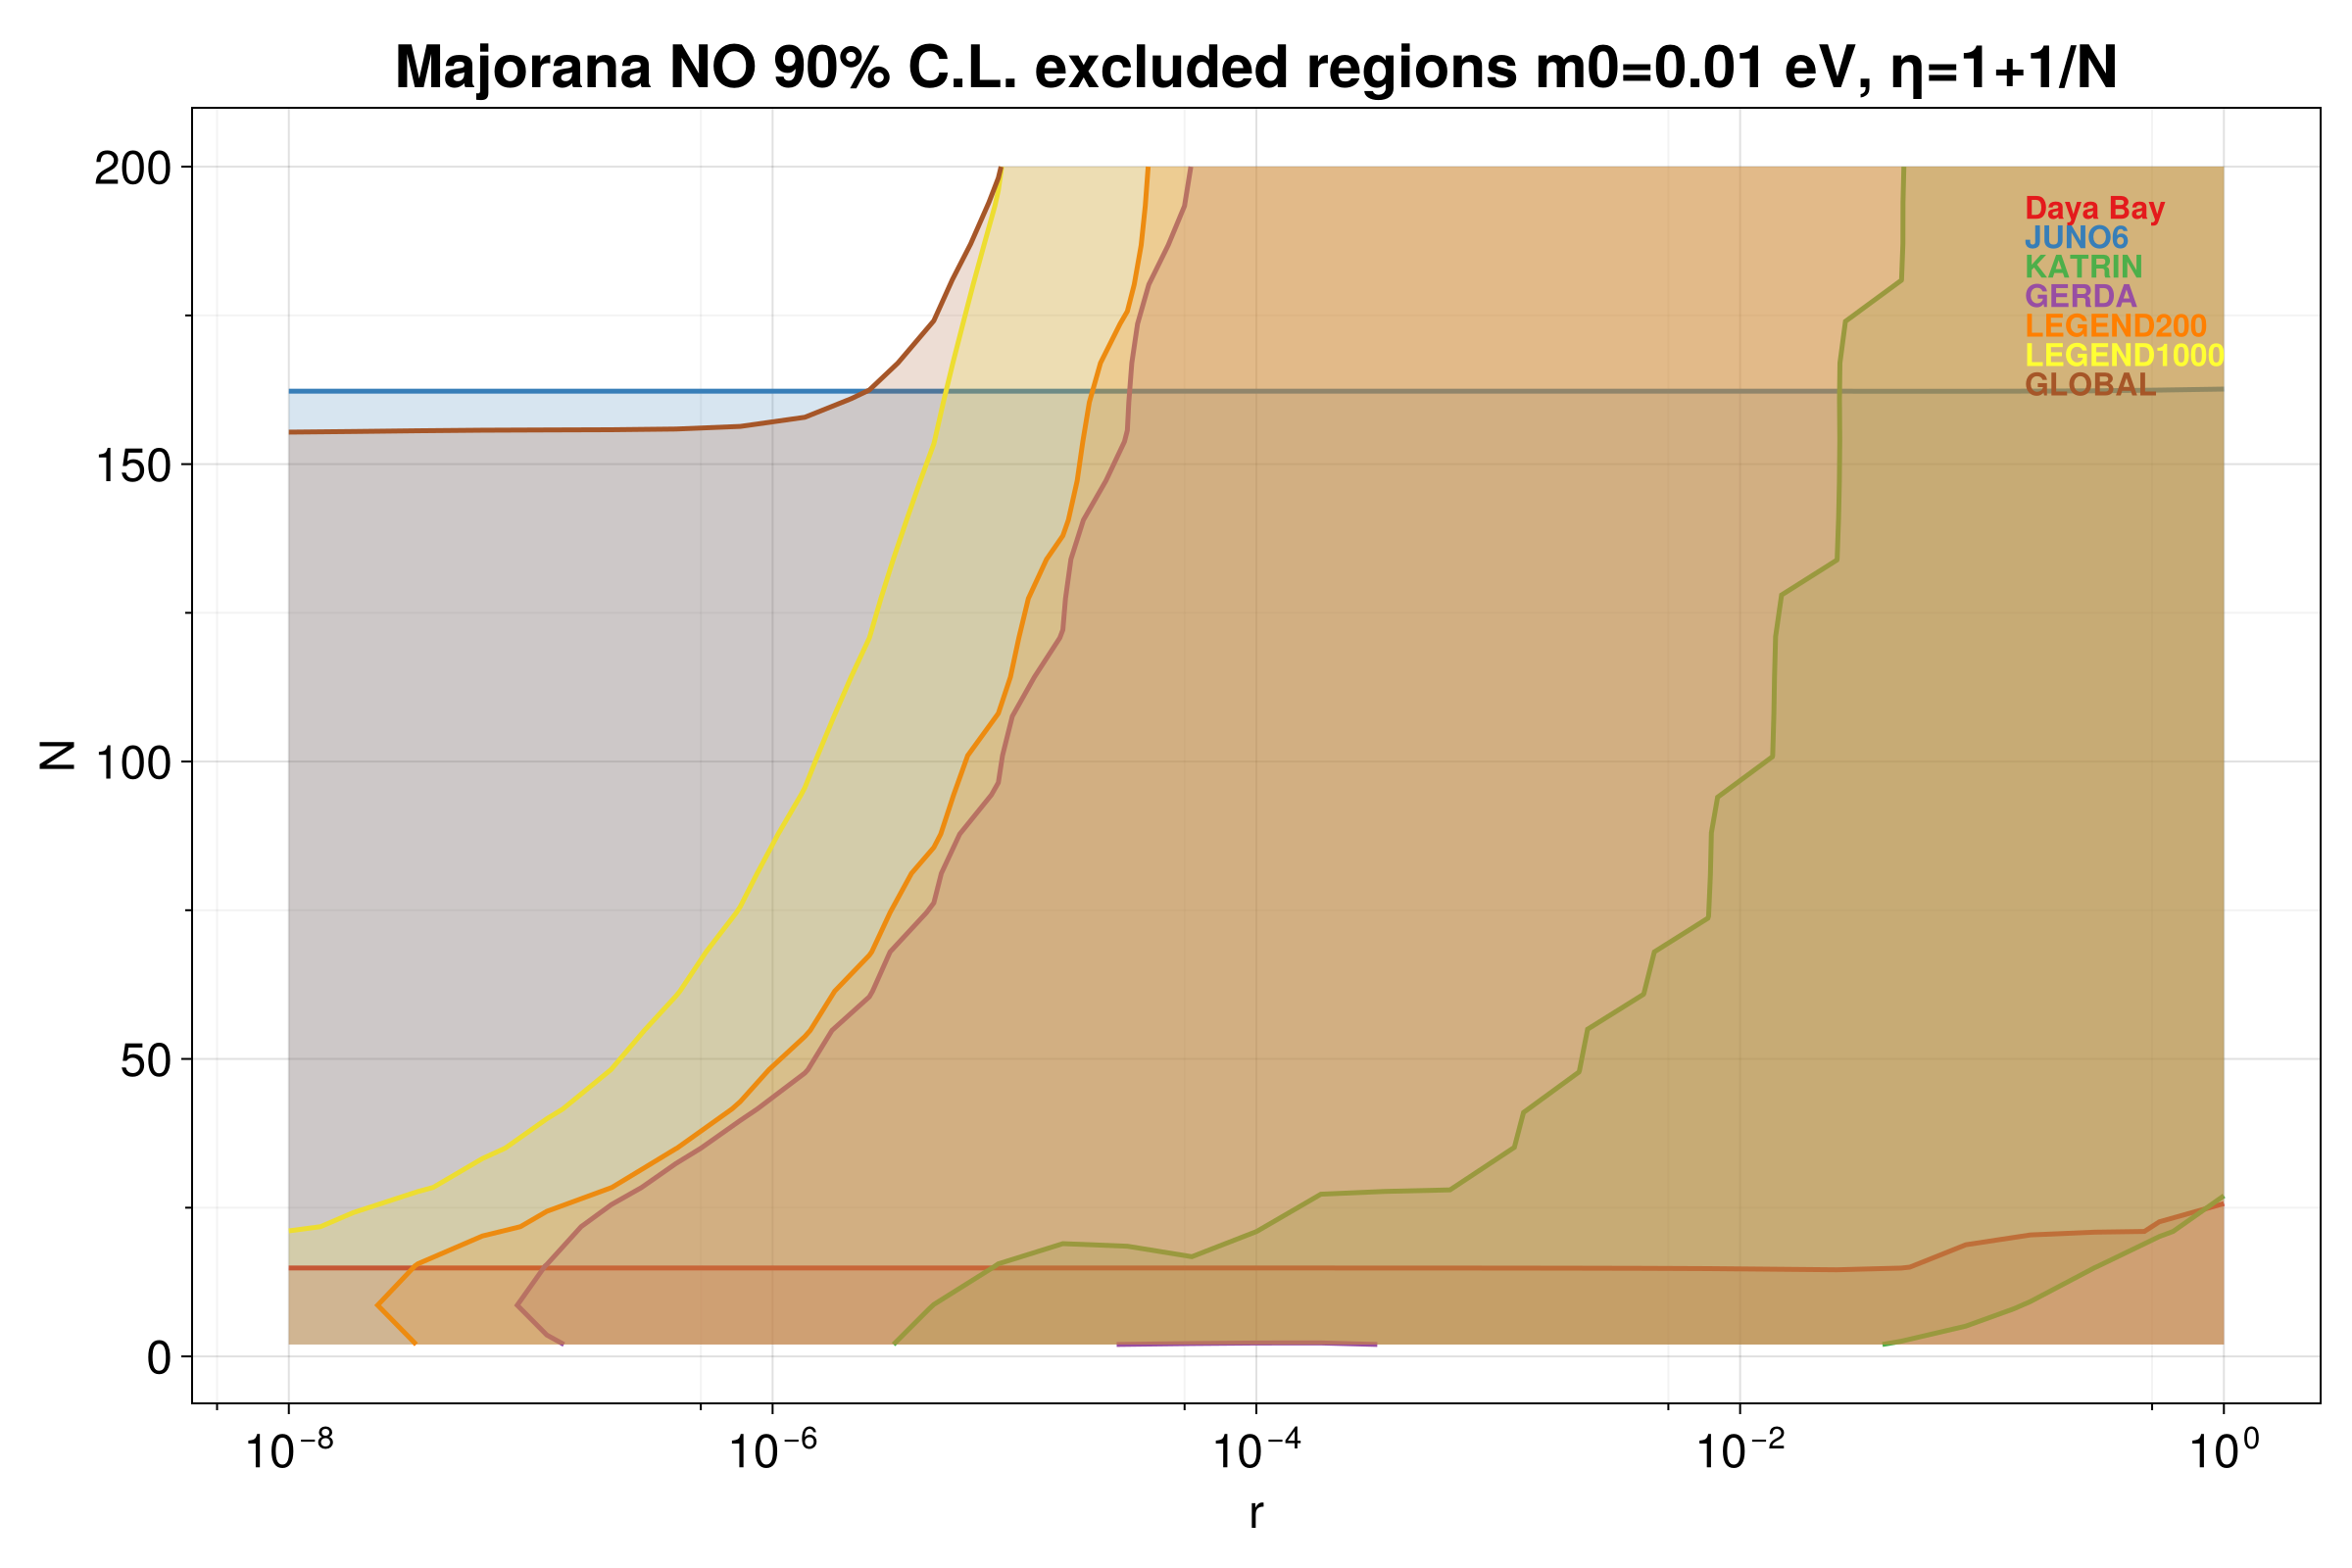

In [8]:
using ImageFiltering
using JLD2, CairoMakie, Distributions, Colors, ColorSchemes
using Newtrinos


function superpose_contours_outside(file_paths::Vector{String}; 
                           title="Superposed Contours",
                           xlabel="Parameter 1", 
                           ylabel="Parameter 2",
                           experiments=nothing,
                           colorscheme=nothing,
                           color_step=1,
                           linestyles=nothing,
                           xscale=identity,
                           yscale=identity,
                           smooth_sigma::Union{Nothing,Float64}=nothing)
 
    
    # Default colorscheme and linestyles
    if colorscheme === nothing
        colorscheme = :Dark2_8
    end
    if linestyles === nothing
        linestyles = fill(:solid, length(file_paths))
    end
    
    # Get colors from the colorscheme with step
    cs = getproperty(ColorSchemes, colorscheme)
    all_colors = cs.colors
    colors = all_colors[1:color_step:end]
    n_colors = length(file_paths)
    if n_colors > length(colors)
        # If we need more colors than available, interpolate
        colors = [colors[i] for i in range(1, length(colors), length=n_colors)]
    else
        colors = colors[1:n_colors]
    end
    

    
  
    sigma_90_excluded_level = quantile(Chisq(2), 0.90)
    
    # Load all results and find axis ranges
    results = []
    all_axes_1 = []
    all_axes_2 = []
    
    for file_path in file_paths
        result = load(file_path)["result"]  # Adjust key if needed
        push!(results, result)
        push!(all_axes_1, result.axes[1])
        push!(all_axes_2, result.axes[2])
    end
    
    # Find combined axis ranges
    x_min = minimum([minimum(ax) for ax in all_axes_1])
    x_max = maximum([maximum(ax) for ax in all_axes_1])
    y_min = minimum([minimum(ax) for ax in all_axes_2])
    y_max = maximum([maximum(ax) for ax in all_axes_2])
        
    # Get axis labels from first result
    first_result = results[1]
    axis_labels = collect(keys(first_result.axes))

    # Create figure
    f = Figure(size=(1200, 800))
    ax = Axis(f[1,1];
        xlabel = String(axis_labels[1]) , #*" (eV)"
        ylabel = String(axis_labels[2]),
        title = title,
        xminorticksvisible = true, 
        xminorgridvisible = true, 
        yminorticksvisible = true, 
        yminorgridvisible = true,
        titlesize = 30,
        xlabelsize = 24,
        ylabelsize = 24,
        xticklabelsize = 24,
        yticklabelsize = 24,
        xscale = xscale,
        yscale = yscale
    )
   # Plot contours
    for (idx, result) in enumerate(results)
        lp = result.values.log_posterior
        finite_mask = isfinite.(lp)

        if !any(finite_mask)
            @warn "Scan contains no finite likelihood values — skipping"
            continue
        end

        lp_max = maximum(lp[finite_mask])

        dLLH_raw = 2 .* (lp_max .- lp)

        dLLH = smooth_sigma === nothing ? dLLH_raw :
            gaussian_smooth(dLLH_raw; σ=smooth_sigma)


        dLLH_plot = copy(dLLH)
        dLLH_plot[.!isfinite.(dLLH_plot)] .= NaN

        maxlevel = maximum(skipmissing(vec(dLLH_plot)))
        ϵ = 1e-6  # numerical safety margin

        color = colors[idx]
        linestyle = linestyles[mod(idx-1, length(linestyles)) + 1]

        color_transparent = RGBA(color, 1.0)
        color_transparent_full = RGBA(color, 0.2)

        # --- SHADE ONLY IF EXCLUSION EXISTS ---
        if isfinite(maxlevel) && maxlevel > sigma_90_excluded_level + ϵ
            contourf!(ax,
                result.axes[1],
                result.axes[2],
                dLLH_plot;
                levels = [sigma_90_excluded_level, maxlevel],
                colormap = cgrad([color_transparent_full, color_transparent])
            )
        end

        # --- ALWAYS DRAW CONTOUR LINE ---
        contour!(ax,
            result.axes[1],
            result.axes[2],
            dLLH_plot;
            levels = [sigma_90_excluded_level],
            color = color,
            linewidth = 2.5,
            linestyle = linestyle
        )
      
        

    end
    if experiments !== nothing
        # Helper function to position in data space (works for log and linear)
        function position_in_range(min_val, max_val, fraction)
            if yscale == log10
                # Log scale: work in log space
                min_log = log10(min_val)
                max_log = log10(max_val)
                return 10 ^ (min_log + fraction * (max_log - min_log))
            else
                # Linear scale: work in linear space
                return min_val + fraction * (max_val - min_val)
            end
        end
        
        fractions_y = range(0.95, 0.80, length=length(experiments))
        y_positions = [position_in_range(y_min, y_max, f) for f in fractions_y]
        x_position = position_in_range(x_min, x_max, 0.15)
        
        for (idx, label) in enumerate(experiments)
            color = colors[idx]
            text!(ax, x_position, y_positions[idx], 
                  text = label,
                  fontsize = 16,
                  color = color,
                  font = :bold)
        end
    end
    
    f
end


file_paths = ["/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_dayabay_rN_m0=0.01_NNM_log.jld2",
              "/home/sofialon/Newtrinos.jl/plots_fix/junotao_m/junotao_toyschur_rN_NNM_NO_m0=0.01.jld2",
              "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_katrin_Nr_m0=0.01_η=1+1N_NNM_NO.jld2",
              "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_gerda_Nr_m0=0.01_η=1+1N_NNM_NO.jld2",
              "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_legend200_Nr_m0=0.01_η=1+1N_NNM_NO.jld2",
              "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_legend1000_Nr_m0=0.01_η=1+1N_NNM_NO.jld2",
             "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_global_rN_m0=0.01_NNM_NO_log.jld2"
             ]
    
                
fig = superpose_contours_outside(file_paths;  
    title="Majorana NO 90% C.L. excluded regions m0=0.01 eV, η=1+1/N",
    experiments = ["Daya Bay","JUNO6", "KATRIN","GERDA", "LEGEND200","LEGEND1000","GLOBAL"], 
    colorscheme = :Set1_9,
    color_step = 1,
    xscale=log10,
    #yscale=log10,
    smooth_sigma=0.8)

display("image/png",fig)
#save("/home/sofialon/Newtrinos.jl/plots_fix/plots_newex/superposed_contours_allglobal_NNM_NO_rn.png", fig)


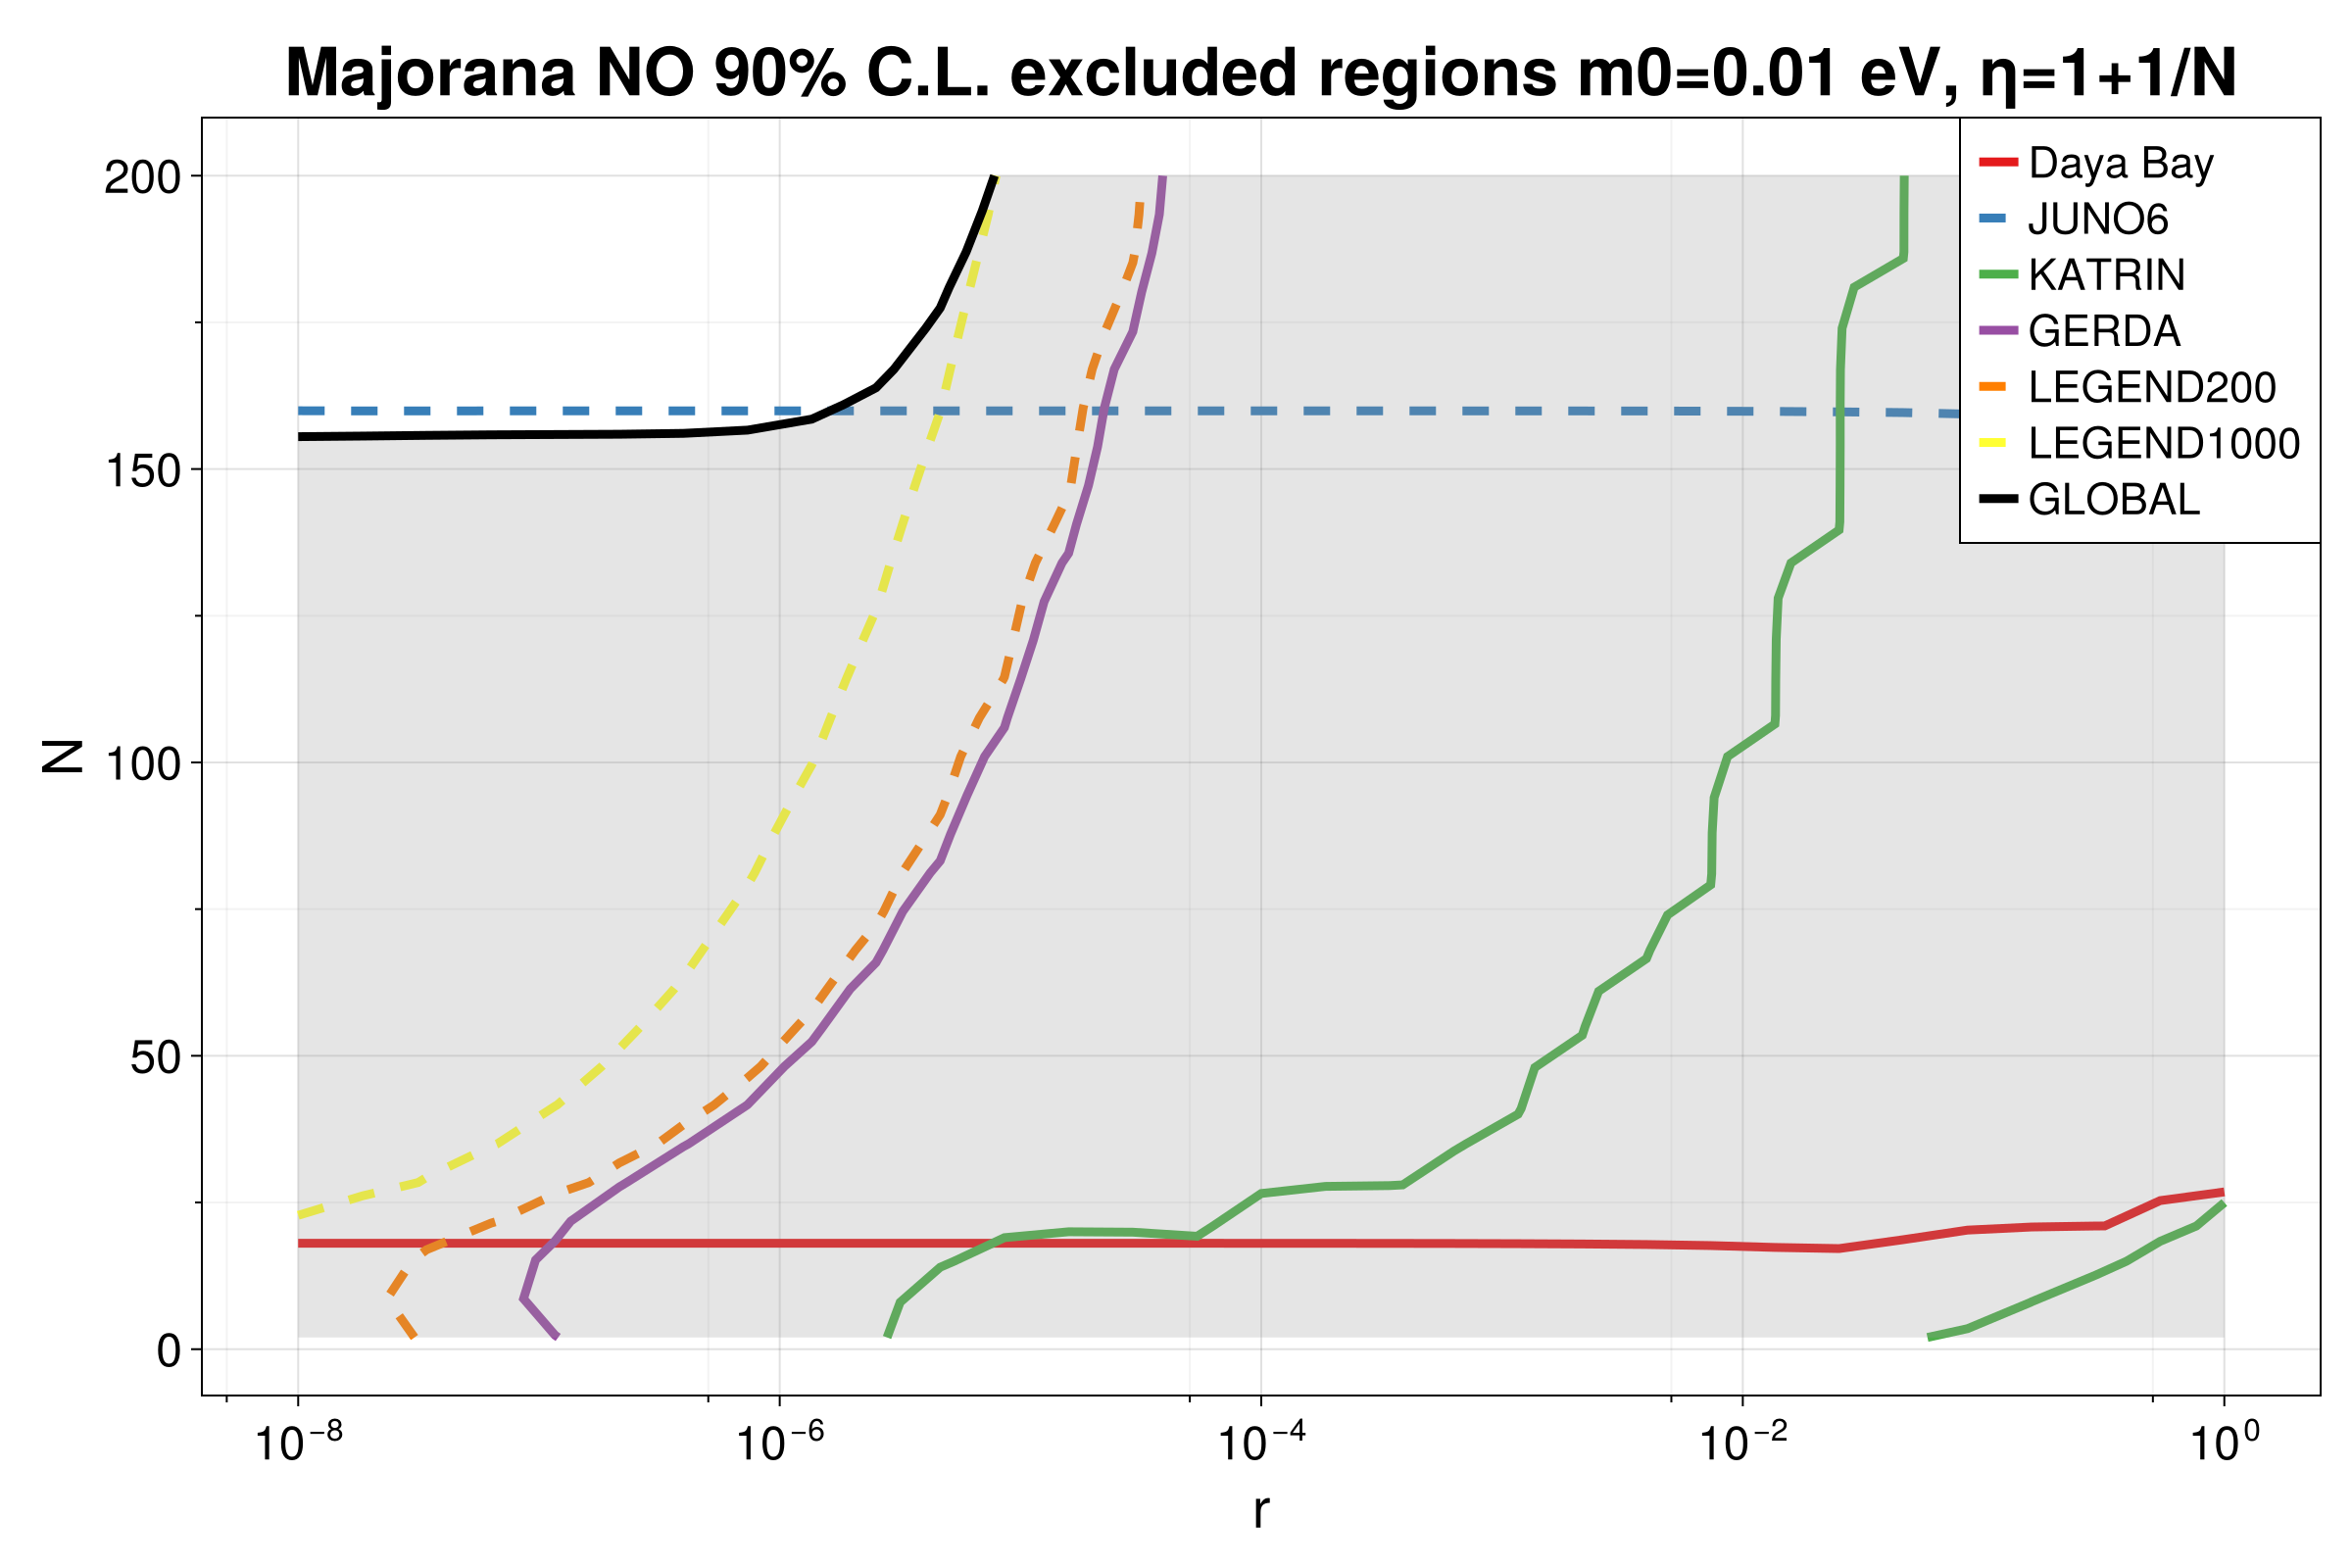

In [ ]:
using ImageFiltering
using JLD2, CairoMakie, Distributions, Colors, ColorSchemes
using Newtrinos

function superpose_contours_outside(file_paths::Vector{String}; 
    title="Superposed Contours",
    xlabel="Parameter 1", 
    ylabel="Parameter 2",
    experiments=nothing,
    colorscheme=:Set1_9,
    color_step=1,
    xscale=identity,
    yscale=identity,
    smooth_sigma::Union{Nothing,Float64}=nothing)

    sigma_90_excluded_level = quantile(Chisq(2), 0.90)

    # Load results
    results = []
    all_axes_1 = []
    all_axes_2 = []

    for file_path in file_paths
        result = load(file_path)["result"]
        push!(results, result)
        push!(all_axes_1, result.axes[1])
        push!(all_axes_2, result.axes[2])
    end

    # Combined ranges
    x_min = minimum([minimum(ax) for ax in all_axes_1])
    x_max = maximum([maximum(ax) for ax in all_axes_1])
    y_min = minimum([minimum(ax) for ax in all_axes_2])
    y_max = maximum([maximum(ax) for ax in all_axes_2])

    first_result = results[1]
    axis_labels = collect(keys(first_result.axes))

    # Colors
    cs = getproperty(ColorSchemes, colorscheme)
    base_colors = cs.colors
    colors = base_colors[1:color_step:end]
    colors = colors[1:length(results)]

    # Figure
    f = Figure(size=(1200, 800))
    ax = Axis(f[1,1];
        xlabel = String(axis_labels[1]),
        ylabel = String(axis_labels[2]),
        title = title,
        xminorticksvisible = true,
        xminorgridvisible = true,
        yminorticksvisible = true,
        yminorgridvisible = true,
        titlesize = 34,
        xlabelsize = 28,
        ylabelsize = 28,
        xticklabelsize = 24,
        yticklabelsize = 24,
        xscale = xscale,
        yscale = yscale
    )

    # -------------------------------
    # Contours
    # -------------------------------
    for (idx, result) in enumerate(results)

        lp = result.values.log_posterior
        finite_mask = isfinite.(lp)

        if !any(finite_mask)
            continue
        end

        lp_max = maximum(lp[finite_mask])
        dLLH_raw = 2 .* (lp_max .- lp)

        dLLH = smooth_sigma === nothing ?
            dLLH_raw :
            imfilter(dLLH_raw, Kernel.gaussian(smooth_sigma))

        dLLH_plot = copy(dLLH)
        dLLH_plot[.!isfinite.(dLLH_plot)] .= NaN

        maxlevel = maximum(skipmissing(vec(dLLH_plot)))

        exp_label = experiments !== nothing ? experiments[idx] : ""

        # Experiments that must be dashed
        force_dashed = exp_label in ["LEGEND200", "LEGEND1000", "JUNO6"]

        # -------------------
        # GLOBAL shading only
        # -------------------
        if exp_label == "GLOBAL"
            if isfinite(maxlevel) && maxlevel > sigma_90_excluded_level
                contourf!(ax,
                    result.axes[1],
                    result.axes[2],
                    dLLH_plot;
                    levels = [sigma_90_excluded_level, maxlevel],
                    colormap = cgrad([RGBA(0.6,0.6,0.6,0.25),
                                      RGBA(0.6,0.6,0.6,0.25)])
                )
            end
        end

        # -------------------
        # Contour line
        # -------------------
        contour!(ax,
            result.axes[1],
            result.axes[2],
            dLLH_plot;
            levels = [sigma_90_excluded_level],
            color = exp_label == "GLOBAL" ? :black : colors[idx],
            linewidth = 4.5,
            linestyle = force_dashed ? :dash : :solid
        )
    end

    # -------------------------------
    # Proper Legend (white box)
    # -------------------------------
    if experiments !== nothing

        legend_elements = []
        legend_labels = []

        for (idx, label) in enumerate(experiments)
            force_dashed = label in ["LEGEND200", "LEGEND1000", "JUNO6"]

            push!(legend_elements,
                LineElement(
                    color = label == "GLOBAL" ? :black : colors[idx],
                    linewidth = 4.5,
                    linestyle = force_dashed ? :dash : :solid
                )
            )

            push!(legend_labels, label)
        end

        Legend(
            f[1,1],
            legend_elements,
            legend_labels;
            tellwidth = false,
            tellheight = false,
            halign = :right,
            valign = :top,
            framevisible = true,
            framecolor = :black,
            backgroundcolor = :white,
            padding = (10,10,10,10),
            labelsize = 22
        )
    end

    f
end

# -------------------------------------------------
# File paths
# -------------------------------------------------
file_paths = [
"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_dayabay_rN_m0=0.01_NNM_log.jld2",
"/home/sofialon/Newtrinos.jl/plots_fix/junotao_m/junotao_toynor_rN_NNM_NO_m0=0.01.jld2",
"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_katrin_Nr_m0=0.01_η=1+1N_NNM_NO.jld2",
"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_gerda_Nr_m0=0.01_η=1+1N_NNM_NO.jld2",
"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_legend200_Nr_m0=0.01_η=1+1N_NNM_NO.jld2",
"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_legend1000_Nr_m0=0.01_η=1+1N_NNM_NO.jld2",
"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_global_rN_m0=0.01_NNM_NO_log.jld2"
]

fig = superpose_contours_outside(
    file_paths;
    title="Majorana NO 90% C.L. excluded regions m0=0.01 eV, η=1+1/N",
    experiments=["Daya Bay","JUNO6","KATRIN","GERDA","LEGEND200","LEGEND1000","GLOBAL ", "GLOBAL future"],
    xscale=log10,
    smooth_sigma=1.0
)

display("image/png",fig)

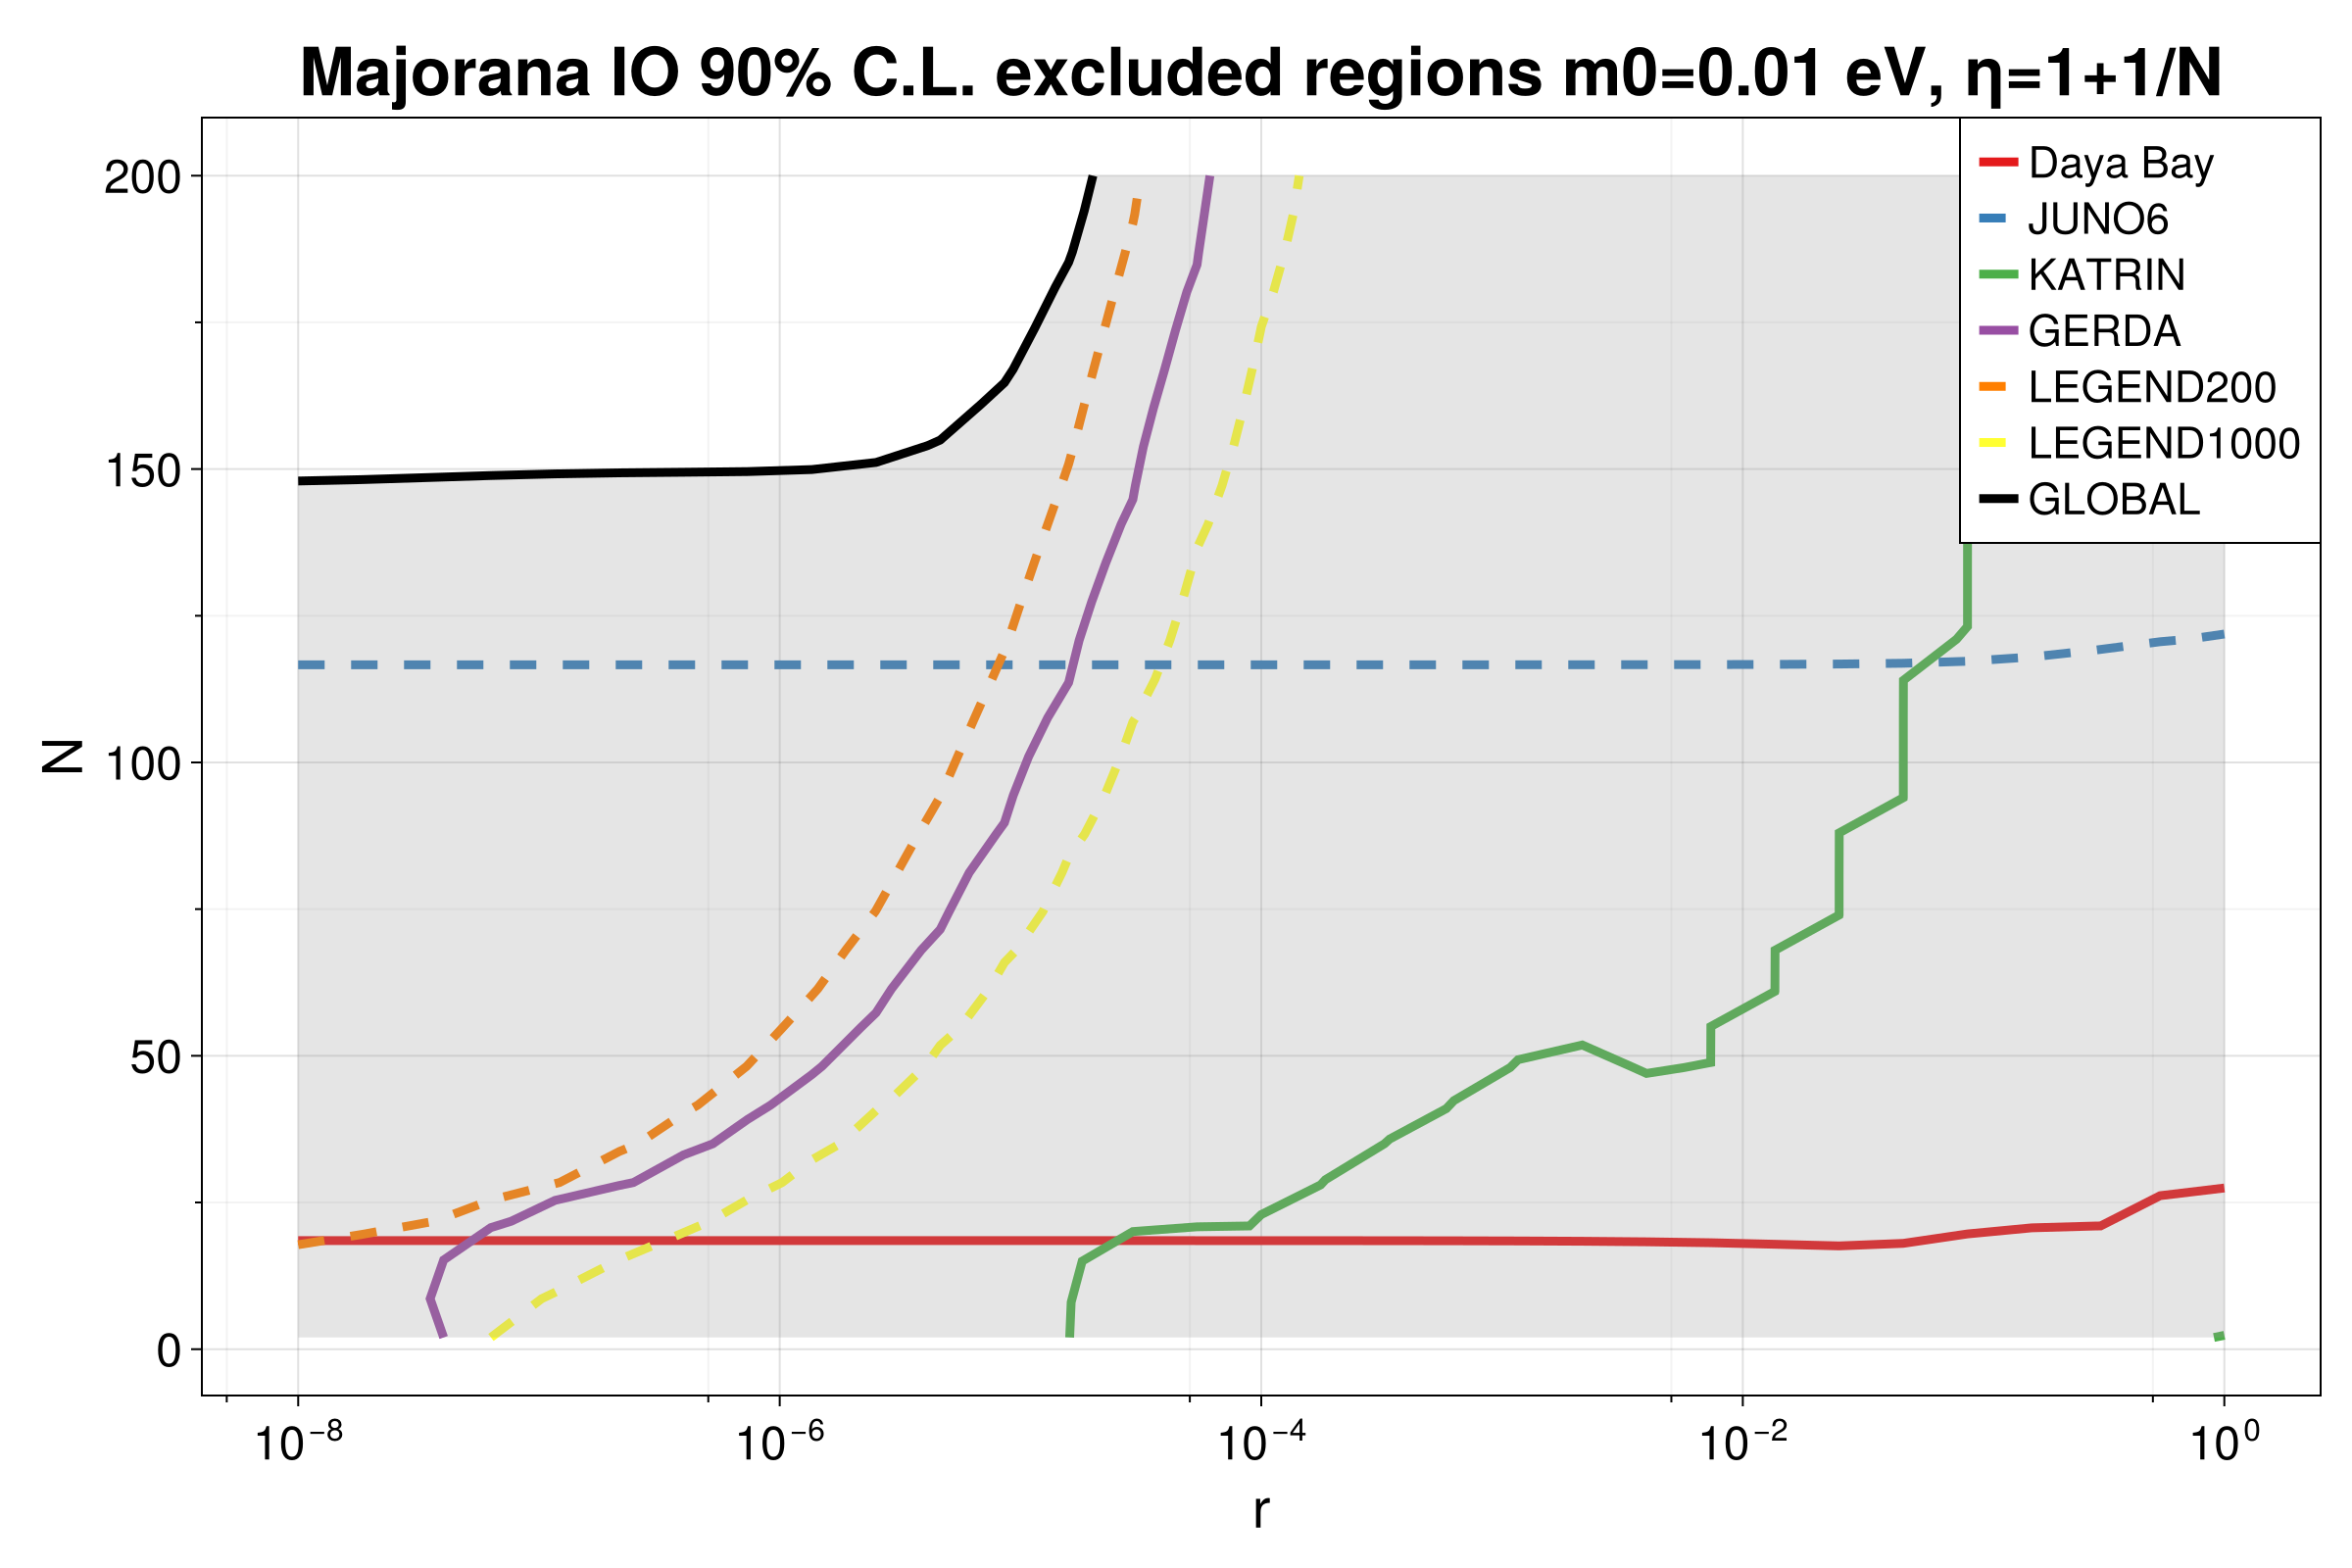

In [16]:
using ImageFiltering
using JLD2, CairoMakie, Distributions, Colors, ColorSchemes
using Newtrinos

function superpose_contours_outside(file_paths::Vector{String}; 
    title="Superposed Contours",
    xlabel="Parameter 1", 
    ylabel="Parameter 2",
    experiments=nothing,
    colorscheme=:Set1_9,
    color_step=1,
    xscale=identity,
    yscale=identity,
    smooth_sigma::Union{Nothing,Float64}=nothing)

    sigma_90_excluded_level = quantile(Chisq(2), 0.90)

    # Load results
    results = []
    all_axes_1 = []
    all_axes_2 = []

    for file_path in file_paths
        result = load(file_path)["result"]
        push!(results, result)
        push!(all_axes_1, result.axes[1])
        push!(all_axes_2, result.axes[2])
    end

    # Combined ranges
    x_min = minimum([minimum(ax) for ax in all_axes_1])
    x_max = maximum([maximum(ax) for ax in all_axes_1])
    y_min = minimum([minimum(ax) for ax in all_axes_2])
    y_max = maximum([maximum(ax) for ax in all_axes_2])

    first_result = results[1]
    axis_labels = collect(keys(first_result.axes))

    # Colors
    cs = getproperty(ColorSchemes, colorscheme)
    base_colors = cs.colors
    colors = base_colors[1:color_step:end]
    colors = colors[1:length(results)]

    # Figure
    f = Figure(size=(1200, 800))
    ax = Axis(f[1,1];
        xlabel = String(axis_labels[1]),
        ylabel = String(axis_labels[2]),
        title = title,
        xminorticksvisible = true,
        xminorgridvisible = true,
        yminorticksvisible = true,
        yminorgridvisible = true,
        titlesize = 34,
        xlabelsize = 28,
        ylabelsize = 28,
        xticklabelsize = 24,
        yticklabelsize = 24,
        xscale = xscale,
        yscale = yscale
    )

    # -------------------------------
    # Contours
    # -------------------------------
    for (idx, result) in enumerate(results)

        lp = result.values.log_posterior
        finite_mask = isfinite.(lp)

        if !any(finite_mask)
            continue
        end

        lp_max = maximum(lp[finite_mask])
        dLLH_raw = 2 .* (lp_max .- lp)

        dLLH = smooth_sigma === nothing ?
            dLLH_raw :
            imfilter(dLLH_raw, Kernel.gaussian(smooth_sigma))

        dLLH_plot = copy(dLLH)
        dLLH_plot[.!isfinite.(dLLH_plot)] .= NaN

        maxlevel = maximum(skipmissing(vec(dLLH_plot)))

        exp_label = experiments !== nothing ? experiments[idx] : ""

        # Experiments that must be dashed
        force_dashed = exp_label in ["LEGEND200", "LEGEND1000", "JUNO6"]

        # -------------------
        # GLOBAL shading only
        # -------------------
        if exp_label == "GLOBAL"
            if isfinite(maxlevel) && maxlevel > sigma_90_excluded_level
                contourf!(ax,
                    result.axes[1],
                    result.axes[2],
                    dLLH_plot;
                    levels = [sigma_90_excluded_level, maxlevel],
                    colormap = cgrad([RGBA(0.6,0.6,0.6,0.25),
                                      RGBA(0.6,0.6,0.6,0.25)])
                )
            end
        end

        # -------------------
        # Contour line
        # -------------------
        contour!(ax,
            result.axes[1],
            result.axes[2],
            dLLH_plot;
            levels = [sigma_90_excluded_level],
            color = exp_label == "GLOBAL" ? :black : colors[idx],
            linewidth = 4.5,
            linestyle = force_dashed ? :dash : :solid
        )
    end

    # -------------------------------
    # Proper Legend (white box)
    # -------------------------------
    if experiments !== nothing

        legend_elements = []
        legend_labels = []

        for (idx, label) in enumerate(experiments)
            force_dashed = label in ["LEGEND200", "LEGEND1000", "JUNO6"]

            push!(legend_elements,
                LineElement(
                    color = label == "GLOBAL" ? :black : colors[idx],
                    linewidth = 4.5,
                    linestyle = force_dashed ? :dash : :solid
                )
            )

            push!(legend_labels, label)
        end

        Legend(
            f[1,1],
            legend_elements,
            legend_labels;
            tellwidth = false,
            tellheight = false,
            halign = :right,
            valign = :top,
            framevisible = true,
            framecolor = :black,
            backgroundcolor = :white,
            padding = (10,10,10,10),
            labelsize = 22
        )
    end

    f
end

# -------------------------------------------------
# File paths
# -------------------------------------------------
file_paths = [
"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_dayabay_rN_m0=0.01_NNM_IO_log.jld2",
"/home/sofialon/Newtrinos.jl/plots_fix/junotao_m/junotao_toynor_rN_NNM_IO_m0=0.01.jld2",
"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_katrin_Nr_m0=0.01_η=1+1N_NNM_IO.jld2",
"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_gerda_Nr_m0=0.01_η=1+1N_NNM_IO.jld2",
"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_legend200_Nr_m0=0.01_η=1+1N_NNM_IO.jld2",
"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_legend1000_Nr_m0=0.01_η=1+1N_NNM_IO.jld2",
"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_global_rN_m0=0.01_NNM_IO.jld2"
]

fig = superpose_contours_outside(
    file_paths;
    title="Majorana IO 90% C.L. excluded regions m0=0.01 eV, η=1+1/N",
    experiments=["Daya Bay","JUNO6","KATRIN","GERDA","LEGEND200","LEGEND1000","GLOBAL"],
    xscale=log10,
    smooth_sigma=1.0
)

display("image/png",fig)

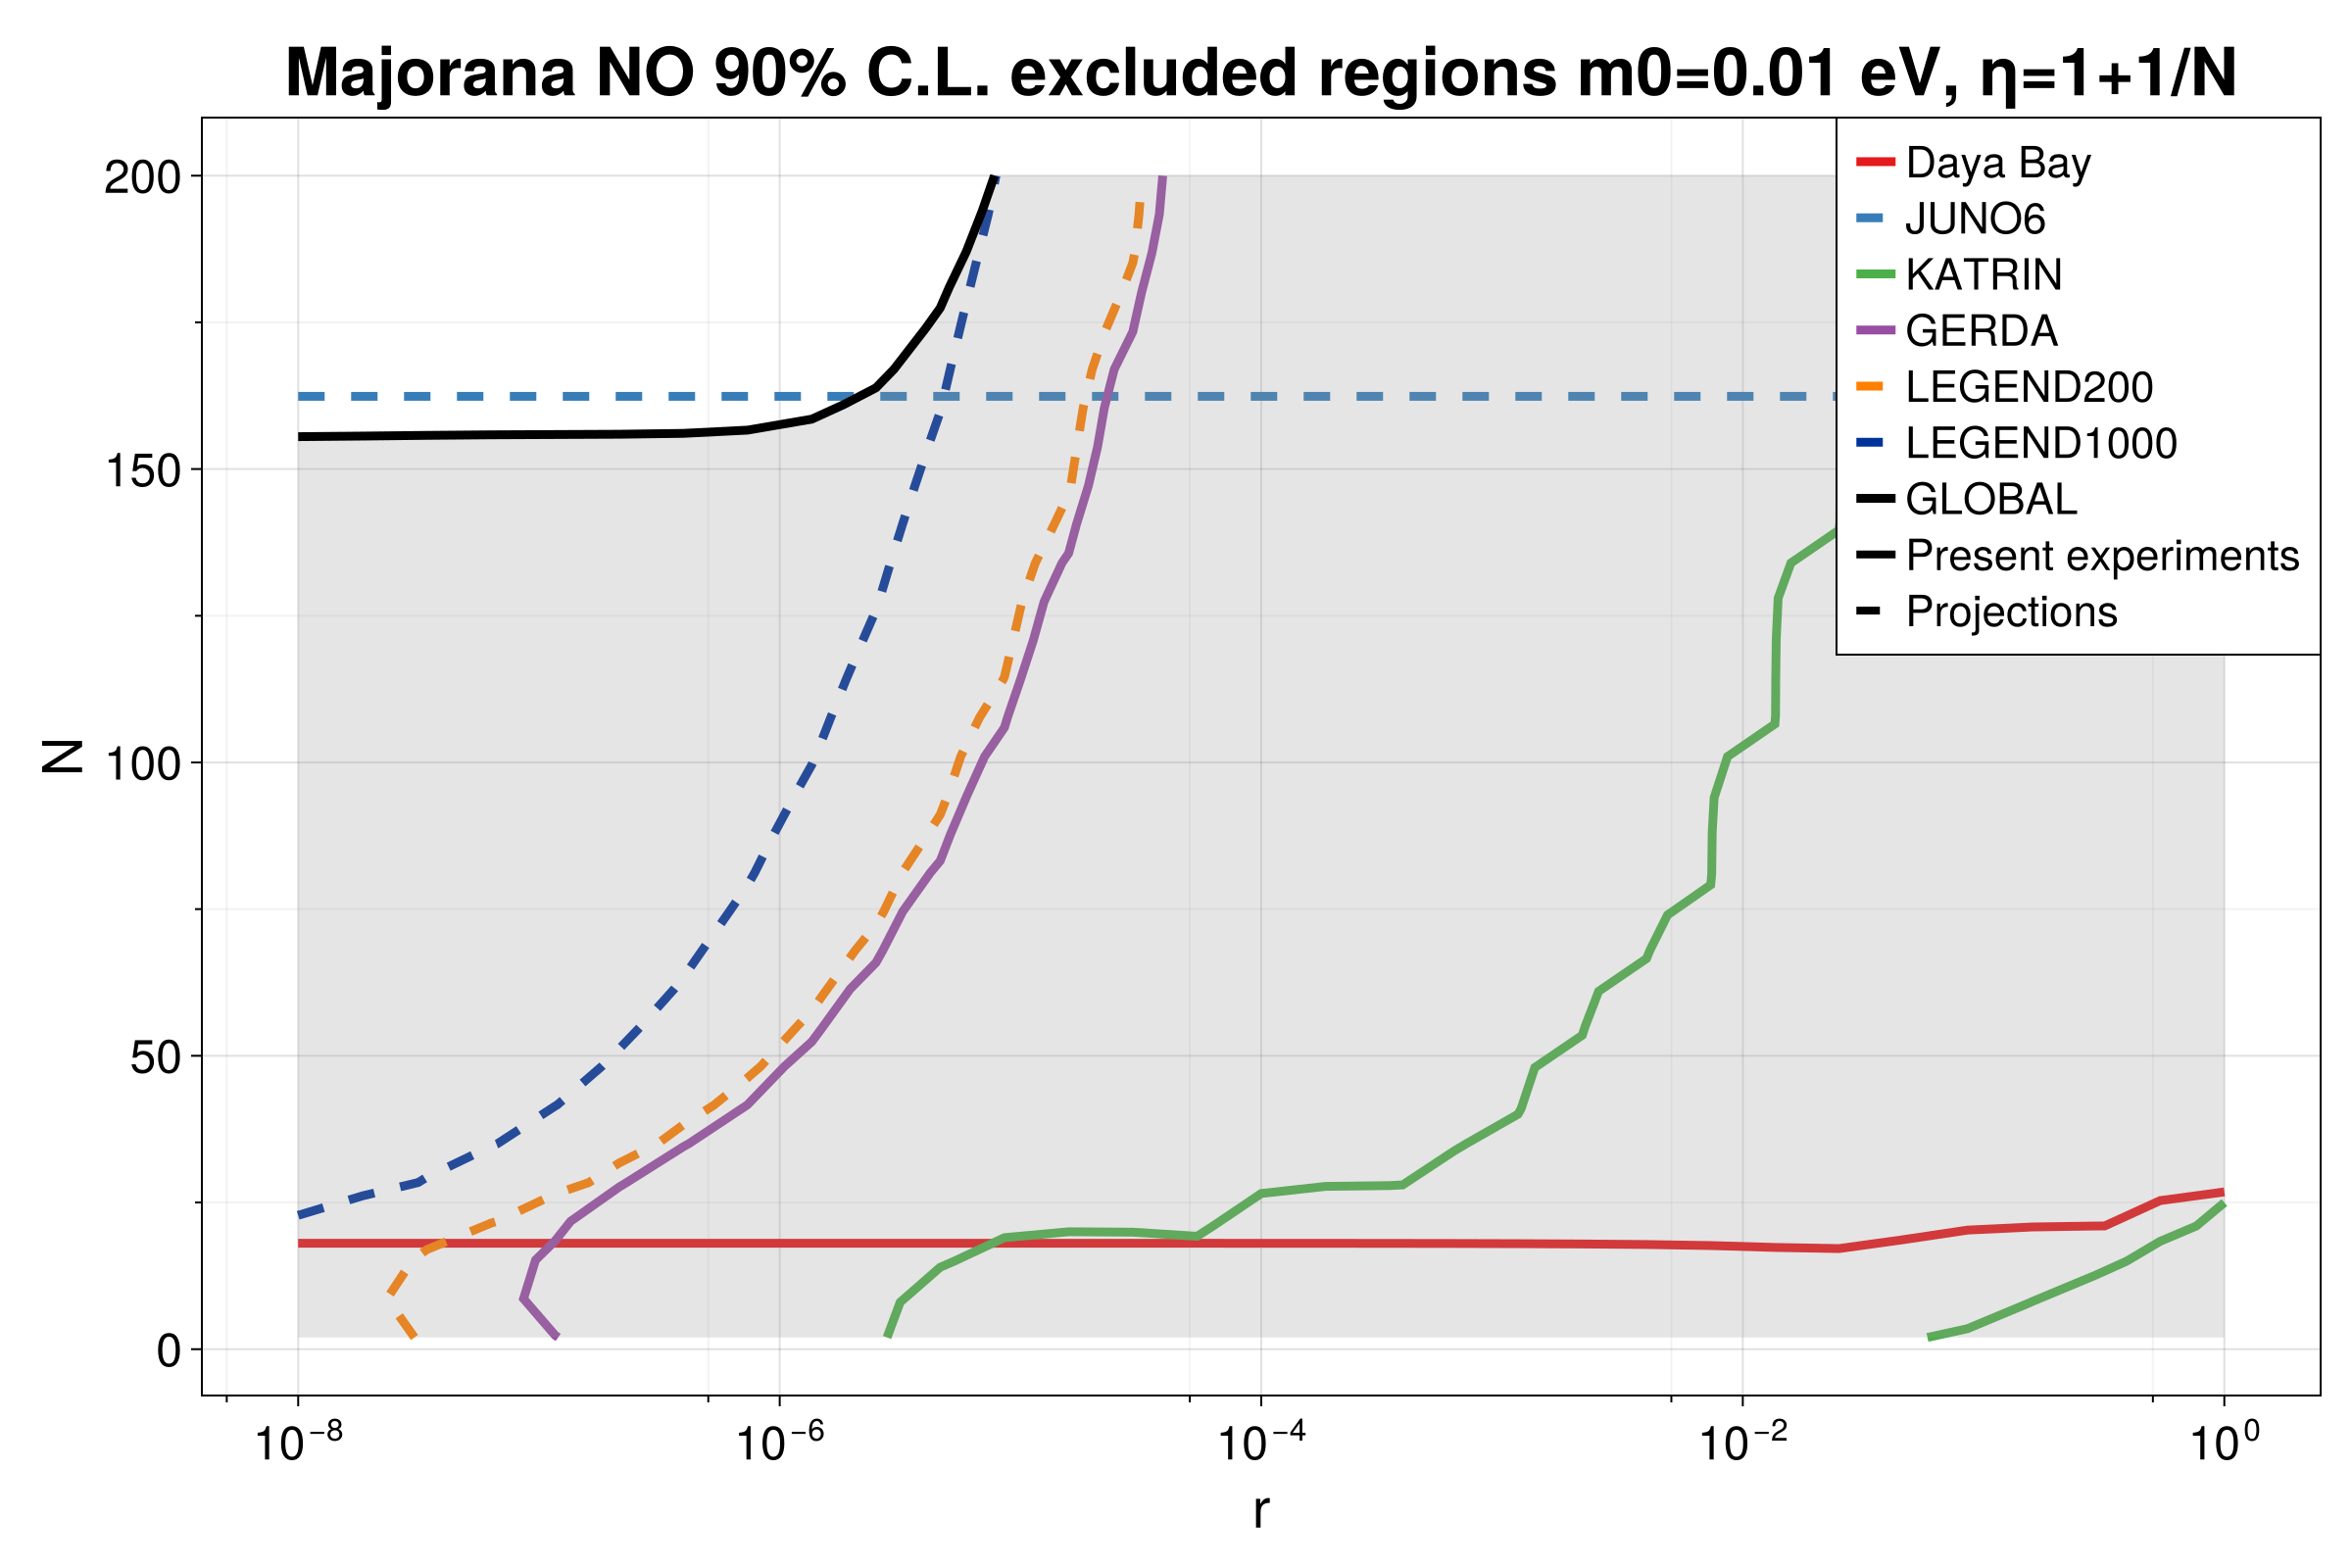

CairoMakie.Screen{IMAGE}


In [19]:
using ImageFiltering
using JLD2, CairoMakie, Distributions, Colors, ColorSchemes
using Newtrinos

function superpose_contours_outside(file_paths::Vector{String}; 
    title="Superposed Contours",
    xlabel="Parameter 1", 
    ylabel="Parameter 2",
    experiments=nothing,
    colorscheme=:Set1_9,
    color_step=1,
    xscale=identity,
    yscale=identity,
    smooth_sigma::Union{Nothing,Float64}=nothing)

    sigma_90_excluded_level = quantile(Chisq(2), 0.90)

    # Load results
    results = []
    all_axes_1 = []
    all_axes_2 = []

    for file_path in file_paths
        result = load(file_path)["result"]
        push!(results, result)
        push!(all_axes_1, result.axes[1])
        push!(all_axes_2, result.axes[2])
    end

    # Combined ranges
    x_min = minimum([minimum(ax) for ax in all_axes_1])
    x_max = maximum([maximum(ax) for ax in all_axes_1])
    y_min = minimum([minimum(ax) for ax in all_axes_2])
    y_max = maximum([maximum(ax) for ax in all_axes_2])

    first_result = results[1]
    axis_labels = collect(keys(first_result.axes))

    # Colors
    cs = getproperty(ColorSchemes, colorscheme)
    base_colors = cs.colors
    colors = base_colors[1:color_step:end]
    colors = colors[1:length(results)]

    # Change LEGEND1000 color to dark blue
    if experiments !== nothing
        idx = findfirst(x -> x=="LEGEND1000", experiments)
        if idx !== nothing
            colors[idx] = RGB(0.0,0.2,0.6)  # dark blue
        end
    end

    # Figure
    f = Figure(size=(1200, 800))
    ax = Axis(f[1,1];
        xlabel = String(axis_labels[1]),
        ylabel = String(axis_labels[2]),
        title = title,
        xminorticksvisible = true,
        xminorgridvisible = true,
        yminorticksvisible = true,
        yminorgridvisible = true,
        titlesize = 34,
        xlabelsize = 28,
        ylabelsize = 28,
        xticklabelsize = 24,
        yticklabelsize = 24,
        xscale = xscale,
        yscale = yscale
    )

    # -------------------------------
    # Contours
    # -------------------------------
    for (idx, result) in enumerate(results)

        lp = result.values.log_posterior
        finite_mask = isfinite.(lp)

        if !any(finite_mask)
            continue
        end

        lp_max = maximum(lp[finite_mask])
        dLLH_raw = 2 .* (lp_max .- lp)

        dLLH = smooth_sigma === nothing ?
            dLLH_raw :
            imfilter(dLLH_raw, Kernel.gaussian(smooth_sigma))

        dLLH_plot = copy(dLLH)
        dLLH_plot[.!isfinite.(dLLH_plot)] .= NaN

        maxlevel = maximum(skipmissing(vec(dLLH_plot)))

        exp_label = experiments !== nothing ? experiments[idx] : ""

        # Experiments that must be dashed
        force_dashed = exp_label in ["LEGEND200", "LEGEND1000", "JUNO6"]

        # GLOBAL shading only
        if exp_label == "GLOBAL"
            if isfinite(maxlevel) && maxlevel > sigma_90_excluded_level
                contourf!(ax,
                    result.axes[1],
                    result.axes[2],
                    dLLH_plot;
                    levels = [sigma_90_excluded_level, maxlevel],
                    colormap = cgrad([RGBA(0.6,0.6,0.6,0.25),
                                      RGBA(0.6,0.6,0.6,0.25)])
                )
            end
        end

        # Contour line
        contour!(ax,
            result.axes[1],
            result.axes[2],
            dLLH_plot;
            levels = [sigma_90_excluded_level],
            color = exp_label == "GLOBAL" ? :black : colors[idx],
            linewidth = 4.5,
            linestyle = force_dashed ? :dash : :solid
        )
    end

    # -------------------------------
    # Merge Legends into one
    # -------------------------------
    if experiments !== nothing

        # First column: experiments
        legend_elements = []
        legend_labels = []

        for (idx, label) in enumerate(experiments)
            force_dashed = label in ["LEGEND200", "LEGEND1000", "JUNO6"]

            push!(legend_elements,
                LineElement(
                    color = label == "GLOBAL" ? :black : colors[idx],
                    linewidth = 4.5,
                    linestyle = force_dashed ? :dash : :solid
                )
            )
            push!(legend_labels, label)
        end

        # Second column: line style explanation
        style_elements = [
            LineElement(color=:black, linewidth=4, linestyle=:solid),
            LineElement(color=:black, linewidth=4, linestyle=:dash)
        ]
        style_labels = ["Present experiments", "Projections"]

        # Combine both columns
        combined_elements = vcat(legend_elements, style_elements)
        combined_labels   = vcat(legend_labels, style_labels)

        Legend(
            f[1,1],
            combined_elements,
            combined_labels;
            tellwidth = false,
            tellheight = false,
            halign = :right,
            valign = :top,
            framevisible = true,
            framecolor = :black,
            backgroundcolor = :white,
            padding = (10,10,10,10),
            labelsize = 22,
            ncol = 2  # two columns
        )
    end

    f
end

# -------------------------------------------------
# File paths
# -------------------------------------------------
file_paths = [
"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_dayabay_rN_m0=0.01_NNM_log.jld2",
"/home/sofialon/Newtrinos.jl/plots_fix/junotao_m/junotao_toyschur_rN_NNM_NO_m0=0.01.jld2",
"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_katrin_Nr_m0=0.01_η=1+1N_NNM_NO.jld2",
"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_gerda_Nr_m0=0.01_η=1+1N_NNM_NO.jld2",
"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_legend200_Nr_m0=0.01_η=1+1N_NNM_NO.jld2",
"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_legend1000_Nr_m0=0.01_η=1+1N_NNM_NO.jld2",
"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_global_rN_m0=0.01_NNM_NO_log.jld2"
]

fig = superpose_contours_outside(
    file_paths;
    title="Majorana NO 90% C.L. excluded regions m0=0.01 eV, η=1+1/N",
    experiments=["Daya Bay","JUNO6","KATRIN","GERDA","LEGEND200","LEGEND1000","GLOBAL"],
    xscale=log10,
    smooth_sigma=1.0
)

display(fig)


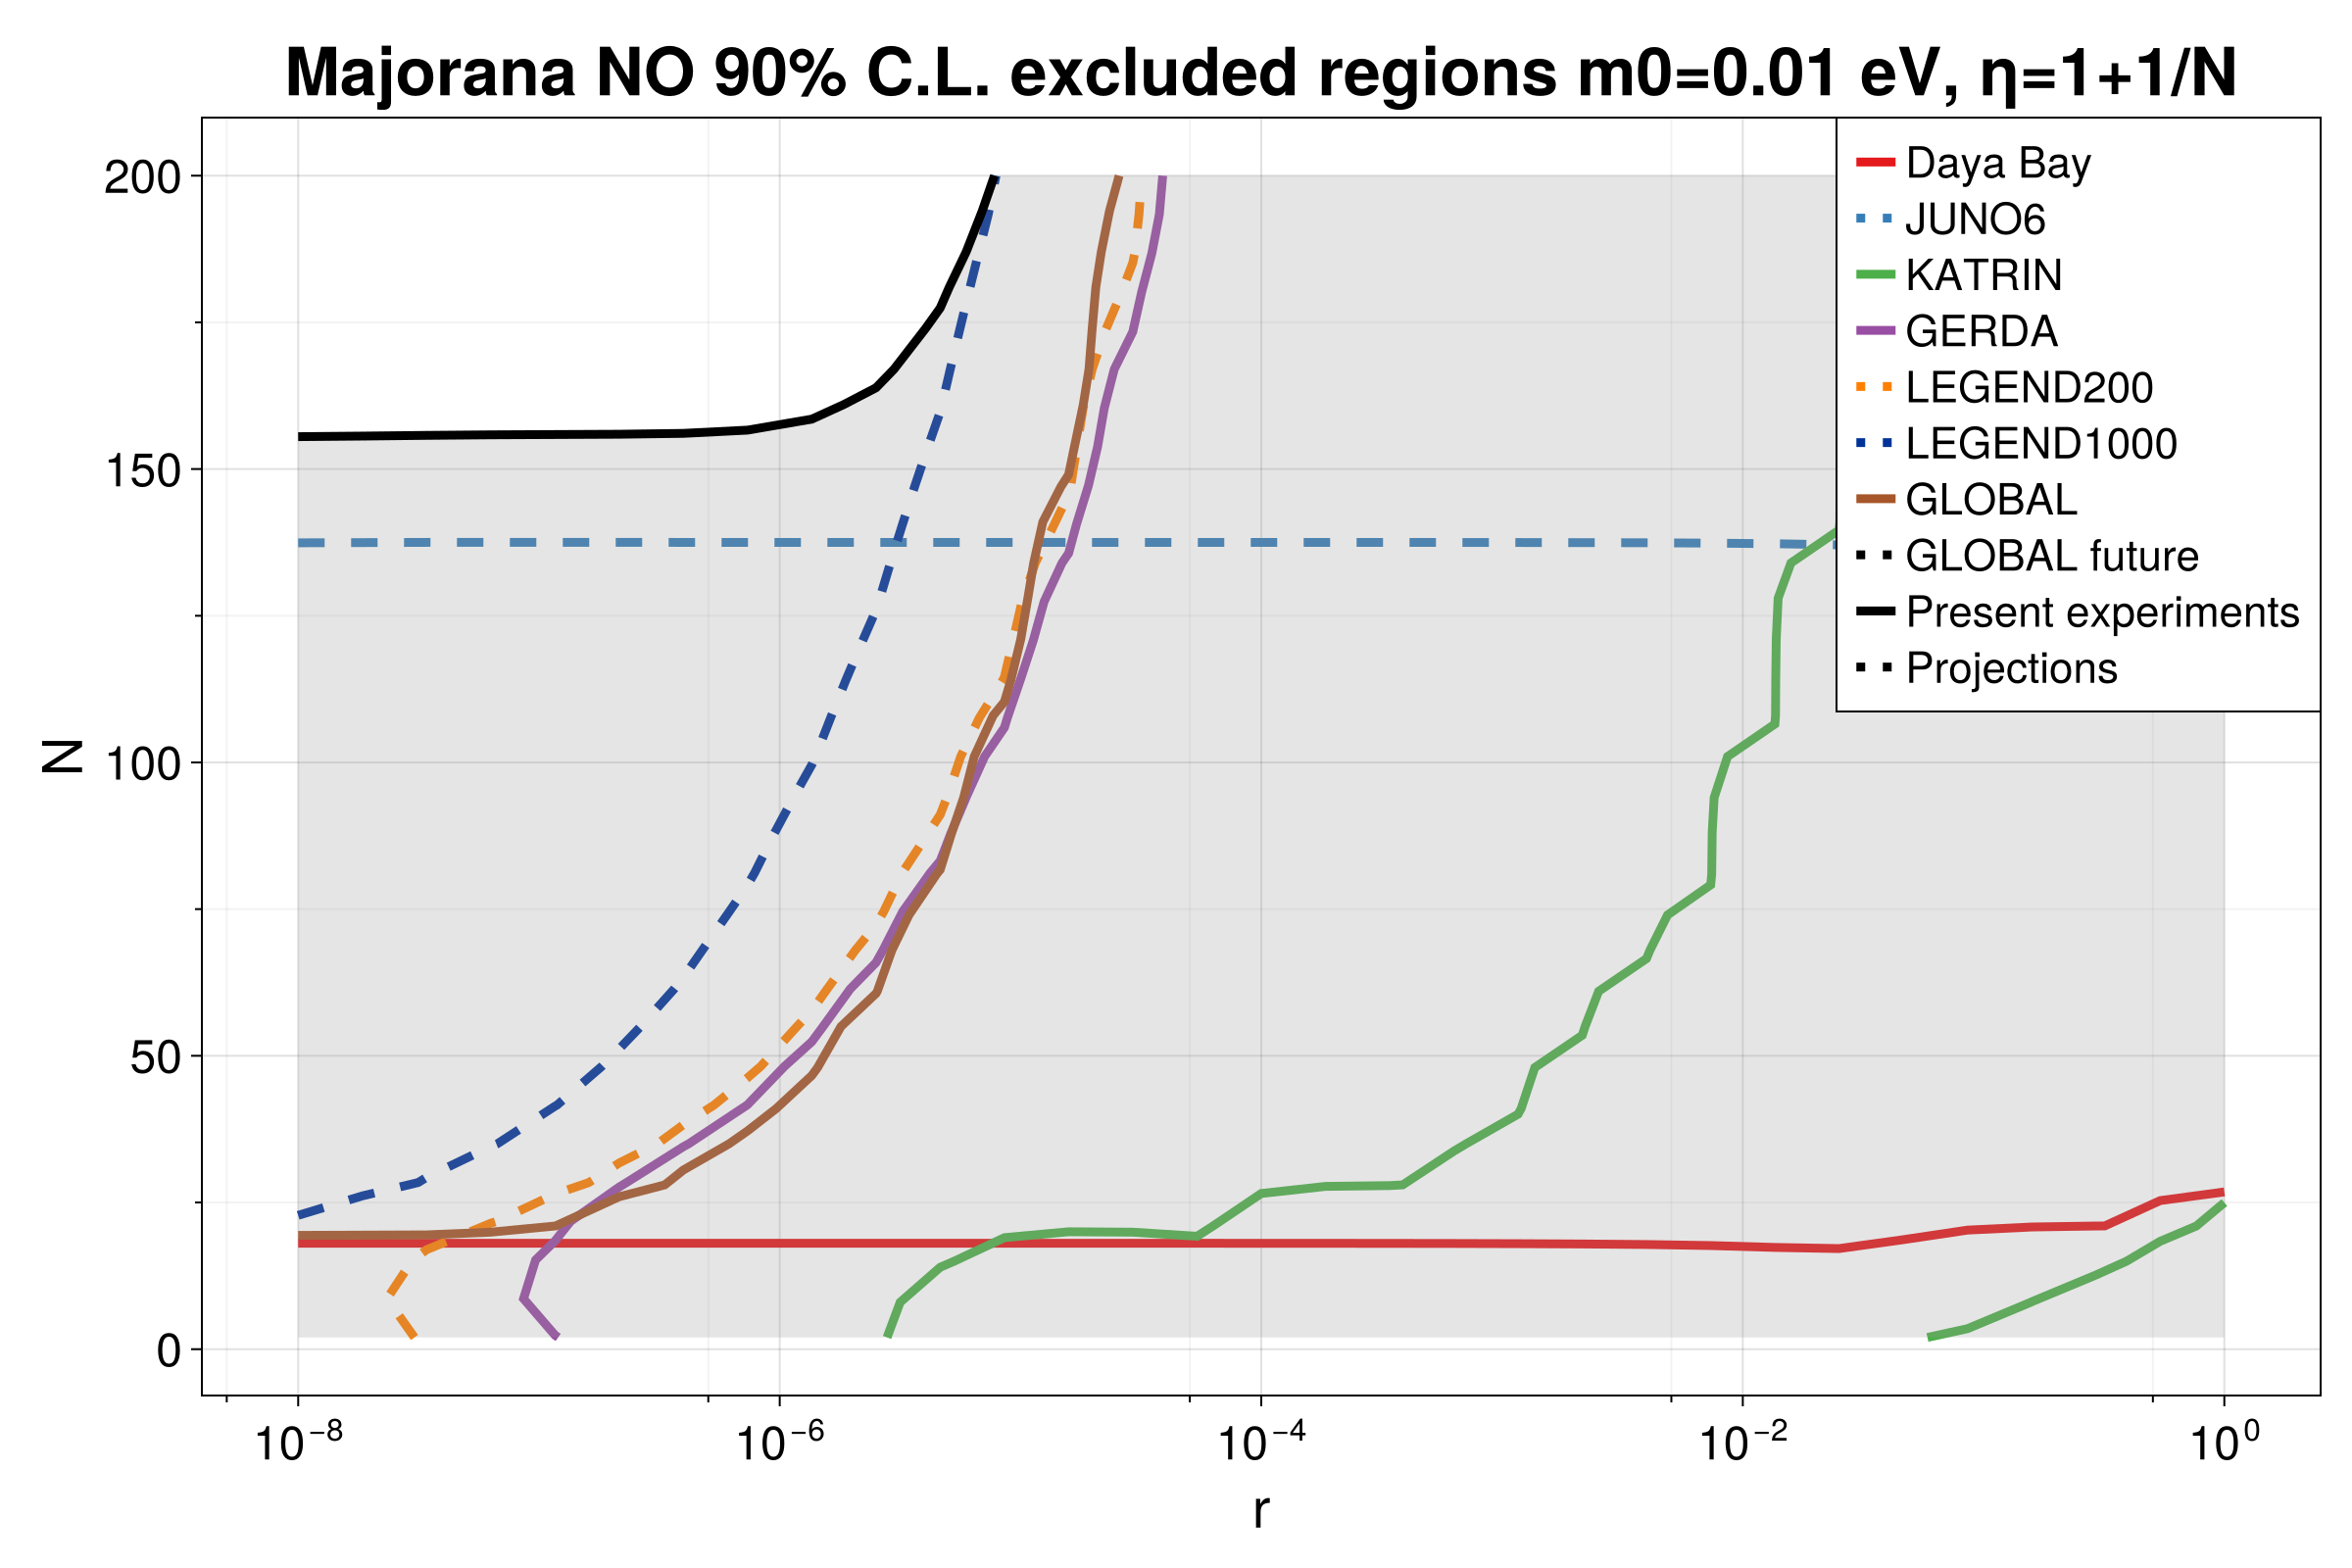

In [31]:
using ImageFiltering
using JLD2, CairoMakie, Distributions, Colors, ColorSchemes
using Newtrinos

function superpose_contours_outside(file_paths::Vector{String}; 
    title="Superposed Contours",
    xlabel="Parameter 1", 
    ylabel="Parameter 2",
    experiments=nothing,
    colorscheme=:Set1_9,
    color_step=1,
    xscale=identity,
    yscale=identity,
    smooth_sigma::Union{Nothing,Float64}=nothing)

    sigma_90_excluded_level = quantile(Chisq(2), 0.90)

    # Load results
    results = []
    all_axes_1 = []
    all_axes_2 = []

    for file_path in file_paths
        result = load(file_path)["result"]
        push!(results, result)
        push!(all_axes_1, result.axes[1])
        push!(all_axes_2, result.axes[2])
    end

    # Combined ranges
    x_min = minimum([minimum(ax) for ax in all_axes_1])
    x_max = maximum([maximum(ax) for ax in all_axes_1])
    y_min = minimum([minimum(ax) for ax in all_axes_2])
    y_max = maximum([maximum(ax) for ax in all_axes_2])

    first_result = results[1]
    axis_labels = collect(keys(first_result.axes))

    # Colors
    cs = getproperty(ColorSchemes, colorscheme)
    base_colors = cs.colors
    colors = base_colors[1:color_step:end]
    colors = colors[1:length(results)]

    # Change LEGEND1000 color to dark blue
    if experiments !== nothing
        idx = findfirst(x -> x=="LEGEND1000", experiments)
        if idx !== nothing
            colors[idx] = RGB(0.0,0.2,0.6)  # dark blue
        end
    end

    # Figure
    f = Figure(size=(1200, 800))
    ax = Axis(f[1,1];
        xlabel = String(axis_labels[1]),
        ylabel = String(axis_labels[2]),
        title = title,
        xminorticksvisible = true,
        xminorgridvisible = true,
        yminorticksvisible = true,
        yminorgridvisible = true,
        titlesize = 34,
        xlabelsize = 28,
        ylabelsize = 28,
        xticklabelsize = 24,
        yticklabelsize = 24,
        xscale = xscale,
        yscale = yscale
    )

    # -------------------------------
    # Contours
    # -------------------------------
    for (idx, result) in enumerate(results)

        lp = result.values.log_posterior
        finite_mask = isfinite.(lp)

        if !any(finite_mask)
            continue
        end

        lp_max = maximum(lp[finite_mask])
        dLLH_raw = 2 .* (lp_max .- lp)

        dLLH = smooth_sigma === nothing ?
            dLLH_raw :
            imfilter(dLLH_raw, Kernel.gaussian(smooth_sigma))

        dLLH_plot = copy(dLLH)
        dLLH_plot[.!isfinite.(dLLH_plot)] .= NaN

        maxlevel = maximum(skipmissing(vec(dLLH_plot)))

        exp_label = experiments !== nothing ? experiments[idx] : ""

        # Experiments that must be dashed
        force_dashed = exp_label in ["LEGEND200", "LEGEND1000", "JUNO6"]

        # GLOBAL shading only
        if exp_label == "GLOBAL future"
            if isfinite(maxlevel) && maxlevel > sigma_90_excluded_level
                contourf!(ax,
                    result.axes[1],
                    result.axes[2],
                    dLLH_plot;
                    levels = [sigma_90_excluded_level, maxlevel],
                    colormap = cgrad([RGBA(0.6,0.6,0.6,0.25),
                                      RGBA(0.6,0.6,0.6,0.25)])
                )
            end
        end

        # Contour line
        contour!(ax,
            result.axes[1],
            result.axes[2],
            dLLH_plot;
            levels = [sigma_90_excluded_level],
            color = exp_label == "GLOBAL future" ? :black : colors[idx],
            linewidth = 4.5,
            linestyle = force_dashed ? :dash : :solid
        )
    end

    # -------------------------------
    # Combined Legend (columns, long lines for style clarity)
    # -------------------------------
    if experiments !== nothing

        legend_elements = LineElement[]
        legend_labels = String[]

        # Experiment lines
        for (idx, label) in enumerate(experiments)
            force_dashed = label in ["LEGEND200", "LEGEND1000", "JUNO6", "GLOBAL future"]
            push!(legend_elements, LineElement(
                color = label == "GLOBAL future" ? :black : colors[idx],
                linewidth = 4.5,
                linestyle = force_dashed ? :dot : :solid,
                length = 40  # long legend line
            ))
            push!(legend_labels, label)
        end

        # Line style explanation
        push!(legend_elements, LineElement(color=:black, linewidth=4.5, linestyle=:solid, length=40))
        push!(legend_labels, "Present experiments")
        push!(legend_elements, LineElement(color=:black, linewidth=4.5, linestyle=:dot, length=40))
        push!(legend_labels, "Projections")

        # Single merged legend with two columns
        Legend(
            f[1,1],
            legend_elements,
            legend_labels;
            tellwidth=false,
            tellheight=false,
            halign=:right,
            valign=:top,
            framevisible=true,
            framecolor=:black,
            backgroundcolor=:white,
            padding=(10,10,10,10),
            labelsize=22,
            ncol=2
        )
    end

    f
end

# -------------------------------------------------
# File paths
# -------------------------------------------------
file_paths = [
"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_dayabay_rN_m0=0.01_NNM_log.jld2",
"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/junotao_full6_rN_NNM_NO_η=1+1_N_m0=0.01_log.jld2",
"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_katrin_Nr_m0=0.01_η=1+1N_NNM_NO.jld2",
"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_gerda_Nr_m0=0.01_η=1+1N_NNM_NO.jld2",
"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_legend200_Nr_m0=0.01_η=1+1N_NNM_NO.jld2",
"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_legend1000_Nr_m0=0.01_η=1+1N_NNM_NO.jld2",
"/home/sofialon/Newtrinos.jl/plots_fix/junotao_m/scan_global_data_rN_m0=0.01_NNM_NO.jld2",
"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_global_rN_m0=0.01_NNM_NO (2).jld2"
]

fig = superpose_contours_outside(
    file_paths;
    title="Majorana NO 90% C.L. excluded regions m0=0.01 eV, η=1+1/N",
    experiments=["Daya Bay","JUNO6","KATRIN","GERDA","LEGEND200","LEGEND1000","GLOBAL", "GLOBAL future"],
    xscale=log10,
    smooth_sigma=1.0
)

display("image/png", fig)

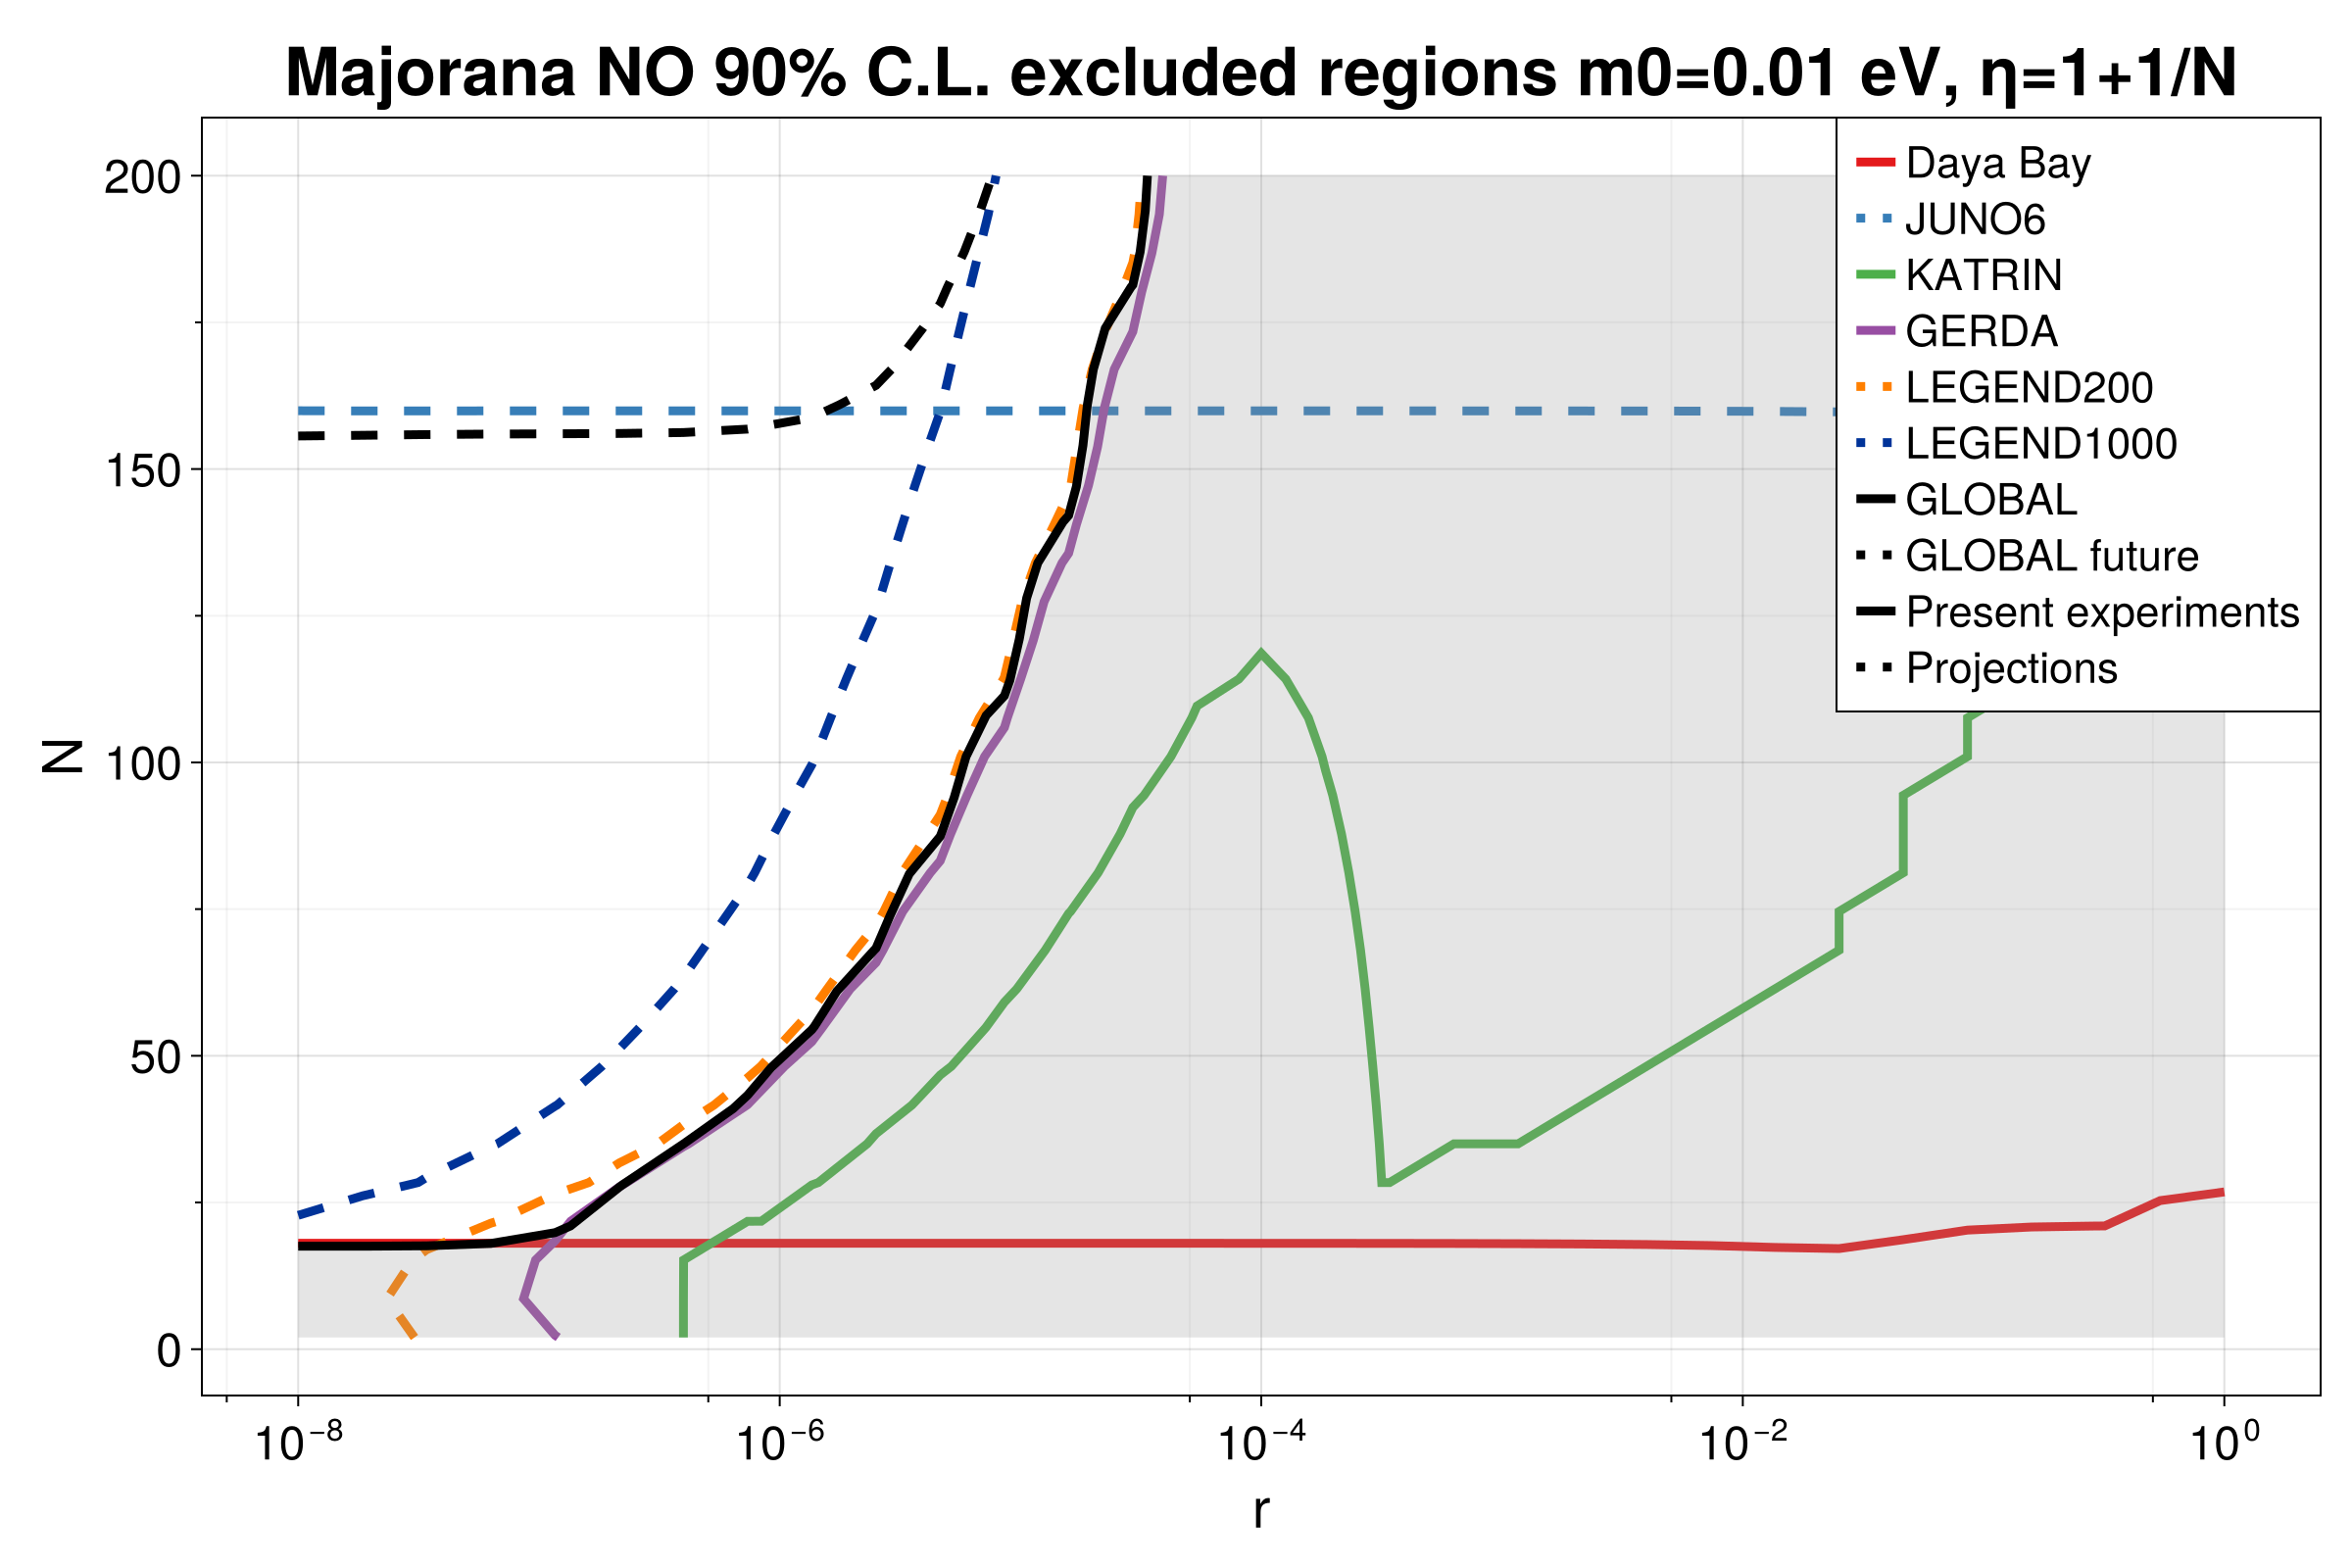

CairoMakie.Screen{SVG}


In [44]:
using ImageFiltering
using JLD2, CairoMakie, Distributions, Colors, ColorSchemes
using Newtrinos

function superpose_contours_outside(file_paths::Vector{String}; 
    title="Superposed Contours",
    xlabel="Parameter 1", 
    ylabel="Parameter 2",
    experiments=nothing,
    colorscheme=:Set1_9,
    color_step=1,
    xscale=identity,
    yscale=identity,
    smooth_sigma::Union{Nothing,Float64}=nothing)

    sigma_90_excluded_level = quantile(Chisq(2), 0.90)

    results = []
    all_axes_1 = []
    all_axes_2 = []

    
    for file_path in file_paths
        data = load(file_path)
        result = only(values(data)) # Adjust key if needed
        push!(results, result)
        push!(all_axes_1, result.axes[1])
        push!(all_axes_2, result.axes[2])
    end

    first_result = results[1]
    axis_labels = collect(keys(first_result.axes))

    cs = getproperty(ColorSchemes, colorscheme)
    base_colors = cs.colors
    colors = base_colors[1:color_step:end]
    colors = colors[1:length(results)]

    # LEGEND1000 dark blue
    if experiments !== nothing
        idx = findfirst(x -> x=="LEGEND1000", experiments)
        if idx !== nothing
            colors[idx] = RGB(0.0,0.2,0.6)
        end
    end

    f = Figure(size=(1200, 800))
    ax = Axis(f[1,1];
        xlabel = String(axis_labels[1]),
        ylabel = String(axis_labels[2]),
        title = title,
        xminorticksvisible = true,
        xminorgridvisible = true,
        yminorticksvisible = true,
        yminorgridvisible = true,
        titlesize = 34,
        xlabelsize = 28,
        ylabelsize = 28,
        xticklabelsize = 24,
        yticklabelsize = 24,
        xscale = xscale,
        yscale = yscale
    )

    # -------------------------------------------------
    # Contours
    # -------------------------------------------------
    for (idx, result) in enumerate(results)

        lp = result.values.log_posterior
        finite_mask = isfinite.(lp)
        if !any(finite_mask)
            continue
        end

        lp_max = maximum(lp[finite_mask])
        dLLH_raw = 2 .* (lp_max .- lp)

        dLLH = smooth_sigma === nothing ?
            dLLH_raw :
            imfilter(dLLH_raw, Kernel.gaussian(smooth_sigma))

        dLLH_plot = copy(dLLH)
        dLLH_plot[.!isfinite.(dLLH_plot)] .= NaN

        maxlevel = maximum(skipmissing(vec(dLLH_plot)))
        exp_label = experiments !== nothing ? experiments[idx] : ""

        # dashed experiments
        force_dashed = exp_label in ["LEGEND200", "LEGEND1000", "JUNO6", "GLOBAL future"]

        
        # -----------------------------
        # GREY SHADING NOW FROM GLOBAL
        # -----------------------------
        if exp_label == "GLOBAL"
            if isfinite(maxlevel) && maxlevel > sigma_90_excluded_level
                contourf!(ax,
                    result.axes[1],
                    result.axes[2],
                    dLLH_plot;
                    levels = [sigma_90_excluded_level, maxlevel],
                    colormap = cgrad([RGBA(0.6,0.6,0.6,0.25),
                                      RGBA(0.6,0.6,0.6,0.25)])
                )
            end
        end
        # --- COLOR FIX ---
        linecolor = if exp_label == "GLOBAL" || exp_label == "GLOBAL future"
            :black
        else
            colors[idx]
        end

        contour!(ax,
            result.axes[1],
            result.axes[2],
            dLLH_plot;
            levels = [sigma_90_excluded_level],
            color = linecolor,
            linewidth = 4.5,
            linestyle = force_dashed ? :dash : :solid
        )
    end

    # -------------------------------------------------
    # Combined Legend
    # -------------------------------------------------
    if experiments !== nothing

        legend_elements = LineElement[]
        legend_labels = String[]

        for (idx, label) in enumerate(experiments)

            force_dashed = label in ["LEGEND200", "LEGEND1000", "JUNO6", "GLOBAL future"]

            linecolor = if label == "GLOBAL" || label == "GLOBAL future"
                :black
            else
                colors[idx]
            end

            push!(legend_elements, LineElement(
                color = linecolor,
                linewidth = 4.5,
                linestyle = force_dashed ? :dot : :solid,
                #points = Point2f[(0,0), (1.3,0)]   # LONG legend line (correct Makie method)
            ))

            push!(legend_labels, label)
        end

        # style explanation
        push!(legend_elements, LineElement(
            color=:black,
            linewidth=4.5,
            linestyle=:solid,
           # points=Point2f[(0,0),(1.3,0)]
        ))
        push!(legend_labels, "Present experiments")

        push!(legend_elements, LineElement(
            color=:black,
            linewidth=4.5,
            linestyle=:dot,
          #  points=Point2f[(0,0),(1.3,0)]
        ))
        push!(legend_labels, "Projections")

        Legend(
            f[1,1],
            legend_elements,
            legend_labels;
            tellwidth=false,
            tellheight=false,
            halign=:right,
            valign=:top,
            framevisible=true,
            framecolor=:black,
            backgroundcolor=:white,
            padding=(10,10,10,10),
            labelsize=22,
            ncol=2
        )
    end

    f
end


# -------------------------------------------------
# File paths
# -------------------------------------------------
file_paths = [
"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_dayabay_rN_m0=0.01_NNM_log.jld2",
"/home/sofialon/Newtrinos.jl/plots_fix/junotao_m/junotao_toynor_rN_NNM_NO_m0=0.01.jld2",
"/home/sofialon/Newtrinos.jl/plot_auto/katrin/scan_katrin_rN_m0=0.01_NNM_NO.jld2",
"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_gerda_Nr_m0=0.01_η=1+1N_NNM_NO.jld2",
"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_legend200_Nr_m0=0.01_η=1+1N_NNM_NO.jld2",
"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_legend1000_Nr_m0=0.01_η=1+1N_NNM_NO.jld2",
"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_global_data_new_rN_m0=0.01_NNM_NO.jld2",
"/home/sofialon/Newtrinos.jl/plots_fix/scan_cl/global_toyschur_rN_NNM_NO_m0=0.01.jld2"
]

fig = superpose_contours_outside(
    file_paths;
    title="Majorana NO 90% C.L. excluded regions m0=0.01 eV, η=1+1/N",
    experiments=["Daya Bay","JUNO6","KATRIN","GERDA","LEGEND200","LEGEND1000","GLOBAL", "GLOBAL future"],
    xscale=log10,
    smooth_sigma=1.0
)

display("image/png", fig)
save("/home/sofialon/Newtrinos.jl/plots_svg/total/majorana_no_combined.png", fig)
save("/home/sofialon/Newtrinos.jl/plots_svg/total/majorana_no_combined.svg", fig)

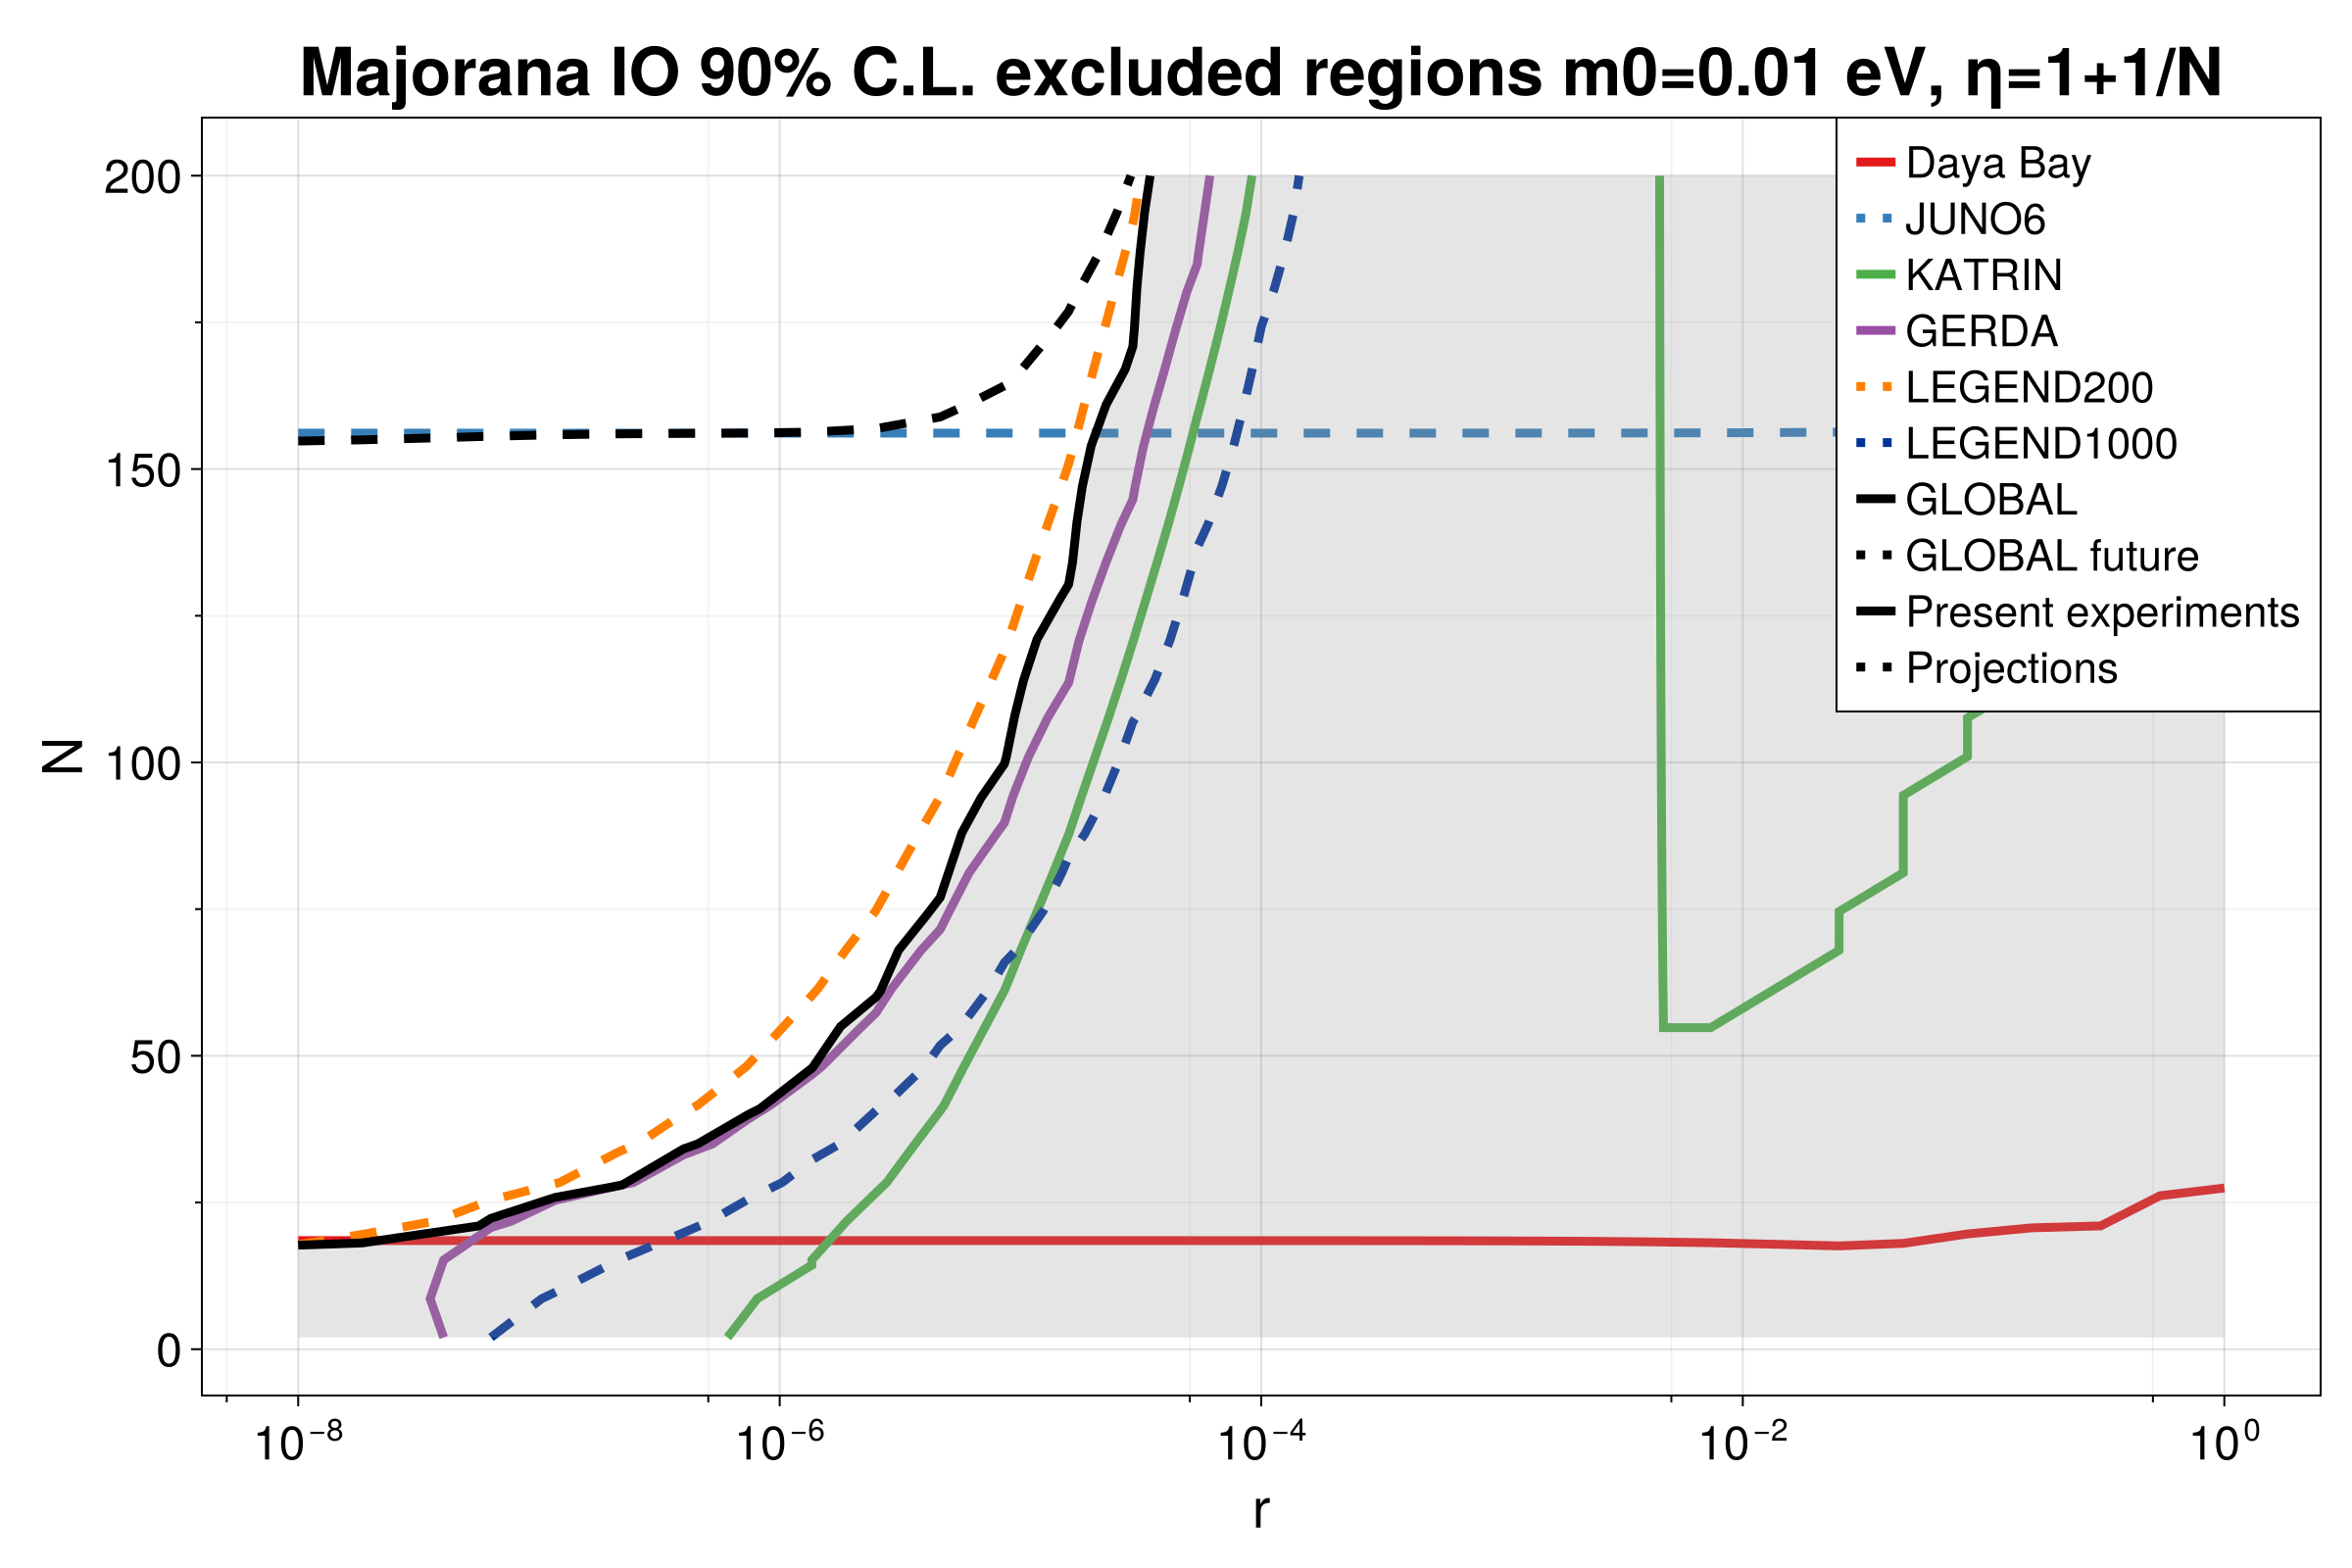

CairoMakie.Screen{SVG}


In [45]:


# -------------------------------------------------
# Run
# -------------------------------------------------
file_paths = [
"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_dayabay_rN_m0=0.01_NNM_IO_log.jld2",
"/home/sofialon/Newtrinos.jl/plots_fix/junotao_m/junotao_toyschur_rN_NNM_IO_m0=0.01.jld2",
"/home/sofialon/Newtrinos.jl/plot_auto/katrin/scan_katrin_rN_m0=0.01_NNM_IO.jld2",
"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_gerda_Nr_m0=0.01_η=1+1N_NNM_IO.jld2",
"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_legend200_Nr_m0=0.01_η=1+1N_NNM_IO.jld2",
"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_legend1000_Nr_m0=0.01_η=1+1N_NNM_IO.jld2",
"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_global_data_new_rN_m0=0.01_NNM_IO.jld2",
"/home/sofialon/Newtrinos.jl/plots_fix/scan_cl/global_toyschur_rN_NNM_IO_m0=0.01.jld2"
]

fig = superpose_contours_outside(
    file_paths;
    title="Majorana IO 90% C.L. excluded regions m0=0.01 eV, η=1+1/N",
    experiments=["Daya Bay","JUNO6","KATRIN","GERDA","LEGEND200","LEGEND1000","GLOBAL","GLOBAL future"],
    xscale=log10,
    smooth_sigma=1.0
)

display("image/png", fig)
save("/home/sofialon/Newtrinos.jl/plots_svg/total/majorana_io_combined.png", fig)
save("/home/sofialon/Newtrinos.jl/plots_svg/total/majorana_io_combined.svg", fig)

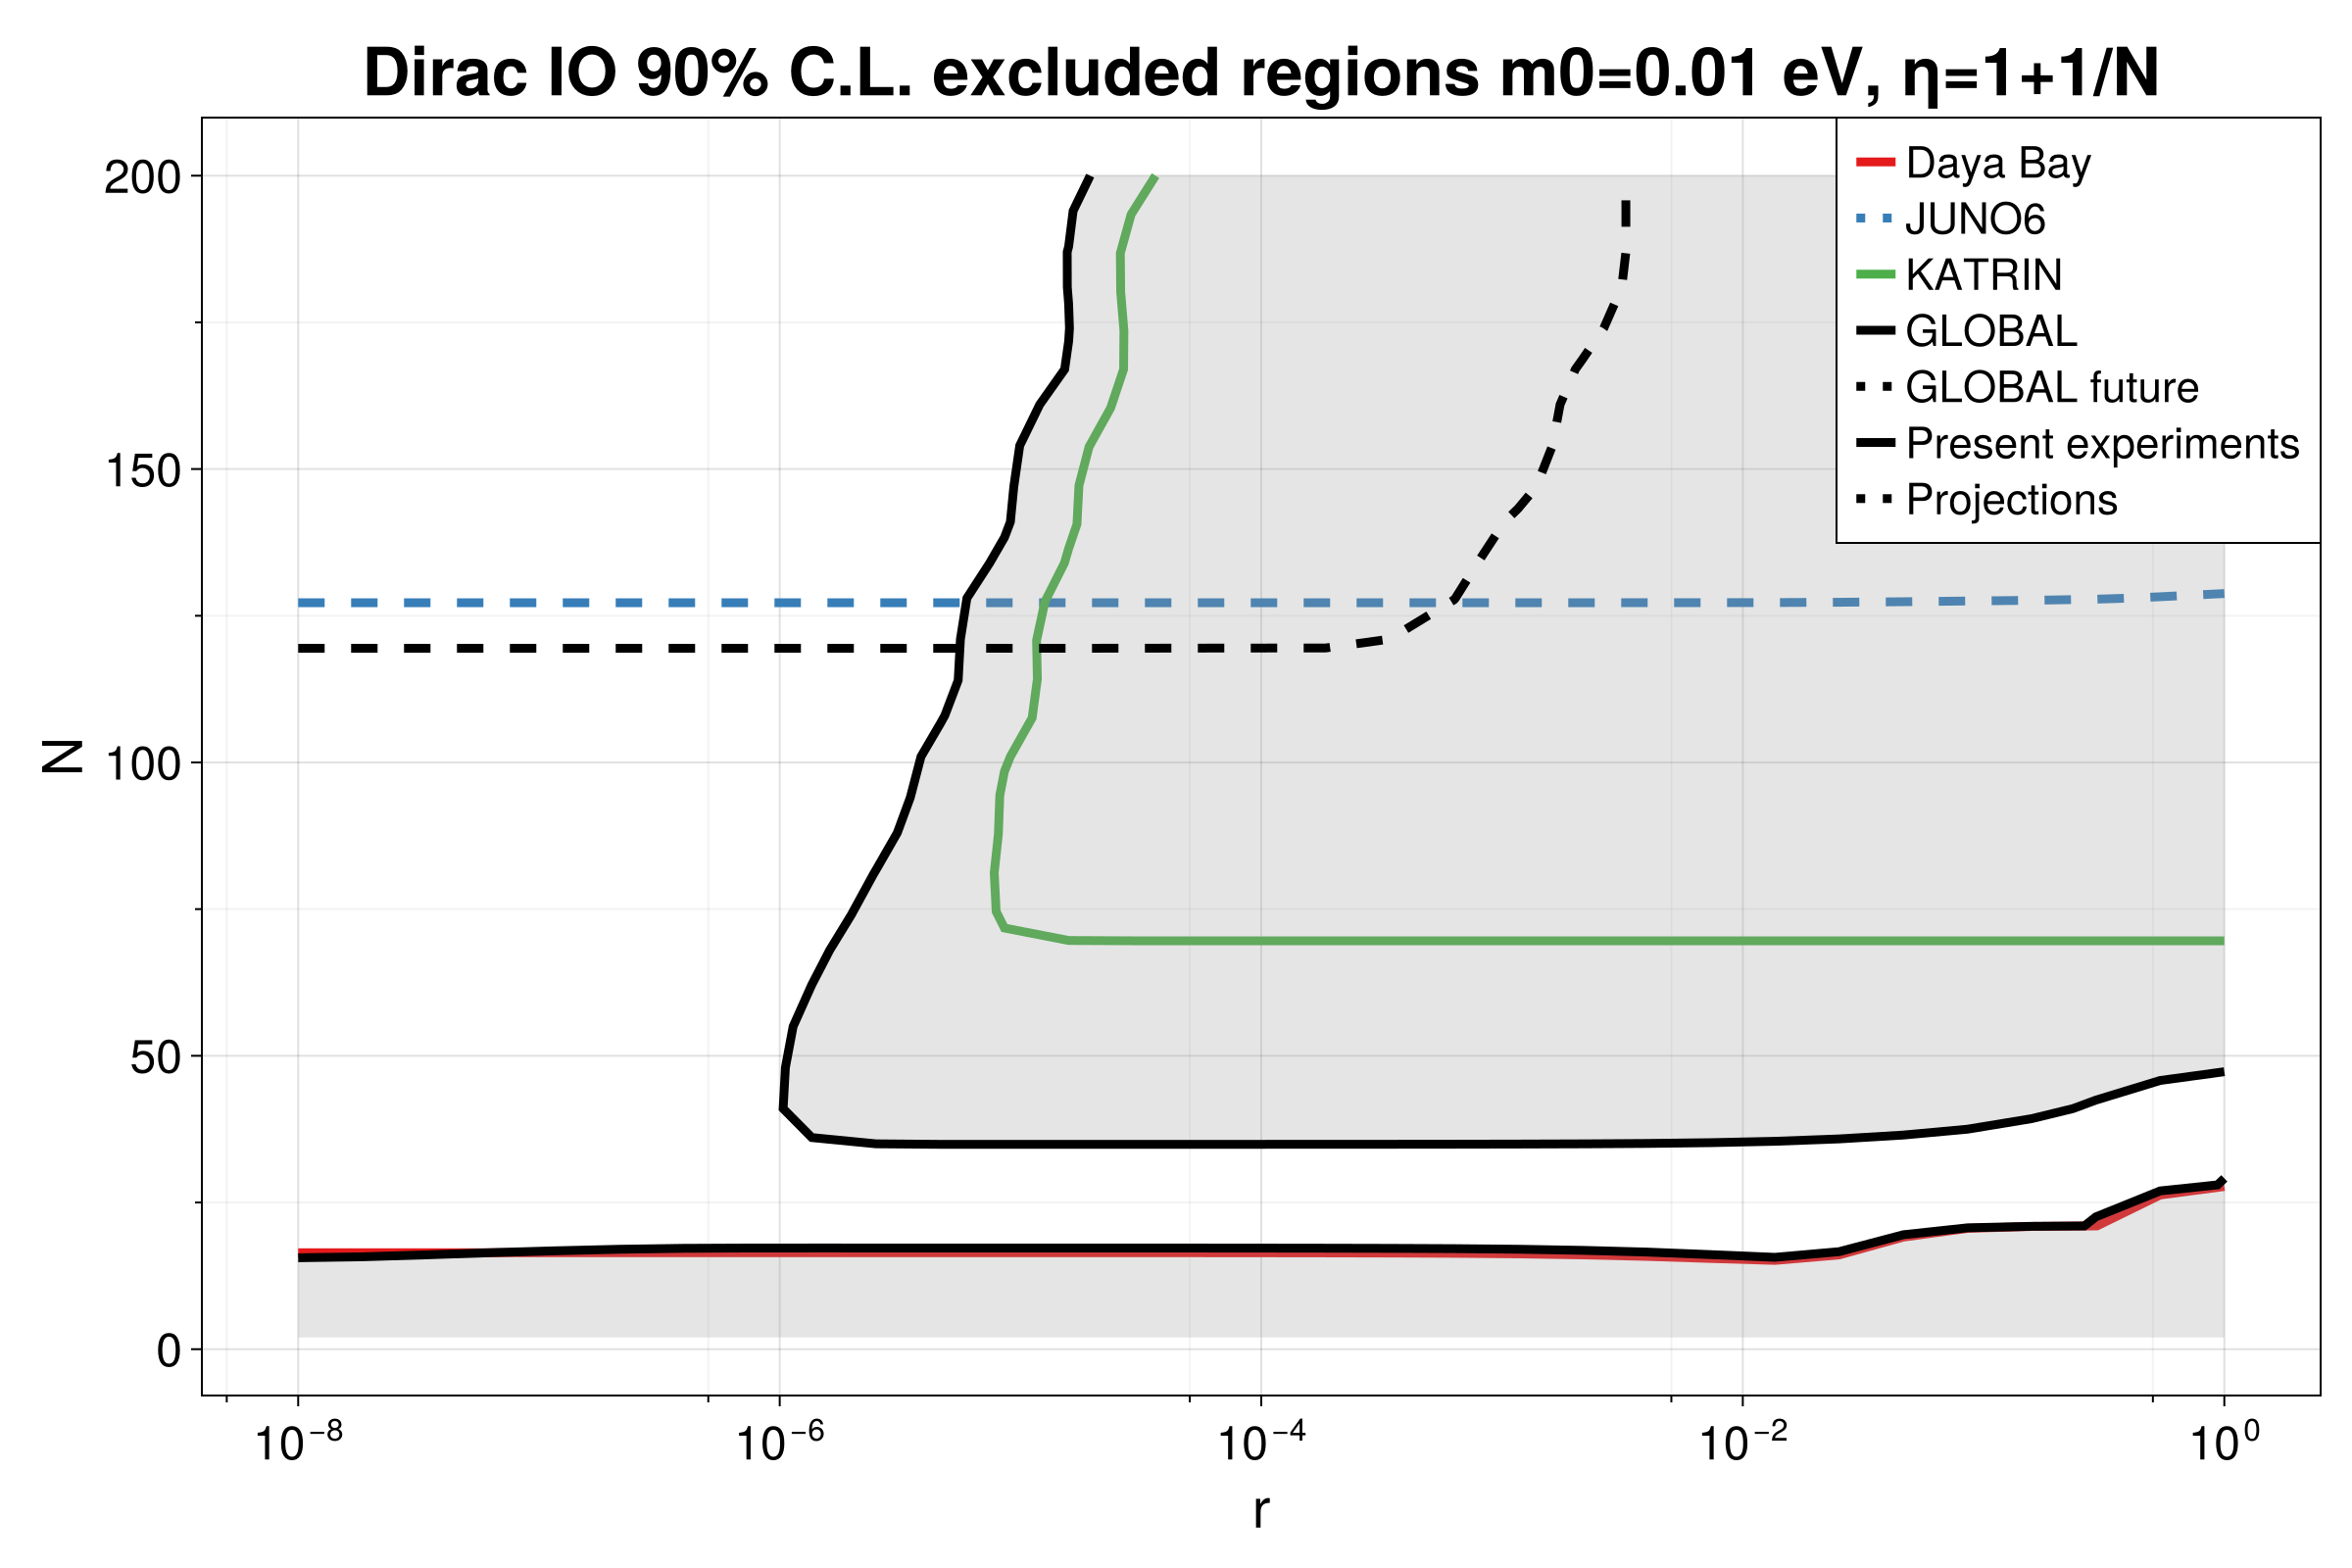

CairoMakie.Screen{SVG}


In [50]:


# -------------------------------------------------
# Run
# -------------------------------------------------
file_paths = [
"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_dayabay_rN_m0=0.01_NND_IO_log.jld2",
"/home/sofialon/Newtrinos.jl/plots_fix/junotao_m/junotao_toyschur_rN_NND_IO_m0=0.01.jld2",
"/home/sofialon/Newtrinos.jl/plot_auto/katrin/scan_katrin_rN_m0=0.01_NND_IO.jld2",
"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_global_data_new_rN_m0=0.01_NND_IO.jld2",
"/home/sofialon/Newtrinos.jl/plots_fix/scan_cl/global_toyschur_rN_NND_IO_m0=0.01.jld2"
]

fig = superpose_contours_outside(
    file_paths;
    title="Dirac IO 90% C.L. excluded regions m0=0.01 eV, η=1+1/N",
    experiments=["Daya Bay","JUNO6","KATRIN","GLOBAL", "GLOBAL future"],
    xscale=log10,
    smooth_sigma=1.0
)

display("image/png", fig)
save("/home/sofialon/Newtrinos.jl/plots_svg/total/dirac_io_combined.png", fig)
save("/home/sofialon/Newtrinos.jl/plots_svg/total/dirac_io_combined.svg", fig)

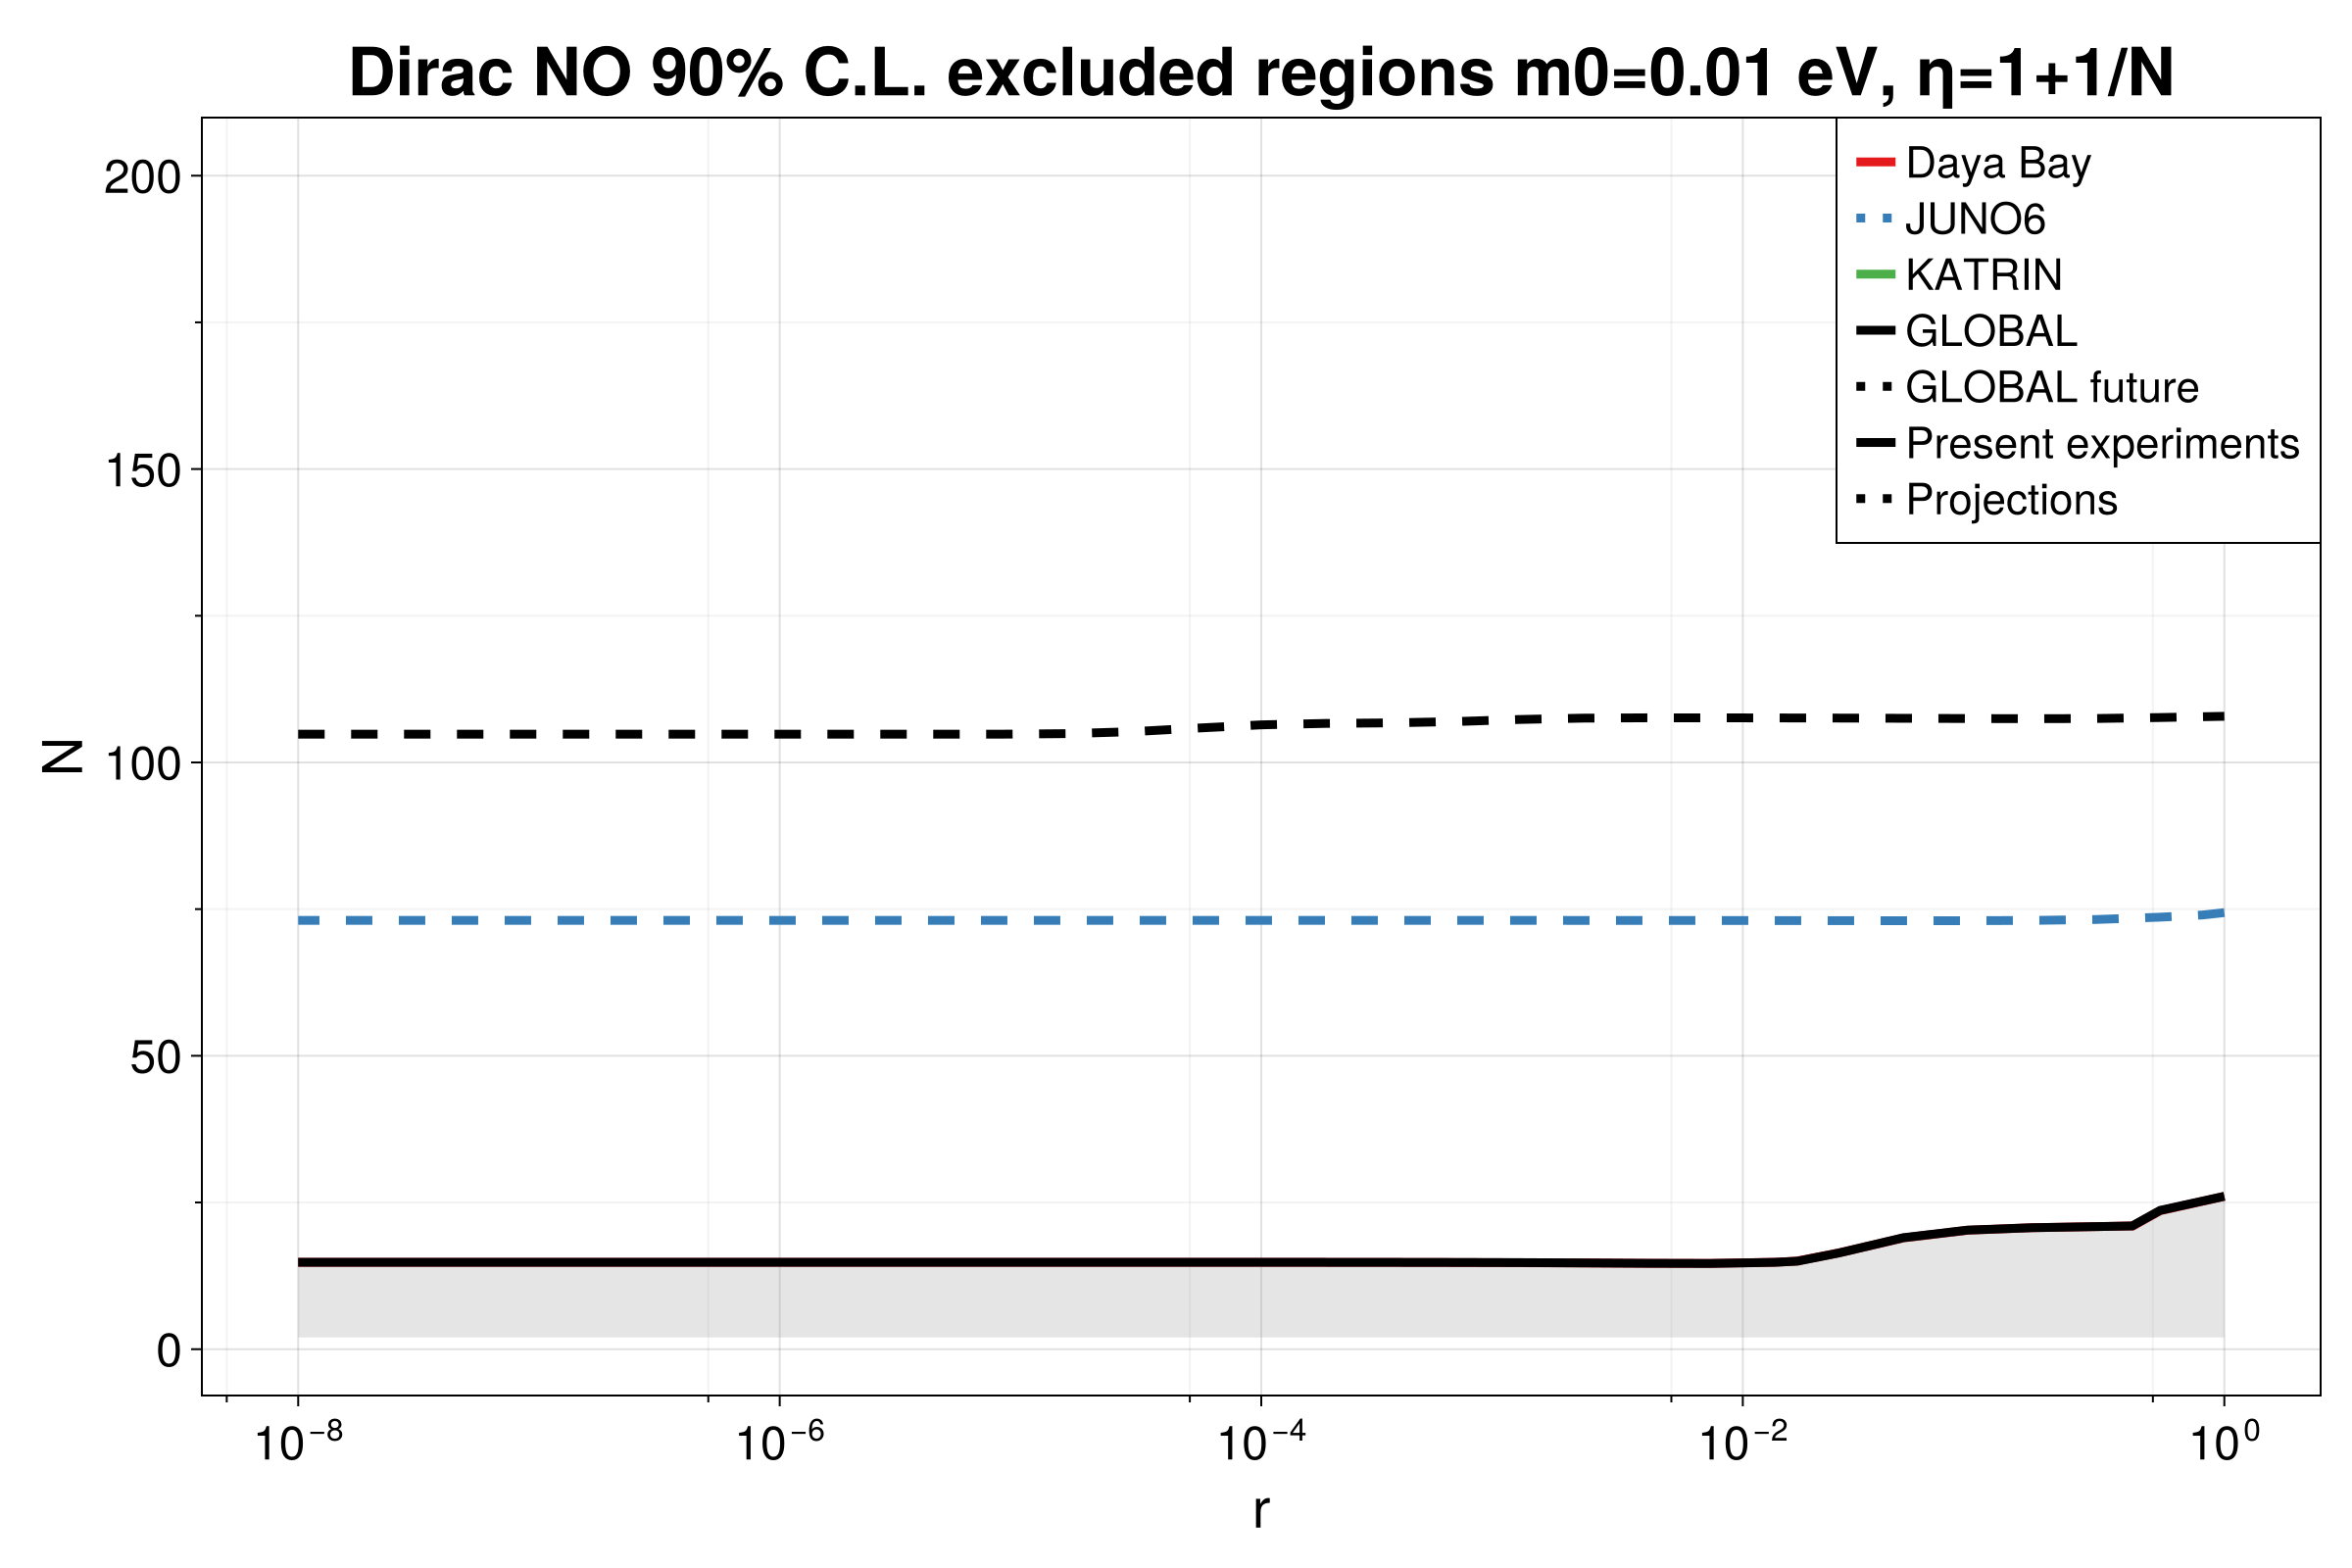

CairoMakie.Screen{SVG}


In [49]:

file_paths = [
"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_dayabay_rN_m0=0.01_NND_NO_log.jld2",
"/home/sofialon/Newtrinos.jl/plots_fix/junotao_m/junotao_toyschur_rN_NND_NO_m0=0.01.jld2",
"/home/sofialon/Newtrinos.jl/plot_auto/katrin/scan_katrin_rN_m0=0.01_NND_NO.jld2",
"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_global_data_new_rN_m0=0.01_NND_NO.jld2",
"/home/sofialon/Newtrinos.jl/plots_fix/scan_cl/global_toyschur_rN_NND_NO_m0=0.01.jld2"
]
fig = superpose_contours_outside(
    file_paths;
    title="Dirac NO 90% C.L. excluded regions m0=0.01 eV, η=1+1/N",
    experiments=["Daya Bay","JUNO6","KATRIN","GLOBAL", "GLOBAL future"],
    xscale=log10,
    smooth_sigma=1.0
)

display("image/png", fig)

save("/home/sofialon/Newtrinos.jl/plots_svg/total/dirac_no_combined.png", fig)
save("/home/sofialon/Newtrinos.jl/plots_svg/total/dirac_no_combined.svg", fig)